# 20 — Semantic and Structural Consistency

**Origin:** New Notebook  
**Refactor status:** Finished                  
**Validation status:** Finished                     
**Completion gate passed:** Yes                  
**Output root:** `outputs/20_semantic_and_structural_consistency/`  
**Depends on:** Notebooks 01, 02, 08–12, 12A, and 15–19

## Purpose

Evaluate whether completed restoration candidates preserve reference-based semantic organization, local feature relationships, structural layout, surrounding context, and painterly representation.

The notebook does not run restoration inference. It evaluates validated candidates from OpenCV Telea, LaMa, HINT, Stable Diffusion, and the bounded SDXL comparison.

## Approved evidence population

- 2,620 restoration-eligible cases;
- 16,404 completed candidates;
- 2,620 OpenCV Telea candidates;
- 2,620 LaMa candidates;
- 2,620 HINT candidates;
- 8,520 Stable Diffusion candidates;
- 24 technically validated SDXL completions from a 35-case attempt;
- 1,200 zero-damage control candidates retained in scalar metrics;
- 15,204 nonzero-damage candidates;
- 9,304 nonzero primary candidates selected for rendered semantic panels.

All Stable Diffusion prompt and seed candidates remain separate in the scalar metric population. SDXL remains a bounded feasibility comparison, not a full-coverage method.

## Transparent semantic and structural components

The notebook evaluates:

- Notebook 15 global CLIP and DINOv2 similarity as linked subject-preservation evidence;
- aligned local CLIP and DINOv2 token similarity;
- local worsening relative to the damaged input;
- outside-mask context preservation;
- DINOv2 reference-affinity layout diagnostics;
- DINOv2 patch-feature covariance as a painterly-representation proxy;
- agreement between CLIP and DINOv2 local evidence.

Local representations use aspect-preserving centred letterboxing:

- CLIP ViT-B/32: `7 × 7` local-token grid;
- DINOv2 ViT-S/14: `16 × 16` local-token grid.

Evidence uses the canonical `content_region` and, for nonzero cases, `mask_bbox_crop`. Token contributions are weighted by valid image support and active-mask overlap.

Numeric semantic bundles preserve local evidence for later ablation, explanation, retrieval, and failure analysis. Rendered panels cover all approved nonzero primary candidates, including the 24 completed SDXL cases.

## Category-conditioned interpretation

Artwork categories provide interpretation scopes only:

- portrait/figure → facial and anatomical structure proxy;
- architecture/structured → architectural-layout proxy;
- landscape/natural → natural-object structure proxy;
- abstraction/surrealism → abstract-compositional structure proxy;
- high-texture/brushwork → painterly-surface structure proxy.

These labels do not imply that the notebook detects faces, anatomy, buildings, objects, authentic brushwork, artists, or historical styles.

## Interpretation limits

CLIP and DINOv2 are general-purpose pretrained encoders rather than conservation-specific semantic judges.

Aligned token similarity is representation-space evidence. It does not establish object identity, restoration correctness, historical plausibility, conservation acceptability, or stylistic authenticity.

DINOv2 CLS-to-patch affinity is a reference-derived saliency proxy, not causal attribution, validated eye tracking, or occlusion sensitivity. Occlusion sensitivity is not applicable because there is no stable prediction target to perturb.

Low semantic drift can occur even when candidates are consistently incorrect. No combined semantic score, calibrated confidence value, or final trustworthiness flag is retained.

## Canonical outputs

- `data/semantic_maps.npz`
- `metrics/semantic_structural_metrics.csv`
- `images/maps/<model_id>/<candidate_id>/semantic.png`
- `figures/semantic_examples.png`
- `manifests/semantic_maps.csv`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

Notebook 20 does not generate a standalone HTML or Markdown report.

## Batch 1 — Contract, dependency preflight, and output ownership

This batch establishes the repository context, approved configuration, exact input and output paths, runtime dependencies, offline model-cache availability, upstream completion state, local schemas, region compatibility, population arithmetic, evidence limitations, and governing-document traceability.

It creates only empty Notebook 20 output and work directories. It does not load model weights, construct the candidate population, extract feature tokens, compute metrics, render semantic maps, or persist canonical output files.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import os
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import PIL
import torch
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration "
        f"repository root from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))


# ---------------------------------------------------------------------------
# Project helpers
# ---------------------------------------------------------------------------

from restoration_eval.manifests import (
    sha256_path as manifest_sha256_path,
)

from restoration_eval.metrics_feature_similarity import (
    FEATURE_SIMILARITY_MODULE_VERSION,
    resolve_local_hf_snapshot,
)

from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    resolve_repo_path,
    to_repo_relative,
)

from restoration_eval.schemas import (
    SCHEMAS_MODULE_VERSION,
    SEMANTIC_MAP_ASSET_SCHEMA,
    SEMANTIC_STRUCTURAL_METRIC_SCHEMA,
)

from restoration_eval.semantic_structural import (
    SEMANTIC_MAP_MANIFEST_VERSION,
    SEMANTIC_MAP_RENDERER_VERSION,
    SEMANTIC_NUMERIC_ARCHIVE_VERSION,
    SEMANTIC_STRUCTURAL_METRIC_VERSION,
    SEMANTIC_STRUCTURAL_MODULE_VERSION,
    load_semantic_structural_config,
    validate_semantic_runtime_dependencies,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "20"
NOTEBOOK_STEM = (
    "20_semantic_and_structural_consistency"
)
NOTEBOOK_ORIGIN = "New Notebook"

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

NOTEBOOK_STARTED_AT_UTC = (
    datetime.now(timezone.utc)
    .isoformat()
    .replace("+00:00", "Z")
)

print("Notebook 20 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook stem:", NOTEBOOK_STEM)
print("Python:", platform.python_version())
print("Started at:", NOTEBOOK_STARTED_AT_UTC)

Notebook 20 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook stem: 20_semantic_and_structural_consistency
Python: 3.12.6
Started at: 2026-09-19T11:59:43.365153Z


In [2]:
# ---------------------------------------------------------------------------
# Configuration and governing paths
# ---------------------------------------------------------------------------

SEMANTIC_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "semantic_structural.yaml"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / f"{NOTEBOOK_STEM}.ipynb"
)

HELPER_PATHS = {
    "semantic_structural": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "semantic_structural.py"
    ),
    "feature_similarity": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_feature_similarity.py"
    ),
    "schemas": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
    "paths": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "paths.py"
    ),
    "validation": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "validation.py"
    ),
}

semantic_config = load_semantic_structural_config(
    SEMANTIC_CONFIG_PATH
)

SEMANTIC_CONFIG = semantic_config[
    "semantic_structural"
]

CONFIGURED_INPUTS = SEMANTIC_CONFIG["inputs"]
CONFIGURED_OUTPUTS = SEMANTIC_CONFIG["output"]
EXPECTED_COUNTS = SEMANTIC_CONFIG["expected_counts"]
FEATURE_MODELS = SEMANTIC_CONFIG["feature_models"]
REGION_CONFIG = SEMANTIC_CONFIG["regions"]
EVIDENCE_POLICY = SEMANTIC_CONFIG["evidence_policy"]

if SEMANTIC_CONFIG["notebook_id"] != NOTEBOOK_ID:
    raise ValueError(
        "Configured notebook ID disagrees with Notebook 20."
    )

if SEMANTIC_CONFIG["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured notebook stem disagrees with Notebook 20."
    )

if (
    CONFIGURED_OUTPUTS["root"]
    != f"outputs/{NOTEBOOK_STEM}"
):
    raise ValueError(
        "Configured output root violates Notebook 20 ownership."
    )


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    key: resolve_repo_path(
        value,
        PROJECT_ROOT,
        must_exist=True,
    )
    for key, value in CONFIGURED_INPUTS.items()
}


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

PREEXISTING_OWNED_FILES = (
    sorted(
        path
        for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if NOTEBOOK_OUTPUT_ROOT.exists()
    else []
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "metrics",
        "images",
        "figures",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

OUTPUTS = {
    "numeric_maps": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["numeric_maps_path"]
    ),
    "semantic_metrics": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["metrics_path"]
    ),
    "map_images_root": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["map_images_root"]
    ),
    "semantic_examples": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["semantic_examples_path"]
    ),
    "semantic_map_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["map_manifest_path"]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["run_manifest_path"]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["validation_path"]
    ),
}

WORK_PATHS = {
    "base_token_cache_root": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["base_token_cache_root"]
    ),
    "bundle_checkpoint_root": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["bundle_checkpoint_root"]
    ),
    "extraction_checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["extraction_checkpoint_path"]
    ),
    "render_checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["render_checkpoint_path"]
    ),
}

for path in (*OUTPUTS.values(), *WORK_PATHS.values()):
    require_notebook_output_path(
        path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

for directory in (
    OUTPUTS["map_images_root"],
    WORK_PATHS["base_token_cache_root"],
    WORK_PATHS["bundle_checkpoint_root"],
):
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------------
# Human-reviewable contracts
# ---------------------------------------------------------------------------

def infer_input_producer(path):
    relative = to_repo_relative(path, PROJECT_ROOT)
    parts = relative.split("/")

    if relative.startswith("outputs/inventory/"):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


input_contract_df = pd.DataFrame(
    [
        {
            "input_key": key,
            "producer": infer_input_producer(path),
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "absolute_path": str(path),
            "required": True,
            "exists": path.is_file(),
            "size_bytes": (
                int(path.stat().st_size)
                if path.is_file()
                else pd.NA
            ),
        }
        for key, path in INPUTS.items()
    ]
)

output_contract_df = pd.DataFrame(
    [
        {
            "artifact_key": "semantic_numeric_maps",
            "relative_path": to_repo_relative(
                OUTPUTS["numeric_maps"],
                PROJECT_ROOT,
            ),
            "artifact_type": "npz",
            "expected_records": (
                EXPECTED_COUNTS["numeric_map_bundles"]
            ),
        },
        {
            "artifact_key": "semantic_structural_metrics",
            "relative_path": to_repo_relative(
                OUTPUTS["semantic_metrics"],
                PROJECT_ROOT,
            ),
            "artifact_type": "csv",
            "expected_records": (
                EXPECTED_COUNTS["semantic_metric_rows"]
            ),
        },
        {
            "artifact_key": "semantic_map_images",
            "relative_path": to_repo_relative(
                OUTPUTS["map_images_root"],
                PROJECT_ROOT,
            ),
            "artifact_type": "png_collection",
            "expected_records": (
                EXPECTED_COUNTS[
                    "rendered_semantic_panels"
                ]
            ),
        },
        {
            "artifact_key": "semantic_examples",
            "relative_path": to_repo_relative(
                OUTPUTS["semantic_examples"],
                PROJECT_ROOT,
            ),
            "artifact_type": "png",
            "expected_records": 1,
        },
        {
            "artifact_key": "semantic_map_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["semantic_map_manifest"],
                PROJECT_ROOT,
            ),
            "artifact_type": "csv",
            "expected_records": (
                EXPECTED_COUNTS["map_manifest_rows"]
            ),
        },
        {
            "artifact_key": "artifact_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "artifact_type": "csv",
            "expected_records": (
                EXPECTED_COUNTS["artifact_records"]
            ),
        },
        {
            "artifact_key": "run_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "artifact_type": "json",
            "expected_records": 1,
        },
        {
            "artifact_key": "validation_checks",
            "relative_path": to_repo_relative(
                OUTPUTS["validation"],
                PROJECT_ROOT,
            ),
            "artifact_type": "csv",
            "expected_records": pd.NA,
        },
    ]
)

print("Notebook 20 path contract established.")
print("Declared inputs:", len(input_contract_df))
print("Canonical output classes:", len(output_contract_df))
print("Pre-existing owned files:", len(PREEXISTING_OWNED_FILES))
print("Output root:", NOTEBOOK_OUTPUT_ROOT)

Notebook 20 path contract established.
Declared inputs: 41
Canonical output classes: 8
Pre-existing owned files: 26624
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\20_semantic_and_structural_consistency


In [3]:
# ---------------------------------------------------------------------------
# Inventory and registry state
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["inventory_path"],
    low_memory=False,
)

with INPUTS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = (
    load_project_paths_registry(PROJECT_ROOT)
)

with INPUTS["schema_registry_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    upstream_schema_registry = json.load(handle)

inventory_relative_paths = set(
    inventory_df["relative_path"].astype(str)
)

inventory_self_exceptions = {
    CONFIGURED_INPUTS["inventory_path"],
    CONFIGURED_INPUTS["inventory_run_path"],
}

input_contract_df["inventory_status"] = (
    input_contract_df["relative_path"].map(
        lambda relative_path: (
            "generated_inventory_exception"
            if relative_path
            in inventory_self_exceptions
            else (
                "listed"
                if relative_path
                in inventory_relative_paths
                else "missing"
            )
        )
    )
)


# ---------------------------------------------------------------------------
# Upstream completion state
# ---------------------------------------------------------------------------

UPSTREAM_MANIFEST_KEYS = {
    "notebook_01": "artworks_run_manifest_path",
    "notebook_02": "geometry_run_manifest_path",
    "notebook_08": "contracts_run_manifest_path",
    "notebook_09": "opencv_run_manifest_path",
    "notebook_10": "lama_run_manifest_path",
    "notebook_11": (
        "stable_diffusion_run_manifest_path"
    ),
    "notebook_12": "sdxl_run_manifest_path",
    "notebook_12a_hint": "hint_run_manifest_path",
    "notebook_15": "feature_run_manifest_path",
    "notebook_16": "spatial_run_manifest_path",
    "notebook_17": "local_run_manifest_path",
    "notebook_18": "uncertainty_run_manifest_path",
    "notebook_19": "explanation_run_manifest_path",
}

upstream_manifests = {}
upstream_manifest_records = []

for notebook_key, input_key in (
    UPSTREAM_MANIFEST_KEYS.items()
):
    path = INPUTS[input_key]

    with path.open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        manifest = json.load(handle)

    upstream_manifests[notebook_key] = manifest
    upstream_manifest_records.append(
        {
            "upstream_notebook": notebook_key,
            "notebook_id": manifest.get(
                "notebook_id",
                "",
            ),
            "run_id": manifest.get("run_id", ""),
            "run_status": manifest.get(
                "run_status",
                "",
            ),
            "completion_gate_passed": (
                manifest.get(
                    "completion_gate_passed",
                    False,
                )
            ),
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
        }
    )

upstream_manifest_df = pd.DataFrame(
    upstream_manifest_records
)


# ---------------------------------------------------------------------------
# Runtime and offline model-cache preflight
# ---------------------------------------------------------------------------

runtime_dependency_df = (
    validate_semantic_runtime_dependencies()
)

HF_HOME = Path(
    os.environ.get(
        "HF_HOME",
        Path.home() / ".cache" / "huggingface",
    )
)

clip_model_config = FEATURE_MODELS[
    "clip_vit_b32"
]

CLIP_SNAPSHOT = resolve_local_hf_snapshot(
    clip_model_config["model_name"],
    clip_model_config["model_revision"],
    cache_root=HF_HOME,
)

TORCH_HUB_ROOT = Path(torch.hub.get_dir())

DINOV2_REPOSITORY = (
    TORCH_HUB_ROOT
    / "facebookresearch_dinov2_main"
)

DINOV2_MODEL_FILE = (
    TORCH_HUB_ROOT
    / "checkpoints"
    / "dinov2_vits14_pretrain.pth"
)

model_cache_df = pd.DataFrame(
    [
        {
            "feature_model_id": "clip_vit_b32",
            "cache_role": "pinned_snapshot",
            "path": (
                str(CLIP_SNAPSHOT)
                if CLIP_SNAPSHOT is not None
                else ""
            ),
            "available": (
                CLIP_SNAPSHOT is not None
                and CLIP_SNAPSHOT.is_dir()
            ),
        },
        {
            "feature_model_id": "dinov2_vits14",
            "cache_role": "local_repository",
            "path": str(DINOV2_REPOSITORY),
            "available": (
                DINOV2_REPOSITORY.is_dir()
            ),
        },
        {
            "feature_model_id": "dinov2_vits14",
            "cache_role": "published_checkpoint",
            "path": str(DINOV2_MODEL_FILE),
            "available": (
                DINOV2_MODEL_FILE.is_file()
            ),
        },
    ]
)


# ---------------------------------------------------------------------------
# Canonical region compatibility
# ---------------------------------------------------------------------------

region_policy_df = pd.read_csv(
    INPUTS["region_policy_path"]
)

approved_local_regions = {
    "content_region",
    "mask_bbox_crop",
}

active_region_policy_df = (
    region_policy_df.loc[
        region_policy_df["metric_family"]
        .astype(str)
        .isin({"clip", "dinov2"})
        & region_policy_df["region_id"]
        .astype(str)
        .isin(approved_local_regions)
    ]
    .sort_values(
        ["metric_family", "region_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

governing_checksums = {
    "semantic_config": manifest_sha256_path(
        SEMANTIC_CONFIG_PATH
    ),
    "implementation_guidelines": manifest_sha256_path(
        INPUTS["implementation_guidelines_path"]
    ),
    "notebook_roadmap": manifest_sha256_path(
        INPUTS["notebook_roadmap_path"]
    ),
}

print("Notebook 20 dependency evidence loaded.")
print("Inventory run ID:", inventory_run["inventory_run_id"])
print("Inventory rows:", len(inventory_df))
print("Registered project artifacts:", len(
    project_paths_registry["artifacts"]
))
print("Upstream manifests:", len(upstream_manifest_df))
print("Region-policy rows:", len(active_region_policy_df))
print("No feature-model weights have been loaded.")

Notebook 20 dependency evidence loaded.
Inventory run ID: inventory_20260918T105924Z_55c632e2
Inventory rows: 132588
Registered project artifacts: 235
Upstream manifests: 13
Region-policy rows: 4
No feature-model weights have been loaded.


In [4]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()
VALIDATION_STAGE = "batch_1_preflight"


def add_preflight_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Runtime and notebook identity
observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_preflight_check(
    "supported_python",
    "Python uses one of the approved minor versions.",
    sorted(SUPPORTED_PYTHON_MINORS),
    observed_python_minor,
    observed_python_minor
    in SUPPORTED_PYTHON_MINORS,
)

add_preflight_check(
    "notebook_exists",
    "The blank replacement Notebook 20 exists.",
    True,
    NOTEBOOK_PATH.is_file(),
    NOTEBOOK_PATH.is_file(),
)

add_preflight_check(
    "notebook_identity",
    "Configuration and notebook identity agree.",
    NOTEBOOK_STEM,
    SEMANTIC_CONFIG["notebook_stem"],
    SEMANTIC_CONFIG["notebook_stem"]
    == NOTEBOOK_STEM,
)


# Explicit inputs
for row in input_contract_df.itertuples(index=False):
    add_preflight_check(
        f"input_{row.input_key}",
        (
            "The declared Notebook 20 input exists: "
            f"{row.input_key}."
        ),
        True,
        row.exists,
        row.exists,
        details=row.relative_path,
    )

non_inventory_inputs = input_contract_df.loc[
    ~input_contract_df["relative_path"].isin(
        inventory_self_exceptions
    )
]

add_preflight_check(
    "inventory_input_coverage",
    (
        "Every declared non-inventory input is represented "
        "in the refreshed project inventory."
    ),
    "all listed",
    non_inventory_inputs[
        "inventory_status"
    ].value_counts().to_dict(),
    non_inventory_inputs[
        "inventory_status"
    ].eq("listed").all(),
)

add_preflight_check(
    "inventory_completed",
    "The refreshed project inventory completed.",
    "completed",
    inventory_run.get("status"),
    inventory_run.get("status") == "completed",
)

add_preflight_check(
    "inventory_no_read_errors",
    "The refreshed inventory contains no read errors.",
    0,
    inventory_run["summary"].get(
        "read_error_count"
    ),
    inventory_run["summary"].get(
        "read_error_count"
    ) == 0,
)

add_preflight_check(
    "inventory_row_count",
    (
        "Inventory CSV rows agree with the inventory "
        "run summary."
    ),
    inventory_run["summary"]["file_count"],
    len(inventory_df),
    len(inventory_df)
    == inventory_run["summary"]["file_count"],
)


# Upstream completion gates
for row in upstream_manifest_df.itertuples(
    index=False
):
    add_preflight_check(
        (
            "upstream_"
            + row.upstream_notebook
            + "_completed"
        ),
        (
            f"{row.upstream_notebook} has a completed "
            "run manifest and passed completion gate."
        ),
        {
            "run_status": "completed",
            "completion_gate_passed": True,
        },
        {
            "run_status": row.run_status,
            "completion_gate_passed": (
                row.completion_gate_passed
            ),
        },
        (
            row.run_status == "completed"
            and bool(row.completion_gate_passed)
        ),
        details=row.relative_path,
    )


# Runtime dependencies and offline caches
add_preflight_check(
    "runtime_dependencies",
    (
        "All dependencies needed by Notebook 20 are "
        "importable."
    ),
    "all available",
    runtime_dependency_df.set_index(
        "dependency"
    )["status"].to_dict(),
    runtime_dependency_df["available"].all(),
)

for row in model_cache_df.itertuples(index=False):
    add_preflight_check(
        (
            "model_cache_"
            + row.feature_model_id
            + "_"
            + row.cache_role
        ),
        (
            "Required offline feature-model cache is "
            "available."
        ),
        True,
        row.available,
        row.available,
        details=row.path,
    )


# Schemas and region policy
add_preflight_check(
    "semantic_metric_schema",
    "The local semantic metric schema is registered.",
    SEMANTIC_STRUCTURAL_METRIC_VERSION,
    SEMANTIC_STRUCTURAL_METRIC_SCHEMA.version,
    (
        SEMANTIC_STRUCTURAL_METRIC_SCHEMA.version
        == SEMANTIC_STRUCTURAL_METRIC_VERSION
    ),
)

add_preflight_check(
    "semantic_map_schema",
    "The local semantic-map schema is registered.",
    SEMANTIC_MAP_MANIFEST_VERSION,
    SEMANTIC_MAP_ASSET_SCHEMA.version,
    (
        SEMANTIC_MAP_ASSET_SCHEMA.version
        == SEMANTIC_MAP_MANIFEST_VERSION
    ),
)

region_compatible = (
    active_region_policy_df["compatible"]
    .astype(str)
    .str.lower()
    .eq("true")
)

add_preflight_check(
    "region_policy_rows",
    (
        "CLIP and DINOv2 both approve content_region "
        "and mask_bbox_crop."
    ),
    4,
    len(active_region_policy_df),
    (
        len(active_region_policy_df) == 4
        and region_compatible.all()
        and active_region_policy_df[
            "status"
        ].astype(str).eq("approved").all()
    ),
)


# Exact population and metric arithmetic
model_candidate_total = sum(
    int(value)
    for value in EXPECTED_COUNTS[
        "candidates_by_model"
    ].values()
)

add_preflight_check(
    "candidate_model_arithmetic",
    "Per-model candidate counts total 16404.",
    EXPECTED_COUNTS["evaluated_candidates"],
    model_candidate_total,
    model_candidate_total
    == EXPECTED_COUNTS["evaluated_candidates"],
)

zero_nonzero_total = (
    EXPECTED_COUNTS["zero_control_candidates"]
    + EXPECTED_COUNTS["nonzero_candidates"]
)

add_preflight_check(
    "zero_nonzero_arithmetic",
    (
        "Zero-control and nonzero candidates total "
        "the full population."
    ),
    EXPECTED_COUNTS["evaluated_candidates"],
    zero_nonzero_total,
    zero_nonzero_total
    == EXPECTED_COUNTS["evaluated_candidates"],
)

candidate_region_total = (
    EXPECTED_COUNTS[
        "content_region_evaluations_per_encoder"
    ]
    + EXPECTED_COUNTS[
        "mask_bbox_evaluations_per_encoder"
    ]
)

add_preflight_check(
    "candidate_region_arithmetic",
    (
        "Content and mask-bbox evaluations total the "
        "per-encoder execution plan."
    ),
    EXPECTED_COUNTS[
        "candidate_region_evaluations_per_encoder"
    ],
    candidate_region_total,
    candidate_region_total
    == EXPECTED_COUNTS[
        "candidate_region_evaluations_per_encoder"
    ],
)

metric_component_keys = [
    "subject_preservation_rows",
    "local_similarity_summary_rows",
    "local_worsened_fraction_rows",
    "outside_context_rows",
    "structural_layout_rows",
    "painterly_proxy_rows",
    "encoder_agreement_rows",
]

metric_component_total = sum(
    EXPECTED_COUNTS[key]
    for key in metric_component_keys
)

add_preflight_check(
    "metric_row_arithmetic",
    "All transparent metric families total 58,980 rows.",
    EXPECTED_COUNTS["semantic_metric_rows"],
    metric_component_total,
    metric_component_total
    == EXPECTED_COUNTS["semantic_metric_rows"],
)

map_manifest_total = (
    EXPECTED_COUNTS["numeric_map_bundles"]
    + EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ]
)

add_preflight_check(
    "map_manifest_arithmetic",
    (
        "Numeric bundles and rendered panels total "
        "the map-manifest contract."
    ),
    EXPECTED_COUNTS["map_manifest_rows"],
    map_manifest_total,
    map_manifest_total
    == EXPECTED_COUNTS["map_manifest_rows"],
)

canonical_file_total = (
    EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ]
    + 7
)

add_preflight_check(
    "canonical_file_arithmetic",
    (
        "Rendered panels plus seven canonical files "
        "total the file contract."
    ),
    EXPECTED_COUNTS["canonical_file_count"],
    canonical_file_total,
    canonical_file_total
    == EXPECTED_COUNTS["canonical_file_count"],
)


# Evidence-policy safeguards
prohibited_claim_fields = [
    "subject_recognition_claim",
    "object_detection_claim",
    "face_or_anatomy_detector_used",
    "artist_or_style_authentication_claim",
    "historical_correctness_claim",
    "calibrated_confidence_claim",
    "combined_semantic_score_retained",
    "final_trustworthiness_flag_assigned",
]

observed_prohibited_claims = {
    key: EVIDENCE_POLICY[key]
    for key in prohibited_claim_fields
}

add_preflight_check(
    "prohibited_claims_disabled",
    (
        "Notebook 20 retains no prohibited semantic, "
        "historical, confidence, or final-flag claim."
    ),
    {
        key: False
        for key in prohibited_claim_fields
    },
    observed_prohibited_claims,
    not any(observed_prohibited_claims.values()),
)

add_preflight_check(
    "occlusion_sensitivity_not_applicable",
    (
        "Occlusion sensitivity is explicitly not "
        "applicable without a stable prediction target."
    ),
    "not_applicable_without_stable_prediction_target",
    EVIDENCE_POLICY[
        "occlusion_sensitivity_status"
    ],
    (
        EVIDENCE_POLICY[
            "occlusion_sensitivity_status"
        ]
        == (
            "not_applicable_without_"
            "stable_prediction_target"
        )
    ),
)

add_preflight_check(
    "no_standalone_report",
    (
        "Notebook 20 does not declare a standalone "
        "report output."
    ),
    "no report output",
    sorted(CONFIGURED_OUTPUTS),
    not any(
        "report" in str(key).lower()
        or "report" in str(value).lower()
        for key, value in CONFIGURED_OUTPUTS.items()
    ),
)


# Output ownership and fresh-run state
owned_paths_valid = all(
    (
        path.resolve() == NOTEBOOK_OUTPUT_ROOT.resolve()
        or NOTEBOOK_OUTPUT_ROOT.resolve()
        in path.resolve().parents
    )
    for path in (
        *OUTPUTS.values(),
        *WORK_PATHS.values(),
    )
)

add_preflight_check(
    "output_ownership",
    (
        "Every canonical and temporary write path "
        "belongs to Notebook 20."
    ),
    str(NOTEBOOK_OUTPUT_ROOT),
    owned_paths_valid,
    owned_paths_valid,
)

preexisting_owned_set = set(PREEXISTING_OWNED_FILES)
resume_work_root = NOTEBOOK_OUTPUT_ROOT / "work"
resume_map_root = OUTPUTS["map_images_root"]

PREEXISTING_CANONICAL_FILES = {
    path
    for path in preexisting_owned_set
    if resume_map_root in path.parents
    and path.suffix.lower() == ".png"
}

unexpected_preexisting_files = sorted(
    path
    for path in preexisting_owned_set
    if resume_work_root not in path.parents
    and path not in PREEXISTING_CANONICAL_FILES
)

required_resume_checkpoints = (
    WORK_PATHS["extraction_checkpoint"],
    (
        WORK_PATHS["bundle_checkpoint_root"]
        / "checkpoint.csv"
    ),
    WORK_PATHS["render_checkpoint"],
)

missing_resume_checkpoints = [
    path
    for path in required_resume_checkpoints
    if not path.is_file()
]

resume_state_valid = (
    not preexisting_owned_set
    or (
        not unexpected_preexisting_files
        and not missing_resume_checkpoints
    )
)

add_preflight_check(
    "fresh_output_root",
    (
        "The output root is fresh or contains only "
        "a checkpointed Batch 6 resume state."
    ),
    True,
    resume_state_valid,
    resume_state_valid,
    details={
        "preexisting_files": len(preexisting_owned_set),
        "preexisting_panels": len(
            PREEXISTING_CANONICAL_FILES
        ),
        "unexpected_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in unexpected_preexisting_files[:10]
        ],
        "missing_checkpoints": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in missing_resume_checkpoints
        ],
    },
)


# Governing-document traceability
roadmap_text = INPUTS[
    "notebook_roadmap_path"
].read_text(
    encoding="utf-8"
)

guidelines_text = INPUTS[
    "implementation_guidelines_path"
].read_text(
    encoding="utf-8"
)

add_preflight_check(
    "roadmap_traceability",
    (
        "The final roadmap contains the Notebook 20 "
        "semantic and structural contract."
    ),
    "20 — Semantic and Structural Consistency",
    (
        "20 — Semantic and Structural Consistency"
        in roadmap_text
    ),
    (
        "20 — Semantic and Structural Consistency"
        in roadmap_text
    ),
)

add_preflight_check(
    "opening_markdown_guideline",
    (
        "The implementation guidelines require the "
        "standalone opening Markdown structure."
    ),
    "standalone Markdown cell",
    "standalone Markdown cell" in guidelines_text,
    "standalone Markdown cell" in guidelines_text,
)

print("Notebook 20 Batch 1 validation assembled.")
print("Validation checks:", len(VALIDATION.checks))
print("Blocking failures:", len(
    VALIDATION.blocking_failures
))

Notebook 20 Batch 1 validation assembled.
Validation checks: 81
Blocking failures: 0


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 review tables and completion gate
# ---------------------------------------------------------------------------

batch_1_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_1_preflight")
    ]
    .reset_index(drop=True)
)

display(input_contract_df)
display(output_contract_df)
display(upstream_manifest_df)
display(runtime_dependency_df)
display(model_cache_df)
display(active_region_policy_df)
display(batch_1_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 20 Batch 1 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_1_validation_df),
)
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Inventory run ID:",
    inventory_run["inventory_run_id"],
)
print(
    "Evaluated cases:",
    EXPECTED_COUNTS["evaluated_cases"],
)
print(
    "Evaluated candidates:",
    EXPECTED_COUNTS["evaluated_candidates"],
)
print(
    "Candidate-region evaluations per encoder:",
    EXPECTED_COUNTS[
        "candidate_region_evaluations_per_encoder"
    ],
)
print(
    "Expected semantic metric rows:",
    EXPECTED_COUNTS["semantic_metric_rows"],
)
print(
    "Expected numeric map bundles:",
    EXPECTED_COUNTS["numeric_map_bundles"],
)
print(
    "Expected rendered panels:",
    EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ],
)
print(
    "Expected canonical files:",
    EXPECTED_COUNTS["canonical_file_count"],
)
print("Feature-model weights loaded: No")
print("Canonical output files written: No")
print("Batch 1 completion gate passed.")

,input_key,producer,relative_path,absolute_path,required,exists,size_bytes,inventory_status
0,inventory_path,global_inventory,outputs/inventory/project_file_inventory.csv,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,69105527,generated_inventory_exception
1,inventory_run_path,global_inventory,outputs/inventory/inventory_run.json,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,2821,generated_inventory_exception
2,project_paths_path,global_inventory,outputs/inventory/project_paths.json,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,152669,listed
3,artworks_path,01_dataset_verification,outputs/01_dataset_verification/data/artworks.csv,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,280991,listed
4,artworks_run_manifest_path,01_dataset_verification,outputs/01_dataset_verification/manifests/run_...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,9107,listed
5,geometry_path,02_image_preprocessing,outputs/02_image_preprocessing/data/preprocess...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,193763,listed
6,geometry_run_manifest_path,02_image_preprocessing,outputs/02_image_preprocessing/manifests/run_m...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,10881,listed
7,case_registry_path,08_experiment_contracts_and_region_policy,outputs/08_experiment_contracts_and_region_pol...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,1734032,listed
8,model_eligibility_path,08_experiment_contracts_and_region_policy,outputs/08_experiment_contracts_and_region_pol...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,4942499,listed
9,region_policy_path,08_experiment_contracts_and_region_policy,outputs/08_experiment_contracts_and_region_pol...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,51385,listed


,artifact_key,relative_path,artifact_type,expected_records
0,semantic_numeric_maps,outputs/20_semantic_and_structural_consistency...,npz,63216
1,semantic_structural_metrics,outputs/20_semantic_and_structural_consistency...,csv,447312
2,semantic_map_images,outputs/20_semantic_and_structural_consistency...,png_collection,9304
3,semantic_examples,outputs/20_semantic_and_structural_consistency...,png,1
4,semantic_map_manifest,outputs/20_semantic_and_structural_consistency...,csv,72520
5,artifact_manifest,outputs/20_semantic_and_structural_consistency...,csv,6
6,run_manifest,outputs/20_semantic_and_structural_consistency...,json,1
7,validation_checks,outputs/20_semantic_and_structural_consistency...,csv,<NA>


,upstream_notebook,notebook_id,run_id,run_status,completion_gate_passed,relative_path
0,notebook_01,01,run_49a7e3c485394878ab4323ce661f3ef5,completed,True,outputs/01_dataset_verification/manifests/run_...
1,notebook_02,02,run_ca94012bb1e54bf5bf57c1fdabb01480,completed,True,outputs/02_image_preprocessing/manifests/run_m...
2,notebook_08,08,run_b83466f07ebb4b55928229587922334a,completed,True,outputs/08_experiment_contracts_and_region_pol...
3,notebook_09,09,run_350786ea88014b67b0cf9efec7fac23c,completed,True,outputs/09_opencv_telea_restoration/manifests/...
4,notebook_10,10,run_6f81083a17804d36b1495e4932db4e03,completed,True,outputs/10_lama_restoration/manifests/run_mani...
5,notebook_11,11,run_4385124a0cca4d758d357de654a33f13,completed,True,outputs/11_stable_diffusion_restoration/manife...
6,notebook_12,12,run_1f7af9d329354a56b4275c4af3cd3f75,completed,True,outputs/12_sdxl_feasibility_or_restoration/man...
7,notebook_12a_hint,12A,run_f6c9353c31ce4ed9be5e5502571d635d,completed,True,outputs/12a_hint_restoration/manifests/run_man...
8,notebook_15,15,run_50c1bb5f25b44111a76df998329d69ed,completed,True,outputs/15_feature_similarity/manifests/run_ma...
9,notebook_16,16,run_99b0d8d1af1b43bd8e8cb3d6ae754868,completed,True,outputs/16_difference_maps_and_spatial_diagnos...


,dependency,available,required,status
0,numpy,True,True,available
1,pandas,True,True,available
2,PIL,True,True,available
3,matplotlib,True,True,available
4,yaml,True,True,available
5,torch,True,True,available
6,torchvision,True,True,available
7,transformers,True,True,available


,feature_model_id,cache_role,path,available
0,clip_vit_b32,pinned_snapshot,E:\HFCache\hub\models--openai--clip-vit-base-p...,True
1,dinov2_vits14,local_repository,C:\Users\rahul\.cache\torch\hub\facebookresear...,True
2,dinov2_vits14,published_checkpoint,C:\Users\rahul\.cache\torch\hub\checkpoints\di...,True


,policy_id,policy_version,metric_family,region_id,region_type,spatial_support,compatible,compatibility_reason,primary_role,case_semantics,parameters_json,threshold_policy,minimum_size_policy,ablation_policy_ids_json,status
0,clip::content_region,evaluation_region_policy.v1,clip,content_region,content,rectangle,True,Approved for this metric family under the decl...,primary,all_cases,{},not_applicable,nonempty region,"[""complete_approved_policy"", ""content_region_o...",approved
1,clip::mask_bbox_crop,evaluation_region_policy.v1,clip,mask_bbox_crop,mask_bbox,rectangle,True,Approved for this metric family under the decl...,primary,mask_or_effect,"{""margin_pixels"":8}",>= 128 for binary masks,nonempty region,"[""complete_approved_policy"", ""mask_bbox_only""]",approved
2,dinov2::content_region,evaluation_region_policy.v1,dinov2,content_region,content,rectangle,True,Approved for this metric family under the decl...,primary,all_cases,{},not_applicable,nonempty region,"[""complete_approved_policy"", ""content_region_o...",approved
3,dinov2::mask_bbox_crop,evaluation_region_policy.v1,dinov2,mask_bbox_crop,mask_bbox,rectangle,True,Approved for this metric family under the decl...,primary,mask_or_effect,"{""margin_pixels"":8}",>= 128 for binary masks,nonempty region,"[""complete_approved_policy"", ""mask_bbox_only""]",approved


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python,Python uses one of the approved minor versions.,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,notebook_exists,The blank replacement Notebook 20 exists.,blocking,True,True,True,
2,batch_1_preflight,notebook_identity,Configuration and notebook identity agree.,blocking,20_semantic_and_structural_consistency,20_semantic_and_structural_consistency,True,
3,batch_1_preflight,input_inventory_path,The declared Notebook 20 input exists: invento...,blocking,True,True,True,outputs/inventory/project_file_inventory.csv
4,batch_1_preflight,input_inventory_run_path,The declared Notebook 20 input exists: invento...,blocking,True,True,True,outputs/inventory/inventory_run.json
...,...,...,...,...,...,...,...,...
76,batch_1_preflight,no_standalone_report,Notebook 20 does not declare a standalone repo...,blocking,no report output,"[""artifacts_path"", ""base_token_cache_root"", ""b...",True,
77,batch_1_preflight,output_ownership,Every canonical and temporary write path belon...,blocking,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,
78,batch_1_preflight,fresh_output_root,The output root is fresh or contains only a ch...,blocking,True,True,True,"{""missing_checkpoints"": [], ""preexisting_files..."
79,batch_1_preflight,roadmap_traceability,The final roadmap contains the Notebook 20 sem...,blocking,20 — Semantic and Structural Consistency,True,True,


Notebook 20 Batch 1 summary
---------------------------
Validation checks: 81
Blocking failures: 0
Inventory run ID: inventory_20260918T105924Z_55c632e2
Evaluated cases: 2620
Evaluated candidates: 16404
Candidate-region evaluations per encoder: 31608
Expected semantic metric rows: 447312
Expected numeric map bundles: 63216
Expected rendered panels: 9304
Expected canonical files: 9311
Feature-model weights loaded: No
Canonical output files written: No
Batch 1 completion gate passed.


## Batch 2 — Input loading and exact semantic population

This batch loads and schema-validates the canonical artwork, geometry, experiment-contract, restoration-candidate, feature, spatial, local-consistency, uncertainty, and explanation tables.

It then:

- constructs the shared model-agnostic evaluation worklist;
- retains every completed and technically valid candidate;
- attaches clean, damaged, and restored checksums;
- attaches artwork category and available style/period metadata;
- normalizes missing style/period metadata as `not_recorded`;
- constructs the exact 2,160-candidate semantic population;
- selects the 1,090-candidate rendered-map population;
- constructs the 4,170 candidate-region execution plan;
- constructs the deduplicated 10,700-record local-token plan;
- verifies all referenced image and mask paths;
- audits the Notebook 15 embedding archive without retaining its arrays in memory.

This batch does not load CLIP or DINOv2 model weights, extract local tokens, compute new semantic metrics, render maps, or write canonical Notebook 20 outputs.

In [6]:
from restoration_eval.evaluation_inputs import (
    EVALUATION_INPUTS_MODULE_VERSION,
    build_evaluation_worklist,
    validate_evaluation_worklist,
)

from restoration_eval.schemas import (
    ARTWORKS_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    DIFFUSION_UNCERTAINTY_SCHEMA,
    FEATURE_EMBEDDING_MANIFEST_SCHEMA,
    FEATURE_METRICS_SCHEMA,
    LOCAL_CONSISTENCY_MAP_MANIFEST_SCHEMA,
    LOCAL_CONSISTENCY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    PROMPT_POLICY_SCHEMA,
    RESTORATIONS_SCHEMA,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    SPATIAL_DIAGNOSTICS_SCHEMA,
    SPATIAL_EXPLANATION_MAP_IMAGE_SCHEMA,
    SPATIAL_EXPLANATIONS_SCHEMA,
    SPATIAL_MAP_IMAGE_MANIFEST_SCHEMA,
    STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    validate_dataframe,
)

from restoration_eval.semantic_structural import (
    build_semantic_execution_plan,
    build_semantic_population,
    build_semantic_token_plan,
    select_semantic_map_candidates,
)

# ---------------------------------------------------------------------------
# Source identities
# ---------------------------------------------------------------------------

CANDIDATE_SOURCE_KEYS = {
    "notebook_09_opencv_telea": "opencv_candidates_path",
    "notebook_10_lama": "lama_candidates_path",
    "notebook_11_stable_diffusion": (
        "stable_diffusion_candidates_path"
    ),
    "notebook_12_sdxl": "sdxl_candidates_path",
    "notebook_12a_hint": "hint_candidates_path",
}

CANDIDATE_SCHEMA_BY_SOURCE = {
    "notebook_09_opencv_telea": RESTORATIONS_SCHEMA,
    "notebook_10_lama": RESTORATIONS_SCHEMA,
    "notebook_11_stable_diffusion": (
        STABLE_DIFFUSION_CANDIDATES_SCHEMA
    ),
    "notebook_12_sdxl": SDXL_PARTIAL_CANDIDATES_SCHEMA,
    "notebook_12a_hint": RESTORATIONS_SCHEMA,
}

EXPECTED_MAP_CANDIDATES_BY_MODEL = {
    "opencv_telea": 2320,
    "lama": 2320,
    "hint_places2": 2320,
    "stable_diffusion_inpainting": 2320,
    "sdxl_inpainting": 24,
}

print("Notebook 20 Batch 2 APIs imported.")
print(
    "Evaluation-input helper version:",
    EVALUATION_INPUTS_MODULE_VERSION,
)
print(
    "Candidate source tables:",
    len(CANDIDATE_SOURCE_KEYS),
)
print("Feature-model weights loaded: No")

Notebook 20 Batch 2 APIs imported.
Evaluation-input helper version: 1.0.1
Candidate source tables: 5
Feature-model weights loaded: No


In [7]:
# ---------------------------------------------------------------------------
# Load every declared canonical CSV dependency
# ---------------------------------------------------------------------------

CSV_TABLE_CONTRACTS = {
    "artworks": ("artworks_path", ARTWORKS_SCHEMA),
    "preprocessing_geometry": (
        "geometry_path",
        PREPROCESSED_IMAGES_SCHEMA,
    ),
    "case_registry": (
        "case_registry_path",
        CASE_REGISTRY_SCHEMA,
    ),
    "model_eligibility": (
        "model_eligibility_path",
        MODEL_ELIGIBILITY_SCHEMA,
    ),
    "region_policy": ("region_policy_path", None),
    "opencv_candidates": (
        "opencv_candidates_path",
        RESTORATIONS_SCHEMA,
    ),
    "lama_candidates": (
        "lama_candidates_path",
        RESTORATIONS_SCHEMA,
    ),
    "hint_candidates": (
        "hint_candidates_path",
        RESTORATIONS_SCHEMA,
    ),
    "stable_diffusion_candidates": (
        "stable_diffusion_candidates_path",
        STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    ),
    "stable_diffusion_prompt_policy": (
        "stable_diffusion_prompt_policy_path",
        PROMPT_POLICY_SCHEMA,
    ),
    "sdxl_candidates": (
        "sdxl_candidates_path",
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
    ),
    "feature_metrics": (
        "feature_metrics_path",
        FEATURE_METRICS_SCHEMA,
    ),
    "feature_embedding_manifest": (
        "feature_embedding_manifest_path",
        FEATURE_EMBEDDING_MANIFEST_SCHEMA,
    ),
    "spatial_metrics": (
        "spatial_metrics_path",
        SPATIAL_DIAGNOSTICS_SCHEMA,
    ),
    "spatial_map_manifest": (
        "spatial_map_manifest_path",
        SPATIAL_MAP_IMAGE_MANIFEST_SCHEMA,
    ),
    "local_metrics": (
        "local_metrics_path",
        LOCAL_CONSISTENCY_SCHEMA,
    ),
    "local_map_manifest": (
        "local_map_manifest_path",
        LOCAL_CONSISTENCY_MAP_MANIFEST_SCHEMA,
    ),
    "uncertainty_metrics": (
        "uncertainty_metrics_path",
        DIFFUSION_UNCERTAINTY_SCHEMA,
    ),
    "explanation_metrics": (
        "explanation_metrics_path",
        SPATIAL_EXPLANATIONS_SCHEMA,
    ),
    "explanation_map_manifest": (
        "explanation_map_manifest_path",
        SPATIAL_EXPLANATION_MAP_IMAGE_SCHEMA,
    ),
}

UPSTREAM_TABLES = {
    table_id: pd.read_csv(
        INPUTS[input_key],
        low_memory=False,
    )
    for table_id, (input_key, schema)
    in CSV_TABLE_CONTRACTS.items()
}

# Preserve intentional empty-string provenance after CSV reload.
sdxl_candidates_df = UPSTREAM_TABLES[
    "sdxl_candidates"
].copy()

if (
    "prompt_metadata_fields_used"
    in sdxl_candidates_df.columns
):
    sdxl_candidates_df[
        "prompt_metadata_fields_used"
    ] = (
        sdxl_candidates_df[
            "prompt_metadata_fields_used"
        ]
        .fillna("")
        .astype(str)
    )

UPSTREAM_TABLES["sdxl_candidates"] = (
    sdxl_candidates_df
)

hint_candidates_df = UPSTREAM_TABLES[
    "hint_candidates"
].copy()

hint_candidates_df["cpu_environment"] = (
    hint_candidates_df["cpu_environment"]
    .fillna("")
    .astype(str)
)

UPSTREAM_TABLES["hint_candidates"] = (
    hint_candidates_df
)

# ---------------------------------------------------------------------------
# Validate loaded tables against their canonical schemas
# ---------------------------------------------------------------------------

schema_validation_records = []

for table_id, (input_key, schema) in (
    CSV_TABLE_CONTRACTS.items()
):
    frame = UPSTREAM_TABLES[table_id]

    if schema is None:
        schema_validation_records.append(
            {
                "table_id": table_id,
                "schema_name": (
                    "evaluation_region_policy"
                ),
                "schema_version": (
                    REGION_CONFIG["policy_version"]
                ),
                "rows": len(frame),
                "columns": len(frame.columns),
                "passed": True,
                "details": (
                    "Validated through the canonical "
                    "region-policy contract."
                ),
            }
        )
        continue

    result = validate_dataframe(
        frame,
        schema,
    )

    schema_validation_records.append(
        {
            "table_id": table_id,
            "schema_name": result.schema_name,
            "schema_version": result.schema_version,
            "rows": result.row_count,
            "columns": result.column_count,
            "passed": result.passed,
            "details": json.dumps(
                result.to_dict(),
                sort_keys=True,
                default=str,
            ),
        }
    )

schema_validation_df = pd.DataFrame(
    schema_validation_records
)

if not schema_validation_df["passed"].all():
    display(
        schema_validation_df.loc[
            ~schema_validation_df["passed"]
        ]
    )
    raise ValueError(
        "One or more canonical upstream tables "
        "failed schema validation."
    )

# ---------------------------------------------------------------------------
# Convenient table aliases
# ---------------------------------------------------------------------------

artworks_df = UPSTREAM_TABLES["artworks"]
preprocessing_geometry_df = (
    UPSTREAM_TABLES["preprocessing_geometry"]
)
case_registry_df = UPSTREAM_TABLES[
    "case_registry"
]
model_eligibility_df = UPSTREAM_TABLES[
    "model_eligibility"
]
region_policy_df = UPSTREAM_TABLES[
    "region_policy"
]

opencv_candidates_df = UPSTREAM_TABLES[
    "opencv_candidates"
]
lama_candidates_df = UPSTREAM_TABLES[
    "lama_candidates"
]
hint_candidates_df = UPSTREAM_TABLES[
    "hint_candidates"
]
stable_diffusion_candidates_df = (
    UPSTREAM_TABLES[
        "stable_diffusion_candidates"
    ]
)
stable_diffusion_prompt_policy_df = (
    UPSTREAM_TABLES[
        "stable_diffusion_prompt_policy"
    ]
)
sdxl_candidates_df = UPSTREAM_TABLES[
    "sdxl_candidates"
]

feature_metrics_df = UPSTREAM_TABLES[
    "feature_metrics"
]
feature_embedding_manifest_df = (
    UPSTREAM_TABLES[
        "feature_embedding_manifest"
    ]
)
spatial_metrics_df = UPSTREAM_TABLES[
    "spatial_metrics"
]
spatial_map_manifest_df = UPSTREAM_TABLES[
    "spatial_map_manifest"
]
local_metrics_df = UPSTREAM_TABLES[
    "local_metrics"
]
local_map_manifest_df = UPSTREAM_TABLES[
    "local_map_manifest"
]
uncertainty_metrics_df = UPSTREAM_TABLES[
    "uncertainty_metrics"
]
explanation_metrics_df = UPSTREAM_TABLES[
    "explanation_metrics"
]
explanation_map_manifest_df = UPSTREAM_TABLES[
    "explanation_map_manifest"
]

# ---------------------------------------------------------------------------
# Inspect Notebook 15 embeddings without retaining arrays
# ---------------------------------------------------------------------------

feature_embedding_archive_records = []

with np.load(
    INPUTS["feature_embeddings_path"],
    allow_pickle=False,
) as embedding_archive:
    for array_name in embedding_archive.files:
        array = embedding_archive[array_name]

        feature_embedding_archive_records.append(
            {
                "array_name": array_name,
                "rows": int(array.shape[0]),
                "embedding_dimension": int(
                    array.shape[1]
                ),
                "dtype": str(array.dtype),
            }
        )

        del array

feature_embedding_archive_df = pd.DataFrame(
    feature_embedding_archive_records
).sort_values(
    "array_name",
    kind="stable",
).reset_index(drop=True)

loaded_table_summary_df = pd.DataFrame(
    [
        {
            "table_id": table_id,
            "rows": len(frame),
            "columns": len(frame.columns),
        }
        for table_id, frame
        in UPSTREAM_TABLES.items()
    ]
).sort_values(
    "table_id",
    kind="stable",
).reset_index(drop=True)

display(loaded_table_summary_df)
display(schema_validation_df)
display(feature_embedding_archive_df)

print(
    "Canonical upstream tables loaded:",
    len(UPSTREAM_TABLES),
)
print(
    "Schema failures:",
    int((~schema_validation_df["passed"]).sum()),
)
print(
    "Raw restoration candidate rows:",
    (
        len(opencv_candidates_df)
        + len(lama_candidates_df)
        + len(hint_candidates_df)
        + len(stable_diffusion_candidates_df)
        + len(sdxl_candidates_df)
    ),
)
print(
    "Notebook 15 embedding arrays:",
    len(feature_embedding_archive_df),
)
print("Feature-model weights loaded: No")

,table_id,rows,columns
0,artworks,300,36
1,case_registry,3425,14
2,explanation_map_manifest,6255,34
3,explanation_metrics,4680,47
4,feature_embedding_manifest,78336,22
5,feature_metrics,63216,30
6,hint_candidates,2620,30
7,lama_candidates,2620,40
8,local_map_manifest,27926,26
9,local_metrics,2060667,35


,table_id,schema_name,schema_version,rows,columns,passed,details
0,artworks,artworks,artworks.v1,300,36,True,"{""column_count"": 36, ""duplicate_primary_key_ro..."
1,preprocessing_geometry,preprocessed_images,preprocessed_images.v1,300,50,True,"{""column_count"": 50, ""duplicate_primary_key_ro..."
2,case_registry,case_registry,case_registry.v1,3425,14,True,"{""column_count"": 14, ""duplicate_primary_key_ro..."
3,model_eligibility,model_eligibility,model_eligibility.v1,17125,7,True,"{""column_count"": 7, ""duplicate_primary_key_row..."
4,region_policy,evaluation_region_policy,evaluation_region_policy.v1,143,15,True,Validated through the canonical region-policy ...
5,opencv_candidates,restorations,restorations.v1,2620,30,True,"{""column_count"": 30, ""duplicate_primary_key_ro..."
6,lama_candidates,restorations,restorations.v1,2620,40,True,"{""column_count"": 40, ""duplicate_primary_key_ro..."
7,hint_candidates,restorations,restorations.v1,2620,30,True,"{""column_count"": 30, ""duplicate_primary_key_ro..."
8,stable_diffusion_candidates,stable_diffusion_candidates,stable_diffusion_candidates.v1,8520,57,True,"{""column_count"": 57, ""duplicate_primary_key_ro..."
9,stable_diffusion_prompt_policy,prompt_policy,prompt_policy.v1,6,10,True,"{""column_count"": 10, ""duplicate_primary_key_ro..."


,array_name,rows,embedding_dimension,dtype
0,clip_embeddings,39168,512,float32
1,dinov2_embeddings,39168,384,float32


Canonical upstream tables loaded: 20
Schema failures: 0
Raw restoration candidate rows: 16415
Notebook 15 embedding arrays: 2
Feature-model weights loaded: No


In [8]:
# ---------------------------------------------------------------------------
# Normalize restoration sources through the shared evaluation helper
# ---------------------------------------------------------------------------

candidate_tables = {
    "notebook_09_opencv_telea": (
        opencv_candidates_df
    ),
    "notebook_10_lama": (
        lama_candidates_df
    ),
    "notebook_11_stable_diffusion": (
        stable_diffusion_candidates_df
    ),
    "notebook_12_sdxl": (
        sdxl_candidates_df
    ),
    "notebook_12a_hint": hint_candidates_df,
}

candidate_source_roots = {
    source_id: (
        Path(CONFIGURED_INPUTS[input_key])
        .parent
        .parent
        .as_posix()
    )
    for source_id, input_key in (
        CANDIDATE_SOURCE_KEYS.items()
    )
}

evaluation_input_bundle = (
    build_evaluation_worklist(
        case_registry=case_registry_df,
        model_eligibility=(
            model_eligibility_df
        ),
        preprocessing_geometry=(
            preprocessing_geometry_df
        ),
        candidate_tables=candidate_tables,
        candidate_source_roots=(
            candidate_source_roots
        ),
    )
)

evaluation_worklist_df = (
    evaluation_input_bundle.worklist
)
evaluation_exclusions_df = (
    evaluation_input_bundle.exclusions
)
source_summary_df = (
    evaluation_input_bundle.source_summary
)

worklist_validation = (
    validate_evaluation_worklist(
        evaluation_worklist_df
    )
)


# ---------------------------------------------------------------------------
# Attach clean and damaged source checksums
# ---------------------------------------------------------------------------

clean_checksum_lookup_df = (
    preprocessing_geometry_df[
        [
            "painting_id",
            "sha256",
        ]
    ]
    .rename(
        columns={
            "sha256": "clean_sha256",
        }
    )
)

candidate_checksum_frames = []

for source_id, source_df in (
    candidate_tables.items()
):
    required_columns = {
        "candidate_id",
        "input_sha256",
    }

    missing_columns = sorted(
        required_columns
        - set(source_df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{source_id} is missing checksum "
            f"columns: {missing_columns}"
        )

    candidate_checksum_frames.append(
        source_df[
            [
                "candidate_id",
                "input_sha256",
            ]
        ].copy()
    )

candidate_checksum_lookup_df = pd.concat(
    candidate_checksum_frames,
    ignore_index=True,
)

if candidate_checksum_lookup_df[
    "candidate_id"
].astype(str).duplicated().any():
    raise ValueError(
        "Candidate checksum lookup repeats "
        "candidate_id."
    )

evaluation_worklist_df = (
    evaluation_worklist_df
    .merge(
        clean_checksum_lookup_df,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        candidate_checksum_lookup_df,
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------------
# Exact Notebook 20 populations and execution plans
# ---------------------------------------------------------------------------

semantic_population_df = (
    build_semantic_population(
        evaluation_worklist_df,
        artworks_df,
        config=semantic_config,
    )
)

semantic_map_candidates_df = (
    select_semantic_map_candidates(
        semantic_population_df,
        config=semantic_config,
    )
)

print(
    "Building the exact candidate-region plan "
    "from canonical masks..."
)

semantic_execution_plan_df = (
    build_semantic_execution_plan(
        semantic_population_df,
        project_root=PROJECT_ROOT,
        config=semantic_config,
    )
)

semantic_token_plan_df = (
    build_semantic_token_plan(
        semantic_execution_plan_df,
        config=semantic_config,
    )
)


# ---------------------------------------------------------------------------
# Compact population summaries
# ---------------------------------------------------------------------------

model_scope_summary_df = (
    semantic_population_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "size",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
        zero_control_candidates=(
            "is_zero_control",
            "sum",
        ),
        nonzero_candidates=(
            "is_zero_control",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

category_scope_summary_df = (
    semantic_population_df
    .groupby(
        [
            "category",
            "semantic_target_scope",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "size",
        ),
        unique_paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .sort_values(
        "category",
        kind="stable",
    )
    .reset_index(drop=True)
)

map_scope_summary_df = (
    semantic_map_candidates_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        rendered_candidates=(
            "candidate_id",
            "size",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

execution_region_summary_df = (
    semantic_execution_plan_df
    .groupby(
        "region_id",
        as_index=False,
    )
    .agg(
        candidate_regions=(
            "candidate_id",
            "size",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
    )
    .sort_values(
        "region_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

token_plan_summary_df = (
    semantic_token_plan_df
    .groupby(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        token_records=(
            "token_record_id",
            "size",
        )
    )
    .sort_values(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(source_summary_df)
display(model_scope_summary_df)
display(category_scope_summary_df)
display(map_scope_summary_df)
display(execution_region_summary_df)
display(token_plan_summary_df)

print("Semantic population constructed.")
print(
    "Candidates:",
    len(semantic_population_df),
)
print(
    "Unique cases:",
    semantic_population_df[
        "case_id"
    ].nunique(),
)
print(
    "Zero controls:",
    int(
        semantic_population_df[
            "is_zero_control"
        ].sum()
    ),
)
print(
    "Rendered-map candidates:",
    len(semantic_map_candidates_df),
)
print(
    "Candidate-region rows per encoder:",
    len(semantic_execution_plan_df),
)
print(
    "Deduplicated token records:",
    len(semantic_token_plan_df),
)
print(
    "Explicit source exclusions:",
    len(evaluation_exclusions_df),
)

Building the exact candidate-region plan from canonical masks...


,source_table_id,model_id,source_rows,included_rows,excluded_rows,unique_cases,zero_control_candidates
0,notebook_09_opencv_telea,opencv_telea,2620,2620,0,2620,300
1,notebook_10_lama,lama,2620,2620,0,2620,300
2,notebook_11_stable_diffusion,stable_diffusion_inpainting,8520,8520,0,2620,300
3,notebook_12_sdxl,sdxl_inpainting,35,24,11,24,0
4,notebook_12a_hint,hint_places2,2620,2620,0,2620,300


,model_id,candidates,unique_cases,zero_control_candidates,nonzero_candidates
0,hint_places2,2620,2620,300,2320
1,lama,2620,2620,300,2320
2,opencv_telea,2620,2620,300,2320
3,sdxl_inpainting,24,24,0,24
4,stable_diffusion_inpainting,8520,2620,300,8220


,category,semantic_target_scope,candidates,unique_paintings
0,abstraction_surrealism,abstract_compositional_structure_proxy,3281,60
1,architecture_structured,architectural_layout_proxy,3281,60
2,high_texture_brushwork,painterly_surface_structure_proxy,3280,60
3,landscape_natural,natural_object_structure_proxy,3281,60
4,portrait_figure,facial_anatomical_structure_proxy,3281,60


,model_id,rendered_candidates,unique_cases
0,hint_places2,2320,2320
1,lama,2320,2320
2,opencv_telea,2320,2320
3,sdxl_inpainting,24,24
4,stable_diffusion_inpainting,2320,2320


,region_id,candidate_regions,unique_candidates,unique_cases
0,content_region,16404,16404,2620
1,mask_bbox_crop,15204,15204,2320


,feature_model_id,image_role,region_id,token_records
0,clip_vit_b32,clean,content_region,300
1,clip_vit_b32,clean,mask_bbox_crop,2320
2,clip_vit_b32,damaged,content_region,2620
3,clip_vit_b32,damaged,mask_bbox_crop,2320
4,clip_vit_b32,restored,content_region,16404
5,clip_vit_b32,restored,mask_bbox_crop,15204
6,dinov2_vits14,clean,content_region,300
7,dinov2_vits14,clean,mask_bbox_crop,2320
8,dinov2_vits14,damaged,content_region,2620
9,dinov2_vits14,damaged,mask_bbox_crop,2320


Semantic population constructed.
Candidates: 16404
Unique cases: 2620
Zero controls: 1200
Rendered-map candidates: 9304
Candidate-region rows per encoder: 31608
Deduplicated token records: 78336
Explicit source exclusions: 11


In [9]:
# ---------------------------------------------------------------------------
# Referenced-file and upstream feature-evidence audits
# ---------------------------------------------------------------------------

PATH_COLUMNS = {
    "clean_image_path",
    "input_image_path",
    "mask_or_effect_path",
    "restored_path",
}

path_audit_records = []

for path_column in sorted(PATH_COLUMNS):
    unique_paths = sorted(
        semantic_population_df[
            path_column
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    missing_paths = []

    for path_text in unique_paths:
        candidate_path = Path(path_text)

        if not candidate_path.is_absolute():
            candidate_path = (
                PROJECT_ROOT / candidate_path
            )

        if not candidate_path.is_file():
            missing_paths.append(path_text)

    path_audit_records.append(
        {
            "path_role": path_column,
            "unique_paths": len(unique_paths),
            "missing_paths": len(missing_paths),
            "missing_examples": json.dumps(
                missing_paths[:5],
                ensure_ascii=False,
            ),
        }
    )

path_audit_df = pd.DataFrame(
    path_audit_records
)


# Notebook 15 global subject-preservation evidence
subject_feature_metrics_df = (
    feature_metrics_df.loc[
        feature_metrics_df[
            "region_id"
        ].astype(str).eq(
            "content_region"
        )
    ]
    .copy()
)

subject_feature_coverage_df = (
    subject_feature_metrics_df
    .groupby(
        "feature_model_id",
        as_index=False,
    )
    .agg(
        metric_rows=(
            "candidate_id",
            "size",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .sort_values(
        "feature_model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


# Archive-to-manifest alignment
archive_manifest_summary_df = (
    feature_embedding_manifest_df
    .groupby(
        "array_name",
        as_index=False,
    )
    .agg(
        manifest_rows=(
            "embedding_id",
            "size",
        ),
        embedding_dimension=(
            "embedding_dimension",
            "first",
        ),
    )
    .merge(
        feature_embedding_archive_df,
        on="array_name",
        how="outer",
        validate="one_to_one",
        suffixes=(
            "_manifest",
            "_archive",
        ),
    )
    .sort_values(
        "array_name",
        kind="stable",
    )
    .reset_index(drop=True)
)

archive_manifest_summary_df[
    "rows_match"
] = (
    archive_manifest_summary_df[
        "manifest_rows"
    ].eq(
        archive_manifest_summary_df["rows"]
    )
)

archive_manifest_summary_df[
    "dimensions_match"
] = (
    pd.to_numeric(
        archive_manifest_summary_df[
            "embedding_dimension_manifest"
        ],
        errors="coerce",
    ).eq(
        pd.to_numeric(
            archive_manifest_summary_df[
                "embedding_dimension_archive"
            ],
            errors="coerce",
        )
    )
)


# Checksum-format audit
checksum_pattern = r"[0-9a-fA-F]{64}"

checksum_audit_df = pd.DataFrame(
    [
        {
            "checksum_role": column,
            "rows": len(
                semantic_population_df
            ),
            "missing": int(
                semantic_population_df[
                    column
                ].isna().sum()
            ),
            "invalid_format": int(
                (
                    ~semantic_population_df[
                        column
                    ]
                    .fillna("")
                    .astype(str)
                    .str.fullmatch(
                        checksum_pattern
                    )
                ).sum()
            ),
        }
        for column in (
            "clean_sha256",
            "input_sha256",
            "restored_sha256",
        )
    ]
)

display(path_audit_df)
display(subject_feature_coverage_df)
display(archive_manifest_summary_df)
display(checksum_audit_df)

print("Referenced-file audit complete.")
print(
    "Missing referenced files:",
    int(path_audit_df["missing_paths"].sum()),
)
print(
    "Notebook 15 subject-preservation rows:",
    len(subject_feature_metrics_df),
)
print(
    "Embedding manifest rows:",
    len(feature_embedding_manifest_df),
)
print(
    "Embedding archive rows:",
    int(
        feature_embedding_archive_df[
            "rows"
        ].sum()
    ),
)

,path_role,unique_paths,missing_paths,missing_examples
0,clean_image_path,300,0,[]
1,input_image_path,2620,0,[]
2,mask_or_effect_path,2620,0,[]
3,restored_path,16404,0,[]


,feature_model_id,metric_rows,unique_candidates
0,clip_vit_b32,16404,16404
1,dinov2_vits14,16404,16404


,array_name,manifest_rows,embedding_dimension_manifest,rows,embedding_dimension_archive,dtype,rows_match,dimensions_match
0,clip_embeddings,39168,512,39168,512,float32,True,True
1,dinov2_embeddings,39168,384,39168,384,float32,True,True


,checksum_role,rows,missing,invalid_format
0,clean_sha256,16404,0,0
1,input_sha256,16404,0,0
2,restored_sha256,16404,0,0


Referenced-file audit complete.
Missing referenced files: 0
Notebook 15 subject-preservation rows: 32808
Embedding manifest rows: 78336
Embedding archive rows: 78336


In [10]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = "batch_2_input_loading"


def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


for row in schema_validation_df.itertuples(
    index=False
):
    add_batch_2_check(
        f"schema_{row.table_id}",
        (
            f"The {row.table_id} table satisfies "
            "its canonical schema."
        ),
        True,
        row.passed,
        row.passed,
        details=row.details,
    )

add_batch_2_check(
    "evaluation_worklist",
    (
        "The shared evaluation worklist passes its "
        "structural contract."
    ),
    True,
    worklist_validation["passed"],
    worklist_validation["passed"],
    details=worklist_validation,
)

expected_exclusions = {
    "notebook_12_sdxl:skipped": 10,
    "notebook_12_sdxl:timed_out": 1,
}

observed_exclusions = (
    evaluation_exclusions_df.assign(
        exclusion_key=lambda frame: (
            frame["source_table_id"].astype(str)
            + ":"
            + frame["source_status"].astype(str)
        )
    )["exclusion_key"]
    .value_counts()
    .sort_index()
    .astype(int)
    .to_dict()
)

add_batch_2_check(
    "declared_source_exclusions",
    (
        "Only the ten skipped and one timed-out "
        "SDXL cases are excluded."
    ),
    expected_exclusions,
    observed_exclusions,
    observed_exclusions == expected_exclusions,
)

observed_model_counts = {
    str(key): int(value)
    for key, value in (
        semantic_population_df["model_id"]
        .value_counts()
        .sort_index()
        .items()
    )
}

add_batch_2_check(
    "model_population",
    "The exact per-model population is retained.",
    EXPECTED_COUNTS["candidates_by_model"],
    observed_model_counts,
    observed_model_counts
    == EXPECTED_COUNTS["candidates_by_model"],
)

add_batch_2_check(
    "candidate_count",
    "The semantic population contains 16,404 candidates.",
    EXPECTED_COUNTS["evaluated_candidates"],
    len(semantic_population_df),
    len(semantic_population_df)
    == EXPECTED_COUNTS["evaluated_candidates"],
)

add_batch_2_check(
    "case_count",
    "The semantic population covers 2,620 cases.",
    EXPECTED_COUNTS["evaluated_cases"],
    semantic_population_df["case_id"].nunique(),
    semantic_population_df["case_id"].nunique()
    == EXPECTED_COUNTS["evaluated_cases"],
)

add_batch_2_check(
    "zero_control_count",
    "Exactly 1,200 zero-control candidates are retained.",
    EXPECTED_COUNTS["zero_control_candidates"],
    int(
        semantic_population_df[
            "is_zero_control"
        ].sum()
    ),
    int(
        semantic_population_df[
            "is_zero_control"
        ].sum()
    )
    == EXPECTED_COUNTS["zero_control_candidates"],
)

add_batch_2_check(
    "category_complete",
    (
        "Every candidate has an artwork category and "
        "semantic target scope."
    ),
    0,
    {
        "missing_category": int(
            semantic_population_df["category"]
            .isna()
            .sum()
        ),
        "missing_target_scope": int(
            semantic_population_df[
                "semantic_target_scope"
            ]
            .isna()
            .sum()
        ),
    },
    (
        semantic_population_df["category"].notna().all()
        and semantic_population_df[
            "semantic_target_scope"
        ].notna().all()
    ),
)

add_batch_2_check(
    "style_metadata_normalized",
    (
        "Missing or blank style/period metadata is "
        "normalized transparently as not_recorded."
    ),
    0,
    int(
        semantic_population_df[
            "style_or_period"
        ].isna().sum()
    ),
    semantic_population_df[
        "style_or_period"
    ].notna().all(),
    details={
        "not_recorded_candidates": int(
            semantic_population_df[
                "style_or_period"
            ]
            .astype(str)
            .eq("not_recorded")
            .sum()
        )
    },
)

observed_map_scope = {
    str(row.model_id): int(row.rendered_candidates)
    for row in map_scope_summary_df.itertuples(
        index=False
    )
}

add_batch_2_check(
    "rendered_map_scope",
    (
        "The rendered-map scope contains exactly "
        "9,304 nonzero primary candidates."
    ),
    EXPECTED_MAP_CANDIDATES_BY_MODEL,
    observed_map_scope,
    (
        observed_map_scope
        == EXPECTED_MAP_CANDIDATES_BY_MODEL
        and len(semantic_map_candidates_df)
        == EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ]
        and not semantic_map_candidates_df[
            "is_zero_control"
        ].astype(bool).any()
    ),
)

observed_region_counts = {
    str(key): int(value)
    for key, value in (
        semantic_execution_plan_df["region_id"]
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_region_counts = {
    "content_region": EXPECTED_COUNTS[
        "content_region_evaluations_per_encoder"
    ],
    "mask_bbox_crop": EXPECTED_COUNTS[
        "mask_bbox_evaluations_per_encoder"
    ],
}

add_batch_2_check(
    "candidate_region_plan",
    (
        "The exact content and mask-bbox execution "
        "plan contains 31,608 rows."
    ),
    expected_region_counts,
    observed_region_counts,
    (
        observed_region_counts
        == expected_region_counts
        and len(semantic_execution_plan_df)
        == EXPECTED_COUNTS[
            "candidate_region_evaluations_per_encoder"
        ]
    ),
)

observed_token_model_counts = {
    str(key): int(value)
    for key, value in (
        semantic_token_plan_df[
            "feature_model_id"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_tokens_per_model = (
    EXPECTED_COUNTS["source_token_records"]
    // len(FEATURE_MODELS)
)

expected_token_model_counts = {
    model_id: expected_tokens_per_model
    for model_id in FEATURE_MODELS
}

add_batch_2_check(
    "token_plan",
    (
        "The deduplicated local-token plan contains "
        "78,336 unique records."
    ),
    {
        "total": EXPECTED_COUNTS[
            "source_token_records"
        ],
        "by_model": expected_token_model_counts,
    },
    {
        "total": len(semantic_token_plan_df),
        "by_model": observed_token_model_counts,
    },
    (
        len(semantic_token_plan_df)
        == EXPECTED_COUNTS[
            "source_token_records"
        ]
        and observed_token_model_counts
        == expected_token_model_counts
        and not semantic_token_plan_df[
            "token_record_id"
        ].astype(str).duplicated().any()
    ),
)

add_batch_2_check(
    "referenced_files",
    (
        "All clean, damaged, mask/effect, and restored "
        "paths resolve to files."
    ),
    0,
    int(path_audit_df["missing_paths"].sum()),
    int(path_audit_df["missing_paths"].sum()) == 0,
    details=path_audit_df.to_dict("records"),
)

add_batch_2_check(
    "source_checksums",
    (
        "All clean, damaged, and restored checksums "
        "are present and SHA-256 formatted."
    ),
    {"missing": 0, "invalid_format": 0},
    {
        "missing": int(
            checksum_audit_df["missing"].sum()
        ),
        "invalid_format": int(
            checksum_audit_df[
                "invalid_format"
            ].sum()
        ),
    },
    (
        int(checksum_audit_df["missing"].sum()) == 0
        and int(
            checksum_audit_df[
                "invalid_format"
            ].sum()
        ) == 0
    ),
)

add_batch_2_check(
    "subject_feature_rows",
    (
        "Notebook 15 supplies two content-region "
        "subject-preservation rows per candidate."
    ),
    EXPECTED_COUNTS[
        "subject_preservation_rows"
    ],
    len(subject_feature_metrics_df),
    (
        len(subject_feature_metrics_df)
        == EXPECTED_COUNTS[
            "subject_preservation_rows"
        ]
        and subject_feature_metrics_df[
            "candidate_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_2_check(
    "embedding_archive_manifest_alignment",
    (
        "Notebook 15 embedding arrays align with "
        "their canonical manifest."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "source_token_records"
        ],
        "all_arrays_aligned": True,
    },
    {
        "rows": int(
            feature_embedding_archive_df[
                "rows"
            ].sum()
        ),
        "all_arrays_aligned": bool(
            archive_manifest_summary_df[
                ["rows_match", "dimensions_match"]
            ].all().all()
        ),
    },
    (
        int(
            feature_embedding_archive_df[
                "rows"
            ].sum()
        )
        == EXPECTED_COUNTS[
            "source_token_records"
        ]
        and archive_manifest_summary_df[
            ["rows_match", "dimensions_match"]
        ].all().all()
    ),
)

current_owned_files = {
    path
    for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

new_owned_files = sorted(
    current_owned_files - preexisting_owned_set
)
missing_owned_files = sorted(
    preexisting_owned_set - current_owned_files
)

add_batch_2_check(
    "no_early_outputs",
    (
        "Batch 2 creates no files and preserves "
        "the checkpointed resume state."
    ),
    {"new": 0, "missing": 0},
    {
        "new": len(new_owned_files),
        "missing": len(missing_owned_files),
    },
    not new_owned_files and not missing_owned_files,
    details={
        "new_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in new_owned_files[:10]
        ],
        "missing_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in missing_owned_files[:10]
        ],
    },
)

# ---------------------------------------------------------------------------
# Batch 2 gate and review
# ---------------------------------------------------------------------------

batch_2_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_2_input_loading")
    ]
    .reset_index(drop=True)
)

display(batch_2_validation_df)
VALIDATION.raise_for_blocking()

print("Notebook 20 Batch 2 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_2_validation_df),
)
print(
    "Blocking failures:",
    len(
        batch_2_validation_df.loc[
            (~batch_2_validation_df["passed"])
            & batch_2_validation_df[
                "severity"
            ].eq("blocking")
        ]
    ),
)
print(
    "Evaluated candidates:",
    len(semantic_population_df),
)
print(
    "Unique cases:",
    semantic_population_df[
        "case_id"
    ].nunique(),
)
print(
    "Rendered-map candidates:",
    len(semantic_map_candidates_df),
)
print(
    "Candidate-region rows per encoder:",
    len(semantic_execution_plan_df),
)
print(
    "Token-plan records:",
    len(semantic_token_plan_df),
)
print(
    "Style not recorded candidates:",
    int(
        semantic_population_df[
            "style_or_period"
        ]
        .astype(str)
        .eq("not_recorded")
        .sum()
    ),
)
print("Feature-model weights loaded: No")
print("Canonical output files written: No")
print("Batch 2 completion gate passed.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,schema_artworks,The artworks table satisfies its canonical sch...,blocking,True,True,True,"{""column_count"": 36, ""duplicate_primary_key_ro..."
1,batch_2_input_loading,schema_preprocessing_geometry,The preprocessing_geometry table satisfies its...,blocking,True,True,True,"{""column_count"": 50, ""duplicate_primary_key_ro..."
2,batch_2_input_loading,schema_case_registry,The case_registry table satisfies its canonica...,blocking,True,True,True,"{""column_count"": 14, ""duplicate_primary_key_ro..."
3,batch_2_input_loading,schema_model_eligibility,The model_eligibility table satisfies its cano...,blocking,True,True,True,"{""column_count"": 7, ""duplicate_primary_key_row..."
4,batch_2_input_loading,schema_region_policy,The region_policy table satisfies its canonica...,blocking,True,True,True,Validated through the canonical region-policy ...
5,batch_2_input_loading,schema_opencv_candidates,The opencv_candidates table satisfies its cano...,blocking,True,True,True,"{""column_count"": 30, ""duplicate_primary_key_ro..."
6,batch_2_input_loading,schema_lama_candidates,The lama_candidates table satisfies its canoni...,blocking,True,True,True,"{""column_count"": 40, ""duplicate_primary_key_ro..."
7,batch_2_input_loading,schema_hint_candidates,The hint_candidates table satisfies its canoni...,blocking,True,True,True,"{""column_count"": 30, ""duplicate_primary_key_ro..."
8,batch_2_input_loading,schema_stable_diffusion_candidates,The stable_diffusion_candidates table satisfie...,blocking,True,True,True,"{""column_count"": 57, ""duplicate_primary_key_ro..."
9,batch_2_input_loading,schema_stable_diffusion_prompt_policy,The stable_diffusion_prompt_policy table satis...,blocking,True,True,True,"{""column_count"": 10, ""duplicate_primary_key_ro..."


Notebook 20 Batch 2 summary
---------------------------
Validation checks: 36
Blocking failures: 0
Evaluated candidates: 16404
Unique cases: 2620
Rendered-map candidates: 9304
Candidate-region rows per encoder: 31608
Token-plan records: 78336
Style not recorded candidates: 1627
Feature-model weights loaded: No
Canonical output files written: No
Batch 2 completion gate passed.


## Batch 3 — Representative local-semantic smoke test

This batch loads the pinned offline CLIP ViT-B/32 and DINOv2 ViT-S/14 models and exercises the production local-token path on three controlled Stable Diffusion candidates:

- the generic prompt for `p001` thin-scratch damage at seed `2026`;
- the scratch-aware prompt for the same case and seed;
- the generic prompt for the non-scratch `p018` mixed-damage case.

The paired scratch candidates isolate prompt-policy differences while holding painting, damage case, seed, and generation family constant. The non-scratch candidate checks that the local-semantic implementation is not accidentally specific to thin scratches.

Both canonical regions and both encoders are tested. The notebook displays a compact diagnostic figure but does not write a canonical figure or map file.

In [11]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt

from restoration_eval.semantic_structural import (
    affinity_layout_metrics,
    compute_local_semantic_bundle,
    extract_local_token_batch,
    load_semantic_feature_models,
    local_worsened_fraction,
    map_agreement,
    patch_covariance_distance,
    summarize_similarity_channel,
)


# ---------------------------------------------------------------------------
# Deterministic execution device
# ---------------------------------------------------------------------------

# Required by deterministic CUDA matrix operations.
os.environ.setdefault(
    "CUBLAS_WORKSPACE_CONFIG",
    ":4096:8",
)

preferred_device = str(
    SEMANTIC_CONFIG["execution"][
        "preferred_device"
    ]
)

if (
    preferred_device == "cuda"
    and torch.cuda.is_available()
):
    SEMANTIC_DEVICE = "cuda"
elif SEMANTIC_CONFIG["execution"][
    "allow_cpu_fallback"
]:
    SEMANTIC_DEVICE = "cpu"
else:
    raise RuntimeError(
        "CUDA was requested, is unavailable, and CPU "
        "fallback is disabled."
    )

torch.manual_seed(2026)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2026)

torch.use_deterministic_algorithms(
    True,
    warn_only=True,
)

if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


# ---------------------------------------------------------------------------
# Exact controlled smoke-test selection
# ---------------------------------------------------------------------------

SMOKE_SELECTION_RULES = [
    {
        "smoke_role": "generic_scratch",
        "case_id": (
            "canonical__p001__scratch_thin"
        ),
        "painting_id": "p001",
        "prompt_variant_id": "p00_generic",
        "execution_role": "primary",
        "seed": 2026,
    },
    {
        "smoke_role": "scratch_aware_scratch",
        "case_id": (
            "canonical__p001__scratch_thin"
        ),
        "painting_id": "p001",
        "prompt_variant_id": (
            "p05_scratch_aware"
        ),
        "execution_role": "prompt_context",
        "seed": 2026,
    },
    {
        "smoke_role": "generic_non_scratch",
        "case_id": (
            "canonical__p018__mixed_damage"
        ),
        "painting_id": "p018",
        "prompt_variant_id": "p00_generic",
        "execution_role": "primary",
        "seed": 2026,
    },
]

smoke_candidate_frames = []

for rule in SMOKE_SELECTION_RULES:
    selected = semantic_population_df.loc[
        semantic_population_df[
            "model_id"
        ].astype(str).eq(
            "stable_diffusion_inpainting"
        )
        & semantic_population_df[
            "case_id"
        ].astype(str).eq(
            rule["case_id"]
        )
        & semantic_population_df[
            "painting_id"
        ].astype(str).eq(
            rule["painting_id"]
        )
        & semantic_population_df[
            "prompt_variant_id"
        ].astype(str).eq(
            rule["prompt_variant_id"]
        )
        & semantic_population_df[
            "execution_role"
        ].astype(str).eq(
            rule["execution_role"]
        )
        & pd.to_numeric(
            semantic_population_df["seed"],
            errors="coerce",
        ).eq(rule["seed"])
    ].copy()

    if len(selected) != 1:
        raise ValueError(
            "Smoke-test rule did not resolve to exactly "
            f"one candidate: {rule}; rows={len(selected)}"
        )

    selected["smoke_role"] = rule["smoke_role"]
    smoke_candidate_frames.append(selected)

smoke_candidates_df = (
    pd.concat(
        smoke_candidate_frames,
        ignore_index=True,
    )
    .sort_values(
        "smoke_role",
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_execution_plan_df = (
    semantic_execution_plan_df.loc[
        semantic_execution_plan_df[
            "candidate_id"
        ].astype(str).isin(
            set(
                smoke_candidates_df[
                    "candidate_id"
                ].astype(str)
            )
        )
    ]
    .merge(
        smoke_candidates_df[
            [
                "candidate_id",
                "smoke_role",
                "prompt_variant_id",
                "execution_role",
                "seed",
                "category",
                "semantic_target_scope",
            ]
        ],
        on="candidate_id",
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "smoke_role",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(
    smoke_candidates_df[
        [
            "smoke_role",
            "candidate_id",
            "case_id",
            "painting_id",
            "prompt_variant_id",
            "execution_role",
            "seed",
            "category",
        ]
    ]
)

print("Representative smoke population selected.")
print("Candidates:", len(smoke_candidates_df))
print(
    "Candidate-region rows:",
    len(smoke_execution_plan_df),
)
print("Execution device:", SEMANTIC_DEVICE)
print("Feature-model weights loaded: No")

,smoke_role,candidate_id,case_id,painting_id,prompt_variant_id,execution_role,seed,category
0,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,canonical__p018__mixed_damage,p018,p00_generic,primary,2026.0,landscape_natural
1,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p001,p00_generic,primary,2026.0,portrait_figure
2,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,canonical__p001__scratch_thin,p001,p05_scratch_aware,prompt_context,2026.0,portrait_figure


Representative smoke population selected.
Candidates: 3
Candidate-region rows: 6
Execution device: cuda
Feature-model weights loaded: No


In [12]:
# ---------------------------------------------------------------------------
# Load the exact cached feature encoders
# ---------------------------------------------------------------------------

print(
    "Loading pinned CLIP and DINOv2 models from "
    "their verified offline caches..."
)

semantic_feature_models = (
    load_semantic_feature_models(
        semantic_config,
        device=SEMANTIC_DEVICE,
        local_only=True,
    )
)

loaded_model_records = []

for feature_model_id, model_bundle in (
    semantic_feature_models.items()
):
    model = model_bundle["model"]

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    model.eval()

    loaded_model_records.append(
        {
            "feature_model_id": (
                feature_model_id
            ),
            "device": str(
                next(model.parameters()).device
            ),
            "parameter_count": int(
                parameter_count
            ),
            "trainable_parameter_count": int(
                trainable_parameter_count
            ),
            "training_mode": bool(
                model.training
            ),
            "grid": (
                f"{FEATURE_MODELS[feature_model_id]['grid_height']}"
                "x"
                f"{FEATURE_MODELS[feature_model_id]['grid_width']}"
            ),
        }
    )

loaded_model_df = pd.DataFrame(
    loaded_model_records
)

display(loaded_model_df)

print("Feature encoders loaded successfully.")
print("Loaded encoders:", len(loaded_model_df))
print(
    "All models in evaluation mode:",
    not loaded_model_df[
        "training_mode"
    ].any(),
)
print("Restoration inference performed: No")

Loading pinned CLIP and DINOv2 models from their verified offline caches...


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
C:\Users\rahul\.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul\.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul\.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: 

,feature_model_id,device,parameter_count,trainable_parameter_count,training_mode,grid
0,clip_vit_b32,cuda:0,151277313,151277313,False,7x7
1,dinov2_vits14,cuda:0,22056576,22056576,False,16x16


Feature encoders loaded successfully.
Loaded encoders: 2
All models in evaluation mode: True
Restoration inference performed: No


In [13]:
# ---------------------------------------------------------------------------
# Image-crop loader using the canonical execution-plan geometry
# ---------------------------------------------------------------------------

def resolve_smoke_source_path(path_value):
    path = Path(str(path_value))

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    return path.resolve()


def load_rgb_crop(path_value, plan_row):
    path = resolve_smoke_source_path(
        path_value
    )

    with PILImage.open(path) as image:
        rgb = np.asarray(
            image.convert("RGB"),
            dtype=np.uint8,
        )

    x0 = int(plan_row.crop_x_min)
    y0 = int(plan_row.crop_y_min)
    x1 = int(plan_row.crop_x_max)
    y1 = int(plan_row.crop_y_max)

    if not (
        0 <= x0 < x1 <= rgb.shape[1]
        and 0 <= y0 < y1 <= rgb.shape[0]
    ):
        raise ValueError(
            f"Invalid smoke-test crop "
            f"{(x0, y0, x1, y1)} for {path}."
        )

    return rgb[y0:y1, x0:x1].copy()


# ---------------------------------------------------------------------------
# Extract both token grids and compute local evidence
# ---------------------------------------------------------------------------

smoke_bundles = {}
smoke_tokens = {}
smoke_images = {}
smoke_metric_records = []
smoke_structural_records = []

total_extractions = (
    len(smoke_execution_plan_df)
    * len(FEATURE_MODELS)
)
completed_extractions = 0

for plan_row in smoke_execution_plan_df.itertuples(
    index=False
):
    clean_rgb = load_rgb_crop(
        plan_row.clean_image_path,
        plan_row,
    )
    damaged_rgb = load_rgb_crop(
        plan_row.input_image_path,
        plan_row,
    )
    restored_rgb = load_rgb_crop(
        plan_row.restored_path,
        plan_row,
    )

    image_triplet = [
        clean_rgb,
        damaged_rgb,
        restored_rgb,
    ]

    smoke_images[
        (
            str(plan_row.candidate_id),
            str(plan_row.region_id),
        )
    ] = image_triplet

    for feature_model_id in FEATURE_MODELS:
        patch_tokens, global_vectors, valid_masks = (
            extract_local_token_batch(
                image_triplet,
                feature_model_id=(
                    feature_model_id
                ),
                model_bundle=(
                    semantic_feature_models[
                        feature_model_id
                    ]
                ),
                config=semantic_config,
                device=SEMANTIC_DEVICE,
            )
        )

        shared_valid_mask = (
            valid_masks.astype(bool).all(axis=0)
        )

        semantic_bundle = (
            compute_local_semantic_bundle(
                patch_tokens[0],
                patch_tokens[1],
                patch_tokens[2],
                clean_global=global_vectors[0],
                valid_token_mask=(
                    shared_valid_mask
                ),
            )
        )

        bundle_key = (
            str(plan_row.candidate_id),
            str(plan_row.region_id),
            feature_model_id,
        )

        smoke_bundles[bundle_key] = (
            semantic_bundle
        )
        smoke_tokens[bundle_key] = (
            patch_tokens
        )

        damaged_summary = (
            summarize_similarity_channel(
                semantic_bundle[..., 0]
            )
        )
        restored_summary = (
            summarize_similarity_channel(
                semantic_bundle[..., 1]
            )
        )
        improvement_summary = (
            summarize_similarity_channel(
                semantic_bundle[..., 2]
            )
        )

        smoke_metric_records.append(
            {
                "smoke_role": (
                    plan_row.smoke_role
                ),
                "candidate_id": (
                    plan_row.candidate_id
                ),
                "case_id": plan_row.case_id,
                "prompt_variant_id": (
                    plan_row.prompt_variant_id
                ),
                "feature_model_id": (
                    feature_model_id
                ),
                "region_id": (
                    plan_row.region_id
                ),
                "grid_height": int(
                    semantic_bundle.shape[0]
                ),
                "grid_width": int(
                    semantic_bundle.shape[1]
                ),
                "valid_tokens": int(
                    shared_valid_mask.sum()
                ),
                "damaged_clean_mean": (
                    damaged_summary["mean"]
                ),
                "restored_clean_mean": (
                    restored_summary["mean"]
                ),
                "signed_improvement_mean": (
                    improvement_summary["mean"]
                ),
                "restored_clean_median": (
                    restored_summary["median"]
                ),
                "restored_clean_p10": (
                    restored_summary["p10"]
                ),
                "worsened_fraction": (
                    local_worsened_fraction(
                        semantic_bundle[..., 2]
                    )
                ),
            }
        )

        if feature_model_id == "dinov2_vits14":
            layout = affinity_layout_metrics(
                semantic_bundle[..., 4],
                semantic_bundle[..., 6],
            )

            smoke_structural_records.append(
                {
                    "smoke_role": (
                        plan_row.smoke_role
                    ),
                    "candidate_id": (
                        plan_row.candidate_id
                    ),
                    "region_id": (
                        plan_row.region_id
                    ),
                    "affinity_correlation": (
                        layout["correlation"]
                    ),
                    "affinity_js_divergence": (
                        layout["js_divergence"]
                    ),
                    "affinity_centroid_shift": (
                        layout["centroid_shift"]
                    ),
                    "patch_covariance_distance": (
                        patch_covariance_distance(
                            patch_tokens[0],
                            patch_tokens[2],
                        )
                    ),
                }
            )

        completed_extractions += 1

        print(
            f"[{completed_extractions:02d}/"
            f"{total_extractions:02d}] "
            f"{plan_row.smoke_role} | "
            f"{plan_row.region_id} | "
            f"{feature_model_id}"
        )

smoke_metrics_df = pd.DataFrame(
    smoke_metric_records
)

smoke_structural_df = pd.DataFrame(
    smoke_structural_records
)

smoke_agreement_records = []

for plan_row in smoke_execution_plan_df.itertuples(
    index=False
):
    candidate_id = str(plan_row.candidate_id)
    region_id = str(plan_row.region_id)

    clip_bundle = smoke_bundles[
        (
            candidate_id,
            region_id,
            "clip_vit_b32",
        )
    ]

    dinov2_bundle = smoke_bundles[
        (
            candidate_id,
            region_id,
            "dinov2_vits14",
        )
    ]

    smoke_agreement_records.append(
        {
            "smoke_role": (
                plan_row.smoke_role
            ),
            "candidate_id": candidate_id,
            "region_id": region_id,
            "restored_similarity_agreement": (
                map_agreement(
                    clip_bundle[..., 1],
                    dinov2_bundle[..., 1],
                )
            ),
            "signed_improvement_agreement": (
                map_agreement(
                    clip_bundle[..., 2],
                    dinov2_bundle[..., 2],
                )
            ),
        }
    )

smoke_agreement_df = pd.DataFrame(
    smoke_agreement_records
)

display(smoke_metrics_df)
display(smoke_structural_df)
display(smoke_agreement_df)

print("Representative local-token extraction complete.")
print("Extraction runs:", completed_extractions)
print("Semantic bundles:", len(smoke_bundles))
print("Local summary rows:", len(smoke_metrics_df))
print(
    "Structural diagnostic rows:",
    len(smoke_structural_df),
)
print(
    "Cross-encoder agreement rows:",
    len(smoke_agreement_df),
)

[01/12] generic_non_scratch | content_region | clip_vit_b32
[02/12] generic_non_scratch | content_region | dinov2_vits14
[03/12] generic_non_scratch | mask_bbox_crop | clip_vit_b32
[04/12] generic_non_scratch | mask_bbox_crop | dinov2_vits14
[05/12] generic_scratch | content_region | clip_vit_b32
[06/12] generic_scratch | content_region | dinov2_vits14
[07/12] generic_scratch | mask_bbox_crop | clip_vit_b32
[08/12] generic_scratch | mask_bbox_crop | dinov2_vits14
[09/12] scratch_aware_scratch | content_region | clip_vit_b32
[10/12] scratch_aware_scratch | content_region | dinov2_vits14
[11/12] scratch_aware_scratch | mask_bbox_crop | clip_vit_b32
[12/12] scratch_aware_scratch | mask_bbox_crop | dinov2_vits14


,smoke_role,candidate_id,case_id,prompt_variant_id,feature_model_id,region_id,grid_height,grid_width,valid_tokens,damaged_clean_mean,restored_clean_mean,signed_improvement_mean,restored_clean_median,restored_clean_p10,worsened_fraction
0,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,canonical__p018__mixed_damage,p00_generic,clip_vit_b32,content_region,7,7,21,0.644489,0.853592,0.209104,0.941225,0.575641,0.047619
1,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,canonical__p018__mixed_damage,p00_generic,dinov2_vits14,content_region,16,16,160,0.648519,0.849792,0.201273,0.966879,0.400961,0.100000
2,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,canonical__p018__mixed_damage,p00_generic,clip_vit_b32,mask_bbox_crop,7,7,21,0.661350,0.824426,0.163077,0.944276,0.457736,0.095238
3,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,canonical__p018__mixed_damage,p00_generic,dinov2_vits14,mask_bbox_crop,16,16,160,0.643342,0.859018,0.215676,0.968909,0.248816,0.087500
4,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p00_generic,clip_vit_b32,content_region,7,7,35,0.716192,0.841543,0.125350,0.912269,0.586863,0.114286
5,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p00_generic,dinov2_vits14,content_region,16,16,192,0.768339,0.862970,0.094630,0.967592,0.408881,0.062500
6,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p00_generic,clip_vit_b32,mask_bbox_crop,7,7,35,0.716192,0.841543,0.125350,0.912269,0.586863,0.114286
7,generic_scratch,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p00_generic,dinov2_vits14,mask_bbox_crop,16,16,192,0.768339,0.862970,0.094630,0.967592,0.408881,0.062500
8,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,canonical__p001__scratch_thin,p05_scratch_aware,clip_vit_b32,content_region,7,7,35,0.716192,0.831789,0.115597,0.910548,0.583606,0.142857
9,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,canonical__p001__scratch_thin,p05_scratch_aware,dinov2_vits14,content_region,16,16,192,0.768339,0.858233,0.089894,0.963849,0.384953,0.067708


,smoke_role,candidate_id,region_id,affinity_correlation,affinity_js_divergence,affinity_centroid_shift,patch_covariance_distance
0,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,content_region,0.881565,0.000516,0.004598,0.332153
1,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,mask_bbox_crop,0.909032,0.000342,0.002841,0.329914
2,generic_scratch,sd15__p00__s2026__b039817c7170,content_region,0.587490,0.001251,0.003845,0.576916
3,generic_scratch,sd15__p00__s2026__b039817c7170,mask_bbox_crop,0.587490,0.001251,0.003845,0.576916
4,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,content_region,0.564105,0.001356,0.004039,0.583999
5,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,mask_bbox_crop,0.564105,0.001356,0.004039,0.583999


,smoke_role,candidate_id,region_id,restored_similarity_agreement,signed_improvement_agreement
0,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,content_region,0.856783,0.718356
1,generic_non_scratch,sd15__p00__s2026__d0cd65cf894a,mask_bbox_crop,0.859620,0.686912
2,generic_scratch,sd15__p00__s2026__b039817c7170,content_region,0.853994,0.796063
3,generic_scratch,sd15__p00__s2026__b039817c7170,mask_bbox_crop,0.853994,0.796063
4,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,content_region,0.836709,0.815392
5,scratch_aware_scratch,sd15__p05__s2026__b0c01d8159c0,mask_bbox_crop,0.836709,0.815392


Representative local-token extraction complete.
Extraction runs: 12
Semantic bundles: 12
Local summary rows: 12
Structural diagnostic rows: 6
Cross-encoder agreement rows: 6


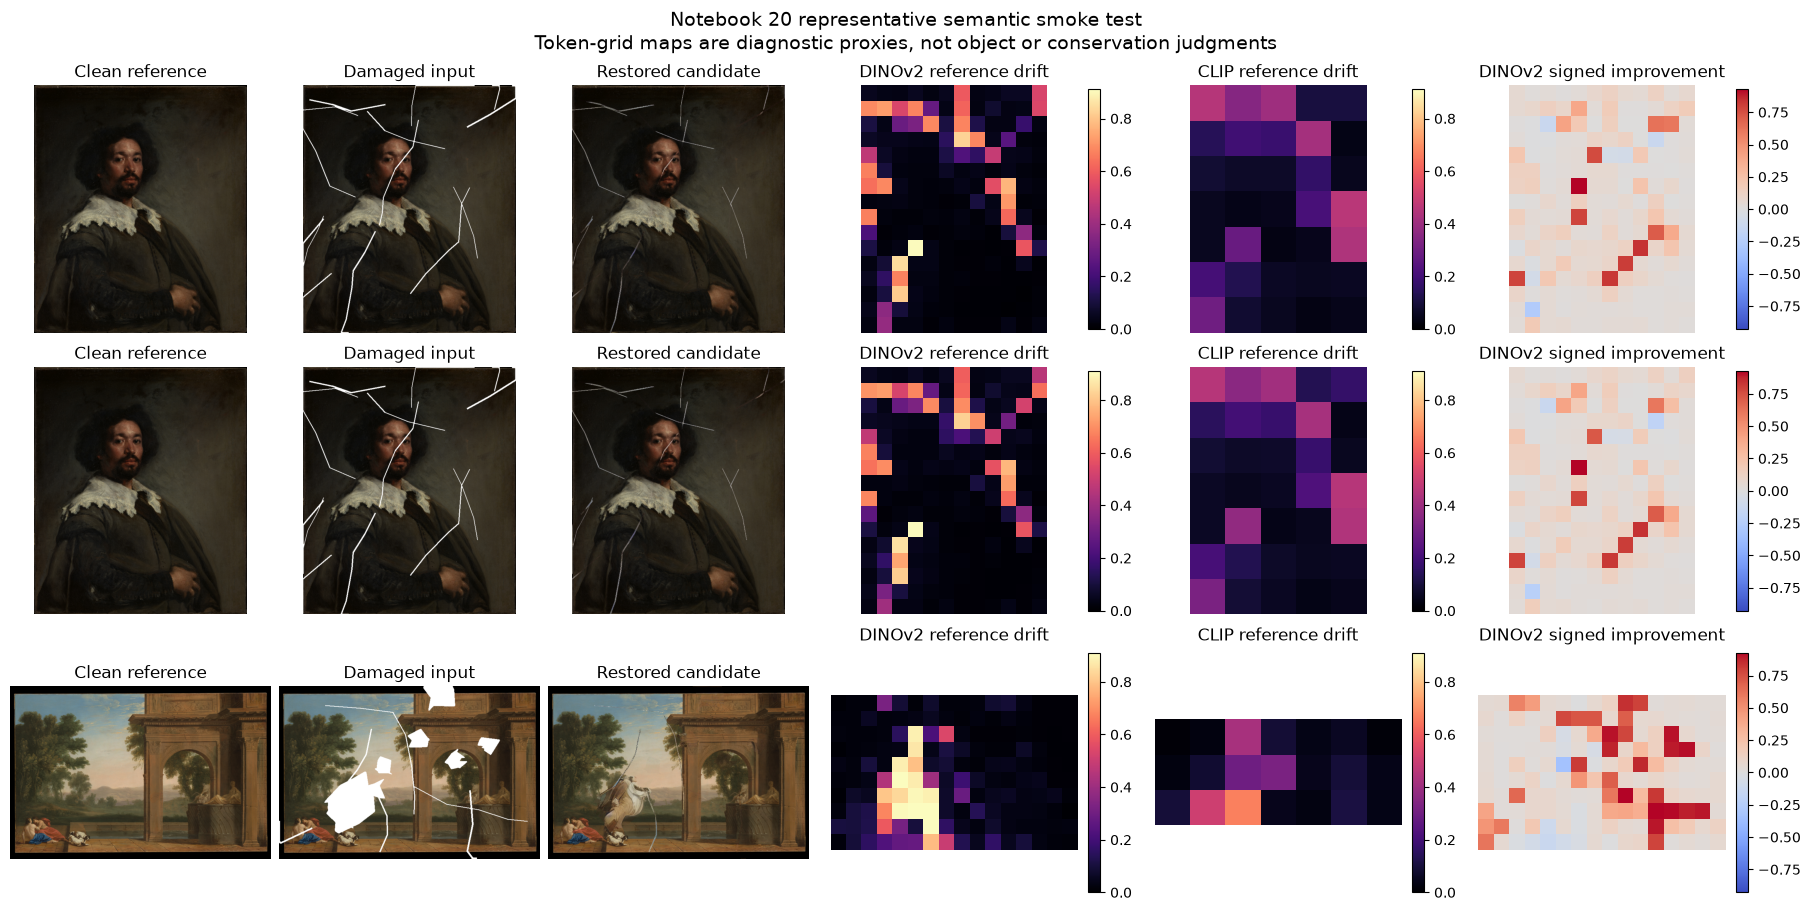

Representative smoke-test figure rendered in notebook.
Drift display maximum: 0.911401
Signed-improvement absolute maximum: 0.927944
Figure file written: No


In [14]:
# ---------------------------------------------------------------------------
# Compact in-notebook visual smoke test
# ---------------------------------------------------------------------------

content_bundle_keys = [
    key
    for key in smoke_bundles
    if key[1] == "content_region"
]

drift_values = []
improvement_values = []

for key in content_bundle_keys:
    bundle = smoke_bundles[key]

    drift_values.extend(
        (
            1.0 - bundle[..., 1]
        )[
            np.isfinite(bundle[..., 1])
        ].tolist()
    )

    improvement_values.extend(
        np.abs(
            bundle[..., 2]
        )[
            np.isfinite(bundle[..., 2])
        ].tolist()
    )

SMOKE_DRIFT_VMAX = max(
    float(
        np.percentile(
            np.asarray(drift_values),
            99.5,
        )
    ),
    1e-6,
)

SMOKE_IMPROVEMENT_ABSMAX = max(
    float(
        np.percentile(
            np.asarray(improvement_values),
            99.5,
        )
    ),
    1e-6,
)

smoke_role_order = [
    "generic_scratch",
    "scratch_aware_scratch",
    "generic_non_scratch",
]

figure, axes = plt.subplots(
    len(smoke_role_order),
    6,
    figsize=(18, 9),
    constrained_layout=True,
)

for row_index, smoke_role in enumerate(
    smoke_role_order
):
    candidate = smoke_candidates_df.loc[
        smoke_candidates_df[
            "smoke_role"
        ].eq(smoke_role)
    ].iloc[0]

    candidate_id = str(
        candidate["candidate_id"]
    )

    clean_rgb, damaged_rgb, restored_rgb = (
        smoke_images[
            (
                candidate_id,
                "content_region",
            )
        ]
    )

    clip_bundle = smoke_bundles[
        (
            candidate_id,
            "content_region",
            "clip_vit_b32",
        )
    ]

    dinov2_bundle = smoke_bundles[
        (
            candidate_id,
            "content_region",
            "dinov2_vits14",
        )
    ]

    image_panels = [
        (
            clean_rgb,
            "Clean reference",
        ),
        (
            damaged_rgb,
            "Damaged input",
        ),
        (
            restored_rgb,
            "Restored candidate",
        ),
    ]

    for column_index, (
        image,
        label,
    ) in enumerate(image_panels):
        axis = axes[
            row_index,
            column_index,
        ]
        axis.imshow(image)
        axis.set_title(label)
        axis.axis("off")

    dino_drift = (
        1.0 - dinov2_bundle[..., 1]
    )
    clip_drift = (
        1.0 - clip_bundle[..., 1]
    )
    dino_improvement = (
        dinov2_bundle[..., 2]
    )

    map_specs = [
        (
            dino_drift,
            "DINOv2 reference drift",
            "magma",
            0.0,
            SMOKE_DRIFT_VMAX,
        ),
        (
            clip_drift,
            "CLIP reference drift",
            "magma",
            0.0,
            SMOKE_DRIFT_VMAX,
        ),
        (
            dino_improvement,
            "DINOv2 signed improvement",
            "coolwarm",
            -SMOKE_IMPROVEMENT_ABSMAX,
            SMOKE_IMPROVEMENT_ABSMAX,
        ),
    ]

    for offset, (
        values,
        label,
        cmap,
        vmin,
        vmax,
    ) in enumerate(map_specs):
        axis = axes[
            row_index,
            offset + 3,
        ]

        rendered = axis.imshow(
            values,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )

        axis.set_title(label)
        axis.axis("off")

        figure.colorbar(
            rendered,
            ax=axis,
            fraction=0.046,
            pad=0.04,
        )

    axes[row_index, 0].set_ylabel(
        (
            f"{smoke_role}\n"
            f"{candidate['case_id']}\n"
            f"{candidate['prompt_variant_id']}"
        ),
        fontsize=9,
    )

figure.suptitle(
    (
        "Notebook 20 representative semantic smoke test\n"
        "Token-grid maps are diagnostic proxies, "
        "not object or conservation judgments"
    ),
    fontsize=14,
)

display(figure)
plt.close(figure)

print("Representative smoke-test figure rendered in notebook.")
print(
    "Drift display maximum:",
    round(SMOKE_DRIFT_VMAX, 6),
)
print(
    "Signed-improvement absolute maximum:",
    round(
        SMOKE_IMPROVEMENT_ABSMAX,
        6,
    ),
)
print("Figure file written: No")

In [15]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_3_representative_smoke_test"
)


def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


observed_smoke_roles = set(
    smoke_candidates_df[
        "smoke_role"
    ].astype(str)
)

expected_smoke_roles = {
    "generic_scratch",
    "scratch_aware_scratch",
    "generic_non_scratch",
}

add_batch_3_check(
    "smoke_population",
    (
        "The smoke test contains the generic scratch, "
        "scratch-aware scratch, and generic non-scratch "
        "candidates."
    ),
    sorted(expected_smoke_roles),
    sorted(observed_smoke_roles),
    (
        len(smoke_candidates_df) == 3
        and observed_smoke_roles
        == expected_smoke_roles
    ),
)

scratch_smoke_df = (
    smoke_candidates_df.loc[
        smoke_candidates_df[
            "smoke_role"
        ].isin(
            {
                "generic_scratch",
                "scratch_aware_scratch",
            }
        )
    ]
)

add_batch_3_check(
    "controlled_scratch_pair",
    (
        "The scratch prompt comparison holds case, "
        "painting, seed, and model constant."
    ),
    {
        "unique_cases": 1,
        "unique_paintings": 1,
        "unique_seeds": 1,
        "unique_models": 1,
        "prompt_variants": 2,
    },
    {
        "unique_cases": scratch_smoke_df[
            "case_id"
        ].nunique(),
        "unique_paintings": scratch_smoke_df[
            "painting_id"
        ].nunique(),
        "unique_seeds": scratch_smoke_df[
            "seed"
        ].nunique(),
        "unique_models": scratch_smoke_df[
            "model_id"
        ].nunique(),
        "prompt_variants": scratch_smoke_df[
            "prompt_variant_id"
        ].nunique(),
    },
    (
        scratch_smoke_df[
            "case_id"
        ].nunique()
        == 1
        and scratch_smoke_df[
            "painting_id"
        ].nunique()
        == 1
        and scratch_smoke_df[
            "seed"
        ].nunique()
        == 1
        and scratch_smoke_df[
            "model_id"
        ].nunique()
        == 1
        and scratch_smoke_df[
            "prompt_variant_id"
        ].nunique()
        == 2
    ),
)

add_batch_3_check(
    "models_evaluation_mode",
    (
        "Both pinned feature encoders are loaded in "
        "evaluation mode."
    ),
    {
        "models": 2,
        "training_mode_rows": 0,
    },
    {
        "models": len(loaded_model_df),
        "training_mode_rows": int(
            loaded_model_df[
                "training_mode"
            ].sum()
        ),
    },
    (
        len(loaded_model_df) == 2
        and not loaded_model_df[
            "training_mode"
        ].any()
    ),
)

add_batch_3_check(
    "smoke_extraction_count",
    (
        "Both encoders process both regions for all "
        "three candidates."
    ),
    12,
    completed_extractions,
    completed_extractions == 12,
)

expected_grid_shapes = {
    "clip_vit_b32": (7, 7),
    "dinov2_vits14": (16, 16),
}

observed_grid_shapes = {
    feature_model_id: tuple(
        smoke_metrics_df.loc[
            smoke_metrics_df[
                "feature_model_id"
            ].eq(feature_model_id),
            [
                "grid_height",
                "grid_width",
            ],
        ]
        .drop_duplicates()
        .iloc[0]
        .astype(int)
    )
    for feature_model_id in FEATURE_MODELS
}

add_batch_3_check(
    "local_token_grids",
    "Both encoders produce their approved token grids.",
    expected_grid_shapes,
    observed_grid_shapes,
    observed_grid_shapes
    == expected_grid_shapes,
)

numeric_smoke_columns = [
    "damaged_clean_mean",
    "restored_clean_mean",
    "signed_improvement_mean",
    "restored_clean_median",
    "restored_clean_p10",
    "worsened_fraction",
]

smoke_numeric_values = (
    smoke_metrics_df[
        numeric_smoke_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(dtype=float)
)

add_batch_3_check(
    "finite_smoke_metrics",
    (
        "All representative local summaries are "
        "finite."
    ),
    True,
    bool(np.isfinite(
        smoke_numeric_values
    ).all()),
    bool(np.isfinite(
        smoke_numeric_values
    ).all()),
)

add_batch_3_check(
    "valid_token_support",
    (
        "Every representative encoder-region result "
        "contains valid non-padding tokens."
    ),
    "all positive",
    smoke_metrics_df[
        "valid_tokens"
    ].astype(int).tolist(),
    smoke_metrics_df[
        "valid_tokens"
    ].astype(int).gt(0).all(),
)

structural_numeric = (
    smoke_structural_df[
        [
            "affinity_correlation",
            "affinity_js_divergence",
            "affinity_centroid_shift",
            "patch_covariance_distance",
        ]
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(dtype=float)
)

add_batch_3_check(
    "finite_structural_diagnostics",
    (
        "All representative DINOv2 structural and "
        "painterly proxy values are finite."
    ),
    {
        "rows": 6,
        "finite": True,
    },
    {
        "rows": len(smoke_structural_df),
        "finite": bool(
            np.isfinite(
                structural_numeric
            ).all()
        ),
    },
    (
        len(smoke_structural_df) == 6
        and np.isfinite(
            structural_numeric
        ).all()
    ),
)

agreement_numeric = (
    smoke_agreement_df[
        [
            "restored_similarity_agreement",
            "signed_improvement_agreement",
        ]
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(dtype=float)
)

add_batch_3_check(
    "finite_encoder_agreement",
    (
        "All representative CLIP–DINOv2 agreement "
        "values are finite."
    ),
    {
        "rows": 6,
        "finite": True,
    },
    {
        "rows": len(smoke_agreement_df),
        "finite": bool(
            np.isfinite(
                agreement_numeric
            ).all()
        ),
    },
    (
        len(smoke_agreement_df) == 6
        and np.isfinite(
            agreement_numeric
        ).all()
    ),
)

current_owned_files = {
    path
    for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

new_owned_files = sorted(
    current_owned_files - preexisting_owned_set
)
missing_owned_files = sorted(
    preexisting_owned_set - current_owned_files
)

add_batch_3_check(
    "no_smoke_files",
    (
        "The smoke test creates no files and preserves "
        "the checkpointed resume state."
    ),
    {"new": 0, "missing": 0},
    {
        "new": len(new_owned_files),
        "missing": len(missing_owned_files),
    },
    not new_owned_files and not missing_owned_files,
    details={
        "new_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in new_owned_files[:10]
        ],
        "missing_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in missing_owned_files[:10]
        ],
    },
)

batch_3_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_3_representative_smoke_test"
        )
    ]
    .reset_index(drop=True)
)

display(batch_3_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 20 Batch 3 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_3_validation_df),
)
print(
    "Blocking failures:",
    len(
        batch_3_validation_df.loc[
            (~batch_3_validation_df["passed"])
            & batch_3_validation_df[
                "severity"
            ].eq("blocking")
        ]
    ),
)
print("Smoke candidates:", len(smoke_candidates_df))
print("Semantic bundles:", len(smoke_bundles))
print(
    "Local summary rows:",
    len(smoke_metrics_df),
)
print(
    "Structural rows:",
    len(smoke_structural_df),
)
print(
    "Agreement rows:",
    len(smoke_agreement_df),
)
print("Restoration inference performed: No")
print("Canonical output files written: No")
print("Batch 3 completion gate passed.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_representative_smoke_test,smoke_population,"The smoke test contains the generic scratch, s...",blocking,"[""generic_non_scratch"", ""generic_scratch"", ""sc...","[""generic_non_scratch"", ""generic_scratch"", ""sc...",True,
1,batch_3_representative_smoke_test,controlled_scratch_pair,"The scratch prompt comparison holds case, pain...",blocking,"{""prompt_variants"": 2, ""unique_cases"": 1, ""uni...","{""prompt_variants"": 2, ""unique_cases"": 1, ""uni...",True,
2,batch_3_representative_smoke_test,models_evaluation_mode,Both pinned feature encoders are loaded in eva...,blocking,"{""models"": 2, ""training_mode_rows"": 0}","{""models"": 2, ""training_mode_rows"": 0}",True,
3,batch_3_representative_smoke_test,smoke_extraction_count,Both encoders process both regions for all thr...,blocking,12,12,True,
4,batch_3_representative_smoke_test,local_token_grids,Both encoders produce their approved token grids.,blocking,"{""clip_vit_b32"": [7, 7], ""dinov2_vits14"": [16,...","{""clip_vit_b32"": [7, 7], ""dinov2_vits14"": [16,...",True,
5,batch_3_representative_smoke_test,finite_smoke_metrics,All representative local summaries are finite.,blocking,True,True,True,
6,batch_3_representative_smoke_test,valid_token_support,Every representative encoder-region result con...,blocking,all positive,"[21, 160, 21, 160, 35, 192, 35, 192, 35, 192, ...",True,
7,batch_3_representative_smoke_test,finite_structural_diagnostics,All representative DINOv2 structural and paint...,blocking,"{""finite"": true, ""rows"": 6}","{""finite"": true, ""rows"": 6}",True,
8,batch_3_representative_smoke_test,finite_encoder_agreement,All representative CLIP–DINOv2 agreement value...,blocking,"{""finite"": true, ""rows"": 6}","{""finite"": true, ""rows"": 6}",True,
9,batch_3_representative_smoke_test,no_smoke_files,The smoke test creates no files and preserves ...,blocking,"{""missing"": 0, ""new"": 0}","{""missing"": 0, ""new"": 0}",True,"{""missing_first_10"": [], ""new_first_10"": []}"


Notebook 20 Batch 3 summary
---------------------------
Validation checks: 10
Blocking failures: 0
Smoke candidates: 3
Semantic bundles: 12
Local summary rows: 12
Structural rows: 6
Agreement rows: 6
Restoration inference performed: No
Canonical output files written: No
Batch 3 completion gate passed.


## Batch 4 — Checkpointed full-population local-token extraction

This batch extracts local CLIP and DINOv2 representations for the complete deduplicated **78,336-record** token plan.

The extraction:

- uses the pinned models and preprocessing validated by Notebook 15;
- preserves the `7 × 7 × 512` CLIP and `16 × 16 × 384` DINOv2 grids;
- stores normalized tokens and global vectors as temporary `float16` work data;
- excludes letterbox padding from valid-token evidence;
- checkpoints every ten token records and prints progress every ten shards;
- backs off inference batch size on CUDA out-of-memory errors;
- validates identities, geometry, checksums, and contracts before reusing work.

No canonical metric, map, figure, manifest, or validation file is written in this batch.

In [16]:
import hashlib
import shutil
import time
import uuid

from restoration_eval.manifests import (
    utc_now_iso,
)

from restoration_eval.semantic_structural import (
    write_dataframe_atomic,
)


# ---------------------------------------------------------------------------
# Extraction and checkpoint contract
# ---------------------------------------------------------------------------

EXECUTION_CONFIG = SEMANTIC_CONFIG[
    "execution"
]

EXTRACTION_SHARD_SIZE = int(
    EXECUTION_CONFIG[
        "checkpoint_interval_candidates"
    ]
)

INITIAL_EXTRACTION_BATCH_SIZE = int(
    EXECUTION_CONFIG["initial_batch_size"]
)

OOM_BATCH_SIZE_BACKOFF = [
    int(value)
    for value in EXECUTION_CONFIG[
        "oom_batch_size_backoff"
    ]
]

PROGRESS_INTERVAL_SHARDS = 10

TOKEN_CACHE_DTYPE = np.dtype(
    EXECUTION_CONFIG[
        "base_token_cache_dtype"
    ]
)

ATOMIC_REPLACE_ATTEMPTS = int(
    EXECUTION_CONFIG[
        "atomic_replace_attempts"
    ]
)

ATOMIC_RETRY_SECONDS = float(
    EXECUTION_CONFIG[
        "atomic_replace_retry_seconds"
    ]
)

BASE_TOKEN_CACHE_ROOT = WORK_PATHS[
    "base_token_cache_root"
]

EXTRACTION_CHECKPOINT_PATH = (
    WORK_PATHS["extraction_checkpoint"]
)

BASE_TOKEN_CACHE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

TOKEN_CACHE_CHECKPOINT_COLUMNS = [
    "shard_id",
    "feature_model_id",
    "shard_number",
    "start_array_index",
    "end_array_index",
    "record_count",
    "plan_contract_sha256",
    "shard_relative_path",
    "shard_sha256",
    "size_bytes",
    "token_grid_height",
    "token_grid_width",
    "embedding_dimension",
    "token_dtype",
    "global_dtype",
    "valid_dtype",
    "valid_token_count",
    "quantization_max_abs_error",
    "runtime_seconds",
    "completed_at_utc",
    "status",
    "issue",
]


# ---------------------------------------------------------------------------
# Require complete source-checksum provenance
# ---------------------------------------------------------------------------

token_plan_checksum_valid = (
    semantic_token_plan_df[
        "source_sha256"
    ]
    .fillna("")
    .astype(str)
    .str.fullmatch(
        r"[0-9a-fA-F]{64}"
    )
)

if not token_plan_checksum_valid.all():
    invalid_rows = semantic_token_plan_df.loc[
        ~token_plan_checksum_valid,
        [
            "token_record_id",
            "source_path",
            "source_sha256",
        ],
    ]

    display(invalid_rows.head(20))

    raise ValueError(
        "The semantic token plan contains missing or "
        "invalid source checksums."
    )


# ---------------------------------------------------------------------------
# Deterministic shard plan and record-to-shard index
# ---------------------------------------------------------------------------

TOKEN_PLAN_CONTRACT_COLUMNS = [
    "token_record_id",
    "feature_model_id",
    "image_role",
    "painting_id",
    "case_id",
    "representative_candidate_id",
    "region_id",
    "source_path",
    "source_sha256",
    "array_index",
    "embedding_dimension",
    "preprocessing_id",
    "model_name",
    "model_revision",
    "model_checksum",
    "crop_x_min",
    "crop_y_min",
    "crop_x_max",
    "crop_y_max",
]

token_shard_records = []
token_cache_index_frames = []

for feature_model_id in (
    SEMANTIC_CONFIG["population"][
        "model_order"
    ]
):
    # Restoration-model order is unrelated to
    # feature-model extraction.
    pass

for feature_model_id in FEATURE_MODELS:
    model_plan = (
        semantic_token_plan_df.loc[
            semantic_token_plan_df[
                "feature_model_id"
            ].astype(str).eq(
                feature_model_id
            )
        ]
        .sort_values(
            "array_index",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    expected_indices = np.arange(
        len(model_plan),
        dtype=np.int64,
    )

    observed_indices = pd.to_numeric(
        model_plan["array_index"],
        errors="raise",
    ).to_numpy(dtype=np.int64)

    if not np.array_equal(
        observed_indices,
        expected_indices,
    ):
        raise ValueError(
            f"{feature_model_id} token-plan indices "
            "are not contiguous from zero."
        )

    model_cache_root = (
        BASE_TOKEN_CACHE_ROOT
        / feature_model_id
    )

    model_cache_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    for shard_number, start in enumerate(
        range(
            0,
            len(model_plan),
            EXTRACTION_SHARD_SIZE,
        )
    ):
        end = min(
            start + EXTRACTION_SHARD_SIZE,
            len(model_plan),
        )

        shard_frame = (
            model_plan.iloc[start:end]
            .copy()
            .reset_index(drop=True)
        )

        shard_id = (
            f"{feature_model_id}__"
            f"{shard_number:04d}"
        )

        shard_path = (
            model_cache_root
            / f"{shard_id}.npz"
        )

        contract_payload = (
            shard_frame[
                TOKEN_PLAN_CONTRACT_COLUMNS
            ]
            .astype(str)
            .to_csv(
                index=False,
                lineterminator="\n",
            )
            .encode("utf-8")
        )

        plan_contract_sha256 = (
            hashlib.sha256(
                contract_payload
            ).hexdigest()
        )

        token_shard_records.append(
            {
                "shard_id": shard_id,
                "feature_model_id": (
                    feature_model_id
                ),
                "shard_number": (
                    shard_number
                ),
                "start_array_index": int(
                    shard_frame[
                        "array_index"
                    ].min()
                ),
                "end_array_index": int(
                    shard_frame[
                        "array_index"
                    ].max()
                ),
                "record_count": len(
                    shard_frame
                ),
                "plan_contract_sha256": (
                    plan_contract_sha256
                ),
                "shard_path": shard_path,
                "shard_relative_path": (
                    to_repo_relative(
                        shard_path,
                        PROJECT_ROOT,
                    )
                ),
            }
        )

        indexed_shard = shard_frame.copy()

        indexed_shard[
            "shard_id"
        ] = shard_id

        indexed_shard[
            "shard_relative_path"
        ] = to_repo_relative(
            shard_path,
            PROJECT_ROOT,
        )

        indexed_shard[
            "shard_offset"
        ] = np.arange(
            len(indexed_shard),
            dtype=np.int64,
        )

        token_cache_index_frames.append(
            indexed_shard
        )

token_shard_plan_df = (
    pd.DataFrame(token_shard_records)
    .sort_values(
        [
            "feature_model_id",
            "shard_number",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

token_cache_index_df = (
    pd.concat(
        token_cache_index_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "feature_model_id",
            "array_index",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Disk-space estimate
# ---------------------------------------------------------------------------

estimated_cache_bytes = 0

for feature_model_id, model_config in (
    FEATURE_MODELS.items()
):
    model_rows = int(
        semantic_token_plan_df[
            "feature_model_id"
        ].astype(str).eq(
            feature_model_id
        ).sum()
    )

    grid_tokens = (
        int(model_config["grid_height"])
        * int(model_config["grid_width"])
    )

    embedding_dimension = int(
        model_config[
            "embedding_dimension"
        ]
    )

    bytes_per_record = (
        grid_tokens
        * embedding_dimension
        * TOKEN_CACHE_DTYPE.itemsize
        + embedding_dimension
        * TOKEN_CACHE_DTYPE.itemsize
        + grid_tokens
    )

    estimated_cache_bytes += (
        model_rows * bytes_per_record
    )

disk_usage = shutil.disk_usage(
    NOTEBOOK_OUTPUT_ROOT
)

disk_preflight_df = pd.DataFrame(
    [
        {
            "estimated_cache_bytes": int(
                estimated_cache_bytes
            ),
            "estimated_cache_gib": (
                estimated_cache_bytes
                / (1024 ** 3)
            ),
            "free_bytes": int(
                disk_usage.free
            ),
            "free_gib": (
                disk_usage.free
                / (1024 ** 3)
            ),
            "minimum_required_bytes": int(
                estimated_cache_bytes * 1.15
            ),
            "sufficient": (
                disk_usage.free
                >= estimated_cache_bytes * 1.15
            ),
        }
    ]
)

if not bool(
    disk_preflight_df.iloc[0]["sufficient"]
):
    display(disk_preflight_df)

    raise OSError(
        "Insufficient free disk space for the "
        "Notebook 20 temporary token cache."
    )

shard_plan_summary_df = (
    token_shard_plan_df
    .groupby(
        "feature_model_id",
        as_index=False,
    )
    .agg(
        shards=(
            "shard_id",
            "size",
        ),
        token_records=(
            "record_count",
            "sum",
        ),
        first_array_index=(
            "start_array_index",
            "min",
        ),
        last_array_index=(
            "end_array_index",
            "max",
        ),
    )
    .sort_values(
        "feature_model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

display(shard_plan_summary_df)
display(disk_preflight_df)

print("Full extraction shard plan constructed.")
print(
    "Token records:",
    len(token_cache_index_df),
)
print(
    "Checkpoint shards:",
    len(token_shard_plan_df),
)
print(
    "Records per full shard:",
    EXTRACTION_SHARD_SIZE,
)
print(
    "Estimated temporary cache GiB:",
    round(
        estimated_cache_bytes
        / (1024 ** 3),
        3,
    ),
)
print(
    "Free disk GiB:",
    round(
        disk_usage.free
        / (1024 ** 3),
        3,
    ),
)

,feature_model_id,shards,token_records,first_array_index,last_array_index
0,clip_vit_b32,3917,39168,0,39167
1,dinov2_vits14,3917,39168,0,39167


,estimated_cache_bytes,estimated_cache_gib,free_bytes,free_gib,minimum_required_bytes,sufficient
0,9748171008,9.078692,827887050752,771.0299,11210396659,True


Full extraction shard plan constructed.
Token records: 78336
Checkpoint shards: 7834
Records per full shard: 10
Estimated temporary cache GiB: 9.079
Free disk GiB: 771.03


In [17]:
# ---------------------------------------------------------------------------
# Resumable shard utilities
# ---------------------------------------------------------------------------

def is_cuda_out_of_memory(error):
    return (
        isinstance(
            error,
            torch.cuda.OutOfMemoryError,
        )
        or "out of memory"
        in str(error).lower()
    )


def atomic_write_token_shard(
    destination,
    arrays,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary = destination.with_name(
        f"{destination.name}."
        f"{uuid.uuid4().hex}.tmp.npz"
    )

    np.savez(
        temporary,
        **arrays,
    )

    last_error = None

    for attempt in range(
        1,
        ATOMIC_REPLACE_ATTEMPTS + 1,
    ):
        try:
            os.replace(
                temporary,
                destination,
            )
            return destination
        except PermissionError as error:
            last_error = error

            if attempt < ATOMIC_REPLACE_ATTEMPTS:
                time.sleep(
                    ATOMIC_RETRY_SECONDS
                    * attempt
                )

    temporary.unlink(missing_ok=True)

    raise PermissionError(
        "Could not replace token-cache shard: "
        f"{last_error}"
    )


def extract_token_shard(
    shard_frame,
    feature_model_id,
):
    patch_batches = []
    global_batches = []
    valid_batches = []

    cursor = 0
    active_batch_size = min(
        INITIAL_EXTRACTION_BATCH_SIZE,
        len(shard_frame),
    )

    while cursor < len(shard_frame):
        remaining = (
            len(shard_frame) - cursor
        )

        attempted_batch_size = min(
            active_batch_size,
            remaining,
        )

        batch_frame = (
            shard_frame.iloc[
                cursor:
                cursor + attempted_batch_size
            ]
        )

        images = []

        for row in batch_frame.itertuples(
            index=False
        ):
            images.append(
                load_rgb_crop(
                    row.source_path,
                    row,
                )
            )

        try:
            (
                patch_tokens,
                global_vectors,
                valid_tokens,
            ) = extract_local_token_batch(
                images,
                feature_model_id=(
                    feature_model_id
                ),
                model_bundle=(
                    semantic_feature_models[
                        feature_model_id
                    ]
                ),
                config=semantic_config,
                device=SEMANTIC_DEVICE,
            )

        except RuntimeError as error:
            if not is_cuda_out_of_memory(
                error
            ):
                raise

            smaller_sizes = [
                value
                for value in (
                    OOM_BATCH_SIZE_BACKOFF
                )
                if value
                < attempted_batch_size
            ]

            if not smaller_sizes:
                raise RuntimeError(
                    "Local-token extraction exhausted "
                    "the approved CUDA OOM backoff."
                ) from error

            active_batch_size = max(
                smaller_sizes
            )

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            print(
                "CUDA OOM backoff:",
                feature_model_id,
                "batch",
                attempted_batch_size,
                "->",
                active_batch_size,
            )

            continue

        if not (
            np.isfinite(
                patch_tokens
            ).all()
            and np.isfinite(
                global_vectors
            ).all()
        ):
            raise ValueError(
                "Local-token extraction produced "
                "non-finite feature values."
            )

        patch_batches.append(
            patch_tokens
        )
        global_batches.append(
            global_vectors
        )
        valid_batches.append(
            valid_tokens.astype(bool)
        )

        cursor += attempted_batch_size

    patch_values = np.concatenate(
        patch_batches,
        axis=0,
    )

    global_values = np.concatenate(
        global_batches,
        axis=0,
    )

    valid_values = np.concatenate(
        valid_batches,
        axis=0,
    )

    if len(patch_values) != len(
        shard_frame
    ):
        raise ValueError(
            "Extracted shard row count does not "
            "match its plan."
        )

    return (
        patch_values,
        global_values,
        valid_values,
    )


def reusable_token_shard(
    checkpoint_record,
    shard_plan_row,
    shard_frame,
):
    if checkpoint_record is None:
        return False, "checkpoint_missing"

    if (
        str(
            checkpoint_record.get(
                "status",
                "",
            )
        )
        != "completed"
    ):
        return False, "checkpoint_not_completed"

    if (
        str(
            checkpoint_record.get(
                "plan_contract_sha256",
                "",
            )
        )
        != str(
            shard_plan_row.plan_contract_sha256
        )
    ):
        return False, "plan_contract_changed"

    shard_path = Path(
        shard_plan_row.shard_path
    )

    if not shard_path.is_file():
        return False, "shard_file_missing"

    observed_sha256 = (
        manifest_sha256_path(
            shard_path
        )
    )

    if observed_sha256 != str(
        checkpoint_record.get(
            "shard_sha256",
            "",
        )
    ):
        return False, "shard_checksum_changed"

    try:
        with np.load(
            shard_path,
            allow_pickle=False,
        ) as archive:
            required_arrays = {
                "token_record_ids",
                "source_sha256",
                "array_indices",
                "patch_tokens",
                "global_vectors",
                "valid_tokens",
            }

            if not required_arrays.issubset(
                archive.files
            ):
                return (
                    False,
                    "required_arrays_missing",
                )

            expected_ids = (
                shard_frame[
                    "token_record_id"
                ]
                .astype(str)
                .to_numpy()
            )

            expected_checksums = (
                shard_frame[
                    "source_sha256"
                ]
                .astype(str)
                .to_numpy()
            )

            expected_indices = (
                pd.to_numeric(
                    shard_frame[
                        "array_index"
                    ],
                    errors="raise",
                )
                .to_numpy(dtype=np.int64)
            )

            observed_ids = (
                archive[
                    "token_record_ids"
                ].astype(str)
            )

            observed_checksums = (
                archive[
                    "source_sha256"
                ].astype(str)
            )

            observed_indices = (
                archive[
                    "array_indices"
                ].astype(np.int64)
            )

            patch_tokens = archive[
                "patch_tokens"
            ]

            global_vectors = archive[
                "global_vectors"
            ]

            valid_tokens = archive[
                "valid_tokens"
            ]

            model_config = FEATURE_MODELS[
                str(
                    shard_plan_row
                    .feature_model_id
                )
            ]

            expected_patch_shape = (
                len(shard_frame),
                int(
                    model_config[
                        "grid_height"
                    ]
                ),
                int(
                    model_config[
                        "grid_width"
                    ]
                ),
                int(
                    model_config[
                        "embedding_dimension"
                    ]
                ),
            )

            expected_global_shape = (
                len(shard_frame),
                int(
                    model_config[
                        "embedding_dimension"
                    ]
                ),
            )

            expected_valid_shape = (
                len(shard_frame),
                int(
                    model_config[
                        "grid_height"
                    ]
                ),
                int(
                    model_config[
                        "grid_width"
                    ]
                ),
            )

            if not np.array_equal(
                observed_ids,
                expected_ids,
            ):
                return (
                    False,
                    "token_record_ids_changed",
                )

            if not np.array_equal(
                observed_checksums,
                expected_checksums,
            ):
                return (
                    False,
                    "source_checksums_changed",
                )

            if not np.array_equal(
                observed_indices,
                expected_indices,
            ):
                return (
                    False,
                    "array_indices_changed",
                )

            if (
                patch_tokens.shape
                != expected_patch_shape
                or global_vectors.shape
                != expected_global_shape
                or valid_tokens.shape
                != expected_valid_shape
            ):
                return (
                    False,
                    "cached_array_shape_changed",
                )

            if (
                patch_tokens.dtype
                != TOKEN_CACHE_DTYPE
                or global_vectors.dtype
                != TOKEN_CACHE_DTYPE
                or valid_tokens.dtype
                != np.dtype("uint8")
            ):
                return (
                    False,
                    "cached_array_dtype_changed",
                )

    except Exception as error:
        return (
            False,
            f"cache_read_error:{type(error).__name__}",
        )

    return True, "verified_reuse"


print("Checkpoint and extraction utilities ready.")
print(
    "Initial inference batch size:",
    INITIAL_EXTRACTION_BATCH_SIZE,
)
print(
    "CUDA OOM backoff:",
    OOM_BATCH_SIZE_BACKOFF,
)
print(
    "Atomic replace attempts:",
    ATOMIC_REPLACE_ATTEMPTS,
)

Checkpoint and extraction utilities ready.
Initial inference batch size: 16
CUDA OOM backoff: [8, 4, 2, 1]
Atomic replace attempts: 8


In [18]:
# ---------------------------------------------------------------------------
# Load an existing checkpoint for strict resume
# ---------------------------------------------------------------------------

if EXTRACTION_CHECKPOINT_PATH.is_file():
    existing_checkpoint_df = pd.read_csv(
        EXTRACTION_CHECKPOINT_PATH,
        low_memory=False,
    )

    missing_checkpoint_columns = sorted(
        set(
            TOKEN_CACHE_CHECKPOINT_COLUMNS
        )
        - set(
            existing_checkpoint_df.columns
        )
    )

    if missing_checkpoint_columns:
        raise ValueError(
            "Existing extraction checkpoint is "
            "missing columns: "
            f"{missing_checkpoint_columns}"
        )

    if existing_checkpoint_df[
        "shard_id"
    ].astype(str).duplicated().any():
        raise ValueError(
            "Existing extraction checkpoint repeats "
            "shard_id."
        )

    checkpoint_by_shard = {
        str(record["shard_id"]): record
        for record in (
            existing_checkpoint_df[
                TOKEN_CACHE_CHECKPOINT_COLUMNS
            ].to_dict("records")
        )
    }

else:
    checkpoint_by_shard = {}

planned_shard_ids = set(
    token_shard_plan_df[
        "shard_id"
    ].astype(str)
)

unexpected_checkpoint_shards = sorted(
    set(checkpoint_by_shard)
    - planned_shard_ids
)

if unexpected_checkpoint_shards:
    raise ValueError(
        "The extraction checkpoint contains shards "
        "outside the current contract: "
        f"{unexpected_checkpoint_shards[:10]}"
    )


# ---------------------------------------------------------------------------
# Checkpointed full extraction
# ---------------------------------------------------------------------------

extraction_started_at = time.perf_counter()

new_shards = 0
reused_shards = 0
recomputed_shards = 0

total_shards = len(
    token_shard_plan_df
)

total_records = int(
    token_shard_plan_df[
        "record_count"
    ].sum()
)

completed_shards = 0
completed_records = 0

for feature_model_id in FEATURE_MODELS:
    model_shard_plan = (
        token_shard_plan_df.loc[
            token_shard_plan_df[
                "feature_model_id"
            ].astype(str).eq(
                feature_model_id
            )
        ]
        .sort_values(
            "shard_number",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    print()
    print(
        "Starting feature-model extraction:",
        feature_model_id,
    )
    print(
        "Model shards:",
        len(model_shard_plan),
    )
    print(
        "Model token records:",
        int(
            model_shard_plan[
                "record_count"
            ].sum()
        ),
    )

    for (
        model_shard_number,
        shard_plan_row,
    ) in enumerate(
        model_shard_plan.itertuples(
            index=False
        ),
        start=1,
    ):
        shard_id = str(
            shard_plan_row.shard_id
        )

        shard_frame = (
            token_cache_index_df.loc[
                token_cache_index_df[
                    "shard_id"
                ].astype(str).eq(
                    shard_id
                )
            ]
            .sort_values(
                "shard_offset",
                kind="stable",
            )
            .reset_index(drop=True)
        )

        existing_record = (
            checkpoint_by_shard.get(
                shard_id
            )
        )

        reusable, reuse_reason = (
            reusable_token_shard(
                existing_record,
                shard_plan_row,
                shard_frame,
            )
        )

        if reusable:
            reused_shards += 1

        else:
            shard_started_at = (
                time.perf_counter()
            )

            (
                patch_tokens,
                global_vectors,
                valid_tokens,
            ) = extract_token_shard(
                shard_frame,
                feature_model_id,
            )

            stored_patch_tokens = (
                patch_tokens.astype(
                    TOKEN_CACHE_DTYPE
                )
            )

            stored_global_vectors = (
                global_vectors.astype(
                    TOKEN_CACHE_DTYPE
                )
            )

            stored_valid_tokens = (
                valid_tokens.astype(
                    np.uint8
                )
            )

            quantization_max_abs_error = max(
                float(
                    np.max(
                        np.abs(
                            patch_tokens
                            - stored_patch_tokens
                            .astype(np.float32)
                        )
                    )
                ),
                float(
                    np.max(
                        np.abs(
                            global_vectors
                            - stored_global_vectors
                            .astype(np.float32)
                        )
                    )
                ),
            )

            shard_path = Path(
                shard_plan_row.shard_path
            )

            # Fixed-width Unicode is required here.
            # A Pandas Series converted without an
            # explicit dtype becomes a NumPy object
            # array, which cannot later be opened with
            # allow_pickle=False.
            token_record_ids = np.asarray(
                shard_frame[
                    "token_record_id"
                ]
                .fillna("")
                .astype(str)
                .tolist(),
                dtype=str,
            )

            source_checksums = np.asarray(
                shard_frame[
                    "source_sha256"
                ]
                .fillna("")
                .astype(str)
                .tolist(),
                dtype=str,
            )

            array_indices = (
                pd.to_numeric(
                    shard_frame[
                        "array_index"
                    ],
                    errors="raise",
                )
                .to_numpy(
                    dtype=np.int64
                )
            )

            if token_record_ids.dtype.hasobject:
                raise TypeError(
                    "token_record_ids unexpectedly "
                    "uses object dtype."
                )

            if source_checksums.dtype.hasobject:
                raise TypeError(
                    "source_sha256 unexpectedly uses "
                    "object dtype."
                )

            if len(token_record_ids) != len(
                shard_frame
            ):
                raise ValueError(
                    "Token-record identifier count "
                    "does not match the shard plan."
                )

            if len(source_checksums) != len(
                shard_frame
            ):
                raise ValueError(
                    "Source-checksum count does not "
                    "match the shard plan."
                )

            if len(array_indices) != len(
                shard_frame
            ):
                raise ValueError(
                    "Array-index count does not match "
                    "the shard plan."
                )

            atomic_write_token_shard(
                shard_path,
                {
                    "token_record_ids": (
                        token_record_ids
                    ),
                    "source_sha256": (
                        source_checksums
                    ),
                    "array_indices": (
                        array_indices
                    ),
                    "patch_tokens": (
                        stored_patch_tokens
                    ),
                    "global_vectors": (
                        stored_global_vectors
                    ),
                    "valid_tokens": (
                        stored_valid_tokens
                    ),
                },
            )

            # Immediately prove that the newly written
            # metadata is readable without pickle.
            with np.load(
                shard_path,
                allow_pickle=False,
            ) as written_archive:
                written_token_ids = (
                    written_archive[
                        "token_record_ids"
                    ].astype(str)
                )

                written_checksums = (
                    written_archive[
                        "source_sha256"
                    ].astype(str)
                )

                written_indices = (
                    written_archive[
                        "array_indices"
                    ].astype(np.int64)
                )

                written_patch_shape = (
                    written_archive[
                        "patch_tokens"
                    ].shape
                )

                written_global_shape = (
                    written_archive[
                        "global_vectors"
                    ].shape
                )

                written_valid_shape = (
                    written_archive[
                        "valid_tokens"
                    ].shape
                )

            if not np.array_equal(
                written_token_ids,
                token_record_ids,
            ):
                raise ValueError(
                    "Written token identifiers do not "
                    "match the shard plan."
                )

            if not np.array_equal(
                written_checksums,
                source_checksums,
            ):
                raise ValueError(
                    "Written source checksums do not "
                    "match the shard plan."
                )

            if not np.array_equal(
                written_indices,
                array_indices,
            ):
                raise ValueError(
                    "Written array indices do not "
                    "match the shard plan."
                )

            if written_patch_shape != (
                stored_patch_tokens.shape
            ):
                raise ValueError(
                    "Written patch-token shape changed."
                )

            if written_global_shape != (
                stored_global_vectors.shape
            ):
                raise ValueError(
                    "Written global-vector shape changed."
                )

            if written_valid_shape != (
                stored_valid_tokens.shape
            ):
                raise ValueError(
                    "Written valid-token shape changed."
                )

            shard_sha256 = (
                manifest_sha256_path(
                    shard_path
                )
            )

            model_config = FEATURE_MODELS[
                feature_model_id
            ]

            checkpoint_by_shard[
                shard_id
            ] = {
                "shard_id": shard_id,
                "feature_model_id": (
                    feature_model_id
                ),
                "shard_number": int(
                    shard_plan_row.shard_number
                ),
                "start_array_index": int(
                    shard_plan_row
                    .start_array_index
                ),
                "end_array_index": int(
                    shard_plan_row
                    .end_array_index
                ),
                "record_count": len(
                    shard_frame
                ),
                "plan_contract_sha256": (
                    shard_plan_row
                    .plan_contract_sha256
                ),
                "shard_relative_path": (
                    shard_plan_row
                    .shard_relative_path
                ),
                "shard_sha256": (
                    shard_sha256
                ),
                "size_bytes": int(
                    shard_path.stat().st_size
                ),
                "token_grid_height": int(
                    model_config[
                        "grid_height"
                    ]
                ),
                "token_grid_width": int(
                    model_config[
                        "grid_width"
                    ]
                ),
                "embedding_dimension": int(
                    model_config[
                        "embedding_dimension"
                    ]
                ),
                "token_dtype": str(
                    stored_patch_tokens.dtype
                ),
                "global_dtype": str(
                    stored_global_vectors.dtype
                ),
                "valid_dtype": str(
                    stored_valid_tokens.dtype
                ),
                "valid_token_count": int(
                    stored_valid_tokens.sum()
                ),
                "quantization_max_abs_error": (
                    quantization_max_abs_error
                ),
                "runtime_seconds": float(
                    time.perf_counter()
                    - shard_started_at
                ),
                "completed_at_utc": (
                    utc_now_iso()
                ),
                "status": "completed",
                "issue": "",
            }

            if existing_record is None:
                new_shards += 1
            else:
                recomputed_shards += 1

            checkpoint_frame = (
                pd.DataFrame(
                    checkpoint_by_shard.values(),
                    columns=(
                        TOKEN_CACHE_CHECKPOINT_COLUMNS
                    ),
                )
                .sort_values(
                    [
                        "feature_model_id",
                        "shard_number",
                    ],
                    kind="stable",
                )
                .reset_index(drop=True)
            )

            write_dataframe_atomic(
                checkpoint_frame,
                EXTRACTION_CHECKPOINT_PATH,
                attempts=(
                    ATOMIC_REPLACE_ATTEMPTS
                ),
                retry_delay_seconds=(
                    ATOMIC_RETRY_SECONDS
                ),
            )

            del patch_tokens
            del global_vectors
            del valid_tokens
            del stored_patch_tokens
            del stored_global_vectors
            del stored_valid_tokens
            del token_record_ids
            del source_checksums
            del array_indices

        completed_shards += 1
        completed_records += int(
            shard_plan_row.record_count
        )

        if (
            model_shard_number
            % PROGRESS_INTERVAL_SHARDS
            == 0
            or model_shard_number
            == len(model_shard_plan)
        ):
            print(
                f"[{feature_model_id}] "
                f"{model_shard_number}/"
                f"{len(model_shard_plan)} shards | "
                f"{completed_shards}/"
                f"{total_shards} total shards | "
                f"{completed_records}/"
                f"{total_records} token records | "
                f"new={new_shards}, "
                f"reused={reused_shards}, "
                f"recomputed={recomputed_shards}"
            )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

extraction_runtime_seconds = (
    time.perf_counter()
    - extraction_started_at
)

extraction_checkpoint_df = (
    pd.DataFrame(
        checkpoint_by_shard.values(),
        columns=TOKEN_CACHE_CHECKPOINT_COLUMNS,
    )
    .sort_values(
        [
            "feature_model_id",
            "shard_number",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

write_dataframe_atomic(
    extraction_checkpoint_df,
    EXTRACTION_CHECKPOINT_PATH,
    attempts=ATOMIC_REPLACE_ATTEMPTS,
    retry_delay_seconds=(
        ATOMIC_RETRY_SECONDS
    ),
)

print()
print("Full local-token extraction completed.")
print(
    "Checkpoint shards:",
    len(extraction_checkpoint_df),
)
print(
    "Token records:",
    int(
        extraction_checkpoint_df[
            "record_count"
        ].sum()
    ),
)
print("New shards:", new_shards)
print("Reused shards:", reused_shards)
print("Recomputed shards:", recomputed_shards)
print(
    "Runtime seconds:",
    round(
        extraction_runtime_seconds,
        3,
    ),
)
print(
    "Checkpoint:",
    to_repo_relative(
        EXTRACTION_CHECKPOINT_PATH,
        PROJECT_ROOT,
    ),
)


Starting feature-model extraction: clip_vit_b32
Model shards: 3917
Model token records: 39168
[clip_vit_b32] 10/3917 shards | 10/7834 total shards | 100/78336 token records | new=0, reused=10, recomputed=0
[clip_vit_b32] 20/3917 shards | 20/7834 total shards | 200/78336 token records | new=0, reused=20, recomputed=0
[clip_vit_b32] 30/3917 shards | 30/7834 total shards | 300/78336 token records | new=0, reused=30, recomputed=0
[clip_vit_b32] 40/3917 shards | 40/7834 total shards | 400/78336 token records | new=0, reused=40, recomputed=0
[clip_vit_b32] 50/3917 shards | 50/7834 total shards | 500/78336 token records | new=0, reused=50, recomputed=0
[clip_vit_b32] 60/3917 shards | 60/7834 total shards | 600/78336 token records | new=0, reused=60, recomputed=0
[clip_vit_b32] 70/3917 shards | 70/7834 total shards | 700/78336 token records | new=0, reused=70, recomputed=0
[clip_vit_b32] 80/3917 shards | 80/7834 total shards | 800/78336 token records | new=0, reused=80, recomputed=0
[clip_vit

In [19]:
# ---------------------------------------------------------------------------
# Full token-cache audit
# ---------------------------------------------------------------------------

checkpoint_file_audit_records = []

for row in extraction_checkpoint_df.itertuples(
    index=False
):
    shard_path = resolve_repo_path(
        row.shard_relative_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    checkpoint_file_audit_records.append(
        {
            "shard_id": row.shard_id,
            "feature_model_id": (
                row.feature_model_id
            ),
            "exists": shard_path.is_file(),
            "size_bytes": (
                int(
                    shard_path.stat().st_size
                )
                if shard_path.is_file()
                else 0
            ),
            "checkpoint_size_bytes": int(
                row.size_bytes
            ),
            "size_matches": (
                shard_path.is_file()
                and int(
                    shard_path.stat().st_size
                )
                == int(row.size_bytes)
            ),
        }
    )

checkpoint_file_audit_df = (
    pd.DataFrame(
        checkpoint_file_audit_records
    )
)

token_cache_summary_df = (
    extraction_checkpoint_df
    .groupby(
        "feature_model_id",
        as_index=False,
    )
    .agg(
        shards=(
            "shard_id",
            "size",
        ),
        token_records=(
            "record_count",
            "sum",
        ),
        cache_bytes=(
            "size_bytes",
            "sum",
        ),
        valid_token_count=(
            "valid_token_count",
            "sum",
        ),
        maximum_quantization_error=(
            "quantization_max_abs_error",
            "max",
        ),
        extraction_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
    )
    .sort_values(
        "feature_model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

token_index_coverage_df = (
    token_cache_index_df
    .groupby(
        "feature_model_id",
        as_index=False,
    )
    .agg(
        token_records=(
            "token_record_id",
            "size",
        ),
        unique_token_records=(
            "token_record_id",
            "nunique",
        ),
        unique_array_indices=(
            "array_index",
            "nunique",
        ),
        first_array_index=(
            "array_index",
            "min",
        ),
        last_array_index=(
            "array_index",
            "max",
        ),
    )
    .sort_values(
        "feature_model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_files_written = []

for output_key, output_path in (
    OUTPUTS.items()
):
    if output_key == "map_images_root":
        canonical_files_written.extend(
            path
            for path in output_path.rglob("*")
            if path.is_file()
        )
    elif output_path.is_file():
        canonical_files_written.append(
            output_path
        )

display(token_cache_summary_df)
display(token_index_coverage_df)
display(
    checkpoint_file_audit_df.loc[
        ~checkpoint_file_audit_df[
            "exists"
        ]
        | ~checkpoint_file_audit_df[
            "size_matches"
        ]
    ]
)


# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_4_full_token_extraction"
)


def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_shards_per_model = {
    feature_model_id: int(
        np.ceil(
            expected_tokens_per_model
            / EXTRACTION_SHARD_SIZE
        )
    )
    for feature_model_id in FEATURE_MODELS
}

observed_shards_per_model = {
    str(row.feature_model_id): int(
        row.shards
    )
    for row in token_cache_summary_df.itertuples(
        index=False
    )
}

add_batch_4_check(
    "checkpoint_shard_count",
    (
        "The checkpoint contains every planned "
        "feature-model shard."
    ),
    {
        "total": len(
            token_shard_plan_df
        ),
        "by_model": (
            expected_shards_per_model
        ),
    },
    {
        "total": len(
            extraction_checkpoint_df
        ),
        "by_model": (
            observed_shards_per_model
        ),
    },
    (
        len(extraction_checkpoint_df)
        == len(token_shard_plan_df)
        and observed_shards_per_model
        == expected_shards_per_model
    ),
)

add_batch_4_check(
    "token_record_count",
    (
        "Checkpointed shards contain all 10,700 "
        "deduplicated token records."
    ),
    EXPECTED_COUNTS[
        "source_token_records"
    ],
    int(
        extraction_checkpoint_df[
            "record_count"
        ].sum()
    ),
    int(
        extraction_checkpoint_df[
            "record_count"
        ].sum()
    )
    == EXPECTED_COUNTS[
        "source_token_records"
    ],
)

add_batch_4_check(
    "checkpoint_status",
    "Every extraction shard completed successfully.",
    {
        "completed": len(
            token_shard_plan_df
        )
    },
    extraction_checkpoint_df[
        "status"
    ].value_counts().to_dict(),
    extraction_checkpoint_df[
        "status"
    ].astype(str).eq(
        "completed"
    ).all(),
)

add_batch_4_check(
    "token_index_identity",
    (
        "Token IDs and model-local array indices are "
        "complete and unique."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "source_token_records"
        ],
        "duplicate_token_ids": 0,
        "duplicate_model_indices": 0,
    },
    {
        "rows": len(
            token_cache_index_df
        ),
        "duplicate_token_ids": int(
            token_cache_index_df[
                "token_record_id"
            ].astype(str).duplicated(
                keep=False
            ).sum()
        ),
        "duplicate_model_indices": int(
            token_cache_index_df
            .duplicated(
                [
                    "feature_model_id",
                    "array_index",
                ],
                keep=False,
            )
            .sum()
        ),
    },
    (
        len(token_cache_index_df)
        == EXPECTED_COUNTS[
            "source_token_records"
        ]
        and not token_cache_index_df[
            "token_record_id"
        ].astype(str).duplicated().any()
        and not token_cache_index_df
        .duplicated(
            [
                "feature_model_id",
                "array_index",
            ]
        )
        .any()
    ),
)

add_batch_4_check(
    "token_cache_files",
    (
        "Every checkpointed shard exists and retains "
        "its recorded byte size."
    ),
    {
        "missing": 0,
        "size_mismatches": 0,
    },
    {
        "missing": int(
            (
                ~checkpoint_file_audit_df[
                    "exists"
                ]
            ).sum()
        ),
        "size_mismatches": int(
            (
                ~checkpoint_file_audit_df[
                    "size_matches"
                ]
            ).sum()
        ),
    },
    (
        checkpoint_file_audit_df[
            "exists"
        ].all()
        and checkpoint_file_audit_df[
            "size_matches"
        ].all()
    ),
)

add_batch_4_check(
    "token_cache_dtype",
    (
        "Patch and global features use float16 work "
        "storage and support masks use uint8."
    ),
    {
        "token_dtype": "float16",
        "global_dtype": "float16",
        "valid_dtype": "uint8",
    },
    {
        "token_dtype": sorted(
            extraction_checkpoint_df[
                "token_dtype"
            ].astype(str).unique()
        ),
        "global_dtype": sorted(
            extraction_checkpoint_df[
                "global_dtype"
            ].astype(str).unique()
        ),
        "valid_dtype": sorted(
            extraction_checkpoint_df[
                "valid_dtype"
            ].astype(str).unique()
        ),
    },
    (
        extraction_checkpoint_df[
            "token_dtype"
        ].astype(str).eq(
            "float16"
        ).all()
        and extraction_checkpoint_df[
            "global_dtype"
        ].astype(str).eq(
            "float16"
        ).all()
        and extraction_checkpoint_df[
            "valid_dtype"
        ].astype(str).eq(
            "uint8"
        ).all()
    ),
)

maximum_quantization_error = float(
    pd.to_numeric(
        extraction_checkpoint_df[
            "quantization_max_abs_error"
        ],
        errors="raise",
    ).max()
)

add_batch_4_check(
    "float16_quantization",
    (
        "Temporary float16 quantization remains within "
        "the approved absolute tolerance."
    ),
    SEMANTIC_CONFIG[
        "numeric_maps"
    ][
        "archive_quantization_tolerance"
    ],
    maximum_quantization_error,
    maximum_quantization_error
    <= float(
        SEMANTIC_CONFIG[
            "numeric_maps"
        ][
            "archive_quantization_tolerance"
        ]
    ),
)

add_batch_4_check(
    "valid_token_support",
    (
        "Every shard retains at least one valid "
        "non-padding token."
    ),
    "all positive",
    {
        "minimum": int(
            extraction_checkpoint_df[
                "valid_token_count"
            ].min()
        ),
        "total": int(
            extraction_checkpoint_df[
                "valid_token_count"
            ].sum()
        ),
    },
    pd.to_numeric(
        extraction_checkpoint_df[
            "valid_token_count"
        ],
        errors="raise",
    ).gt(0).all(),
)

observed_canonical_files = set(
    canonical_files_written
)
new_canonical_files = sorted(
    observed_canonical_files
    - PREEXISTING_CANONICAL_FILES
)
missing_existing_panels = sorted(
    PREEXISTING_CANONICAL_FILES
    - observed_canonical_files
)

add_batch_4_check(
    "no_canonical_outputs",
    (
        "Batch 4 adds no canonical outputs and "
        "preserves existing Batch 6 panels."
    ),
    {"new": 0, "missing": 0},
    {
        "new": len(new_canonical_files),
        "missing": len(missing_existing_panels),
    },
    (
        not new_canonical_files
        and not missing_existing_panels
    ),
    details={
        "new_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in new_canonical_files[:10]
        ],
        "missing_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in missing_existing_panels[:10]
        ],
    },
)

batch_4_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_4_full_token_extraction"
        )
    ]
    .reset_index(drop=True)
)

display(batch_4_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 20 Batch 4 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_4_validation_df),
)
print(
    "Blocking failures:",
    len(
        batch_4_validation_df.loc[
            (~batch_4_validation_df["passed"])
            & batch_4_validation_df[
                "severity"
            ].eq("blocking")
        ]
    ),
)
print(
    "Checkpoint shards:",
    len(extraction_checkpoint_df),
)
print(
    "Token records:",
    int(
        extraction_checkpoint_df[
            "record_count"
        ].sum()
    ),
)
print(
    "Temporary cache GiB:",
    round(
        int(
            extraction_checkpoint_df[
                "size_bytes"
            ].sum()
        )
        / (1024 ** 3),
        3,
    ),
)
print(
    "Maximum float16 error:",
    maximum_quantization_error,
)
print(
    "Extraction runtime seconds:",
    round(
        extraction_runtime_seconds,
        3,
    ),
)
print("Canonical output files written: No")
print("Batch 4 completion gate passed.")

,feature_model_id,shards,token_records,cache_bytes,valid_token_count,maximum_quantization_error,extraction_runtime_seconds
0,clip_vit_b32,3917,39168,2027586670,1230299,0.000244,3436.817181
1,dinov2_vits14,3917,39168,7761116014,7175312,0.000211,3837.823455


,feature_model_id,token_records,unique_token_records,unique_array_indices,first_array_index,last_array_index
0,clip_vit_b32,39168,39168,39168,0,39167
1,dinov2_vits14,39168,39168,39168,0,39167


,shard_id,feature_model_id,exists,size_bytes,checkpoint_size_bytes,size_matches


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_full_token_extraction,checkpoint_shard_count,The checkpoint contains every planned feature-...,blocking,"{""by_model"": {""clip_vit_b32"": 3917, ""dinov2_vi...","{""by_model"": {""clip_vit_b32"": 3917, ""dinov2_vi...",True,
1,batch_4_full_token_extraction,token_record_count,"Checkpointed shards contain all 10,700 dedupli...",blocking,78336,78336,True,
2,batch_4_full_token_extraction,checkpoint_status,Every extraction shard completed successfully.,blocking,"{""completed"": 7834}","{""completed"": 7834}",True,
3,batch_4_full_token_extraction,token_index_identity,Token IDs and model-local array indices are co...,blocking,"{""duplicate_model_indices"": 0, ""duplicate_toke...","{""duplicate_model_indices"": 0, ""duplicate_toke...",True,
4,batch_4_full_token_extraction,token_cache_files,Every checkpointed shard exists and retains it...,blocking,"{""missing"": 0, ""size_mismatches"": 0}","{""missing"": 0, ""size_mismatches"": 0}",True,
5,batch_4_full_token_extraction,token_cache_dtype,Patch and global features use float16 work sto...,blocking,"{""global_dtype"": ""float16"", ""token_dtype"": ""fl...","{""global_dtype"": [""float16""], ""token_dtype"": [...",True,
6,batch_4_full_token_extraction,float16_quantization,Temporary float16 quantization remains within ...,blocking,0.0005,0.000244140625,True,
7,batch_4_full_token_extraction,valid_token_support,Every shard retains at least one valid non-pad...,blocking,all positive,"{""minimum"": 126, ""total"": 8405611}",True,
8,batch_4_full_token_extraction,no_canonical_outputs,Batch 4 adds no canonical outputs and preserve...,blocking,"{""missing"": 0, ""new"": 0}","{""missing"": 0, ""new"": 0}",True,"{""missing_first_10"": [], ""new_first_10"": []}"


Notebook 20 Batch 4 summary
---------------------------
Validation checks: 9
Blocking failures: 0
Checkpoint shards: 7834
Token records: 78336
Temporary cache GiB: 9.116
Maximum float16 error: 0.000244140625
Extraction runtime seconds: 613.456
Canonical output files written: No
Batch 4 completion gate passed.


## Batch 5 — Semantic metrics and numeric-map bundles

This batch uses the validated temporary token cache to construct separate semantic and structural evidence:

- 32,808 linked global subject-preservation rows from Notebook 15;
- 189,648 local similarity summaries;
- 63,216 local worsened-fraction rows;
- 32,808 outside-mask context-preservation rows;
- 65,616 DINOv2 structural-layout rows;
- 31,608 DINOv2 painterly-representation proxy rows;
- 31,608 CLIP–DINOv2 local-map agreement rows;
- 63,216 seven-channel numeric semantic bundles.

That is **447,312 metric rows**. Content summaries exclude padding; mask-bounding-box summaries weight token overlap with the active mask. Computation is checkpointed under `work/semantic_bundles/`. No combined semantic score, confidence value, or final trustworthiness flag is created.

In [20]:
from collections import OrderedDict
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image as PILImage

import restoration_eval.semantic_structural as semantic_structural_module


semantic_structural_module = importlib.reload(
    semantic_structural_module
)

from restoration_eval.metrics_feature_similarity import (
    embedding_id_for,
)

from restoration_eval.semantic_structural import (
    SEMANTIC_STRUCTURAL_MODULE_VERSION as ACTIVE_SEMANTIC_HELPER_VERSION,
    affinity_layout_metrics,
    affinity_weighted_similarity,
    build_semantic_metric_record,
    compute_local_semantic_bundle,
    letterbox_support_mask,
    local_worsened_fraction,
    make_semantic_map_asset_id,
    map_agreement,
    patch_covariance_distance,
    summarize_similarity_channel,
    validate_semantic_metrics,
)


if ACTIVE_SEMANTIC_HELPER_VERSION != "1.0.3":
    raise RuntimeError(
        "Notebook 20 requires semantic helper version 1.0.3."
    )

SEMANTIC_STRUCTURAL_MODULE_VERSION = (
    ACTIVE_SEMANTIC_HELPER_VERSION
)


# ---------------------------------------------------------------------------
# Bounded token-shard reader
# ---------------------------------------------------------------------------

class TokenShardReader:
    def __init__(
        self,
        index_frame,
        project_root,
        max_cached_shards=24,
    ):
        if index_frame[
            "token_record_id"
        ].astype(str).duplicated().any():
            raise ValueError(
                "Token cache index repeats token_record_id."
            )

        self.index = {
            str(record["token_record_id"]): record
            for record in index_frame.to_dict("records")
        }

        self.project_root = Path(project_root)
        self.max_cached_shards = int(max_cached_shards)

        self.cache = OrderedDict()
        self.cache_hits = 0
        self.cache_misses = 0

    def _load_shard(self, relative_path):
        relative_path = str(relative_path)

        if relative_path in self.cache:
            self.cache_hits += 1

            arrays = self.cache.pop(relative_path)
            self.cache[relative_path] = arrays

            return arrays

        self.cache_misses += 1

        path = resolve_repo_path(
            relative_path,
            self.project_root,
            must_exist=True,
        )

        with np.load(
            path,
            allow_pickle=False,
        ) as archive:
            required_arrays = {
                "token_record_ids",
                "source_sha256",
                "array_indices",
                "patch_tokens",
                "global_vectors",
                "valid_tokens",
            }

            missing_arrays = sorted(
                required_arrays - set(archive.files)
            )

            if missing_arrays:
                raise ValueError(
                    f"Token shard {relative_path} is missing "
                    f"arrays: {missing_arrays}"
                )

            arrays = {
                "token_record_ids": (
                    archive["token_record_ids"]
                    .astype(str)
                    .copy()
                ),
                "source_sha256": (
                    archive["source_sha256"]
                    .astype(str)
                    .copy()
                ),
                "array_indices": (
                    archive["array_indices"]
                    .astype(np.int64)
                    .copy()
                ),
                "patch_tokens": (
                    archive["patch_tokens"].copy()
                ),
                "global_vectors": (
                    archive["global_vectors"].copy()
                ),
                "valid_tokens": (
                    archive["valid_tokens"].copy()
                ),
            }

        row_count = len(arrays["array_indices"])

        for key, values in arrays.items():
            if len(values) != row_count:
                raise ValueError(
                    f"Token shard {relative_path} has inconsistent "
                    f"row counts for {key}."
                )

        self.cache[relative_path] = arrays

        while len(self.cache) > self.max_cached_shards:
            self.cache.popitem(last=False)

        return arrays

    def get(self, token_record_id):
        token_record_id = str(token_record_id)

        if token_record_id not in self.index:
            raise KeyError(
                f"Unknown token record: {token_record_id}"
            )

        record = self.index[token_record_id]

        arrays = self._load_shard(
            record["shard_relative_path"]
        )

        offset = int(record["shard_offset"])

        if offset < 0 or offset >= len(
            arrays["array_indices"]
        ):
            raise IndexError(
                f"Invalid shard offset {offset} for "
                f"{token_record_id}."
            )

        observed_token_record_id = str(
            arrays["token_record_ids"][offset]
        )

        if observed_token_record_id != token_record_id:
            raise ValueError(
                "Token cache offset does not match the expected "
                "token_record_id."
            )

        expected_array_index = int(
            record["array_index"]
        )

        observed_array_index = int(
            arrays["array_indices"][offset]
        )

        if observed_array_index != expected_array_index:
            raise ValueError(
                "Token cache offset does not match the expected "
                "model-local array index."
            )

        expected_source_sha256 = str(
            record["source_sha256"]
        )

        observed_source_sha256 = str(
            arrays["source_sha256"][offset]
        )

        if observed_source_sha256 != expected_source_sha256:
            raise ValueError(
                "Token cache source checksum does not match its "
                "index record."
            )

        return {
            "patch_tokens": (
                arrays["patch_tokens"][offset]
                .astype(np.float32)
            ),
            "global_vector": (
                arrays["global_vectors"][offset]
                .astype(np.float32)
            ),
            "valid_tokens": (
                arrays["valid_tokens"][offset]
                .astype(bool)
            ),
        }


token_reader = TokenShardReader(
    token_cache_index_df,
    PROJECT_ROOT,
    max_cached_shards=24,
)


# ---------------------------------------------------------------------------
# Canonical case-to-mask metadata lookup
# ---------------------------------------------------------------------------

CASE_MASK_COLUMNS = [
    "case_id",
    "mask_or_effect_path",
    "mask_threshold",
]

missing_case_mask_columns = sorted(
    set(CASE_MASK_COLUMNS)
    - set(semantic_population_df.columns)
)

if missing_case_mask_columns:
    raise ValueError(
        "Semantic population is missing case-mask columns: "
        f"{missing_case_mask_columns}"
    )

case_mask_metadata_df = (
    semantic_population_df[
        CASE_MASK_COLUMNS
    ]
    .copy()
)

case_mask_metadata_df["case_id"] = (
    case_mask_metadata_df["case_id"]
    .astype(str)
)

case_mask_metadata_df["mask_or_effect_path"] = (
    case_mask_metadata_df["mask_or_effect_path"]
    .fillna("")
    .astype(str)
    .str.strip()
)

case_mask_metadata_df["mask_threshold"] = (
    pd.to_numeric(
        case_mask_metadata_df["mask_threshold"],
        errors="raise",
    )
    .astype(int)
)

if (
    case_mask_metadata_df[
        "mask_or_effect_path"
    ].eq("").any()
):
    raise ValueError(
        "At least one semantic case has no mask/effect path."
    )

if (
    ~case_mask_metadata_df[
        "mask_threshold"
    ].between(0, 255)
).any():
    raise ValueError(
        "Mask thresholds must lie between 0 and 255."
    )

case_mask_variant_counts = (
    case_mask_metadata_df
    .groupby(
        "case_id",
        sort=False,
    )
    .agg(
        mask_path_count=(
            "mask_or_effect_path",
            "nunique",
        ),
        mask_threshold_count=(
            "mask_threshold",
            "nunique",
        ),
    )
)

inconsistent_case_masks = (
    case_mask_variant_counts[
        (
            case_mask_variant_counts[
                "mask_path_count"
            ]
            != 1
        )
        |
        (
            case_mask_variant_counts[
                "mask_threshold_count"
            ]
            != 1
        )
    ]
)

if not inconsistent_case_masks.empty:
    raise ValueError(
        "Cases have inconsistent mask metadata across "
        "candidate rows: "
        f"{inconsistent_case_masks.index.tolist()[:10]}"
    )

case_mask_lookup = {
    str(record["case_id"]): {
        "mask_or_effect_path": str(
            record["mask_or_effect_path"]
        ),
        "mask_threshold": int(
            record["mask_threshold"]
        ),
    }
    for record in (
        case_mask_metadata_df
        .drop_duplicates(
            subset=["case_id"],
            keep="first",
        )
        .to_dict("records")
    )
}

expected_case_ids = set(
    semantic_execution_plan_df[
        "case_id"
    ].astype(str)
)

missing_case_ids = sorted(
    expected_case_ids - set(case_mask_lookup)
)

if missing_case_ids:
    raise ValueError(
        "Execution-plan cases have no canonical mask metadata: "
        f"{missing_case_ids[:10]}"
    )


# ---------------------------------------------------------------------------
# Canonical active-mask token support
# ---------------------------------------------------------------------------

active_mask_cache = {}
token_support_cache = {}


def load_active_case_mask(plan_row):
    case_id = str(plan_row.case_id)

    if case_id not in case_mask_lookup:
        raise KeyError(
            f"No mask metadata is registered for case {case_id}."
        )

    mask_metadata = case_mask_lookup[case_id]

    mask_path = str(
        mask_metadata["mask_or_effect_path"]
    )

    mask_threshold = int(
        mask_metadata["mask_threshold"]
    )

    cache_key = (
        case_id,
        mask_path,
        mask_threshold,
    )

    if cache_key not in active_mask_cache:
        path = resolve_repo_path(
            mask_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        with PILImage.open(path) as image:
            values = np.asarray(
                image.convert("L"),
                dtype=np.uint8,
            )

        active_mask_cache[cache_key] = (
            values >= mask_threshold
        )

    return active_mask_cache[cache_key]


def token_support_for(
    plan_row,
    feature_model_id,
):
    cache_key = (
        str(plan_row.case_id),
        str(plan_row.region_id),
        str(feature_model_id),
        int(plan_row.crop_x_min),
        int(plan_row.crop_y_min),
        int(plan_row.crop_x_max),
        int(plan_row.crop_y_max),
    )

    if cache_key in token_support_cache:
        return token_support_cache[cache_key]

    active_mask = load_active_case_mask(
        plan_row
    )

    x0 = int(plan_row.crop_x_min)
    y0 = int(plan_row.crop_y_min)
    x1 = int(plan_row.crop_x_max)
    y1 = int(plan_row.crop_y_max)

    active_crop = active_mask[
        y0:y1,
        x0:x1,
    ].astype(np.float32)

    if active_crop.size == 0:
        raise ValueError(
            "Active-mask crop is empty for "
            f"case={plan_row.case_id}, "
            f"region={plan_row.region_id}."
        )

    model_config = FEATURE_MODELS[
        feature_model_id
    ]

    support = letterbox_support_mask(
        active_crop,
        size=int(
            model_config["input_size"]
        ),
        grid_shape=(
            int(model_config["grid_height"]),
            int(model_config["grid_width"]),
        ),
    )

    token_support_cache[cache_key] = support

    return support


print("Semantic helper reloaded.")
print(
    "Active helper version:",
    ACTIVE_SEMANTIC_HELPER_VERSION,
)
print(
    "Token cache records:",
    len(token_reader.index),
)
print(
    "Canonical case-mask records:",
    len(case_mask_lookup),
)
print(
    "Maximum cached shards:",
    token_reader.max_cached_shards,
)

Semantic helper reloaded.
Active helper version: 1.0.3
Token cache records: 78336
Canonical case-mask records: 2620
Maximum cached shards: 24


In [21]:
# ---------------------------------------------------------------------------
# Candidate metadata and linked Notebook 15 subject evidence
# ---------------------------------------------------------------------------

METRIC_METADATA_COLUMNS = [
    "case_id",
    "candidate_id",
    "model_id",
    "painting_id",
    "category",
    "style_or_period",
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
    "candidate_index",
    "seed",
    "prompt_policy_id",
    "prompt_variant_id",
    "execution_role",
    "is_zero_control",
    "semantic_target_scope",
    "applicability_status",
]

metadata_lookup = {
    str(record["candidate_id"]): record
    for record in (
        semantic_population_df[
            METRIC_METADATA_COLUMNS
        ].to_dict("records")
    )
}

subject_metric_records = []

for source_row in (
    subject_feature_metrics_df
    .sort_values(
        [
            "candidate_id",
            "feature_model_id",
        ],
        kind="stable",
    )
    .itertuples(index=False)
):
    metadata = metadata_lookup[
        str(source_row.candidate_id)
    ]

    subject_metric_records.append(
        build_semantic_metric_record(
            metadata,
            evidence_family=(
                "subject_preservation"
            ),
            metric_name=(
                "global_feature_cosine_similarity"
            ),
            feature_model_id=(
                str(
                    source_row.feature_model_id
                )
            ),
            region_id="content_region",
            summary_statistic="global",
            damaged_value=float(
                source_row.damaged_value
            ),
            restored_value=float(
                source_row.restored_value
            ),
            improvement_value=float(
                source_row.improvement_value
            ),
            improvement_direction=(
                str(
                    source_row
                    .improvement_direction
                )
            ),
            value_unit="cosine_similarity",
            preprocessing_id=str(
                source_row.preprocessing_id
            ),
            region_policy_version=str(
                source_row
                .region_policy_version
            ),
            source_metric_row_id=str(
                source_row.metric_row_id
            ),
        )
    )

subject_semantic_metrics_df = (
    pd.DataFrame(
        subject_metric_records
    )
)


# ---------------------------------------------------------------------------
# Checkpoint plan for 4,170 candidate-region computations
# ---------------------------------------------------------------------------

BUNDLE_WORK_ROOT = WORK_PATHS[
    "bundle_checkpoint_root"
]

BUNDLE_WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

BUNDLE_CHECKPOINT_PATH = (
    BUNDLE_WORK_ROOT
    / "checkpoint.csv"
)

BUNDLE_SHARD_SIZE = int(
    EXECUTION_CONFIG[
        "checkpoint_interval_candidates"
    ]
)

BUNDLE_CHANNEL_SCHEMA = (
    "semantic_bundle_channels.v1:"
    + "|".join(
        SEMANTIC_CONFIG[
            "numeric_maps"
        ]["bundle_channels"]
    )
)

extraction_contract_sha256 = (
    hashlib.sha256(
        "".join(
            extraction_checkpoint_df[
                "shard_sha256"
            ].astype(str)
        ).encode("utf-8")
    ).hexdigest()
)

bundle_work_plan_records = []

for shard_number, start in enumerate(
    range(
        0,
        len(semantic_execution_plan_df),
        BUNDLE_SHARD_SIZE,
    )
):
    end = min(
        start + BUNDLE_SHARD_SIZE,
        len(semantic_execution_plan_df),
    )

    shard_frame = (
        semantic_execution_plan_df
        .iloc[start:end]
        .copy()
        .reset_index(drop=True)
    )

    shard_id = (
        f"semantic_bundle__"
        f"{shard_number:04d}"
    )

    bundle_path = (
        BUNDLE_WORK_ROOT
        / f"{shard_id}.npz"
    )

    metrics_path = (
        BUNDLE_WORK_ROOT
        / f"{shard_id}_metrics.csv"
    )

    index_path = (
        BUNDLE_WORK_ROOT
        / f"{shard_id}_index.csv"
    )

    contract_columns = [
        "case_id",
        "candidate_id",
        "model_id",
        "painting_id",
        "region_id",
        "clean_sha256",
        "input_sha256",
        "restored_sha256",
        "crop_x_min",
        "crop_y_min",
        "crop_x_max",
        "crop_y_max",
    ]

    payload = (
        shard_frame[
            contract_columns
        ]
        .astype(str)
        .to_csv(
            index=False,
            lineterminator="\n",
        )
        + ACTIVE_SEMANTIC_HELPER_VERSION
        + extraction_contract_sha256
        + governing_checksums[
            "semantic_config"
        ]
    )

    bundle_work_plan_records.append(
        {
            "shard_id": shard_id,
            "shard_number": shard_number,
            "start_execution_index": start,
            "end_execution_index": end - 1,
            "candidate_region_count": (
                len(shard_frame)
            ),
            "plan_contract_sha256": (
                hashlib.sha256(
                    payload.encode("utf-8")
                ).hexdigest()
            ),
            "bundle_path": bundle_path,
            "metrics_path": metrics_path,
            "index_path": index_path,
            "bundle_relative_path": (
                to_repo_relative(
                    bundle_path,
                    PROJECT_ROOT,
                )
            ),
            "metrics_relative_path": (
                to_repo_relative(
                    metrics_path,
                    PROJECT_ROOT,
                )
            ),
            "index_relative_path": (
                to_repo_relative(
                    index_path,
                    PROJECT_ROOT,
                )
            ),
        }
    )

bundle_work_plan_df = pd.DataFrame(
    bundle_work_plan_records
)

print("Metric and bundle work plan constructed.")
print(
    "Linked subject rows:",
    len(subject_semantic_metrics_df),
)
print(
    "Candidate-region rows:",
    len(semantic_execution_plan_df),
)
print(
    "Bundle checkpoint shards:",
    len(bundle_work_plan_df),
)
print(
    "Candidate regions per full shard:",
    BUNDLE_SHARD_SIZE,
)

Metric and bundle work plan constructed.
Linked subject rows: 32808
Candidate-region rows: 31608
Bundle checkpoint shards: 3161
Candidate regions per full shard: 10


In [22]:
# ---------------------------------------------------------------------------
# Per-candidate-region semantic computation
# ---------------------------------------------------------------------------

def token_triplet_for(
    plan_row,
    feature_model_id,
):
    record_ids = {
        image_role: embedding_id_for(
            feature_model_id,
            image_role,
            painting_id=str(
                plan_row.painting_id
            ),
            case_id=str(
                plan_row.case_id
            ),
            candidate_id=str(
                plan_row.candidate_id
            ),
            region_id=str(
                plan_row.region_id
            ),
        )
        for image_role in (
            "clean",
            "damaged",
            "restored",
        )
    }

    return {
        image_role: token_reader.get(
            token_record_id
        )
        for image_role, token_record_id
        in record_ids.items()
    }


def append_metric(
    records,
    metadata,
    *,
    evidence_family,
    metric_name,
    feature_model_id,
    region_id,
    summary_statistic,
    damaged_value,
    restored_value,
    improvement_value,
    improvement_direction,
    value_unit,
    preprocessing_id,
):
    records.append(
        build_semantic_metric_record(
            metadata,
            evidence_family=(
                evidence_family
            ),
            metric_name=metric_name,
            feature_model_id=(
                feature_model_id
            ),
            region_id=region_id,
            summary_statistic=(
                summary_statistic
            ),
            damaged_value=damaged_value,
            restored_value=restored_value,
            improvement_value=(
                improvement_value
            ),
            improvement_direction=(
                improvement_direction
            ),
            value_unit=value_unit,
            preprocessing_id=(
                preprocessing_id
            ),
            region_policy_version=(
                REGION_CONFIG[
                    "policy_version"
                ]
            ),
        )
    )


def compute_candidate_region(
    plan_row,
):
    candidate_id = str(
        plan_row.candidate_id
    )
    region_id = str(
        plan_row.region_id
    )

    metadata = metadata_lookup[
        candidate_id
    ]

    metric_records = []
    bundle_records = {}
    bundle_index_records = {}
    model_tokens = {}

    rendered_candidate_ids = set(
        semantic_map_candidates_df[
            "candidate_id"
        ].astype(str)
    )

    for feature_model_id in FEATURE_MODELS:
        triplet = token_triplet_for(
            plan_row,
            feature_model_id,
        )

        shared_valid = (
            triplet["clean"][
                "valid_tokens"
            ]
            & triplet["damaged"][
                "valid_tokens"
            ]
            & triplet["restored"][
                "valid_tokens"
            ]
        )

        bundle = compute_local_semantic_bundle(
            triplet["clean"][
                "patch_tokens"
            ],
            triplet["damaged"][
                "patch_tokens"
            ],
            triplet["restored"][
                "patch_tokens"
            ],
            clean_global=(
                triplet["clean"][
                    "global_vector"
                ]
            ),
            valid_token_mask=shared_valid,
        )

        active_support = token_support_for(
            plan_row,
            feature_model_id,
        )

        if active_support.shape != (
            shared_valid.shape
        ):
            raise ValueError(
                "Active token support does not match "
                "the extracted feature grid."
            )

        if region_id == "content_region":
            summary_weights = (
                shared_valid.astype(
                    np.float32
                )
            )
        else:
            summary_weights = (
                active_support
                * shared_valid.astype(
                    np.float32
                )
            )

        damaged_summary = (
            summarize_similarity_channel(
                bundle[..., 0],
                weights=summary_weights,
            )
        )

        restored_summary = (
            summarize_similarity_channel(
                bundle[..., 1],
                weights=summary_weights,
            )
        )

        improvement_summary = (
            summarize_similarity_channel(
                bundle[..., 2],
                weights=summary_weights,
            )
        )

        preprocessing_id = str(
            FEATURE_MODELS[
                feature_model_id
            ]["preprocessing_id"]
        )

        for statistic in (
            "mean",
            "median",
            "p10",
        ):
            append_metric(
                metric_records,
                metadata,
                evidence_family=(
                    "local_semantic_preservation"
                ),
                metric_name=(
                    "local_patch_cosine_similarity"
                ),
                feature_model_id=(
                    feature_model_id
                ),
                region_id=region_id,
                summary_statistic=(
                    statistic
                ),
                damaged_value=(
                    damaged_summary[
                        statistic
                    ]
                ),
                restored_value=(
                    restored_summary[
                        statistic
                    ]
                ),
                improvement_value=(
                    improvement_summary[
                        statistic
                    ]
                ),
                improvement_direction=(
                    "restored_minus_damaged"
                ),
                value_unit=(
                    "cosine_similarity"
                ),
                preprocessing_id=(
                    preprocessing_id
                ),
            )

        worsened_fraction = (
            local_worsened_fraction(
                bundle[..., 2],
                weights=summary_weights,
            )
        )

        append_metric(
            metric_records,
            metadata,
            evidence_family=(
                "local_semantic_worsening"
            ),
            metric_name=(
                "local_patch_worsened_fraction"
            ),
            feature_model_id=(
                feature_model_id
            ),
            region_id=region_id,
            summary_statistic="fraction",
            damaged_value=np.nan,
            restored_value=(
                worsened_fraction
            ),
            improvement_value=np.nan,
            improvement_direction=(
                "lower_is_better"
            ),
            value_unit="fraction",
            preprocessing_id=(
                preprocessing_id
            ),
        )

        if region_id == "content_region":
            outside_weights = (
                (
                    active_support <= 0.0
                )
                & shared_valid
            ).astype(np.float32)

            damaged_outside = (
                summarize_similarity_channel(
                    bundle[..., 0],
                    weights=outside_weights,
                )["mean"]
            )

            restored_outside = (
                summarize_similarity_channel(
                    bundle[..., 1],
                    weights=outside_weights,
                )["mean"]
            )

            append_metric(
                metric_records,
                metadata,
                evidence_family=(
                    "outside_context_preservation"
                ),
                metric_name=(
                    "outside_context_feature_change"
                ),
                feature_model_id=(
                    feature_model_id
                ),
                region_id=(
                    "outside_mask_patch_subset"
                ),
                summary_statistic="mean",
                damaged_value=(
                    damaged_outside
                ),
                restored_value=(
                    restored_outside
                ),
                improvement_value=(
                    restored_outside
                    - damaged_outside
                ),
                improvement_direction=(
                    "restored_minus_damaged"
                ),
                value_unit=(
                    "cosine_similarity"
                ),
                preprocessing_id=(
                    preprocessing_id
                ),
            )

        archive_key = (
            "numeric_"
            + make_semantic_map_asset_id(
                candidate_id,
                feature_model_id,
                region_id,
                "local_semantic_bundle",
            )
        )

        bundle_records[
            archive_key
        ] = bundle.astype(
            np.float32
        )

        bundle_index_records[
            archive_key
        ] = {
            "archive_key": archive_key,
            "candidate_id": candidate_id,
            "case_id": str(
                plan_row.case_id
            ),
            "model_id": str(
                plan_row.model_id
            ),
            "painting_id": str(
                plan_row.painting_id
            ),
            "feature_model_id": (
                feature_model_id
            ),
            "region_id": region_id,
            "channel_schema": (
                BUNDLE_CHANNEL_SCHEMA
            ),
            "selection_role": (
                "rendered_primary"
                if candidate_id
                in rendered_candidate_ids
                else "metrics_only"
            ),
            "grid_height": int(
                bundle.shape[0]
            ),
            "grid_width": int(
                bundle.shape[1]
            ),
            "channel_count": int(
                bundle.shape[2]
            ),
            "compute_dtype": str(
                bundle.dtype
            ),
        }

        model_tokens[
            feature_model_id
        ] = {
            "triplet": triplet,
            "bundle": bundle,
        }

        if feature_model_id == "dinov2_vits14":
            damaged_covariance = (
                patch_covariance_distance(
                    triplet["clean"][
                        "patch_tokens"
                    ],
                    triplet["damaged"][
                        "patch_tokens"
                    ],
                )
            )

            restored_covariance = (
                patch_covariance_distance(
                    triplet["clean"][
                        "patch_tokens"
                    ],
                    triplet["restored"][
                        "patch_tokens"
                    ],
                )
            )

            append_metric(
                metric_records,
                metadata,
                evidence_family=(
                    "painterly_representation"
                ),
                metric_name=(
                    "dinov2_patch_covariance_distance"
                ),
                feature_model_id=(
                    feature_model_id
                ),
                region_id=region_id,
                summary_statistic=(
                    "normalized_frobenius_distance"
                ),
                damaged_value=(
                    damaged_covariance
                ),
                restored_value=(
                    restored_covariance
                ),
                improvement_value=(
                    damaged_covariance
                    - restored_covariance
                ),
                improvement_direction=(
                    "damaged_minus_restored_distance"
                ),
                value_unit=(
                    "normalized_distance"
                ),
                preprocessing_id=(
                    preprocessing_id
                ),
            )

    clip_bundle = model_tokens[
        "clip_vit_b32"
    ]["bundle"]

    dinov2_bundle = model_tokens[
        "dinov2_vits14"
    ]["bundle"]

    damaged_agreement = map_agreement(
        clip_bundle[..., 0],
        dinov2_bundle[..., 0],
    )

    restored_agreement = map_agreement(
        clip_bundle[..., 1],
        dinov2_bundle[..., 1],
    )

    append_metric(
        metric_records,
        metadata,
        evidence_family=(
            "encoder_agreement"
        ),
        metric_name=(
            "clip_dinov2_local_map_agreement"
        ),
        feature_model_id=(
            "clip_vit_b32+dinov2_vits14"
        ),
        region_id=region_id,
        summary_statistic=(
            "pearson_correlation"
        ),
        damaged_value=damaged_agreement,
        restored_value=restored_agreement,
        improvement_value=(
            restored_agreement
            - damaged_agreement
        ),
        improvement_direction=(
            "restored_minus_damaged"
        ),
        value_unit="correlation",
        preprocessing_id=(
            "clip_dinov2_letterbox_"
            "local_map_agreement.v1"
        ),
    )

    if region_id == "content_region":
        damaged_layout = (
            affinity_layout_metrics(
                dinov2_bundle[..., 4],
                dinov2_bundle[..., 5],
            )
        )

        restored_layout = (
            affinity_layout_metrics(
                dinov2_bundle[..., 4],
                dinov2_bundle[..., 6],
            )
        )

        damaged_weighted = (
            affinity_weighted_similarity(
                dinov2_bundle[..., 4],
                dinov2_bundle[..., 0],
            )
        )

        restored_weighted = (
            affinity_weighted_similarity(
                dinov2_bundle[..., 4],
                dinov2_bundle[..., 1],
            )
        )

        structural_specs = [
            (
                "reference_affinity_map_correlation",
                "pearson_correlation",
                damaged_layout["correlation"],
                restored_layout["correlation"],
                (
                    restored_layout[
                        "correlation"
                    ]
                    - damaged_layout[
                        "correlation"
                    ]
                ),
                "restored_minus_damaged",
                "correlation",
            ),
            (
                "reference_affinity_js_divergence",
                "jensen_shannon_divergence",
                damaged_layout[
                    "js_divergence"
                ],
                restored_layout[
                    "js_divergence"
                ],
                (
                    damaged_layout[
                        "js_divergence"
                    ]
                    - restored_layout[
                        "js_divergence"
                    ]
                ),
                (
                    "damaged_minus_"
                    "restored_distance"
                ),
                "divergence",
            ),
            (
                "reference_affinity_centroid_shift",
                "normalized_centroid_shift",
                damaged_layout[
                    "centroid_shift"
                ],
                restored_layout[
                    "centroid_shift"
                ],
                (
                    damaged_layout[
                        "centroid_shift"
                    ]
                    - restored_layout[
                        "centroid_shift"
                    ]
                ),
                (
                    "damaged_minus_"
                    "restored_distance"
                ),
                "normalized_distance",
            ),
            (
                (
                    "reference_affinity_"
                    "weighted_similarity"
                ),
                "reference_affinity_weighted_mean",
                damaged_weighted,
                restored_weighted,
                (
                    restored_weighted
                    - damaged_weighted
                ),
                "restored_minus_damaged",
                "cosine_similarity",
            ),
        ]

        for (
            metric_name,
            statistic,
            damaged_value,
            restored_value,
            improvement_value,
            direction,
            unit,
        ) in structural_specs:
            append_metric(
                metric_records,
                metadata,
                evidence_family=(
                    "structural_layout"
                ),
                metric_name=metric_name,
                feature_model_id=(
                    "dinov2_vits14"
                ),
                region_id=(
                    "content_region"
                ),
                summary_statistic=(
                    statistic
                ),
                damaged_value=(
                    damaged_value
                ),
                restored_value=(
                    restored_value
                ),
                improvement_value=(
                    improvement_value
                ),
                improvement_direction=(
                    direction
                ),
                value_unit=unit,
                preprocessing_id=str(
                    FEATURE_MODELS[
                        "dinov2_vits14"
                    ][
                        "preprocessing_id"
                    ]
                ),
            )

    return (
        metric_records,
        bundle_records,
        list(
            bundle_index_records.values()
        ),
    )


print("Candidate-region metric computation ready.")
print(
    "Expected computed rows excluding linked subject evidence:",
    (
        EXPECTED_COUNTS[
            "semantic_metric_rows"
        ]
        - EXPECTED_COUNTS[
            "subject_preservation_rows"
        ]
    ),
)
print(
    "Expected numeric bundles:",
    EXPECTED_COUNTS[
        "numeric_map_bundles"
    ],
)

Candidate-region metric computation ready.
Expected computed rows excluding linked subject evidence: 414504
Expected numeric bundles: 63216


In [23]:
# ---------------------------------------------------------------------------
# Resumable semantic-bundle checkpoint
# ---------------------------------------------------------------------------

BUNDLE_CHECKPOINT_COLUMNS = [
    "shard_id",
    "shard_number",
    "candidate_region_count",
    "metric_row_count",
    "bundle_count",
    "plan_contract_sha256",
    "bundle_relative_path",
    "bundle_sha256",
    "metrics_relative_path",
    "metrics_sha256",
    "index_relative_path",
    "index_sha256",
    "runtime_seconds",
    "completed_at_utc",
    "status",
    "issue",
]

if BUNDLE_CHECKPOINT_PATH.is_file():
    existing_bundle_checkpoint_df = (
        pd.read_csv(
            BUNDLE_CHECKPOINT_PATH,
            low_memory=False,
        )
    )

    missing_columns = sorted(
        set(BUNDLE_CHECKPOINT_COLUMNS)
        - set(
            existing_bundle_checkpoint_df
            .columns
        )
    )

    if missing_columns:
        raise ValueError(
            "Existing bundle checkpoint is missing "
            f"columns: {missing_columns}"
        )

    if existing_bundle_checkpoint_df[
        "shard_id"
    ].astype(str).duplicated().any():
        raise ValueError(
            "Bundle checkpoint repeats shard_id."
        )

    bundle_checkpoint_by_shard = {
        str(record["shard_id"]): record
        for record in (
            existing_bundle_checkpoint_df[
                BUNDLE_CHECKPOINT_COLUMNS
            ].to_dict("records")
        )
    }

else:
    bundle_checkpoint_by_shard = {}


def reusable_bundle_shard(
    checkpoint_record,
    plan_row,
):
    if checkpoint_record is None:
        return False

    if (
        str(
            checkpoint_record.get(
                "status",
                "",
            )
        )
        != "completed"
        or str(
            checkpoint_record.get(
                "plan_contract_sha256",
                "",
            )
        )
        != str(
            plan_row.plan_contract_sha256
        )
    ):
        return False

    file_specs = [
        (
            plan_row.bundle_path,
            "bundle_sha256",
        ),
        (
            plan_row.metrics_path,
            "metrics_sha256",
        ),
        (
            plan_row.index_path,
            "index_sha256",
        ),
    ]

    for path, checksum_field in file_specs:
        path = Path(path)

        if not path.is_file():
            return False

        if (
            manifest_sha256_path(path)
            != str(
                checkpoint_record.get(
                    checksum_field,
                    "",
                )
            )
        ):
            return False

    try:
        metrics_frame = pd.read_csv(
            plan_row.metrics_path,
            low_memory=False,
        )

        index_frame = pd.read_csv(
            plan_row.index_path,
            low_memory=False,
        )

        with np.load(
            plan_row.bundle_path,
            allow_pickle=False,
        ) as archive:
            archive_keys = set(
                archive.files
            )

        return (
            len(metrics_frame)
            == int(
                checkpoint_record[
                    "metric_row_count"
                ]
            )
            and len(index_frame)
            == int(
                checkpoint_record[
                    "bundle_count"
                ]
            )
            and archive_keys
            == set(
                index_frame[
                    "archive_key"
                ].astype(str)
            )
        )

    except Exception:
        return False


semantic_numeric_bundles = {}
computed_metric_frames = []
numeric_bundle_index_frames = []

new_bundle_shards = 0
reused_bundle_shards = 0
recomputed_bundle_shards = 0

bundle_computation_started_at = (
    time.perf_counter()
)

for work_number, plan_row in enumerate(
    bundle_work_plan_df.itertuples(
        index=False
    ),
    start=1,
):
    checkpoint_record = (
        bundle_checkpoint_by_shard.get(
            str(plan_row.shard_id)
        )
    )

    reusable = reusable_bundle_shard(
        checkpoint_record,
        plan_row,
    )

    if reusable:
        reused_bundle_shards += 1

    else:
        shard_started_at = (
            time.perf_counter()
        )

        execution_frame = (
            semantic_execution_plan_df.iloc[
                int(
                    plan_row
                    .start_execution_index
                ):
                int(
                    plan_row
                    .end_execution_index
                )
                + 1
            ]
            .copy()
            .reset_index(drop=True)
        )

        shard_metric_records = []
        shard_bundles = {}
        shard_index_records = []

        for execution_row in (
            execution_frame.itertuples(
                index=False
            )
        ):
            (
                metric_records,
                bundle_records,
                index_records,
            ) = compute_candidate_region(
                execution_row
            )

            shard_metric_records.extend(
                metric_records
            )

            overlapping_keys = (
                set(shard_bundles)
                & set(bundle_records)
            )

            if overlapping_keys:
                raise ValueError(
                    "Duplicate numeric bundle keys: "
                    f"{sorted(overlapping_keys)[:5]}"
                )

            shard_bundles.update(
                bundle_records
            )

            shard_index_records.extend(
                index_records
            )

        shard_metrics_df = pd.DataFrame(
            shard_metric_records
        )

        shard_index_df = pd.DataFrame(
            shard_index_records
        )

        atomic_write_token_shard(
            plan_row.bundle_path,
            shard_bundles,
        )

        write_dataframe_atomic(
            shard_metrics_df,
            plan_row.metrics_path,
            attempts=(
                ATOMIC_REPLACE_ATTEMPTS
            ),
            retry_delay_seconds=(
                ATOMIC_RETRY_SECONDS
            ),
        )

        write_dataframe_atomic(
            shard_index_df,
            plan_row.index_path,
            attempts=(
                ATOMIC_REPLACE_ATTEMPTS
            ),
            retry_delay_seconds=(
                ATOMIC_RETRY_SECONDS
            ),
        )

        bundle_checkpoint_by_shard[
            str(plan_row.shard_id)
        ] = {
            "shard_id": (
                plan_row.shard_id
            ),
            "shard_number": int(
                plan_row.shard_number
            ),
            "candidate_region_count": int(
                plan_row
                .candidate_region_count
            ),
            "metric_row_count": len(
                shard_metrics_df
            ),
            "bundle_count": len(
                shard_bundles
            ),
            "plan_contract_sha256": (
                plan_row
                .plan_contract_sha256
            ),
            "bundle_relative_path": (
                plan_row
                .bundle_relative_path
            ),
            "bundle_sha256": (
                manifest_sha256_path(
                    plan_row.bundle_path
                )
            ),
            "metrics_relative_path": (
                plan_row
                .metrics_relative_path
            ),
            "metrics_sha256": (
                manifest_sha256_path(
                    plan_row.metrics_path
                )
            ),
            "index_relative_path": (
                plan_row
                .index_relative_path
            ),
            "index_sha256": (
                manifest_sha256_path(
                    plan_row.index_path
                )
            ),
            "runtime_seconds": float(
                time.perf_counter()
                - shard_started_at
            ),
            "completed_at_utc": (
                utc_now_iso()
            ),
            "status": "completed",
            "issue": "",
        }

        if checkpoint_record is None:
            new_bundle_shards += 1
        else:
            recomputed_bundle_shards += 1

        current_checkpoint_df = (
            pd.DataFrame(
                bundle_checkpoint_by_shard
                .values(),
                columns=(
                    BUNDLE_CHECKPOINT_COLUMNS
                ),
            )
            .sort_values(
                "shard_number",
                kind="stable",
            )
            .reset_index(drop=True)
        )

        write_dataframe_atomic(
            current_checkpoint_df,
            BUNDLE_CHECKPOINT_PATH,
            attempts=(
                ATOMIC_REPLACE_ATTEMPTS
            ),
            retry_delay_seconds=(
                ATOMIC_RETRY_SECONDS
            ),
        )

    loaded_metrics_df = pd.read_csv(
        plan_row.metrics_path,
        low_memory=False,
    )

    loaded_index_df = pd.read_csv(
        plan_row.index_path,
        low_memory=False,
    )

    with np.load(
        plan_row.bundle_path,
        allow_pickle=False,
    ) as archive:
        loaded_bundles = {
            key: archive[key].astype(
                np.float32
            )
            for key in archive.files
        }

    overlapping_keys = (
        set(semantic_numeric_bundles)
        & set(loaded_bundles)
    )

    if overlapping_keys:
        raise ValueError(
            "Duplicate bundle keys while assembling "
            f"checkpoint shards: "
            f"{sorted(overlapping_keys)[:5]}"
        )

    semantic_numeric_bundles.update(
        loaded_bundles
    )

    computed_metric_frames.append(
        loaded_metrics_df
    )

    numeric_bundle_index_frames.append(
        loaded_index_df
    )

    if (
        work_number % 10 == 0
        or work_number
        == len(bundle_work_plan_df)
    ):
        print(
            f"[{work_number}/"
            f"{len(bundle_work_plan_df)} shards] "
            f"candidate regions="
            f"{min(work_number * BUNDLE_SHARD_SIZE, len(semantic_execution_plan_df))}/"
            f"{len(semantic_execution_plan_df)} | "
            f"new={new_bundle_shards}, "
            f"reused={reused_bundle_shards}, "
            f"recomputed={recomputed_bundle_shards}"
        )

bundle_computation_runtime_seconds = (
    time.perf_counter()
    - bundle_computation_started_at
)

bundle_checkpoint_df = (
    pd.DataFrame(
        bundle_checkpoint_by_shard.values(),
        columns=BUNDLE_CHECKPOINT_COLUMNS,
    )
    .sort_values(
        "shard_number",
        kind="stable",
    )
    .reset_index(drop=True)
)

computed_semantic_metrics_df = (
    pd.concat(
        computed_metric_frames,
        ignore_index=True,
    )
)

numeric_bundle_index_df = (
    pd.concat(
        numeric_bundle_index_frames,
        ignore_index=True,
    )
)

semantic_metrics_df = (
    pd.concat(
        [
            subject_semantic_metrics_df,
            computed_semantic_metrics_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "model_id",
            "candidate_id",
            "evidence_family",
            "feature_model_id",
            "region_id",
            "metric_name",
            "summary_statistic",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

numeric_bundle_index_df = (
    numeric_bundle_index_df
    .sort_values(
        [
            "model_id",
            "candidate_id",
            "feature_model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

print("Semantic metric and bundle construction complete.")
print(
    "Metric rows:",
    len(semantic_metrics_df),
)
print(
    "Numeric bundles:",
    len(semantic_numeric_bundles),
)
print(
    "Bundle index rows:",
    len(numeric_bundle_index_df),
)
print("New work shards:", new_bundle_shards)
print("Reused work shards:", reused_bundle_shards)
print(
    "Recomputed work shards:",
    recomputed_bundle_shards,
)
print(
    "Runtime seconds:",
    round(
        bundle_computation_runtime_seconds,
        3,
    ),
)
print(
    "Token-cache hits:",
    token_reader.cache_hits,
)
print(
    "Token-cache misses:",
    token_reader.cache_misses,
)

[10/3161 shards] candidate regions=100/31608 | new=0, reused=10, recomputed=0
[20/3161 shards] candidate regions=200/31608 | new=0, reused=20, recomputed=0
[30/3161 shards] candidate regions=300/31608 | new=0, reused=30, recomputed=0
[40/3161 shards] candidate regions=400/31608 | new=0, reused=40, recomputed=0
[50/3161 shards] candidate regions=500/31608 | new=0, reused=50, recomputed=0
[60/3161 shards] candidate regions=600/31608 | new=0, reused=60, recomputed=0
[70/3161 shards] candidate regions=700/31608 | new=0, reused=70, recomputed=0
[80/3161 shards] candidate regions=800/31608 | new=0, reused=80, recomputed=0
[90/3161 shards] candidate regions=900/31608 | new=0, reused=90, recomputed=0
[100/3161 shards] candidate regions=1000/31608 | new=0, reused=100, recomputed=0
[110/3161 shards] candidate regions=1100/31608 | new=0, reused=110, recomputed=0
[120/3161 shards] candidate regions=1200/31608 | new=0, reused=120, recomputed=0
[130/3161 shards] candidate regions=1300/31608 | new=0,

In [24]:
# ---------------------------------------------------------------------------
# Metric and numeric-bundle validation
# ---------------------------------------------------------------------------

from restoration_eval.validation import (
    ValidationCollector,
)


# Make this validation cell safely rerunnable while preserving
# every validation check produced by earlier batches.
BATCH_5_VALIDATION_STAGE = (
    "batch_5_semantic_metric_construction"
)

retained_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != BATCH_5_VALIDATION_STAGE
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)


# ---------------------------------------------------------------------------
# Explicit handling of valid nullable metric patterns
# ---------------------------------------------------------------------------

SEMANTIC_VALUE_COLUMNS = [
    "damaged_value",
    "restored_value",
    "improvement_value",
]

semantic_numeric_values_df = (
    semantic_metrics_df[
        SEMANTIC_VALUE_COLUMNS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

all_values_missing = (
    semantic_numeric_values_df
    .isna()
    .all(axis=1)
)

outside_context_rows = (
    semantic_metrics_df[
        "evidence_family"
    ]
    .astype(str)
    .eq(
        "outside_context_preservation"
    )
)

outside_context_no_data = (
    outside_context_rows
    & all_values_missing
)

unexpected_no_data = (
    ~outside_context_rows
    & all_values_missing
)

if unexpected_no_data.any():
    unexpected_examples = (
        semantic_metrics_df.loc[
            unexpected_no_data,
            [
                "semantic_metric_id",
                "candidate_id",
                "evidence_family",
                "metric_name",
                "feature_model_id",
                "region_id",
            ],
        ]
        .head(10)
        .to_dict("records")
    )

    raise ValueError(
        "Unexpected all-null semantic metric rows were "
        "found outside the permitted outside-context "
        "no-data condition: "
        f"{unexpected_examples}"
    )

semantic_metrics_df["issue"] = (
    semantic_metrics_df["issue"]
    .fillna("")
    .astype(str)
)

semantic_metrics_df.loc[
    outside_context_no_data,
    "issue",
] = (
    "not_estimable_no_outside_mask_tokens_at_encoder_grid"
)

semantic_metric_validation = (
    validate_semantic_metrics(
        semantic_metrics_df,
        config=semantic_config,
    )
)

print(
    "Outside-context rows without eligible "
    "encoder-grid tokens:",
    int(outside_context_no_data.sum()),
)
print(
    "Semantic metric validation passed:",
    semantic_metric_validation["passed"],
)

metric_family_summary_df = (
    semantic_metrics_df
    .groupby(
        "evidence_family",
        as_index=False,
    )
    .agg(
        metric_rows=(
            "semantic_metric_id",
            "size",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
        finite_restored_values=(
            "restored_value",
            lambda values: int(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).notna().sum()
            ),
        ),
    )
    .sort_values(
        "evidence_family",
        kind="stable",
    )
    .reset_index(drop=True)
)

EXPECTED_METRIC_FAMILY_ROWS = {
    "subject_preservation": (
        EXPECTED_COUNTS[
            "subject_preservation_rows"
        ]
    ),
    "local_semantic_preservation": (
        EXPECTED_COUNTS[
            "local_similarity_summary_rows"
        ]
    ),
    "local_semantic_worsening": (
        EXPECTED_COUNTS[
            "local_worsened_fraction_rows"
        ]
    ),
    "outside_context_preservation": (
        EXPECTED_COUNTS[
            "outside_context_rows"
        ]
    ),
    "structural_layout": (
        EXPECTED_COUNTS[
            "structural_layout_rows"
        ]
    ),
    "painterly_representation": (
        EXPECTED_COUNTS[
            "painterly_proxy_rows"
        ]
    ),
    "encoder_agreement": (
        EXPECTED_COUNTS[
            "encoder_agreement_rows"
        ]
    ),
}

observed_metric_family_rows = {
    str(row.evidence_family): int(
        row.metric_rows
    )
    for row in metric_family_summary_df.itertuples(
        index=False
    )
}

bundle_audit_records = []

for archive_key, bundle in (
    semantic_numeric_bundles.items()
):
    values = np.asarray(
        bundle,
        dtype=np.float32,
    )

    bundle_audit_records.append(
        {
            "archive_key": archive_key,
            "grid_height": int(
                values.shape[0]
            ),
            "grid_width": int(
                values.shape[1]
            ),
            "channel_count": (
                int(values.shape[2])
                if values.ndim == 3
                else -1
            ),
            "has_finite_value": bool(
                np.isfinite(values).any()
            ),
            "has_infinite_value": bool(
                np.isinf(values).any()
            ),
        }
    )

numeric_bundle_audit_df = (
    pd.DataFrame(bundle_audit_records)
)

canonical_files_written = []

for output_key, output_path in (
    OUTPUTS.items()
):
    if output_key == "map_images_root":
        canonical_files_written.extend(
            path
            for path in output_path.rglob("*")
            if path.is_file()
        )
    elif output_path.is_file():
        canonical_files_written.append(
            output_path
        )


# ---------------------------------------------------------------------------
# Batch 5 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_5_semantic_metric_construction"
)


def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_5_check(
    "semantic_metric_schema",
    (
        "The complete semantic metric table satisfies "
        "its schema and exact row contract."
    ),
    True,
    semantic_metric_validation[
        "passed"
    ],
    semantic_metric_validation[
        "passed"
    ],
    details=semantic_metric_validation,
)

add_batch_5_check(
    "metric_family_rows",
    (
        "Every transparent semantic evidence family "
        "has its exact approved row count."
    ),
    EXPECTED_METRIC_FAMILY_ROWS,
    observed_metric_family_rows,
    observed_metric_family_rows
    == EXPECTED_METRIC_FAMILY_ROWS,
)

add_batch_5_check(
    "metric_primary_key",
    "Semantic metric identifiers are unique.",
    0,
    int(
        semantic_metrics_df[
            "semantic_metric_id"
        ].astype(str).duplicated(
            keep=False
        ).sum()
    ),
    not semantic_metrics_df[
        "semantic_metric_id"
    ].astype(str).duplicated().any(),
)

add_batch_5_check(
    "subject_provenance",
    (
        "Every linked subject-preservation row retains "
        "its Notebook 15 source metric identifier."
    ),
    0,
    int(
        semantic_metrics_df.loc[
            semantic_metrics_df[
                "evidence_family"
            ].eq(
                "subject_preservation"
            ),
            "source_metric_row_id",
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    ),
    semantic_metrics_df.loc[
        semantic_metrics_df[
            "evidence_family"
        ].eq(
            "subject_preservation"
        ),
        "source_metric_row_id",
    ].fillna("").astype(str).str.strip().ne(
        ""
    ).all(),
)

add_batch_5_check(
    "numeric_bundle_count",
    (
        "Both feature encoders contribute one numeric "
        "bundle per candidate-region row."
    ),
    EXPECTED_COUNTS[
        "numeric_map_bundles"
    ],
    len(semantic_numeric_bundles),
    (
        len(semantic_numeric_bundles)
        == EXPECTED_COUNTS[
            "numeric_map_bundles"
        ]
        and len(numeric_bundle_index_df)
        == EXPECTED_COUNTS[
            "numeric_map_bundles"
        ]
    ),
)

add_batch_5_check(
    "numeric_bundle_identity",
    (
        "Numeric archive keys and bundle-index rows "
        "are unique and exactly aligned."
    ),
    {
        "duplicate_index_keys": 0,
        "archive_index_difference": 0,
    },
    {
        "duplicate_index_keys": int(
            numeric_bundle_index_df[
                "archive_key"
            ].astype(str).duplicated(
                keep=False
            ).sum()
        ),
        "archive_index_difference": len(
            set(
                semantic_numeric_bundles
            )
            ^ set(
                numeric_bundle_index_df[
                    "archive_key"
                ].astype(str)
            )
        ),
    },
    (
        not numeric_bundle_index_df[
            "archive_key"
        ].astype(str).duplicated().any()
        and set(
            semantic_numeric_bundles
        )
        == set(
            numeric_bundle_index_df[
                "archive_key"
            ].astype(str)
        )
    ),
)

add_batch_5_check(
    "numeric_bundle_structure",
    (
        "Every numeric bundle has seven channels, "
        "finite evidence, and no infinite values."
    ),
    {
        "channel_counts": [7],
        "without_finite_values": 0,
        "with_infinite_values": 0,
    },
    {
        "channel_counts": sorted(
            numeric_bundle_audit_df[
                "channel_count"
            ].unique().tolist()
        ),
        "without_finite_values": int(
            (
                ~numeric_bundle_audit_df[
                    "has_finite_value"
                ]
            ).sum()
        ),
        "with_infinite_values": int(
            numeric_bundle_audit_df[
                "has_infinite_value"
            ].sum()
        ),
    },
    (
        numeric_bundle_audit_df[
            "channel_count"
        ].eq(7).all()
        and numeric_bundle_audit_df[
            "has_finite_value"
        ].all()
        and not numeric_bundle_audit_df[
            "has_infinite_value"
        ].any()
    ),
)

add_batch_5_check(
    "bundle_checkpoint",
    (
        "Every candidate-region computation shard "
        "completed and is checkpointed."
    ),
    {
        "shards": len(
            bundle_work_plan_df
        ),
        "candidate_regions": len(
            semantic_execution_plan_df
        ),
    },
    {
        "shards": len(
            bundle_checkpoint_df
        ),
        "candidate_regions": int(
            bundle_checkpoint_df[
                "candidate_region_count"
            ].sum()
        ),
    },
    (
        len(bundle_checkpoint_df)
        == len(bundle_work_plan_df)
        and int(
            bundle_checkpoint_df[
                "candidate_region_count"
            ].sum()
        )
        == len(
            semantic_execution_plan_df
        )
        and bundle_checkpoint_df[
            "status"
        ].astype(str).eq(
            "completed"
        ).all()
    ),
)

add_batch_5_check(
    "no_combined_score_or_flag",
    (
        "No combined semantic score or final "
        "trustworthiness flag is retained."
    ),
    {
        "combined_scores": 0,
        "final_flags": 0,
    },
    {
        "combined_scores": int(
            semantic_metrics_df[
                "is_combined_score"
            ].astype(bool).sum()
        ),
        "final_flags": int(
            semantic_metrics_df[
                "is_final_trustworthiness_flag"
            ].astype(bool).sum()
        ),
    },
    (
        not semantic_metrics_df[
            "is_combined_score"
        ].astype(bool).any()
        and not semantic_metrics_df[
            "is_final_trustworthiness_flag"
        ].astype(bool).any()
    ),
)

observed_canonical_files = set(
    canonical_files_written
)
new_canonical_files = sorted(
    observed_canonical_files
    - PREEXISTING_CANONICAL_FILES
)
missing_existing_panels = sorted(
    PREEXISTING_CANONICAL_FILES
    - observed_canonical_files
)

add_batch_5_check(
    "no_canonical_outputs",
    (
        "Batch 5 adds no canonical outputs and "
        "preserves existing Batch 6 panels."
    ),
    {"new": 0, "missing": 0},
    {
        "new": len(new_canonical_files),
        "missing": len(missing_existing_panels),
    },
    (
        not new_canonical_files
        and not missing_existing_panels
    ),
    details={
        "new_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in new_canonical_files[:10]
        ],
        "missing_first_10": [
            to_repo_relative(path, PROJECT_ROOT)
            for path in missing_existing_panels[:10]
        ],
    },
)

batch_5_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_5_semantic_metric_construction"
        )
    ]
    .reset_index(drop=True)
)

display(metric_family_summary_df)
display(numeric_bundle_index_df.head(20))
display(batch_5_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 20 Batch 5 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_5_validation_df),
)
print(
    "Blocking failures:",
    len(
        batch_5_validation_df.loc[
            (~batch_5_validation_df["passed"])
            & batch_5_validation_df[
                "severity"
            ].eq("blocking")
        ]
    ),
)
print(
    "Semantic metric rows:",
    len(semantic_metrics_df),
)
print(
    "Numeric bundles:",
    len(semantic_numeric_bundles),
)
print(
    "Bundle checkpoint shards:",
    len(bundle_checkpoint_df),
)
print(
    "Computation runtime seconds:",
    round(
        bundle_computation_runtime_seconds,
        3,
    ),
)
print(
    "Token-cache hit rate:",
    round(
        token_reader.cache_hits
        / max(
            token_reader.cache_hits
            + token_reader.cache_misses,
            1,
        ),
        4,
    ),
)
print("Canonical output files written: No")
print("Batch 5 completion gate passed.")

Outside-context rows without eligible encoder-grid tokens: 831
Semantic metric validation passed: True


,evidence_family,metric_rows,unique_candidates,finite_restored_values
0,encoder_agreement,31608,16404,31608
1,local_semantic_preservation,189648,16404,189648
2,local_semantic_worsening,63216,16404,63216
3,outside_context_preservation,32808,16404,31977
4,painterly_representation,31608,16404,31608
5,structural_layout,65616,16404,65616
6,subject_preservation,32808,16404,32808


,archive_key,candidate_id,case_id,model_id,painting_id,feature_model_id,region_id,channel_schema,selection_role,grid_height,grid_width,channel_count,compute_dtype
0,numeric_sma_4ff0d0482120df814b1e,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,clip_vit_b32,content_region,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,7,7,7,float32
1,numeric_sma_d919c4bada1c2c337f97,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,clip_vit_b32,mask_bbox_crop,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,7,7,7,float32
2,numeric_sma_bcb6bc14b25c2fcc17b9,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,dinov2_vits14,content_region,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,16,16,7,float32
3,numeric_sma_cdd133e88b340e4e2165,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,dinov2_vits14,mask_bbox_crop,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,16,16,7,float32
4,numeric_sma_7fda027ba660885493d8,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,clip_vit_b32,content_region,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,7,7,7,float32
5,numeric_sma_3a0fb659acf83b2916f6,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,clip_vit_b32,mask_bbox_crop,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,7,7,7,float32
6,numeric_sma_21be2f800bf0e5b2e9e6,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,dinov2_vits14,content_region,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,16,16,7,float32
7,numeric_sma_3a7112dea1c61a99cd92,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,dinov2_vits14,mask_bbox_crop,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,16,16,7,float32
8,numeric_sma_dbad9dde8671291ebf01,candidate__hint_places2__canonical__p001__mixe...,canonical__p001__mixed_damage,hint_places2,p001,clip_vit_b32,content_region,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,7,7,7,float32
9,numeric_sma_db8b86410b054b6f6949,candidate__hint_places2__canonical__p001__mixe...,canonical__p001__mixed_damage,hint_places2,p001,clip_vit_b32,mask_bbox_crop,semantic_bundle_channels.v1:damaged_clean_simi...,rendered_primary,7,7,7,float32


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_semantic_metric_construction,semantic_metric_schema,The complete semantic metric table satisfies i...,blocking,True,True,True,"{""candidate_count"": 16404, ""evidence_family_co..."
1,batch_5_semantic_metric_construction,metric_family_rows,Every transparent semantic evidence family has...,blocking,"{""encoder_agreement"": 31608, ""local_semantic_p...","{""encoder_agreement"": 31608, ""local_semantic_p...",True,
2,batch_5_semantic_metric_construction,metric_primary_key,Semantic metric identifiers are unique.,blocking,0,0,True,
3,batch_5_semantic_metric_construction,subject_provenance,Every linked subject-preservation row retains ...,blocking,0,0,True,
4,batch_5_semantic_metric_construction,numeric_bundle_count,Both feature encoders contribute one numeric b...,blocking,63216,63216,True,
5,batch_5_semantic_metric_construction,numeric_bundle_identity,Numeric archive keys and bundle-index rows are...,blocking,"{""archive_index_difference"": 0, ""duplicate_ind...","{""archive_index_difference"": 0, ""duplicate_ind...",True,
6,batch_5_semantic_metric_construction,numeric_bundle_structure,"Every numeric bundle has seven channels, finit...",blocking,"{""channel_counts"": [7], ""with_infinite_values""...","{""channel_counts"": [7], ""with_infinite_values""...",True,
7,batch_5_semantic_metric_construction,bundle_checkpoint,Every candidate-region computation shard compl...,blocking,"{""candidate_regions"": 31608, ""shards"": 3161}","{""candidate_regions"": 31608, ""shards"": 3161}",True,
8,batch_5_semantic_metric_construction,no_combined_score_or_flag,No combined semantic score or final trustworth...,blocking,"{""combined_scores"": 0, ""final_flags"": 0}","{""combined_scores"": 0, ""final_flags"": 0}",True,
9,batch_5_semantic_metric_construction,no_canonical_outputs,Batch 5 adds no canonical outputs and preserve...,blocking,"{""missing"": 0, ""new"": 0}","{""missing"": 0, ""new"": 0}",True,"{""missing_first_10"": [], ""new_first_10"": []}"


Notebook 20 Batch 5 summary
---------------------------
Validation checks: 10
Blocking failures: 0
Semantic metric rows: 447312
Numeric bundles: 63216
Bundle checkpoint shards: 3161
Computation runtime seconds: 247.798
Token-cache hit rate: 0.0
Canonical output files written: No
Batch 5 completion gate passed.


## Batch 6 — Full semantic-panel rendering

This batch renders one diagnostic panel for each of **9,304 nonzero primary candidates**:

- 2,320 OpenCV Telea;
- 2,320 LaMa;
- 2,320 HINT;
- 2,320 primary Stable Diffusion;
- 24 technically validated SDXL completions.

Each panel shows the clean reference, damaged input, restoration, DINOv2 and CLIP reference-drift maps, and DINOv2 signed improvement.

Display scales are derived from the validated numeric bundles. Clipping affects rendered colours only, not numerical evidence. Panels use `candidate_id` for filename identity and checkpoint every ten candidates. Zero controls remain in scalar metrics but are not rendered.

In [25]:
# ---------------------------------------------------------------------------
# Batch 6 rendering imports and visualization-scale contract
# ---------------------------------------------------------------------------

import hashlib
import importlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image as PILImage

import restoration_eval.semantic_structural as semantic_structural_module


semantic_structural_module = importlib.reload(
    semantic_structural_module
)

from restoration_eval.semantic_structural import (
    SEMANTIC_STRUCTURAL_MODULE_VERSION as ACTIVE_SEMANTIC_HELPER_VERSION,
    make_semantic_map_asset_id,
    render_semantic_panel,
    write_dataframe_atomic,
)


if ACTIVE_SEMANTIC_HELPER_VERSION != "1.0.3":
    raise RuntimeError(
        "Notebook 20 Batch 6 requires semantic helper "
        "version 1.0.3."
    )

SEMANTIC_STRUCTURAL_MODULE_VERSION = (
    ACTIVE_SEMANTIC_HELPER_VERSION
)

VISUAL_CONFIG = SEMANTIC_CONFIG["visualization"]
EXECUTION_CONFIG = SEMANTIC_CONFIG["execution"]
MODEL_ORDER = SEMANTIC_CONFIG["population"]["model_order"]

rendered_candidate_ids = set(
    semantic_map_candidates_df[
        "candidate_id"
    ].astype(str)
)

if len(rendered_candidate_ids) != EXPECTED_COUNTS[
    "rendered_semantic_panels"
]:
    raise ValueError(
        "Rendered candidate scope differs from the "
        "approved 1,090-candidate contract."
    )


# ---------------------------------------------------------------------------
# Select content-region bundles used by the common colour-scale contract
# ---------------------------------------------------------------------------

rendered_content_bundle_index_df = (
    numeric_bundle_index_df.loc[
        numeric_bundle_index_df[
            "candidate_id"
        ].astype(str).isin(
            rendered_candidate_ids
        )
        & numeric_bundle_index_df[
            "region_id"
        ].astype(str).eq(
            "content_region"
        )
        & numeric_bundle_index_df[
            "feature_model_id"
        ].astype(str).isin(
            {
                "clip_vit_b32",
                "dinov2_vits14",
            }
        )
    ]
    .copy()
    .sort_values(
        [
            "candidate_id",
            "feature_model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

expected_render_scale_bundles = (
    EXPECTED_COUNTS["rendered_semantic_panels"]
    * 2
)

if len(
    rendered_content_bundle_index_df
) != expected_render_scale_bundles:
    raise ValueError(
        "Visualization-scale bundle population differs "
        "from the approved contract."
    )

if rendered_content_bundle_index_df[
    [
        "candidate_id",
        "feature_model_id",
    ]
].duplicated().any():
    raise ValueError(
        "Visualization-scale population repeats a "
        "candidate/encoder pair."
    )


# ---------------------------------------------------------------------------
# Derive common visual limits without modifying numeric evidence
# ---------------------------------------------------------------------------

drift_value_chunks = []
improvement_value_chunks = []

for bundle_row in (
    rendered_content_bundle_index_df
    .itertuples(index=False)
):
    archive_key = str(
        bundle_row.archive_key
    )

    if archive_key not in semantic_numeric_bundles:
        raise KeyError(
            f"Missing semantic bundle: {archive_key}"
        )

    bundle = np.asarray(
        semantic_numeric_bundles[archive_key],
        dtype=np.float32,
    )

    if (
        bundle.ndim != 3
        or bundle.shape[2] != 7
    ):
        raise ValueError(
            f"Invalid semantic bundle shape for "
            f"{archive_key}: {bundle.shape}"
        )

    restored_similarity = bundle[..., 1]

    finite_similarity = restored_similarity[
        np.isfinite(restored_similarity)
    ]

    if finite_similarity.size:
        drift_value_chunks.append(
            np.maximum(
                0.0,
                1.0 - finite_similarity,
            )
        )

    if (
        str(bundle_row.feature_model_id)
        == "dinov2_vits14"
    ):
        signed_improvement = bundle[..., 2]

        finite_improvement = signed_improvement[
            np.isfinite(signed_improvement)
        ]

        if finite_improvement.size:
            improvement_value_chunks.append(
                np.abs(finite_improvement)
            )

if not drift_value_chunks:
    raise ValueError(
        "No finite semantic-drift values are available."
    )

if not improvement_value_chunks:
    raise ValueError(
        "No finite semantic-improvement values are available."
    )

drift_values = np.concatenate(
    drift_value_chunks
).astype(np.float32)

absolute_improvement_values = np.concatenate(
    improvement_value_chunks
).astype(np.float32)

drift_vmax = max(
    float(
        np.percentile(
            drift_values,
            float(
                VISUAL_CONFIG[
                    "drift_global_percentile"
                ]
            ),
        )
    ),
    1e-6,
)

improvement_absmax = max(
    float(
        np.percentile(
            absolute_improvement_values,
            float(
                VISUAL_CONFIG[
                    "improvement_global_absolute_percentile"
                ]
            ),
        )
    ),
    1e-6,
)

bundle_evidence_sha256 = hashlib.sha256(
    "".join(
        bundle_checkpoint_df
        .sort_values(
            "shard_number",
            kind="stable",
        )[
            "bundle_sha256"
        ]
        .astype(str)
    ).encode("utf-8")
).hexdigest()

visual_scale_contract = {
    "renderer_version": (
        SEMANTIC_MAP_RENDERER_VERSION
    ),
    "bundle_evidence_sha256": (
        bundle_evidence_sha256
    ),
    "drift_policy": (
        "one_minus_restored_clean_similarity"
    ),
    "drift_percentile": float(
        VISUAL_CONFIG[
            "drift_global_percentile"
        ]
    ),
    "drift_vmin": 0.0,
    "drift_vmax": drift_vmax,
    "improvement_policy": (
        "symmetric_absolute_dinov2_improvement"
    ),
    "improvement_percentile": float(
        VISUAL_CONFIG[
            "improvement_global_absolute_percentile"
        ]
    ),
    "improvement_center": 0.0,
    "improvement_absmax": (
        improvement_absmax
    ),
    "numeric_maps_modified": False,
}

visual_scale_contract_sha256 = hashlib.sha256(
    json.dumps(
        visual_scale_contract,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

visual_scale_df = pd.DataFrame(
    [
        {
            "visual_channel": (
                "reference_drift"
            ),
            "source_encoders": (
                "clip_vit_b32+dinov2_vits14"
            ),
            "sampled_values": len(
                drift_values
            ),
            "percentile": float(
                VISUAL_CONFIG[
                    "drift_global_percentile"
                ]
            ),
            "vmin": 0.0,
            "vmax": drift_vmax,
            "center": np.nan,
            "numeric_maps_modified": False,
        },
        {
            "visual_channel": (
                "signed_improvement"
            ),
            "source_encoders": (
                "dinov2_vits14"
            ),
            "sampled_values": len(
                absolute_improvement_values
            ),
            "percentile": float(
                VISUAL_CONFIG[
                    "improvement_global_absolute_percentile"
                ]
            ),
            "vmin": -improvement_absmax,
            "vmax": improvement_absmax,
            "center": 0.0,
            "numeric_maps_modified": False,
        },
    ]
)

display(visual_scale_df)

print("Batch 6 visualization contract established.")
print(
    "Rendered candidates:",
    len(rendered_candidate_ids),
)
print(
    "Scale-source bundles:",
    len(rendered_content_bundle_index_df),
)
print(
    "Drift vmax:",
    round(drift_vmax, 6),
)
print(
    "Improvement absolute maximum:",
    round(improvement_absmax, 6),
)
print(
    "Visual-scale contract:",
    visual_scale_contract_sha256,
)

,visual_channel,source_encoders,sampled_values,percentile,vmin,vmax,center,numeric_maps_modified
0,reference_drift,clip_vit_b32+dinov2_vits14,1941948,99.5,0.000000,0.863152,NaN,False
1,signed_improvement,dinov2_vits14,1654752,99.5,-0.929024,0.929024,0.0,False


Batch 6 visualization contract established.
Rendered candidates: 9304
Scale-source bundles: 18608
Drift vmax: 0.863152
Improvement absolute maximum: 0.929024
Visual-scale contract: 0f073593d032128901cc3bd3b532e458c55734d5e78d8e3b2f05bf1c2b994f09


In [26]:
# ---------------------------------------------------------------------------
# Exact rendering plan
# ---------------------------------------------------------------------------

RENDER_CHECKPOINT_COLUMNS = [
    "candidate_id",
    "case_id",
    "model_id",
    "painting_id",
    "output_relative_path",
    "clean_sha256",
    "input_sha256",
    "restored_sha256",
    "visual_scale_contract_sha256",
    "bundle_evidence_sha256",
    "render_contract_sha256",
    "output_sha256",
    "size_bytes",
    "width",
    "height",
    "image_mode",
    "image_format",
    "runtime_seconds",
    "completed_at_utc",
    "status",
    "issue",
]

model_order_lookup = {
    model_id: position
    for position, model_id in enumerate(
        MODEL_ORDER
    )
}

render_plan_df = (
    semantic_map_candidates_df
    .copy()
)

render_plan_df["_model_order"] = (
    render_plan_df["model_id"]
    .astype(str)
    .map(model_order_lookup)
)

if render_plan_df[
    "_model_order"
].isna().any():
    raise ValueError(
        "Render plan contains a model outside the "
        "configured model order."
    )

render_plan_df = (
    render_plan_df
    .sort_values(
        [
            "_model_order",
            "case_id",
            "candidate_id",
        ],
        kind="stable",
    )
    .drop(columns=["_model_order"])
    .reset_index(drop=True)
)

if len(render_plan_df) != EXPECTED_COUNTS[
    "rendered_semantic_panels"
]:
    raise ValueError(
        "Render plan row count differs from contract."
    )

if render_plan_df[
    "candidate_id"
].astype(str).duplicated().any():
    raise ValueError(
        "Render plan repeats candidate_id."
    )

if render_plan_df[
    "is_zero_control"
].astype(bool).any():
    raise ValueError(
        "Zero controls must not enter the rendered "
        "semantic-panel population."
    )


def safe_render_identity(value, field_name):
    text = str(value).strip()

    if (
        not text
        or Path(text).name != text
        or "/" in text
        or "\\" in text
    ):
        raise ValueError(
            f"Unsafe {field_name}: {text!r}"
        )

    return text


def render_output_path_for(record):
    model_id = safe_render_identity(
        record["model_id"],
        "model_id",
    )

    candidate_id = safe_render_identity(
        record["candidate_id"],
        "candidate_id",
    )

    output_path = (
        OUTPUTS["map_images_root"]
        / model_id
        / candidate_id
        / "semantic.png"
    )

    require_notebook_output_path(
        output_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    return output_path


render_output_paths = []

for record in render_plan_df.to_dict(
    "records"
):
    render_output_paths.append(
        render_output_path_for(record)
    )

render_plan_df[
    "output_relative_path"
] = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in render_output_paths
]

if render_plan_df[
    "output_relative_path"
].duplicated().any():
    raise ValueError(
        "Render plan repeats an output path."
    )


def make_render_contract_sha256(record):
    payload = {
        "candidate_id": str(
            record["candidate_id"]
        ),
        "case_id": str(
            record["case_id"]
        ),
        "model_id": str(
            record["model_id"]
        ),
        "clean_sha256": str(
            record["clean_sha256"]
        ),
        "input_sha256": str(
            record["input_sha256"]
        ),
        "restored_sha256": str(
            record["restored_sha256"]
        ),
        "output_relative_path": str(
            record["output_relative_path"]
        ),
        "visual_scale_contract_sha256": (
            visual_scale_contract_sha256
        ),
        "bundle_evidence_sha256": (
            bundle_evidence_sha256
        ),
        "renderer_version": (
            SEMANTIC_MAP_RENDERER_VERSION
        ),
    }

    return hashlib.sha256(
        json.dumps(
            payload,
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()


render_plan_df[
    "render_contract_sha256"
] = [
    make_render_contract_sha256(record)
    for record in render_plan_df.to_dict(
        "records"
    )
]

render_order_lookup = {
    candidate_id: order
    for order, candidate_id in enumerate(
        render_plan_df[
            "candidate_id"
        ].astype(str)
    )
}


# ---------------------------------------------------------------------------
# Existing checkpoint loading
# ---------------------------------------------------------------------------

RENDER_CHECKPOINT_PATH = WORK_PATHS[
    "render_checkpoint"
]

if RENDER_CHECKPOINT_PATH.is_file():
    existing_render_checkpoint_df = (
        pd.read_csv(
            RENDER_CHECKPOINT_PATH,
            low_memory=False,
        )
    )

    missing_checkpoint_columns = sorted(
        set(RENDER_CHECKPOINT_COLUMNS)
        - set(
            existing_render_checkpoint_df
            .columns
        )
    )

    if missing_checkpoint_columns:
        raise ValueError(
            "Existing render checkpoint is missing "
            f"columns: {missing_checkpoint_columns}"
        )

    if existing_render_checkpoint_df[
        "candidate_id"
    ].astype(str).duplicated().any():
        raise ValueError(
            "Existing render checkpoint repeats "
            "candidate_id."
        )

    unexpected_checkpoint_candidates = sorted(
        set(
            existing_render_checkpoint_df[
                "candidate_id"
            ].astype(str)
        )
        - set(
            render_plan_df[
                "candidate_id"
            ].astype(str)
        )
    )

    if unexpected_checkpoint_candidates:
        raise ValueError(
            "Render checkpoint contains candidates "
            "outside the current contract: "
            f"{unexpected_checkpoint_candidates[:10]}"
        )

    render_checkpoint_by_candidate = {
        str(record["candidate_id"]): record
        for record in (
            existing_render_checkpoint_df[
                RENDER_CHECKPOINT_COLUMNS
            ].to_dict("records")
        )
    }

else:
    render_checkpoint_by_candidate = {}


def render_checkpoint_base_record(plan_row):
    return {
        "candidate_id": str(
            plan_row.candidate_id
        ),
        "case_id": str(
            plan_row.case_id
        ),
        "model_id": str(
            plan_row.model_id
        ),
        "painting_id": str(
            plan_row.painting_id
        ),
        "output_relative_path": str(
            plan_row.output_relative_path
        ),
        "clean_sha256": str(
            plan_row.clean_sha256
        ),
        "input_sha256": str(
            plan_row.input_sha256
        ),
        "restored_sha256": str(
            plan_row.restored_sha256
        ),
        "visual_scale_contract_sha256": (
            visual_scale_contract_sha256
        ),
        "bundle_evidence_sha256": (
            bundle_evidence_sha256
        ),
        "render_contract_sha256": str(
            plan_row.render_contract_sha256
        ),
    }


def persist_render_checkpoint():
    records = list(
        render_checkpoint_by_candidate.values()
    )

    if records:
        frame = pd.DataFrame(
            records,
            columns=RENDER_CHECKPOINT_COLUMNS,
        )

        frame["_render_order"] = (
            frame["candidate_id"]
            .astype(str)
            .map(render_order_lookup)
        )

        if frame[
            "_render_order"
        ].isna().any():
            raise ValueError(
                "Render checkpoint contains an "
                "unplanned candidate."
            )

        frame = (
            frame
            .sort_values(
                "_render_order",
                kind="stable",
            )
            .drop(columns=["_render_order"])
            .reset_index(drop=True)
        )

    else:
        frame = pd.DataFrame(
            columns=RENDER_CHECKPOINT_COLUMNS
        )

    write_dataframe_atomic(
        frame,
        RENDER_CHECKPOINT_PATH,
        attempts=int(
            EXECUTION_CONFIG[
                "atomic_replace_attempts"
            ]
        ),
        retry_delay_seconds=float(
            EXECUTION_CONFIG[
                "atomic_replace_retry_seconds"
            ]
        ),
    )

    return frame


def reusable_render_record(
    checkpoint_record,
    plan_row,
):
    if checkpoint_record is None:
        return False

    if (
        str(
            checkpoint_record.get(
                "status",
                "",
            )
        )
        != "completed"
        or str(
            checkpoint_record.get(
                "render_contract_sha256",
                "",
            )
        )
        != str(
            plan_row.render_contract_sha256
        )
        or str(
            checkpoint_record.get(
                "output_relative_path",
                "",
            )
        )
        != str(
            plan_row.output_relative_path
        )
    ):
        return False

    output_path = resolve_repo_path(
        plan_row.output_relative_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    if not output_path.is_file():
        return False

    expected_sha256 = str(
        checkpoint_record.get(
            "output_sha256",
            "",
        )
    )

    if (
        len(expected_sha256) != 64
        or manifest_sha256_path(
            output_path
        )
        != expected_sha256
    ):
        return False

    try:
        with PILImage.open(
            output_path
        ) as image:
            image_format = str(
                image.format
            )
            image_mode = str(
                image.mode
            )
            width, height = image.size

        return bool(
            image_format == "PNG"
            and image_mode == str(
                VISUAL_CONFIG["png_mode"]
            )
            and width > 0
            and height > 0
            and int(
                checkpoint_record[
                    "size_bytes"
                ]
            )
            == int(
                output_path.stat().st_size
            )
        )

    except Exception:
        return False


print("Batch 6 render plan established.")
print(
    "Planned semantic panels:",
    len(render_plan_df),
)
print(
    "Existing checkpoint records:",
    len(render_checkpoint_by_candidate),
)
print(
    "Render checkpoint:",
    to_repo_relative(
        RENDER_CHECKPOINT_PATH,
        PROJECT_ROOT,
    ),
)

Batch 6 render plan established.
Planned semantic panels: 9304
Existing checkpoint records: 9304
Render checkpoint: outputs/20_semantic_and_structural_consistency/work/render_checkpoint.csv


In [27]:
# ---------------------------------------------------------------------------
# Release inference-only state before full panel rendering
# ---------------------------------------------------------------------------

import gc


plt.close("all")

released_runtime_objects = []


# Token shards are no longer required because all semantic bundles
# have already been consolidated in semantic_numeric_bundles.
if "token_reader" in globals():
    token_reader.cache.clear()
    released_runtime_objects.append(
        "token_reader.cache"
    )


# Full-resolution active masks and token-support lookups were required
# only during Batch 5 metric construction.
for cache_name in (
    "active_mask_cache",
    "token_support_cache",
):
    cache_object = globals().get(
        cache_name
    )

    if isinstance(cache_object, dict):
        cache_object.clear()
        released_runtime_objects.append(
            cache_name
        )


# CLIP and DINOv2 models are not needed for image rendering.
if "semantic_feature_models" in globals():
    semantic_feature_models.clear()
    globals().pop(
        "semantic_feature_models",
        None,
    )
    released_runtime_objects.append(
        "semantic_feature_models"
    )


# Remove large scale-estimation intermediates while retaining the
# resulting scalar visualization contract.
for variable_name in (
    "drift_value_chunks",
    "improvement_value_chunks",
    "drift_values",
    "absolute_improvement_values",
    "rendered_content_bundle_index_df",
    "bundle_audit_records",
):
    if variable_name in globals():
        globals().pop(
            variable_name,
            None,
        )
        released_runtime_objects.append(
            variable_name
        )

for variable_name in (
    "UPSTREAM_TABLES",
    "evaluation_input_bundle",
    "candidate_tables",
    "artworks_df",
    "preprocessing_geometry_df",
    "case_registry_df",
    "model_eligibility_df",
    "region_policy_df",
    "opencv_candidates_df",
    "lama_candidates_df",
    "hint_candidates_df",
    "stable_diffusion_candidates_df",
    "stable_diffusion_prompt_policy_df",
    "sdxl_candidates_df",
    "feature_metrics_df",
    "feature_embedding_manifest_df",
    "feature_embedding_archive_df",
    "spatial_metrics_df",
    "spatial_map_manifest_df",
    "local_metrics_df",
    "local_map_manifest_df",
    "uncertainty_metrics_df",
    "explanation_metrics_df",
    "explanation_map_manifest_df",
    "subject_feature_metrics_df",
    "evaluation_worklist_df",
    "semantic_population_df",
    "semantic_map_candidates_df",
    "computed_metric_frames",
    "numeric_bundle_index_frames",
    "subject_metric_records",
    "subject_semantic_metrics_df",
):
    if variable_name in globals():
        globals().pop(variable_name)
        released_runtime_objects.append(
            variable_name
        )

# The reader itself is no longer needed after its cache is cleared.
if "token_reader" in globals():
    globals().pop(
        "token_reader",
        None,
    )
    released_runtime_objects.append(
        "token_reader"
    )


# Remove any incomplete renderer-owned temporary PNGs. Completed
# canonical panels and their checkpoint records are untouched.
stale_render_temporary_files = sorted(
    OUTPUTS[
        "map_images_root"
    ].rglob("*.tmp.png")
)

for temporary_path in (
    stale_render_temporary_files
):
    temporary_path.unlink(
        missing_ok=True
    )


if torch.cuda.is_available():
    torch.cuda.empty_cache()

    try:
        torch.cuda.ipc_collect()
    except RuntimeError:
        pass


collected_objects = gc.collect()

print("Rendering memory cleanup complete.")
print(
    "Released runtime objects:",
    released_runtime_objects,
)
print(
    "Removed stale temporary PNGs:",
    len(stale_render_temporary_files),
)
print(
    "Garbage-collected objects:",
    collected_objects,
)
print(
    "Completed panels preserved:",
    sum(
        str(record.get("status", ""))
        == "completed"
        for record in (
            render_checkpoint_by_candidate
            .values()
        )
    ),
)
print(
    "Semantic numeric bundles retained:",
    len(semantic_numeric_bundles),
)

Rendering memory cleanup complete.
Released runtime objects: ['token_reader.cache', 'active_mask_cache', 'token_support_cache', 'semantic_feature_models', 'drift_value_chunks', 'improvement_value_chunks', 'drift_values', 'absolute_improvement_values', 'rendered_content_bundle_index_df', 'bundle_audit_records', 'UPSTREAM_TABLES', 'evaluation_input_bundle', 'candidate_tables', 'artworks_df', 'preprocessing_geometry_df', 'case_registry_df', 'model_eligibility_df', 'region_policy_df', 'opencv_candidates_df', 'lama_candidates_df', 'hint_candidates_df', 'stable_diffusion_candidates_df', 'stable_diffusion_prompt_policy_df', 'sdxl_candidates_df', 'feature_metrics_df', 'feature_embedding_manifest_df', 'feature_embedding_archive_df', 'spatial_metrics_df', 'spatial_map_manifest_df', 'local_metrics_df', 'local_map_manifest_df', 'uncertainty_metrics_df', 'explanation_metrics_df', 'explanation_map_manifest_df', 'subject_feature_metrics_df', 'evaluation_worklist_df', 'semantic_population_df', 'semant

In [28]:
# ---------------------------------------------------------------------------
# Full resumable semantic-panel rendering
# ---------------------------------------------------------------------------

import time


render_started = time.perf_counter()

rendered_this_run = 0
reused_this_run = 0
completed_count = 0

progress_interval = int(
    EXECUTION_CONFIG[
        "progress_interval_candidates"
    ]
)

total_render_candidates = len(
    render_plan_df
)


def load_rgb_array(relative_path):
    path = resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    with PILImage.open(path) as image:
        return np.asarray(
            image.convert("RGB"),
            dtype=np.uint8,
        ).copy()


for number, plan_row in enumerate(
    render_plan_df.itertuples(
        index=False
    ),
    start=1,
):
    candidate_id = str(
        plan_row.candidate_id
    )

    checkpoint_record = (
        render_checkpoint_by_candidate.get(
            candidate_id
        )
    )

    if reusable_render_record(
        checkpoint_record,
        plan_row,
    ):
        reused_this_run += 1
        completed_count += 1

    else:
        candidate_started = (
            time.perf_counter()
        )

        output_path = resolve_repo_path(
            plan_row.output_relative_path,
            PROJECT_ROOT,
            must_exist=False,
        )

        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        try:
            clean_rgb = load_rgb_array(
                plan_row.clean_image_path
            )

            damaged_rgb = load_rgb_array(
                plan_row.input_image_path
            )

            restored_rgb = load_rgb_array(
                plan_row.restored_path
            )

            dinov2_archive_key = (
                "numeric_"
                + make_semantic_map_asset_id(
                    candidate_id,
                    "dinov2_vits14",
                    "content_region",
                    "local_semantic_bundle",
                )
            )

            clip_archive_key = (
                "numeric_"
                + make_semantic_map_asset_id(
                    candidate_id,
                    "clip_vit_b32",
                    "content_region",
                    "local_semantic_bundle",
                )
            )

            missing_bundle_keys = sorted(
                {
                    dinov2_archive_key,
                    clip_archive_key,
                }
                - set(
                    semantic_numeric_bundles
                )
            )

            if missing_bundle_keys:
                raise KeyError(
                    "Missing rendering bundles: "
                    f"{missing_bundle_keys}"
                )

            panel_title = (
                f"{plan_row.model_id} | "
                f"{plan_row.painting_id} | "
                f"{plan_row.damage_or_degradation_type} | "
                f"{candidate_id}"
            )

            render_semantic_panel(
                clean_rgb,
                damaged_rgb,
                restored_rgb,
                np.asarray(
                    semantic_numeric_bundles[
                        dinov2_archive_key
                    ],
                    dtype=np.float32,
                ),
                np.asarray(
                    semantic_numeric_bundles[
                        clip_archive_key
                    ],
                    dtype=np.float32,
                ),
                output_path,
                title=panel_title,
                drift_vmax=drift_vmax,
                improvement_absmax=(
                    improvement_absmax
                ),
            )

            with PILImage.open(
                output_path
            ) as rendered_image:
                image_format = str(
                    rendered_image.format
                )
                image_mode = str(
                    rendered_image.mode
                )
                width, height = (
                    rendered_image.size
                )

            if (
                image_format != "PNG"
                or image_mode
                != str(
                    VISUAL_CONFIG["png_mode"]
                )
                or width <= 0
                or height <= 0
            ):
                raise ValueError(
                    "Rendered semantic panel failed "
                    "its immediate image inspection."
                )

            completed_record = {
                **render_checkpoint_base_record(
                    plan_row
                ),
                "output_sha256": (
                    manifest_sha256_path(
                        output_path
                    )
                ),
                "size_bytes": int(
                    output_path.stat().st_size
                ),
                "width": int(width),
                "height": int(height),
                "image_mode": image_mode,
                "image_format": image_format,
                "runtime_seconds": round(
                    time.perf_counter()
                    - candidate_started,
                    6,
                ),
                "completed_at_utc": (
                    datetime.now(
                        timezone.utc
                    )
                    .isoformat()
                    .replace(
                        "+00:00",
                        "Z",
                    )
                ),
                "status": "completed",
                "issue": "",
            }

            render_checkpoint_by_candidate[
                candidate_id
            ] = completed_record

            rendered_this_run += 1
            completed_count += 1

        except Exception as error:
            render_checkpoint_by_candidate[
                candidate_id
            ] = {
                **render_checkpoint_base_record(
                    plan_row
                ),
                "output_sha256": "",
                "size_bytes": pd.NA,
                "width": pd.NA,
                "height": pd.NA,
                "image_mode": "",
                "image_format": "",
                "runtime_seconds": round(
                    time.perf_counter()
                    - candidate_started,
                    6,
                ),
                "completed_at_utc": (
                    datetime.now(
                        timezone.utc
                    )
                    .isoformat()
                    .replace(
                        "+00:00",
                        "Z",
                    )
                ),
                "status": "error",
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }

            persist_render_checkpoint()

            print(
                "Rendering stopped at candidate "
                f"{number}/{total_render_candidates}: "
                f"{candidate_id}"
            )

            raise

        finally:
            for temporary_name in (
                "clean_rgb",
                "damaged_rgb",
                "restored_rgb",
            ):
                if temporary_name in locals():
                    del locals()[temporary_name]

    if number % 100 == 0:
        plt.close("all")
        gc.collect()

    if (
        number % progress_interval == 0
        or number == total_render_candidates
    ):
        render_checkpoint_df = (
            persist_render_checkpoint()
        )

        elapsed = (
            time.perf_counter()
            - render_started
        )

        print(
            f"Rendered progress: "
            f"{number}/{total_render_candidates} | "
            f"completed={completed_count} | "
            f"new={rendered_this_run} | "
            f"reused={reused_this_run} | "
            f"elapsed={elapsed:.1f}s"
        )


render_checkpoint_df = (
    persist_render_checkpoint()
)

render_runtime_seconds = (
    time.perf_counter()
    - render_started
)

if len(
    render_checkpoint_df
) != total_render_candidates:
    raise ValueError(
        "Final render checkpoint row count differs "
        "from the render plan."
    )

if render_checkpoint_df[
    "candidate_id"
].astype(str).duplicated().any():
    raise ValueError(
        "Final render checkpoint repeats candidate_id."
    )

if not render_checkpoint_df[
    "status"
].astype(str).eq(
    "completed"
).all():
    failed_render_rows = (
        render_checkpoint_df.loc[
            ~render_checkpoint_df[
                "status"
            ].astype(str).eq(
                "completed"
            ),
            [
                "candidate_id",
                "status",
                "issue",
            ],
        ]
        .head(20)
        .to_dict("records")
    )

    raise RuntimeError(
        "One or more semantic panels did not complete: "
        f"{failed_render_rows}"
    )

print("Batch 6 full rendering complete.")
print(
    "Checkpoint rows:",
    len(render_checkpoint_df),
)
print(
    "Rendered during this run:",
    rendered_this_run,
)
print(
    "Reused during this run:",
    reused_this_run,
)
print(
    "Rendering runtime seconds:",
    round(render_runtime_seconds, 3),
)

Rendered progress: 10/9304 | completed=10 | new=0 | reused=10 | elapsed=1.7s
Rendered progress: 20/9304 | completed=20 | new=0 | reused=20 | elapsed=2.7s
Rendered progress: 30/9304 | completed=30 | new=0 | reused=30 | elapsed=3.8s
Rendered progress: 40/9304 | completed=40 | new=0 | reused=40 | elapsed=5.0s
Rendered progress: 50/9304 | completed=50 | new=0 | reused=50 | elapsed=6.1s
Rendered progress: 60/9304 | completed=60 | new=0 | reused=60 | elapsed=7.1s
Rendered progress: 70/9304 | completed=70 | new=0 | reused=70 | elapsed=8.2s
Rendered progress: 80/9304 | completed=80 | new=0 | reused=80 | elapsed=9.6s
Rendered progress: 90/9304 | completed=90 | new=0 | reused=90 | elapsed=11.2s
Rendered progress: 100/9304 | completed=100 | new=0 | reused=100 | elapsed=12.9s
Rendered progress: 110/9304 | completed=110 | new=0 | reused=110 | elapsed=14.2s
Rendered progress: 120/9304 | completed=120 | new=0 | reused=120 | elapsed=15.1s
Rendered progress: 130/9304 | completed=130 | new=0 | reused=13

,model_id,rendered_panels,unique_candidates,total_size_bytes,median_runtime_seconds,total_size_mib
0,opencv_telea,2320,2320,3.353972e+09,3.363808,3198.596671
1,lama,2320,2320,3.377645e+09,3.227888,3221.173652
2,hint_places2,2320,2320,3.405863e+09,3.257862,3248.083694
3,stable_diffusion_inpainting,2320,2320,3.395873e+09,3.249596,3238.556738
4,sdxl_inpainting,24,24,3.411175e+07,3.406748,32.531504


,model_id,candidate_id,case_id,painting_id,category,damage_or_degradation_type,dinov2_local_similarity,model_median_similarity,output_relative_path
0,opencv_telea,candidate__opencv_telea__damage_size__p284__lo...,damage_size__p284__loss_large__size_06pct,p284,portrait_figure,binary_missing_region,0.945345,0.945297,outputs/20_semantic_and_structural_consistency...
1,lama,candidate__lama__canonical__p105__mixed_damage...,canonical__p105__mixed_damage,p105,architecture_structured,binary_missing_region,0.980313,0.980346,outputs/20_semantic_and_structural_consistency...
2,hint_places2,candidate__hint_places2__canonical__p006__loss...,canonical__p006__loss_small,p006,portrait_figure,binary_missing_region,0.967807,0.967821,outputs/20_semantic_and_structural_consistency...
3,stable_diffusion_inpainting,sd15__p00__s2026__7151ac87b392,canonical__p216__loss_large,p216,high_texture_brushwork,binary_missing_region,0.922958,0.922969,outputs/20_semantic_and_structural_consistency...
4,sdxl_inpainting,sdxl__006233c39ebd__p00_generic__seed2026,synthetic_degradation__p039__water_stain__severe,p039,abstraction_surrealism,water_stain,0.761978,0.762633,outputs/20_semantic_and_structural_consistency...


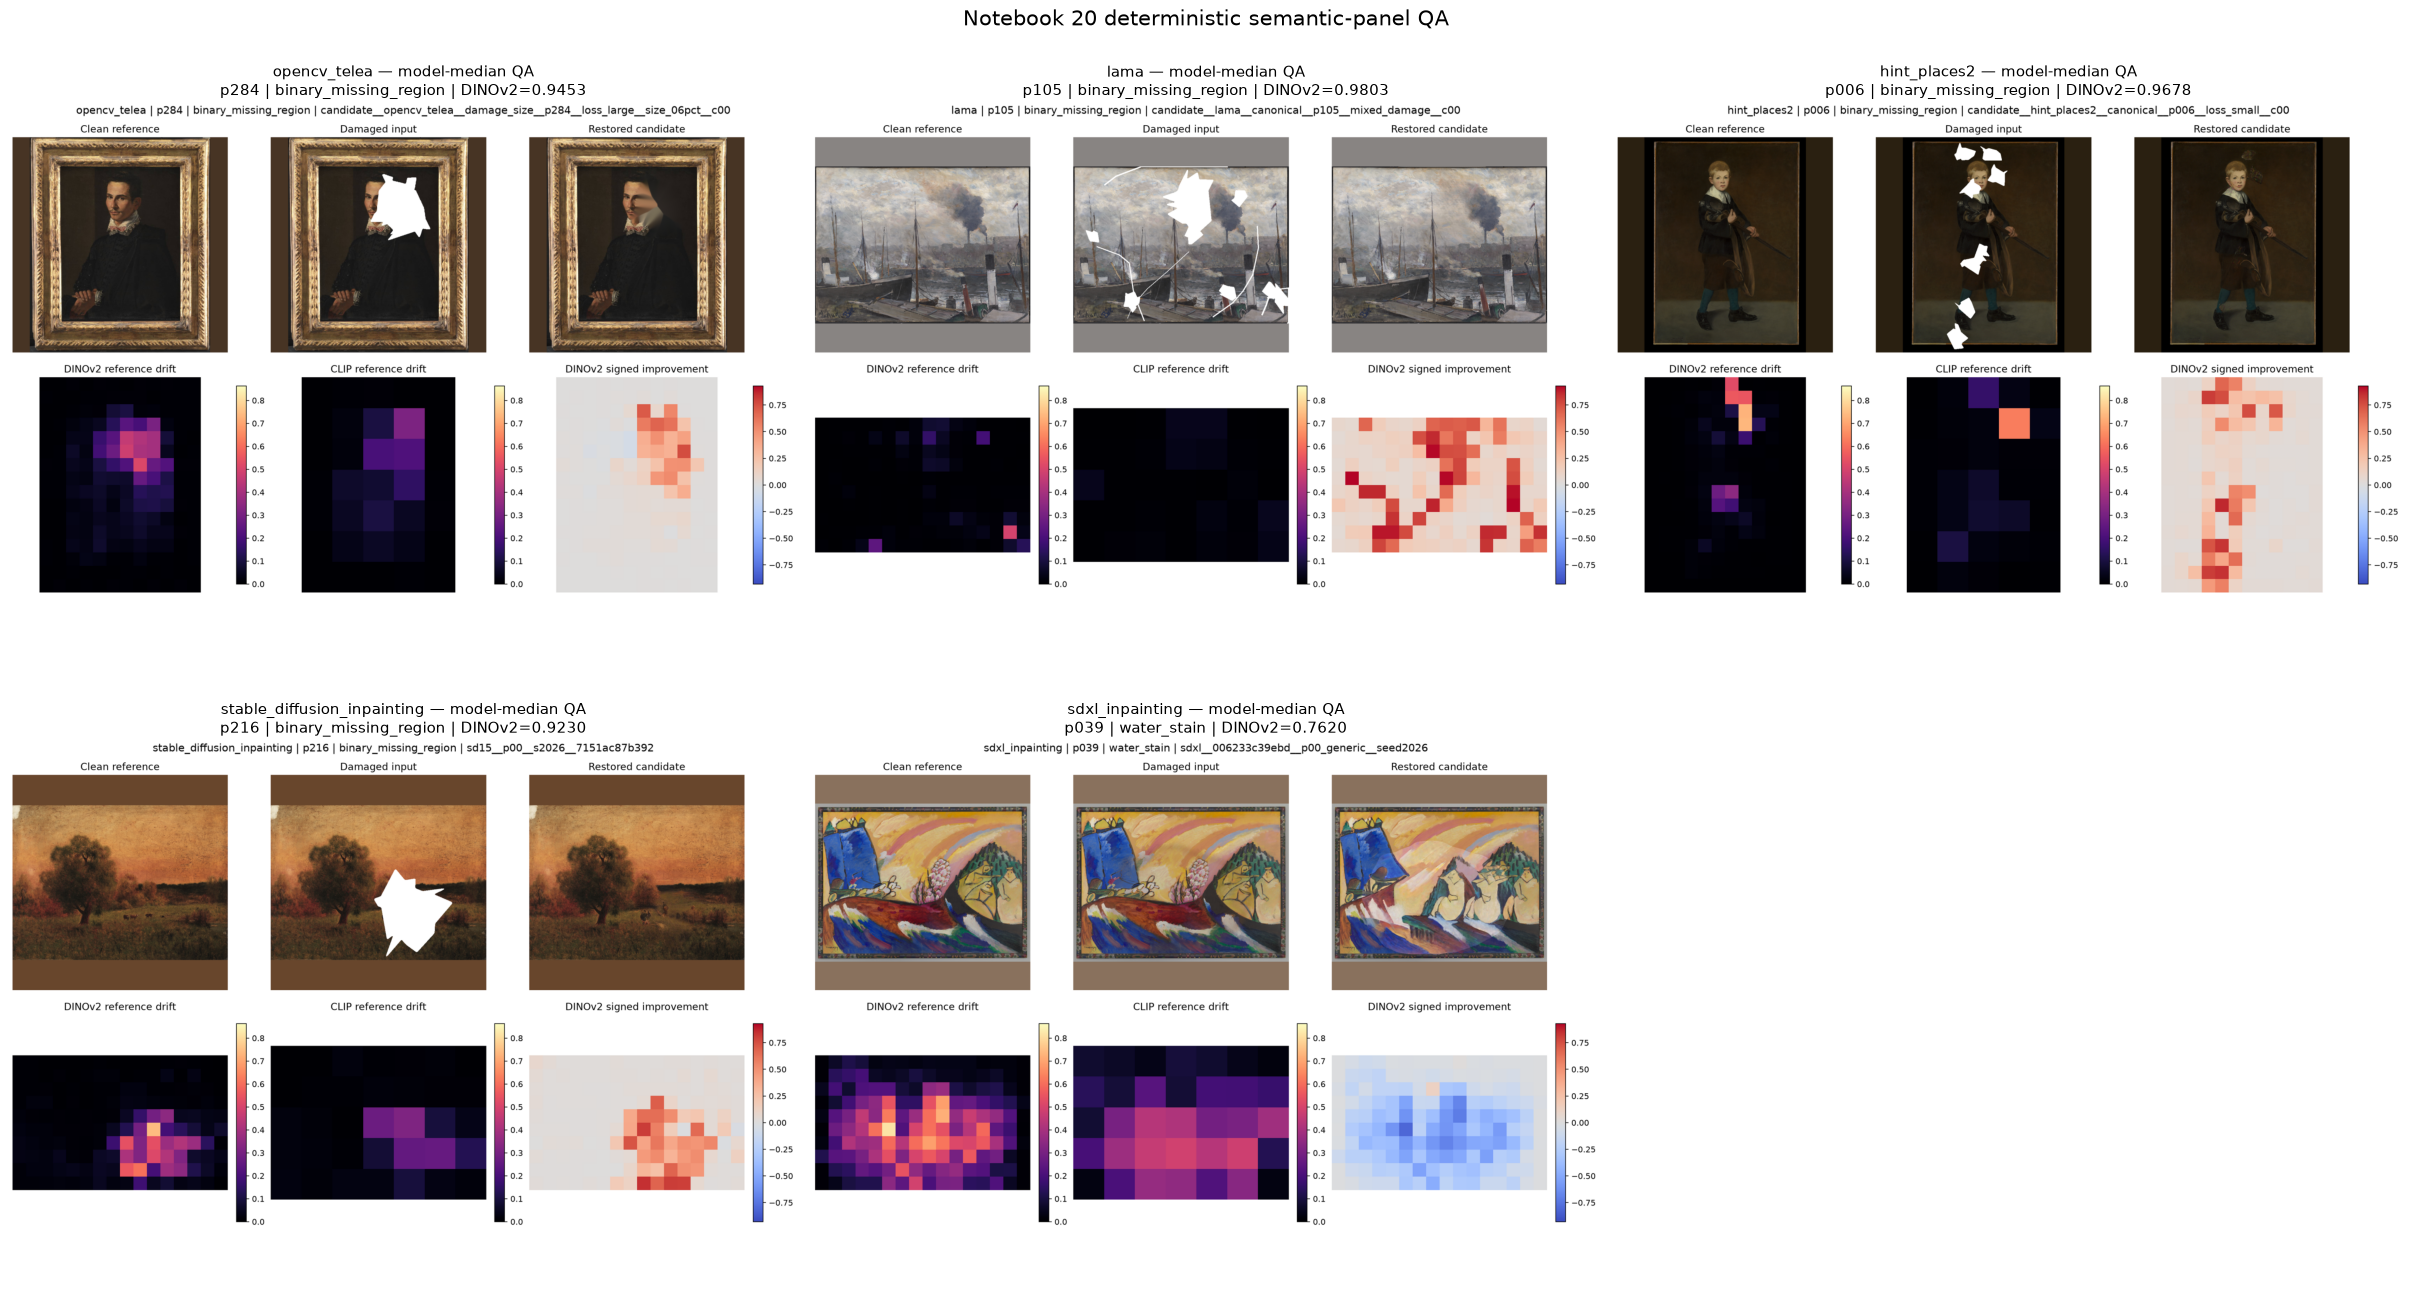

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_semantic_panel_rendering,render_scope,The rendered candidate population exactly matc...,blocking,"{""candidate_set_difference"": 0, ""panels"": 9304}","{""candidate_set_difference"": 0, ""panels"": 9304}",True,
1,batch_6_semantic_panel_rendering,render_checkpoint_contract,Every render checkpoint row completed under th...,blocking,"{""completed"": 9304, ""contract_mismatches"": 0}","{""completed"": 9304, ""contract_mismatches"": 0}",True,
2,batch_6_semantic_panel_rendering,rendered_files,"Every rendered panel exists, reloads, and matc...",blocking,"{""invalid_files"": 0, ""valid_files"": 9304}","{""invalid_files"": 0, ""valid_files"": 9304}",True,
3,batch_6_semantic_panel_rendering,rendered_image_contract,Every semantic panel is a positive-dimension R...,blocking,"{""formats"": [""PNG""], ""modes"": [""RGBA""], ""nonpo...","{""formats"": [""PNG""], ""modes"": [""RGBA""], ""nonpo...",True,
4,batch_6_semantic_panel_rendering,visual_scale_contract,"Global rendering scales are finite, positive, ...",blocking,"{""finite"": true, ""numeric_maps_modified"": fals...","{""finite"": true, ""numeric_maps_modified"": fals...",True,
5,batch_6_semantic_panel_rendering,zero_control_exclusion,Zero controls remain in scalar metrics but are...,blocking,0,0,True,
6,batch_6_semantic_panel_rendering,visual_qa_selection,Visual QA selects exactly one deterministic mo...,blocking,"""{'sdxl_inpainting', 'stable_diffusion_inpaint...","""{'sdxl_inpainting', 'stable_diffusion_inpaint...",True,


Notebook 20 Batch 6 summary
---------------------------
Validation checks: 7
Blocking failures: 0
Rendered semantic panels: 9304
Total panel size MiB: 12938.942
Visual QA panels displayed: 5
Batch 6 completion gate passed.


In [29]:
# ---------------------------------------------------------------------------
# Rendered-file audit
# ---------------------------------------------------------------------------

render_file_audit_records = []

for checkpoint_row in (
    render_checkpoint_df
    .itertuples(index=False)
):
    output_path = resolve_repo_path(
        checkpoint_row.output_relative_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    file_exists = output_path.is_file()

    observed_sha256 = (
        manifest_sha256_path(
            output_path
        )
        if file_exists
        else ""
    )

    observed_size = (
        int(output_path.stat().st_size)
        if file_exists
        else 0
    )

    observed_format = ""
    observed_mode = ""
    observed_width = 0
    observed_height = 0
    reload_passed = False

    if file_exists:
        try:
            with PILImage.open(
                output_path
            ) as image:
                observed_format = str(
                    image.format
                )
                observed_mode = str(
                    image.mode
                )
                (
                    observed_width,
                    observed_height,
                ) = image.size
                image.verify()

            reload_passed = True

        except Exception:
            reload_passed = False

    render_file_audit_records.append(
        {
            "candidate_id": str(
                checkpoint_row.candidate_id
            ),
            "model_id": str(
                checkpoint_row.model_id
            ),
            "output_relative_path": str(
                checkpoint_row
                .output_relative_path
            ),
            "file_exists": file_exists,
            "checksum_matches": (
                file_exists
                and observed_sha256
                == str(
                    checkpoint_row
                    .output_sha256
                )
            ),
            "size_matches": (
                file_exists
                and observed_size
                == int(
                    checkpoint_row
                    .size_bytes
                )
            ),
            "reload_passed": (
                reload_passed
            ),
            "image_format": (
                observed_format
            ),
            "image_mode": observed_mode,
            "width": int(
                observed_width
            ),
            "height": int(
                observed_height
            ),
        }
    )

render_file_audit_df = pd.DataFrame(
    render_file_audit_records
)

render_model_summary_df = (
    render_checkpoint_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        rendered_panels=(
            "candidate_id",
            "size",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
        total_size_bytes=(
            "size_bytes",
            "sum",
        ),
        median_runtime_seconds=(
            "runtime_seconds",
            "median",
        ),
    )
)

render_model_summary_df[
    "total_size_mib"
] = (
    pd.to_numeric(
        render_model_summary_df[
            "total_size_bytes"
        ],
        errors="raise",
    )
    / (1024**2)
)

render_model_summary_df["_model_order"] = (
    render_model_summary_df[
        "model_id"
    ].astype(str).map(
        model_order_lookup
    )
)

render_model_summary_df = (
    render_model_summary_df
    .sort_values(
        "_model_order",
        kind="stable",
    )
    .drop(columns=["_model_order"])
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Deterministic QA selection: model-median DINOv2 local similarity
# ---------------------------------------------------------------------------

qa_metric_df = (
    semantic_metrics_df.loc[
        semantic_metrics_df[
            "candidate_id"
        ].astype(str).isin(
            rendered_candidate_ids
        )
        & semantic_metrics_df[
            "evidence_family"
        ].astype(str).eq(
            "local_semantic_preservation"
        )
        & semantic_metrics_df[
            "metric_name"
        ].astype(str).eq(
            "local_patch_cosine_similarity"
        )
        & semantic_metrics_df[
            "feature_model_id"
        ].astype(str).eq(
            "dinov2_vits14"
        )
        & semantic_metrics_df[
            "region_id"
        ].astype(str).eq(
            "content_region"
        )
        & semantic_metrics_df[
            "summary_statistic"
        ].astype(str).eq(
            "mean"
        )
    ]
    .copy()
)

if len(qa_metric_df) != EXPECTED_COUNTS[
    "rendered_semantic_panels"
]:
    raise ValueError(
        "QA metric population differs from the "
        "rendered candidate population."
    )

qa_metric_df[
    "restored_value"
] = pd.to_numeric(
    qa_metric_df["restored_value"],
    errors="raise",
)

qa_selection_records = []

for model_id in MODEL_ORDER:
    model_metrics = (
        qa_metric_df.loc[
            qa_metric_df[
                "model_id"
            ].astype(str).eq(
                model_id
            )
        ]
        .copy()
    )

    if model_metrics.empty:
        raise ValueError(
            f"No QA metrics found for {model_id}."
        )

    model_median = float(
        model_metrics[
            "restored_value"
        ].median()
    )

    model_metrics[
        "distance_from_model_median"
    ] = (
        model_metrics[
            "restored_value"
        ]
        .sub(model_median)
        .abs()
    )

    selected = (
        model_metrics
        .sort_values(
            [
                "distance_from_model_median",
                "candidate_id",
            ],
            kind="stable",
        )
        .iloc[0]
    )

    checkpoint_record = (
        render_checkpoint_by_candidate[
            str(selected["candidate_id"])
        ]
    )

    qa_selection_records.append(
        {
            "model_id": model_id,
            "candidate_id": str(
                selected["candidate_id"]
            ),
            "case_id": str(
                selected["case_id"]
            ),
            "painting_id": str(
                selected["painting_id"]
            ),
            "category": str(
                selected["category"]
            ),
            "damage_or_degradation_type": str(
                selected[
                    "damage_or_degradation_type"
                ]
            ),
            "dinov2_local_similarity": float(
                selected["restored_value"]
            ),
            "model_median_similarity": (
                model_median
            ),
            "output_relative_path": str(
                checkpoint_record[
                    "output_relative_path"
                ]
            ),
        }
    )

qa_selection_df = pd.DataFrame(
    qa_selection_records
)

display(render_model_summary_df)
display(qa_selection_df)


# ---------------------------------------------------------------------------
# Compact in-notebook visual inspection
# ---------------------------------------------------------------------------

qa_figure, qa_axes = plt.subplots(
    2,
    3,
    figsize=(24, 13),
    constrained_layout=True,
)

qa_axes_flat = list(qa_axes.flat)

for axis in qa_axes_flat[
    len(qa_selection_df):
]:
    axis.axis("off")

for axis, qa_row in zip(
    qa_axes_flat[:len(qa_selection_df)],
    qa_selection_df.itertuples(
        index=False
    ),
    strict=True,
):
    panel_path = resolve_repo_path(
        qa_row.output_relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    with PILImage.open(
        panel_path
    ) as panel_image:
        preview = panel_image.convert(
            "RGB"
        )
        preview.thumbnail(
            (1600, 1000)
        )
        preview_array = np.asarray(
            preview,
            dtype=np.uint8,
        ).copy()

    axis.imshow(preview_array)
    axis.set_title(
        f"{qa_row.model_id} — model-median QA\n"
        f"{qa_row.painting_id} | "
        f"{qa_row.damage_or_degradation_type} | "
        f"DINOv2={qa_row.dinov2_local_similarity:.4f}",
        fontsize=11,
    )
    axis.axis("off")

qa_figure.suptitle(
    "Notebook 20 deterministic semantic-panel QA",
    fontsize=15,
)

display(qa_figure)
plt.close(qa_figure)


# ---------------------------------------------------------------------------
# Batch 6 validation
# ---------------------------------------------------------------------------

BATCH_6_VALIDATION_STAGE = (
    "batch_6_semantic_panel_rendering"
)

retained_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != BATCH_6_VALIDATION_STAGE
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)


def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            BATCH_6_VALIDATION_STAGE
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


observed_render_candidates = set(
    render_checkpoint_df[
        "candidate_id"
    ].astype(str)
)

add_batch_6_check(
    "render_scope",
    (
        "The rendered candidate population exactly "
        "matches the approved nonzero primary scope."
    ),
    {
        "panels": EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ],
        "candidate_set_difference": 0,
    },
    {
        "panels": len(
            render_checkpoint_df
        ),
        "candidate_set_difference": len(
            observed_render_candidates
            ^ rendered_candidate_ids
        ),
    },
    (
        len(render_checkpoint_df)
        == EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ]
        and observed_render_candidates
        == rendered_candidate_ids
    ),
)

add_batch_6_check(
    "render_checkpoint_contract",
    (
        "Every render checkpoint row completed under "
        "the current rendering contract."
    ),
    {
        "completed": EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ],
        "contract_mismatches": 0,
    },
    {
        "completed": int(
            render_checkpoint_df[
                "status"
            ].astype(str).eq(
                "completed"
            ).sum()
        ),
        "contract_mismatches": int(
            (
                render_checkpoint_df[
                    "visual_scale_contract_sha256"
                ].astype(str)
                != visual_scale_contract_sha256
            ).sum()
            + (
                render_checkpoint_df[
                    "bundle_evidence_sha256"
                ].astype(str)
                != bundle_evidence_sha256
            ).sum()
        ),
    },
    (
        render_checkpoint_df[
            "status"
        ].astype(str).eq(
            "completed"
        ).all()
        and render_checkpoint_df[
            "visual_scale_contract_sha256"
        ].astype(str).eq(
            visual_scale_contract_sha256
        ).all()
        and render_checkpoint_df[
            "bundle_evidence_sha256"
        ].astype(str).eq(
            bundle_evidence_sha256
        ).all()
    ),
)

add_batch_6_check(
    "rendered_files",
    (
        "Every rendered panel exists, reloads, and "
        "matches its recorded checksum and size."
    ),
    {
        "valid_files": EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ],
        "invalid_files": 0,
    },
    {
        "valid_files": int(
            (
                render_file_audit_df[
                    "file_exists"
                ]
                & render_file_audit_df[
                    "checksum_matches"
                ]
                & render_file_audit_df[
                    "size_matches"
                ]
                & render_file_audit_df[
                    "reload_passed"
                ]
            ).sum()
        ),
        "invalid_files": int(
            (
                ~render_file_audit_df[
                    "file_exists"
                ]
                | ~render_file_audit_df[
                    "checksum_matches"
                ]
                | ~render_file_audit_df[
                    "size_matches"
                ]
                | ~render_file_audit_df[
                    "reload_passed"
                ]
            ).sum()
        ),
    },
    (
        render_file_audit_df[
            "file_exists"
        ].all()
        and render_file_audit_df[
            "checksum_matches"
        ].all()
        and render_file_audit_df[
            "size_matches"
        ].all()
        and render_file_audit_df[
            "reload_passed"
        ].all()
    ),
)

add_batch_6_check(
    "rendered_image_contract",
    (
        "Every semantic panel is a positive-dimension "
        "RGBA PNG."
    ),
    {
        "formats": ["PNG"],
        "modes": [
            str(
                VISUAL_CONFIG["png_mode"]
            )
        ],
        "nonpositive_dimensions": 0,
    },
    {
        "formats": sorted(
            render_file_audit_df[
                "image_format"
            ].astype(str).unique()
        ),
        "modes": sorted(
            render_file_audit_df[
                "image_mode"
            ].astype(str).unique()
        ),
        "nonpositive_dimensions": int(
            (
                (
                    render_file_audit_df[
                        "width"
                    ]
                    <= 0
                )
                |
                (
                    render_file_audit_df[
                        "height"
                    ]
                    <= 0
                )
            ).sum()
        ),
    },
    (
        render_file_audit_df[
            "image_format"
        ].astype(str).eq(
            "PNG"
        ).all()
        and render_file_audit_df[
            "image_mode"
        ].astype(str).eq(
            str(
                VISUAL_CONFIG["png_mode"]
            )
        ).all()
        and (
            render_file_audit_df[
                "width"
            ]
            > 0
        ).all()
        and (
            render_file_audit_df[
                "height"
            ]
            > 0
        ).all()
    ),
)

add_batch_6_check(
    "visual_scale_contract",
    (
        "Global rendering scales are finite, positive, "
        "and leave numeric evidence unchanged."
    ),
    {
        "finite": True,
        "positive": True,
        "numeric_maps_modified": False,
    },
    {
        "finite": bool(
            np.isfinite(
                [
                    drift_vmax,
                    improvement_absmax,
                ]
            ).all()
        ),
        "positive": bool(
            drift_vmax > 0
            and improvement_absmax > 0
        ),
        "numeric_maps_modified": (
            visual_scale_contract[
                "numeric_maps_modified"
            ]
        ),
    },
    (
        np.isfinite(
            [
                drift_vmax,
                improvement_absmax,
            ]
        ).all()
        and drift_vmax > 0
        and improvement_absmax > 0
        and not visual_scale_contract[
            "numeric_maps_modified"
        ]
    ),
)

add_batch_6_check(
    "zero_control_exclusion",
    (
        "Zero controls remain in scalar metrics but "
        "are excluded from rendered semantic panels."
    ),
    0,
    int(
        render_plan_df[
            "is_zero_control"
        ].astype(bool).sum()
    ),
    not render_plan_df[
        "is_zero_control"
    ].astype(bool).any(),
)

add_batch_6_check(
    "visual_qa_selection",
    (
        "Visual QA selects exactly one deterministic "
        "model-median panel per evaluated model."
    ),
    set(MODEL_ORDER),
    set(
        qa_selection_df[
            "model_id"
        ].astype(str)
    ),
    (
        len(qa_selection_df)
        == len(MODEL_ORDER)
        and set(
            qa_selection_df[
                "model_id"
            ].astype(str)
        )
        == set(MODEL_ORDER)
    ),
)

batch_6_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_6_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(batch_6_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 20 Batch 6 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_6_validation_df),
)
print(
    "Blocking failures:",
    int(
        (
            ~batch_6_validation_df[
                "passed"
            ].astype(bool)
        ).sum()
    ),
)
print(
    "Rendered semantic panels:",
    len(render_checkpoint_df),
)
print(
    "Total panel size MiB:",
    round(
        float(
            pd.to_numeric(
                render_checkpoint_df[
                    "size_bytes"
                ],
                errors="raise",
            ).sum()
        )
        / (1024**2),
        3,
    ),
)
print(
    "Visual QA panels displayed:",
    len(qa_selection_df),
)
print("Batch 6 completion gate passed.")

## Batch 7 — Canonical persistence and reload validation

This batch persists and reloads the canonical machine-readable semantic evidence:

- 58,980 transparent semantic and structural metric rows;
- 8,340 unclipped numeric semantic-map bundles;
- 9,430 semantic-map manifest records.

The numeric map archive uses float16 storage after float32 computation. Quantization must remain within the approved tolerance, and NaN support masks must remain unchanged.

The map manifest records:

- one archive-key record for every numeric bundle;
- one file record for every rendered semantic panel;
- candidate, model, region, encoder, checksum, format, dimensional, scaling, and provenance information.

This batch does not create the representative summary figure, final artifact manifest, run manifest, or consolidated validation file.

In [30]:
# ---------------------------------------------------------------------------
# Batch 7 canonical persistence imports
# ---------------------------------------------------------------------------

import gc
import importlib
import time

import restoration_eval.semantic_structural as semantic_structural_module


semantic_structural_module = importlib.reload(
    semantic_structural_module
)

from restoration_eval.semantic_structural import (
    SEMANTIC_STRUCTURAL_MODULE_VERSION as ACTIVE_SEMANTIC_HELPER_VERSION,
    build_semantic_map_asset_record,
    load_semantic_map_archive,
    validate_semantic_map_manifest,
    validate_semantic_metrics,
    write_dataframe_atomic,
    write_semantic_map_archive,
)


if ACTIVE_SEMANTIC_HELPER_VERSION != "1.0.3":
    raise RuntimeError(
        "Notebook 20 Batch 7 requires semantic helper "
        "version 1.0.3."
    )

SEMANTIC_STRUCTURAL_MODULE_VERSION = (
    ACTIVE_SEMANTIC_HELPER_VERSION
)

persistence_started = time.perf_counter()


# ---------------------------------------------------------------------------
# Canonical semantic metric table
# ---------------------------------------------------------------------------

semantic_metrics_output_df = (
    semantic_metrics_df[
        list(
            SEMANTIC_STRUCTURAL_METRIC_SCHEMA
            .required_columns
        )
    ]
    .copy()
    .sort_values(
        [
            "candidate_id",
            "evidence_family",
            "feature_model_id",
            "region_id",
            "metric_name",
            "summary_statistic",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

metric_prewrite_validation = (
    validate_semantic_metrics(
        semantic_metrics_output_df,
        config=semantic_config,
    )
)

if not metric_prewrite_validation[
    "passed"
]:
    raise ValueError(
        "Semantic metrics failed validation before "
        "canonical persistence: "
        f"{metric_prewrite_validation}"
    )

write_dataframe_atomic(
    semantic_metrics_output_df,
    OUTPUTS["semantic_metrics"],
    attempts=int(
        EXECUTION_CONFIG[
            "atomic_replace_attempts"
        ]
    ),
    retry_delay_seconds=float(
        EXECUTION_CONFIG[
            "atomic_replace_retry_seconds"
        ]
    ),
)


# ---------------------------------------------------------------------------
# Canonical numeric semantic-map archive
# ---------------------------------------------------------------------------

expected_archive_keys = set(
    numeric_bundle_index_df[
        "archive_key"
    ].astype(str)
)

observed_bundle_keys = set(
    str(key)
    for key in semantic_numeric_bundles
)

if observed_bundle_keys != expected_archive_keys:
    raise ValueError(
        "In-memory semantic bundles differ from the "
        "validated numeric-bundle index."
    )

ordered_semantic_bundles = {
    archive_key: np.asarray(
        semantic_numeric_bundles[
            archive_key
        ],
        dtype=np.float32,
    )
    for archive_key in sorted(
        expected_archive_keys
    )
}

write_semantic_map_archive(
    ordered_semantic_bundles,
    OUTPUTS["numeric_maps"],
    archive_dtype=(
        SEMANTIC_CONFIG[
            "numeric_maps"
        ]["archive_dtype"]
        if "archive_dtype"
        in SEMANTIC_CONFIG[
            "numeric_maps"
        ]
        else EXECUTION_CONFIG[
            "base_token_cache_dtype"
        ]
    ),
)

del ordered_semantic_bundles
gc.collect()

semantic_metrics_sha256 = (
    manifest_sha256_path(
        OUTPUTS["semantic_metrics"]
    )
)

numeric_maps_sha256 = (
    manifest_sha256_path(
        OUTPUTS["numeric_maps"]
    )
)

print("Canonical metric and map persistence complete.")
print(
    "Semantic metric rows:",
    len(semantic_metrics_output_df),
)
print(
    "Numeric map bundles:",
    len(expected_archive_keys),
)
print(
    "Metric CSV size MiB:",
    round(
        OUTPUTS[
            "semantic_metrics"
        ].stat().st_size
        / (1024**2),
        3,
    ),
)
print(
    "Numeric archive size MiB:",
    round(
        OUTPUTS[
            "numeric_maps"
        ].stat().st_size
        / (1024**2),
        3,
    ),
)
print(
    "Metric checksum:",
    semantic_metrics_sha256,
)
print(
    "Numeric archive checksum:",
    numeric_maps_sha256,
)

Canonical metric and map persistence complete.
Semantic metric rows: 447312
Numeric map bundles: 63216
Metric CSV size MiB: 304.538
Numeric archive size MiB: 92.65
Metric checksum: badae80c559c463cf89309d9f9ac19bd288528b9fa8a6541f7913d3a4588be5e
Numeric archive checksum: da8ae0ea862f97159c9e4e6479313da0f1edef5eaf5a564d101bca2753d029cd


In [31]:
# ---------------------------------------------------------------------------
# Reload canonical metrics
# ---------------------------------------------------------------------------

reloaded_semantic_metrics_df = pd.read_csv(
    OUTPUTS["semantic_metrics"],
    low_memory=False,
)

metric_reload_validation = (
    validate_semantic_metrics(
        reloaded_semantic_metrics_df,
        config=semantic_config,
    )
)

if not metric_reload_validation[
    "passed"
]:
    raise ValueError(
        "Reloaded semantic metrics failed validation: "
        f"{metric_reload_validation}"
    )

original_metric_ids = set(
    semantic_metrics_output_df[
        "semantic_metric_id"
    ].astype(str)
)

reloaded_metric_ids = set(
    reloaded_semantic_metrics_df[
        "semantic_metric_id"
    ].astype(str)
)

if original_metric_ids != reloaded_metric_ids:
    raise ValueError(
        "Reloaded semantic metric identifiers differ "
        "from the persisted source table."
    )

METRIC_NUMERIC_COLUMNS = [
    "damaged_value",
    "restored_value",
    "improvement_value",
]

original_metric_numeric_df = (
    semantic_metrics_output_df
    .set_index(
        "semantic_metric_id"
    )[
        METRIC_NUMERIC_COLUMNS
    ]
    .sort_index()
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

reloaded_metric_numeric_df = (
    reloaded_semantic_metrics_df
    .set_index(
        "semantic_metric_id"
    )[
        METRIC_NUMERIC_COLUMNS
    ]
    .sort_index()
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

metric_nan_patterns_match = bool(
    np.array_equal(
        original_metric_numeric_df
        .isna()
        .to_numpy(),
        reloaded_metric_numeric_df
        .isna()
        .to_numpy(),
    )
)

metric_numeric_values_match = bool(
    np.allclose(
        original_metric_numeric_df
        .to_numpy(dtype=float),
        reloaded_metric_numeric_df
        .to_numpy(dtype=float),
        rtol=1e-12,
        atol=1e-12,
        equal_nan=True,
    )
)


# ---------------------------------------------------------------------------
# Reload canonical numeric archive
# ---------------------------------------------------------------------------

reloaded_semantic_bundles = (
    load_semantic_map_archive(
        OUTPUTS["numeric_maps"]
    )
)

reloaded_archive_keys = set(
    reloaded_semantic_bundles
)

archive_key_difference = (
    expected_archive_keys
    ^ reloaded_archive_keys
)

if archive_key_difference:
    raise ValueError(
        "Reloaded numeric archive key difference: "
        f"{sorted(archive_key_difference)[:10]}"
    )

archive_bundle_audit_records = []

quantization_tolerance = float(
    SEMANTIC_CONFIG[
        "numeric_maps"
    ][
        "archive_quantization_tolerance"
    ]
)

for number, archive_key in enumerate(
    sorted(expected_archive_keys),
    start=1,
):
    original_bundle = np.asarray(
        semantic_numeric_bundles[
            archive_key
        ],
        dtype=np.float32,
    )

    reloaded_bundle = np.asarray(
        reloaded_semantic_bundles[
            archive_key
        ]
    )

    shape_matches = (
        original_bundle.shape
        == reloaded_bundle.shape
    )

    nan_pattern_matches = bool(
        np.array_equal(
            np.isnan(original_bundle),
            np.isnan(reloaded_bundle),
        )
    )

    finite_pair = (
        np.isfinite(original_bundle)
        & np.isfinite(reloaded_bundle)
    )

    if finite_pair.any():
        maximum_absolute_error = float(
            np.max(
                np.abs(
                    original_bundle[
                        finite_pair
                    ]
                    - reloaded_bundle[
                        finite_pair
                    ].astype(np.float32)
                )
            )
        )
    else:
        maximum_absolute_error = 0.0

    archive_bundle_audit_records.append(
        {
            "archive_key": archive_key,
            "shape_matches": shape_matches,
            "archive_dtype": str(
                reloaded_bundle.dtype
            ),
            "nan_pattern_matches": (
                nan_pattern_matches
            ),
            "has_infinite_value": bool(
                np.isinf(
                    reloaded_bundle
                ).any()
            ),
            "maximum_absolute_error": (
                maximum_absolute_error
            ),
            "within_quantization_tolerance": (
                maximum_absolute_error
                <= quantization_tolerance
            ),
        }
    )

    if (
        number % 1000 == 0
        or number
        == len(expected_archive_keys)
    ):
        print(
            "Archive audit progress:",
            f"{number}/{len(expected_archive_keys)}",
        )

archive_bundle_audit_df = pd.DataFrame(
    archive_bundle_audit_records
)

archive_reload_passed = bool(
    len(
        archive_bundle_audit_df
    )
    == EXPECTED_COUNTS[
        "numeric_map_bundles"
    ]
    and archive_bundle_audit_df[
        "shape_matches"
    ].all()
    and archive_bundle_audit_df[
        "archive_dtype"
    ].astype(str).eq(
        "float16"
    ).all()
    and archive_bundle_audit_df[
        "nan_pattern_matches"
    ].all()
    and not archive_bundle_audit_df[
        "has_infinite_value"
    ].any()
    and archive_bundle_audit_df[
        "within_quantization_tolerance"
    ].all()
)

maximum_archive_quantization_error = float(
    archive_bundle_audit_df[
        "maximum_absolute_error"
    ].max()
)

del reloaded_semantic_bundles
gc.collect()

archive_audit_summary_df = pd.DataFrame(
    [
        {
            "audit_component": (
                "metric_csv"
            ),
            "records": len(
                reloaded_semantic_metrics_df
            ),
            "identity_matches": (
                original_metric_ids
                == reloaded_metric_ids
            ),
            "nan_pattern_matches": (
                metric_nan_patterns_match
            ),
            "numeric_values_match": (
                metric_numeric_values_match
            ),
            "maximum_absolute_error": 0.0,
            "passed": bool(
                metric_reload_validation[
                    "passed"
                ]
                and metric_nan_patterns_match
                and metric_numeric_values_match
            ),
        },
        {
            "audit_component": (
                "numeric_map_archive"
            ),
            "records": len(
                archive_bundle_audit_df
            ),
            "identity_matches": (
                not archive_key_difference
            ),
            "nan_pattern_matches": bool(
                archive_bundle_audit_df[
                    "nan_pattern_matches"
                ].all()
            ),
            "numeric_values_match": (
                archive_reload_passed
            ),
            "maximum_absolute_error": (
                maximum_archive_quantization_error
            ),
            "passed": archive_reload_passed,
        },
    ]
)

display(archive_audit_summary_df)

print("Canonical reload audit complete.")
print(
    "Reloaded metric rows:",
    len(reloaded_semantic_metrics_df),
)
print(
    "Reloaded numeric bundles:",
    len(archive_bundle_audit_df),
)
print(
    "Maximum archive quantization error:",
    maximum_archive_quantization_error,
)
print(
    "Quantization tolerance:",
    quantization_tolerance,
)

Archive audit progress: 1000/63216
Archive audit progress: 2000/63216
Archive audit progress: 3000/63216
Archive audit progress: 4000/63216
Archive audit progress: 5000/63216
Archive audit progress: 6000/63216
Archive audit progress: 7000/63216
Archive audit progress: 8000/63216
Archive audit progress: 9000/63216
Archive audit progress: 10000/63216
Archive audit progress: 11000/63216
Archive audit progress: 12000/63216
Archive audit progress: 13000/63216
Archive audit progress: 14000/63216
Archive audit progress: 15000/63216
Archive audit progress: 16000/63216
Archive audit progress: 17000/63216
Archive audit progress: 18000/63216
Archive audit progress: 19000/63216
Archive audit progress: 20000/63216
Archive audit progress: 21000/63216
Archive audit progress: 22000/63216
Archive audit progress: 23000/63216
Archive audit progress: 24000/63216
Archive audit progress: 25000/63216
Archive audit progress: 26000/63216
Archive audit progress: 27000/63216
Archive audit progress: 28000/63216
A

,audit_component,records,identity_matches,nan_pattern_matches,numeric_values_match,maximum_absolute_error,passed
0,metric_csv,447312,True,True,True,0.000000,True
1,numeric_map_archive,63216,True,True,True,0.000487,True


Canonical reload audit complete.
Reloaded metric rows: 447312
Reloaded numeric bundles: 63216
Maximum archive quantization error: 0.00048732757568359375
Quantization tolerance: 0.0005


In [32]:
# ---------------------------------------------------------------------------
# Numeric-bundle manifest records
# ---------------------------------------------------------------------------

numeric_map_relative_path = (
    to_repo_relative(
        OUTPUTS["numeric_maps"],
        PROJECT_ROOT,
    )
)

numeric_archive_size_bytes = int(
    OUTPUTS["numeric_maps"].stat().st_size
)

semantic_map_manifest_records = []

for bundle_row in (
    numeric_bundle_index_df
    .sort_values(
        [
            "candidate_id",
            "feature_model_id",
            "region_id",
        ],
        kind="stable",
    )
    .itertuples(index=False)
):
    candidate_id = str(
        bundle_row.candidate_id
    )

    metadata = metadata_lookup[
        candidate_id
    ]

    semantic_map_manifest_records.append(
        build_semantic_map_asset_record(
            metadata,
            asset_kind=(
                "numeric_map_bundle"
            ),
            feature_model_id=str(
                bundle_row.feature_model_id
            ),
            region_id=str(
                bundle_row.region_id
            ),
            map_type=(
                "local_semantic_bundle"
            ),
            relative_path=(
                numeric_map_relative_path
            ),
            archive_key=str(
                bundle_row.archive_key
            ),
            channel_schema=str(
                bundle_row.channel_schema
            ),
            selection_role=str(
                bundle_row.selection_role
            ),
            sha256=(
                numeric_maps_sha256
            ),
            size_bytes=(
                numeric_archive_size_bytes
            ),
            width=int(
                bundle_row.grid_width
            ),
            height=int(
                bundle_row.grid_height
            ),
            image_mode="",
            format="NPZ",
            cmap="",
            vmin=np.nan,
            vmax=np.nan,
            center=np.nan,
            scale_scope=(
                "numeric_unclipped"
            ),
            normalization_policy_id=(
                "none"
            ),
            quantization_policy=(
                "float32_compute_float16_archive"
            ),
            no_data_policy=(
                "nan_for_invalid_or_padded_tokens"
            ),
            status="passed",
            issue="",
        )
    )


# ---------------------------------------------------------------------------
# Rendered-panel manifest records
# ---------------------------------------------------------------------------

SEMANTIC_PANEL_CHANNEL_SCHEMA = (
    "semantic_panel_layout.v1:"
    "clean_reference|damaged_input|restored_candidate|"
    "dinov2_reference_drift|clip_reference_drift|"
    "dinov2_signed_improvement"
)

for render_row in (
    render_checkpoint_df
    .sort_values(
        [
            "model_id",
            "case_id",
            "candidate_id",
        ],
        kind="stable",
    )
    .itertuples(index=False)
):
    candidate_id = str(
        render_row.candidate_id
    )

    metadata = metadata_lookup[
        candidate_id
    ]

    semantic_map_manifest_records.append(
        build_semantic_map_asset_record(
            metadata,
            asset_kind=(
                "rendered_semantic_panel"
            ),
            feature_model_id=(
                "multi_encoder"
            ),
            region_id="multi_region",
            map_type="semantic_panel",
            relative_path=str(
                render_row.output_relative_path
            ),
            archive_key="",
            channel_schema=(
                SEMANTIC_PANEL_CHANNEL_SCHEMA
            ),
            selection_role=(
                "rendered_primary"
            ),
            sha256=str(
                render_row.output_sha256
            ),
            size_bytes=int(
                render_row.size_bytes
            ),
            width=int(
                render_row.width
            ),
            height=int(
                render_row.height
            ),
            image_mode=str(
                render_row.image_mode
            ),
            format=str(
                render_row.image_format
            ),
            cmap="multi_panel",
            vmin=np.nan,
            vmax=np.nan,
            center=np.nan,
            scale_scope=(
                "global_visualization_contract"
            ),
            normalization_policy_id=(
                "semantic_visual_scales.v1:"
                + visual_scale_contract_sha256
            ),
            quantization_policy=(
                "not_applicable_png_render"
            ),
            no_data_policy=(
                "invalid_tokens_rendered_as_background"
            ),
            status="passed",
            issue="",
        )
    )


semantic_map_manifest_df = (
    pd.DataFrame(
        semantic_map_manifest_records,
        columns=list(
            SEMANTIC_MAP_ASSET_SCHEMA
            .required_columns
        ),
    )
    .sort_values(
        [
            "asset_kind",
            "candidate_id",
            "feature_model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

map_manifest_prewrite_validation = (
    validate_semantic_map_manifest(
        semantic_map_manifest_df,
        config=semantic_config,
    )
)

if not map_manifest_prewrite_validation[
    "passed"
]:
    raise ValueError(
        "Semantic-map manifest failed validation "
        "before persistence: "
        f"{map_manifest_prewrite_validation}"
    )

write_dataframe_atomic(
    semantic_map_manifest_df,
    OUTPUTS[
        "semantic_map_manifest"
    ],
    attempts=int(
        EXECUTION_CONFIG[
            "atomic_replace_attempts"
        ]
    ),
    retry_delay_seconds=float(
        EXECUTION_CONFIG[
            "atomic_replace_retry_seconds"
        ]
    ),
)

reloaded_semantic_map_manifest_df = (
    pd.read_csv(
        OUTPUTS[
            "semantic_map_manifest"
        ],
        low_memory=False,
    )
)

map_manifest_reload_validation = (
    validate_semantic_map_manifest(
        reloaded_semantic_map_manifest_df,
        config=semantic_config,
    )
)

if not map_manifest_reload_validation[
    "passed"
]:
    raise ValueError(
        "Reloaded semantic-map manifest failed "
        "validation: "
        f"{map_manifest_reload_validation}"
    )

semantic_map_manifest_sha256 = (
    manifest_sha256_path(
        OUTPUTS[
            "semantic_map_manifest"
        ]
    )
)

map_manifest_summary_df = (
    reloaded_semantic_map_manifest_df
    .groupby(
        [
            "asset_kind",
            "feature_model_id",
        ],
        as_index=False,
    )
    .agg(
        manifest_rows=(
            "semantic_map_asset_id",
            "size",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
        unique_paths=(
            "relative_path",
            "nunique",
        ),
    )
    .sort_values(
        [
            "asset_kind",
            "feature_model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(map_manifest_summary_df)
display(
    reloaded_semantic_map_manifest_df
    .head(20)
)

print("Semantic-map manifest persisted and reloaded.")
print(
    "Manifest rows:",
    len(
        reloaded_semantic_map_manifest_df
    ),
)
print(
    "Numeric records:",
    int(
        reloaded_semantic_map_manifest_df[
            "asset_kind"
        ].astype(str).eq(
            "numeric_map_bundle"
        ).sum()
    ),
)
print(
    "Rendered-panel records:",
    int(
        reloaded_semantic_map_manifest_df[
            "asset_kind"
        ].astype(str).eq(
            "rendered_semantic_panel"
        ).sum()
    ),
)
print(
    "Manifest checksum:",
    semantic_map_manifest_sha256,
)

,asset_kind,feature_model_id,manifest_rows,unique_candidates,unique_paths
0,numeric_map_bundle,clip_vit_b32,31608,16404,1
1,numeric_map_bundle,dinov2_vits14,31608,16404,1
2,rendered_semantic_panel,multi_encoder,9304,9304,9304


,semantic_map_asset_id,asset_kind,ownership,candidate_id,case_id,model_id,painting_id,feature_model_id,region_id,map_type,...,vmin,vmax,center,scale_scope,normalization_policy_id,quantization_policy,no_data_policy,renderer_version,status,issue
0,sma_4ff0d0482120df814b1e,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,clip_vit_b32,content_region,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
1,sma_d919c4bada1c2c337f97,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,clip_vit_b32,mask_bbox_crop,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
2,sma_bcb6bc14b25c2fcc17b9,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,dinov2_vits14,content_region,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
3,sma_cdd133e88b340e4e2165,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,p001,dinov2_vits14,mask_bbox_crop,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
4,sma_7fda027ba660885493d8,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,clip_vit_b32,content_region,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
5,sma_3a0fb659acf83b2916f6,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,clip_vit_b32,mask_bbox_crop,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
6,sma_21be2f800bf0e5b2e9e6,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,dinov2_vits14,content_region,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
7,sma_3a7112dea1c61a99cd92,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_small,hint_places2,p001,dinov2_vits14,mask_bbox_crop,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
8,sma_dbad9dde8671291ebf01,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__mixe...,canonical__p001__mixed_damage,hint_places2,p001,clip_vit_b32,content_region,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN
9,sma_db8b86410b054b6f6949,numeric_map_bundle,owned,candidate__hint_places2__canonical__p001__mixe...,canonical__p001__mixed_damage,hint_places2,p001,clip_vit_b32,mask_bbox_crop,local_semantic_bundle,...,NaN,NaN,NaN,numeric_unclipped,none,float32_compute_float16_archive,nan_for_invalid_or_padded_tokens,semantic_map_renderer.v1,passed,NaN


Semantic-map manifest persisted and reloaded.
Manifest rows: 72520
Numeric records: 63216
Rendered-panel records: 9304
Manifest checksum: aa8c4a9a7b547bb0fd87b127f8504499ff0938df95a60032eeb11ca361e8385d


In [33]:
# ---------------------------------------------------------------------------
# Canonical identity and filesystem alignment
# ---------------------------------------------------------------------------

numeric_manifest_df = (
    reloaded_semantic_map_manifest_df.loc[
        reloaded_semantic_map_manifest_df[
            "asset_kind"
        ].astype(str).eq(
            "numeric_map_bundle"
        )
    ]
    .copy()
)

rendered_manifest_df = (
    reloaded_semantic_map_manifest_df.loc[
        reloaded_semantic_map_manifest_df[
            "asset_kind"
        ].astype(str).eq(
            "rendered_semantic_panel"
        )
    ]
    .copy()
)

numeric_manifest_keys = set(
    numeric_manifest_df[
        "archive_key"
    ].astype(str)
)

rendered_manifest_candidates = set(
    rendered_manifest_df[
        "candidate_id"
    ].astype(str)
)

numeric_manifest_alignment = bool(
    numeric_manifest_keys
    == expected_archive_keys
)

rendered_manifest_alignment = bool(
    rendered_manifest_candidates
    == rendered_candidate_ids
)

render_checkpoint_lookup_df = (
    render_checkpoint_df[
        [
            "candidate_id",
            "output_relative_path",
            "output_sha256",
        ]
    ]
    .copy()
    .rename(
        columns={
            "output_relative_path": (
                "checkpoint_relative_path"
            ),
            "output_sha256": (
                "checkpoint_sha256"
            ),
        }
    )
)

render_manifest_alignment_df = (
    rendered_manifest_df[
        [
            "candidate_id",
            "relative_path",
            "sha256",
        ]
    ]
    .merge(
        render_checkpoint_lookup_df,
        on="candidate_id",
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

rendered_path_and_checksum_match = bool(
    render_manifest_alignment_df[
        "_merge"
    ].astype(str).eq(
        "both"
    ).all()
    and render_manifest_alignment_df[
        "relative_path"
    ].astype(str).eq(
        render_manifest_alignment_df[
            "checkpoint_relative_path"
        ].astype(str)
    ).all()
    and render_manifest_alignment_df[
        "sha256"
    ].astype(str).eq(
        render_manifest_alignment_df[
            "checkpoint_sha256"
        ].astype(str)
    ).all()
)

canonical_files_at_batch_7 = sorted(
    path
    for directory_name in (
        "data",
        "metrics",
        "images",
        "figures",
        "manifests",
        "validation",
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / directory_name
    ).rglob("*")
    if path.is_file()
)

temporary_canonical_files = [
    path
    for path in canonical_files_at_batch_7
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

expected_batch_7_canonical_files = (
    EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ]
    + 3
)


# ---------------------------------------------------------------------------
# Rerunnable Batch 7 validation stage
# ---------------------------------------------------------------------------

BATCH_7_VALIDATION_STAGE = (
    "batch_7_canonical_persistence"
)

retained_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != BATCH_7_VALIDATION_STAGE
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)


def add_batch_7_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            BATCH_7_VALIDATION_STAGE
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_7_check(
    "semantic_metric_persistence",
    (
        "The canonical semantic metric CSV reloads "
        "with its exact schema, identities, null "
        "patterns, and numeric values."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "semantic_metric_rows"
        ],
        "schema_passed": True,
        "identity_match": True,
        "nan_pattern_match": True,
        "numeric_match": True,
    },
    {
        "rows": len(
            reloaded_semantic_metrics_df
        ),
        "schema_passed": (
            metric_reload_validation[
                "passed"
            ]
        ),
        "identity_match": (
            original_metric_ids
            == reloaded_metric_ids
        ),
        "nan_pattern_match": (
            metric_nan_patterns_match
        ),
        "numeric_match": (
            metric_numeric_values_match
        ),
    },
    (
        len(
            reloaded_semantic_metrics_df
        )
        == EXPECTED_COUNTS[
            "semantic_metric_rows"
        ]
        and metric_reload_validation[
            "passed"
        ]
        and original_metric_ids
        == reloaded_metric_ids
        and metric_nan_patterns_match
        and metric_numeric_values_match
    ),
)

add_batch_7_check(
    "numeric_archive_persistence",
    (
        "The compressed numeric archive reloads with "
        "every key, shape, NaN mask, finite value, and "
        "approved float16 quantization tolerance."
    ),
    {
        "bundles": EXPECTED_COUNTS[
            "numeric_map_bundles"
        ],
        "dtype": "float16",
        "maximum_error_lte": (
            quantization_tolerance
        ),
    },
    {
        "bundles": len(
            archive_bundle_audit_df
        ),
        "dtypes": sorted(
            archive_bundle_audit_df[
                "archive_dtype"
            ].astype(str).unique()
        ),
        "maximum_error": (
            maximum_archive_quantization_error
        ),
    },
    archive_reload_passed,
)

add_batch_7_check(
    "semantic_map_manifest_schema",
    (
        "The semantic-map manifest reloads with its "
        "exact 9,430-row schema and primary key."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "map_manifest_rows"
        ],
        "passed": True,
    },
    {
        "rows": len(
            reloaded_semantic_map_manifest_df
        ),
        "passed": (
            map_manifest_reload_validation[
                "passed"
            ]
        ),
    },
    (
        len(
            reloaded_semantic_map_manifest_df
        )
        == EXPECTED_COUNTS[
            "map_manifest_rows"
        ]
        and map_manifest_reload_validation[
            "passed"
        ]
    ),
)

add_batch_7_check(
    "numeric_manifest_alignment",
    (
        "Every numeric archive key has exactly one "
        "matching manifest record."
    ),
    {
        "numeric_records": EXPECTED_COUNTS[
            "numeric_map_bundles"
        ],
        "key_difference": 0,
    },
    {
        "numeric_records": len(
            numeric_manifest_df
        ),
        "key_difference": len(
            numeric_manifest_keys
            ^ expected_archive_keys
        ),
    },
    (
        len(numeric_manifest_df)
        == EXPECTED_COUNTS[
            "numeric_map_bundles"
        ]
        and numeric_manifest_alignment
    ),
)

add_batch_7_check(
    "rendered_manifest_alignment",
    (
        "Every rendered panel has one manifest record "
        "with the checkpointed path and checksum."
    ),
    {
        "rendered_records": EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ],
        "candidate_difference": 0,
        "path_and_checksum_match": True,
    },
    {
        "rendered_records": len(
            rendered_manifest_df
        ),
        "candidate_difference": len(
            rendered_manifest_candidates
            ^ rendered_candidate_ids
        ),
        "path_and_checksum_match": (
            rendered_path_and_checksum_match
        ),
    },
    (
        len(rendered_manifest_df)
        == EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ]
        and rendered_manifest_alignment
        and rendered_path_and_checksum_match
    ),
)

add_batch_7_check(
    "batch_7_canonical_file_scope",
    (
        "Batch 7 contains only the expected panels, "
        "metric CSV, numeric archive, and map manifest."
    ),
    {
        "canonical_files": (
            expected_batch_7_canonical_files
        ),
        "temporary_files": 0,
    },
    {
        "canonical_files": len(
            canonical_files_at_batch_7
        ),
        "temporary_files": len(
            temporary_canonical_files
        ),
    },
    (
        len(canonical_files_at_batch_7)
        == expected_batch_7_canonical_files
        and not temporary_canonical_files
    ),
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in temporary_canonical_files
    ],
)

add_batch_7_check(
    "transparent_evidence_policy",
    (
        "Canonical persistence retains no combined "
        "semantic score or final trustworthiness flag."
    ),
    {
        "combined_scores": 0,
        "final_flags": 0,
    },
    {
        "combined_scores": int(
            reloaded_semantic_metrics_df[
                "is_combined_score"
            ].astype(bool).sum()
        ),
        "final_flags": int(
            reloaded_semantic_metrics_df[
                "is_final_trustworthiness_flag"
            ].astype(bool).sum()
        ),
    },
    (
        not reloaded_semantic_metrics_df[
            "is_combined_score"
        ].astype(bool).any()
        and not reloaded_semantic_metrics_df[
            "is_final_trustworthiness_flag"
        ].astype(bool).any()
    ),
)

batch_7_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_7_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(batch_7_validation_df)

VALIDATION.raise_for_blocking()

persistence_runtime_seconds = (
    time.perf_counter()
    - persistence_started
)

print("Notebook 20 Batch 7 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_7_validation_df),
)
print(
    "Blocking failures:",
    int(
        (
            ~batch_7_validation_df[
                "passed"
            ].astype(bool)
        ).sum()
    ),
)
print(
    "Canonical metric rows:",
    len(reloaded_semantic_metrics_df),
)
print(
    "Canonical numeric bundles:",
    len(archive_bundle_audit_df),
)
print(
    "Canonical map-manifest rows:",
    len(
        reloaded_semantic_map_manifest_df
    ),
)
print(
    "Canonical files at this stage:",
    len(canonical_files_at_batch_7),
)
print(
    "Persistence and audit runtime seconds:",
    round(
        persistence_runtime_seconds,
        3,
    ),
)
print("Batch 7 completion gate passed.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_canonical_persistence,semantic_metric_persistence,The canonical semantic metric CSV reloads with...,blocking,"{""identity_match"": true, ""nan_pattern_match"": ...","{""identity_match"": true, ""nan_pattern_match"": ...",True,
1,batch_7_canonical_persistence,numeric_archive_persistence,The compressed numeric archive reloads with ev...,blocking,"{""bundles"": 63216, ""dtype"": ""float16"", ""maximu...","{""bundles"": 63216, ""dtypes"": [""float16""], ""max...",True,
2,batch_7_canonical_persistence,semantic_map_manifest_schema,The semantic-map manifest reloads with its exa...,blocking,"{""passed"": true, ""rows"": 72520}","{""passed"": true, ""rows"": 72520}",True,
3,batch_7_canonical_persistence,numeric_manifest_alignment,Every numeric archive key has exactly one matc...,blocking,"{""key_difference"": 0, ""numeric_records"": 63216}","{""key_difference"": 0, ""numeric_records"": 63216}",True,
4,batch_7_canonical_persistence,rendered_manifest_alignment,Every rendered panel has one manifest record w...,blocking,"{""candidate_difference"": 0, ""path_and_checksum...","{""candidate_difference"": 0, ""path_and_checksum...",True,
5,batch_7_canonical_persistence,batch_7_canonical_file_scope,"Batch 7 contains only the expected panels, met...",blocking,"{""canonical_files"": 9307, ""temporary_files"": 0}","{""canonical_files"": 9307, ""temporary_files"": 0}",True,[]
6,batch_7_canonical_persistence,transparent_evidence_policy,Canonical persistence retains no combined sema...,blocking,"{""combined_scores"": 0, ""final_flags"": 0}","{""combined_scores"": 0, ""final_flags"": 0}",True,


Notebook 20 Batch 7 summary
---------------------------
Validation checks: 7
Blocking failures: 0
Canonical metric rows: 447312
Canonical numeric bundles: 63216
Canonical map-manifest rows: 72520
Canonical files at this stage: 9307
Persistence and audit runtime seconds: 255.511
Batch 7 completion gate passed.


## Batch 8 — Analysis and canonical semantic examples

This batch analyzes the persisted semantic and structural evidence without creating an additional summary table.

It:

- constructs a one-row-per-candidate analysis matrix from the canonical metric table;
- summarizes transparent evidence by model, artwork category, experiment, realized damage fraction, and Stable Diffusion prompt arm;
- retains metric families separately rather than combining them into a semantic score;
- selects 15 distinct representative cases across the five artwork categories;
- applies the three predeclared deterministic selection rules:
  - category-median DINOv2 local similarity;
  - category-worst DINOv2 local similarity;
  - maximum CLIP–DINOv2 local disagreement;
- uses `mask_bbox_crop` evidence for representative selection because every rendered candidate has nonzero damage and an eligible restoration-region crop;
- assembles the already validated semantic panels into the canonical `figures/semantic_examples.png`.

The selected examples are diagnostic cases, not best/worst restoration rankings or final trustworthiness judgements.

In [34]:
# ---------------------------------------------------------------------------
# Candidate-level transparent analysis matrix
# ---------------------------------------------------------------------------

analysis_started = time.perf_counter()

CANDIDATE_METADATA_COLUMNS = [
    "case_id",
    "candidate_id",
    "model_id",
    "painting_id",
    "category",
    "style_or_period",
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
    "candidate_index",
    "seed",
    "prompt_policy_id",
    "prompt_variant_id",
    "execution_role",
    "is_zero_control",
    "semantic_target_scope",
    "applicability_status",
]

candidate_metadata_df = (
    reloaded_semantic_metrics_df[
        CANDIDATE_METADATA_COLUMNS
    ]
    .drop_duplicates()
    .sort_values(
        "candidate_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

if (
    len(candidate_metadata_df)
    != EXPECTED_COUNTS["evaluated_candidates"]
    or not candidate_metadata_df[
        "candidate_id"
    ].is_unique
):
    raise ValueError(
        "Candidate metadata did not reduce to the "
        "expected one-row-per-candidate population."
    )


def extract_analysis_signal(
    *,
    output_column,
    metric_name,
    feature_model_id,
    region_id,
    summary_statistic,
    expected_rows,
):
    signal_df = (
        reloaded_semantic_metrics_df.loc[
            reloaded_semantic_metrics_df[
                "metric_name"
            ].astype(str).eq(metric_name)
            & reloaded_semantic_metrics_df[
                "feature_model_id"
            ].astype(str).eq(feature_model_id)
            & reloaded_semantic_metrics_df[
                "region_id"
            ].astype(str).eq(region_id)
            & reloaded_semantic_metrics_df[
                "summary_statistic"
            ].astype(str).eq(summary_statistic),
            [
                "candidate_id",
                "restored_value",
            ],
        ]
        .copy()
        .rename(
            columns={
                "restored_value": output_column,
            }
        )
    )

    if (
        len(signal_df) != expected_rows
        or not signal_df["candidate_id"].is_unique
    ):
        raise ValueError(
            f"Signal {output_column} has an unexpected "
            "row count or duplicate candidate IDs."
        )

    signal_df[output_column] = pd.to_numeric(
        signal_df[output_column],
        errors="coerce",
    )

    return signal_df


ANALYSIS_SIGNAL_SPECS = [
    {
        "output_column": (
            "dinov2_local_similarity_content"
        ),
        "metric_name": (
            "local_patch_cosine_similarity"
        ),
        "feature_model_id": "dinov2_vits14",
        "region_id": "content_region",
        "summary_statistic": "mean",
        "expected_rows": EXPECTED_COUNTS[
            "evaluated_candidates"
        ],
    },
    {
        "output_column": (
            "clip_local_similarity_content"
        ),
        "metric_name": (
            "local_patch_cosine_similarity"
        ),
        "feature_model_id": "clip_vit_b32",
        "region_id": "content_region",
        "summary_statistic": "mean",
        "expected_rows": EXPECTED_COUNTS[
            "evaluated_candidates"
        ],
    },
    {
        "output_column": (
            "dinov2_local_similarity_bbox"
        ),
        "metric_name": (
            "local_patch_cosine_similarity"
        ),
        "feature_model_id": "dinov2_vits14",
        "region_id": "mask_bbox_crop",
        "summary_statistic": "mean",
        "expected_rows": EXPECTED_COUNTS[
            "nonzero_candidates"
        ],
    },
    {
        "output_column": (
            "clip_local_similarity_bbox"
        ),
        "metric_name": (
            "local_patch_cosine_similarity"
        ),
        "feature_model_id": "clip_vit_b32",
        "region_id": "mask_bbox_crop",
        "summary_statistic": "mean",
        "expected_rows": EXPECTED_COUNTS[
            "nonzero_candidates"
        ],
    },
    {
        "output_column": (
            "dinov2_worsened_fraction_bbox"
        ),
        "metric_name": (
            "local_patch_worsened_fraction"
        ),
        "feature_model_id": "dinov2_vits14",
        "region_id": "mask_bbox_crop",
        "summary_statistic": "fraction",
        "expected_rows": EXPECTED_COUNTS[
            "nonzero_candidates"
        ],
    },
    {
        "output_column": (
            "dinov2_outside_context_change"
        ),
        "metric_name": (
            "outside_context_feature_change"
        ),
        "feature_model_id": "dinov2_vits14",
        "region_id": "outside_mask_patch_subset",
        "summary_statistic": "mean",
        "expected_rows": EXPECTED_COUNTS[
            "evaluated_candidates"
        ],
    },
    {
        "output_column": (
            "dinov2_layout_correlation"
        ),
        "metric_name": (
            "reference_affinity_map_correlation"
        ),
        "feature_model_id": "dinov2_vits14",
        "region_id": "content_region",
        "summary_statistic": "pearson_correlation",
        "expected_rows": EXPECTED_COUNTS[
            "evaluated_candidates"
        ],
    },
    {
        "output_column": (
            "dinov2_painterly_distance_bbox"
        ),
        "metric_name": (
            "dinov2_patch_covariance_distance"
        ),
        "feature_model_id": "dinov2_vits14",
        "region_id": "mask_bbox_crop",
        "summary_statistic": (
            "normalized_frobenius_distance"
        ),
        "expected_rows": EXPECTED_COUNTS[
            "nonzero_candidates"
        ],
    },
    {
        "output_column": (
            "encoder_agreement_bbox"
        ),
        "metric_name": (
            "clip_dinov2_local_map_agreement"
        ),
        "feature_model_id": (
            "clip_vit_b32+dinov2_vits14"
        ),
        "region_id": "mask_bbox_crop",
        "summary_statistic": "pearson_correlation",
        "expected_rows": EXPECTED_COUNTS[
            "nonzero_candidates"
        ],
    },
]

analysis_candidate_df = candidate_metadata_df.copy()

for signal_spec in ANALYSIS_SIGNAL_SPECS:
    signal_df = extract_analysis_signal(
        **signal_spec
    )

    analysis_candidate_df = (
        analysis_candidate_df.merge(
            signal_df,
            on="candidate_id",
            how="left",
            validate="one_to_one",
        )
    )

analysis_candidate_df[
    "is_zero_control"
] = (
    analysis_candidate_df[
        "is_zero_control"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
        }
    )
)

if analysis_candidate_df[
    "is_zero_control"
].isna().any():
    raise ValueError(
        "Could not normalize is_zero_control."
    )

for fraction_column in (
    "target_damage_fraction",
    "realized_damage_fraction",
):
    analysis_candidate_df[
        fraction_column
    ] = pd.to_numeric(
        analysis_candidate_df[
            fraction_column
        ],
        errors="coerce",
    )

realized_fraction = analysis_candidate_df[
    "realized_damage_fraction"
]

analysis_candidate_df["damage_fraction_band"] = (
    np.select(
        [
            realized_fraction.isna(),
            realized_fraction.le(0),
            realized_fraction.le(0.02),
            realized_fraction.le(0.05),
            realized_fraction.le(0.10),
        ],
        [
            "not_recorded",
            "zero_control",
            "gt_0_to_02",
            "gt_02_to_05",
            "gt_05_to_10",
        ],
        default="gt_10",
    )
)

analysis_candidate_df[
    "prompt_policy_id"
] = (
    analysis_candidate_df[
        "prompt_policy_id"
    ]
    .fillna("not_applicable")
    .astype(str)
    .replace("", "not_applicable")
)

analysis_candidate_df[
    "prompt_variant_id"
] = (
    analysis_candidate_df[
        "prompt_variant_id"
    ]
    .fillna("not_applicable")
    .astype(str)
    .replace("", "not_applicable")
)

analysis_candidate_df = (
    analysis_candidate_df
    .sort_values(
        "candidate_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Grouped descriptive summaries
# ---------------------------------------------------------------------------

def build_semantic_group_summary(
    dataframe,
    group_columns,
):
    return (
        dataframe.groupby(
            group_columns,
            dropna=False,
            observed=True,
            as_index=False,
        )
        .agg(
            candidates=(
                "candidate_id",
                "nunique",
            ),
            zero_controls=(
                "is_zero_control",
                "sum",
            ),
            bbox_estimable_candidates=(
                "dinov2_local_similarity_bbox",
                "count",
            ),
            median_dinov2_content_similarity=(
                "dinov2_local_similarity_content",
                "median",
            ),
            median_dinov2_bbox_similarity=(
                "dinov2_local_similarity_bbox",
                "median",
            ),
            median_clip_bbox_similarity=(
                "clip_local_similarity_bbox",
                "median",
            ),
            median_dinov2_worsened_fraction=(
                "dinov2_worsened_fraction_bbox",
                "median",
            ),
            median_outside_context_change=(
                "dinov2_outside_context_change",
                "median",
            ),
            median_layout_correlation=(
                "dinov2_layout_correlation",
                "median",
            ),
            median_painterly_distance=(
                "dinov2_painterly_distance_bbox",
                "median",
            ),
            median_encoder_agreement=(
                "encoder_agreement_bbox",
                "median",
            ),
        )
    )


model_analysis_summary_df = (
    build_semantic_group_summary(
        analysis_candidate_df,
        ["model_id"],
    )
)

model_analysis_summary_df[
    "_model_order"
] = (
    model_analysis_summary_df[
        "model_id"
    ].astype(str).map(
        model_order_lookup
    )
)

model_analysis_summary_df = (
    model_analysis_summary_df
    .sort_values(
        "_model_order",
        kind="stable",
    )
    .drop(columns=["_model_order"])
    .reset_index(drop=True)
)

category_analysis_summary_df = (
    build_semantic_group_summary(
        analysis_candidate_df,
        ["category"],
    )
    .sort_values(
        "category",
        kind="stable",
    )
    .reset_index(drop=True)
)

experiment_analysis_summary_df = (
    build_semantic_group_summary(
        analysis_candidate_df,
        ["experiment_id"],
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

DAMAGE_BAND_ORDER = {
    "not_recorded": 0,
    "zero_control": 1,
    "gt_0_to_02": 2,
    "gt_02_to_05": 3,
    "gt_05_to_10": 4,
    "gt_10": 5,
}

damage_analysis_summary_df = (
    build_semantic_group_summary(
        analysis_candidate_df,
        ["damage_fraction_band"],
    )
)

damage_analysis_summary_df[
    "_damage_order"
] = (
    damage_analysis_summary_df[
        "damage_fraction_band"
    ].map(DAMAGE_BAND_ORDER)
)

damage_analysis_summary_df = (
    damage_analysis_summary_df
    .sort_values(
        "_damage_order",
        kind="stable",
    )
    .drop(columns=["_damage_order"])
    .reset_index(drop=True)
)

stable_diffusion_prompt_source_df = (
    analysis_candidate_df.loc[
        analysis_candidate_df[
            "model_id"
        ].astype(str).eq(
            "stable_diffusion_inpainting"
        )
    ]
    .copy()
)

stable_diffusion_prompt_summary_df = (
    build_semantic_group_summary(
        stable_diffusion_prompt_source_df,
        [
            "prompt_policy_id",
            "prompt_variant_id",
        ],
    )
    .sort_values(
        [
            "prompt_policy_id",
            "prompt_variant_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(model_analysis_summary_df)
display(category_analysis_summary_df)
display(experiment_analysis_summary_df)
display(damage_analysis_summary_df)
display(stable_diffusion_prompt_summary_df)

print("Candidate-level semantic analysis complete.")
print(
    "Candidate rows:",
    len(analysis_candidate_df),
)
print(
    "Nonzero candidates:",
    int(
        (
            ~analysis_candidate_df[
                "is_zero_control"
            ]
        ).sum()
    ),
)
print(
    "Stable Diffusion prompt-analysis rows:",
    len(stable_diffusion_prompt_source_df),
)
print(
    "Interpretation reminder: similarities and "
    "correlations are higher-is-closer proxies; "
    "worsened fractions, context change, and "
    "painterly covariance distance are "
    "lower-is-closer proxies."
)

,model_id,candidates,zero_controls,bbox_estimable_candidates,median_dinov2_content_similarity,median_dinov2_bbox_similarity,median_clip_bbox_similarity,median_dinov2_worsened_fraction,median_outside_context_change,median_layout_correlation,median_painterly_distance,median_encoder_agreement
0,opencv_telea,2620,300,2320,0.960837,0.589990,0.804461,0.058357,0.984185,0.952166,0.324905,0.773585
1,lama,2620,300,2320,0.986743,0.880719,0.903063,0.000000,0.994663,0.983227,0.179186,0.747554
2,hint_places2,2620,300,2320,0.977081,0.778933,0.833625,0.000504,0.991454,0.973066,0.229827,0.781808
3,stable_diffusion_inpainting,8520,300,8220,0.914002,0.665665,0.779405,0.044280,0.972054,0.875663,0.477389,0.744034
4,sdxl_inpainting,24,0,24,0.762633,0.462701,0.628787,0.232375,0.928013,0.691794,0.657062,0.676848


,category,candidates,zero_controls,bbox_estimable_candidates,median_dinov2_content_similarity,median_dinov2_bbox_similarity,median_clip_bbox_similarity,median_dinov2_worsened_fraction,median_outside_context_change,median_layout_correlation,median_painterly_distance,median_encoder_agreement
0,abstraction_surrealism,3281,240,3041,0.944948,0.714302,0.814202,0.036607,0.976822,0.930880,0.410855,0.737051
1,architecture_structured,3281,240,3041,0.936608,0.665110,0.782992,0.035229,0.981356,0.922956,0.458126,0.761095
2,high_texture_brushwork,3280,240,3040,0.943065,0.689207,0.798601,0.016555,0.981267,0.931930,0.386322,0.748559
3,landscape_natural,3281,240,3041,0.934883,0.645550,0.763181,0.018119,0.980230,0.902339,0.462838,0.777008
4,portrait_figure,3281,240,3041,0.949149,0.744486,0.830815,0.022838,0.982948,0.941793,0.400889,0.751520


,experiment_id,candidates,zero_controls,bbox_estimable_candidates,median_dinov2_content_similarity,median_dinov2_bbox_similarity,median_clip_bbox_similarity,median_dinov2_worsened_fraction,median_outside_context_change,median_layout_correlation,median_painterly_distance,median_encoder_agreement
0,canonical_missing_region,9273,1200,8073,0.954703,0.756006,0.854807,0.009464,0.984592,0.948305,0.316419,0.760335
1,damage_size_sensitivity,1600,0,1600,0.945704,0.527696,0.662293,0.037023,0.981634,0.926765,0.706715,0.802722
2,mask_robustness,2720,0,2720,0.962246,0.760374,0.858346,0.000304,0.986448,0.955078,0.276721,0.751609
3,synthetic_degradation,2811,0,2811,0.817593,0.568763,0.670433,0.994165,0.944622,0.743137,0.604563,0.688434


,damage_fraction_band,candidates,zero_controls,bbox_estimable_candidates,median_dinov2_content_similarity,median_dinov2_bbox_similarity,median_clip_bbox_similarity,median_dinov2_worsened_fraction,median_outside_context_change,median_layout_correlation,median_painterly_distance,median_encoder_agreement
0,zero_control,1200,1200,0,1.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
1,gt_0_to_02,1875,0,1875,0.969628,0.874622,0.948684,0.021085,0.988378,0.963231,0.262205,0.670458
2,gt_02_to_05,5885,0,5885,0.974242,0.824846,0.902782,0.004962,0.989330,0.967214,0.230315,0.714265
3,gt_05_to_10,1929,0,1929,0.949117,0.726867,0.810933,0.012004,0.980931,0.934901,0.348212,0.796162
4,gt_10,5515,0,5515,0.880822,0.536405,0.657567,0.155321,0.963221,0.821777,0.676917,0.787347


,prompt_policy_id,prompt_variant_id,candidates,zero_controls,bbox_estimable_candidates,median_dinov2_content_similarity,median_dinov2_bbox_similarity,median_clip_bbox_similarity,median_dinov2_worsened_fraction,median_outside_context_change,median_layout_correlation,median_painterly_distance,median_encoder_agreement
0,sd15_prompt_policy.v3,p00_generic,4060,300,3760,0.927427,0.691317,0.803475,0.026812,0.976052,0.899671,0.430627,0.751866
1,sd15_prompt_policy.v3,p01_category,815,0,815,0.899011,0.615721,0.708181,0.162673,0.967021,0.857421,0.555621,0.740940
2,sd15_prompt_policy.v3,p02_artist,815,0,815,0.899526,0.611251,0.703815,0.143526,0.967324,0.856980,0.557256,0.742877
3,sd15_prompt_policy.v3,p03_artist_category,815,0,815,0.900084,0.615919,0.710152,0.147141,0.966599,0.863266,0.556528,0.737424
4,sd15_prompt_policy.v3,p04_full_context,815,0,815,0.901415,0.626403,0.713606,0.141347,0.967054,0.859640,0.549991,0.740696
5,sd15_prompt_policy.v3,p05_scratch_aware,1200,0,1200,0.901271,0.720089,0.869118,0.036003,0.968819,0.830241,0.407559,0.732823


Candidate-level semantic analysis complete.
Candidate rows: 16404
Nonzero candidates: 15204
Stable Diffusion prompt-analysis rows: 8520
Interpretation reminder: similarities and correlations are higher-is-closer proxies; worsened fractions, context change, and painterly covariance distance are lower-is-closer proxies.


In [35]:
# ---------------------------------------------------------------------------
# Predeclared representative-case selection
# ---------------------------------------------------------------------------

REPRESENTATIVE_CATEGORIES = list(
    VISUAL_CONFIG[
        "representative_categories"
    ]
)

REPRESENTATIVE_RULES = list(
    VISUAL_CONFIG[
        "representative_rules"
    ]
)

REPRESENTATIVE_RULE_LABELS = {
    "category_median_dinov2_local_similarity": (
        "Category median DINOv2 similarity"
    ),
    "category_worst_dinov2_local_similarity": (
        "Lowest DINOv2 similarity"
    ),
    "category_max_clip_dinov2_disagreement": (
        "Maximum CLIP–DINOv2 disagreement"
    ),
}

representative_source_df = (
    analysis_candidate_df.loc[
        analysis_candidate_df[
            "candidate_id"
        ].astype(str).isin(
            rendered_candidate_ids
        )
        & ~analysis_candidate_df[
            "is_zero_control"
        ].astype(bool)
    ]
    .copy()
)

if (
    len(representative_source_df)
    != EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ]
):
    raise ValueError(
        "Representative source does not match the "
        "rendered semantic-panel population."
    )

required_selection_columns = [
    "dinov2_local_similarity_bbox",
    "clip_local_similarity_bbox",
]

if representative_source_df[
    required_selection_columns
].isna().any().any():
    raise ValueError(
        "Representative selection metrics contain "
        "unexpected missing values."
    )

rendered_panel_lookup_df = (
    rendered_manifest_df[
        [
            "candidate_id",
            "relative_path",
            "sha256",
        ]
    ]
    .copy()
    .rename(
        columns={
            "relative_path": (
                "semantic_panel_relative_path"
            ),
            "sha256": (
                "semantic_panel_sha256"
            ),
        }
    )
)

if (
    not rendered_panel_lookup_df[
        "candidate_id"
    ].is_unique
):
    raise ValueError(
        "Rendered-panel lookup contains duplicate "
        "candidate IDs."
    )

representative_source_df = (
    representative_source_df.merge(
        rendered_panel_lookup_df,
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
)

if representative_source_df[
    "semantic_panel_relative_path"
].isna().any():
    raise ValueError(
        "One or more representative candidates lack "
        "a rendered semantic panel."
    )

representative_selection_records = []

for category_order, category in enumerate(
    REPRESENTATIVE_CATEGORIES,
    start=1,
):
    category_df = (
        representative_source_df.loc[
            representative_source_df[
                "category"
            ].astype(str).eq(category)
        ]
        .copy()
    )

    if category_df.empty:
        raise ValueError(
            "No representative candidates found for "
            f"category {category}."
        )

    category_median = float(
        category_df[
            "dinov2_local_similarity_bbox"
        ].median()
    )

    used_case_ids = set()

    for rule_order, rule_id in enumerate(
        REPRESENTATIVE_RULES,
        start=1,
    ):
        ranked_df = category_df.copy()

        if (
            rule_id
            == (
                "category_median_"
                "dinov2_local_similarity"
            )
        ):
            ranked_df[
                "selection_rank_value"
            ] = (
                ranked_df[
                    "dinov2_local_similarity_bbox"
                ]
                .sub(category_median)
                .abs()
            )

            ranked_df = ranked_df.sort_values(
                [
                    "selection_rank_value",
                    "candidate_id",
                ],
                ascending=[True, True],
                kind="stable",
            )

            selection_value_name = (
                "absolute_distance_from_category_median"
            )
            rule_target_value = category_median

        elif (
            rule_id
            == (
                "category_worst_"
                "dinov2_local_similarity"
            )
        ):
            ranked_df[
                "selection_rank_value"
            ] = ranked_df[
                "dinov2_local_similarity_bbox"
            ]

            ranked_df = ranked_df.sort_values(
                [
                    "selection_rank_value",
                    "candidate_id",
                ],
                ascending=[True, True],
                kind="stable",
            )

            selection_value_name = (
                "dinov2_local_similarity_bbox"
            )
            rule_target_value = np.nan

        elif (
            rule_id
            == (
                "category_max_clip_"
                "dinov2_disagreement"
            )
        ):
            ranked_df[
                "selection_rank_value"
            ] = (
                ranked_df[
                    "clip_local_similarity_bbox"
                ]
                .sub(
                    ranked_df[
                        "dinov2_local_similarity_bbox"
                    ]
                )
                .abs()
            )

            ranked_df = ranked_df.sort_values(
                [
                    "selection_rank_value",
                    "candidate_id",
                ],
                ascending=[False, True],
                kind="stable",
            )

            selection_value_name = (
                "absolute_clip_dinov2_disagreement"
            )
            rule_target_value = np.nan

        else:
            raise ValueError(
                "Unsupported representative rule: "
                f"{rule_id}"
            )

        unused_ranked_df = ranked_df.loc[
            ~ranked_df[
                "case_id"
            ].astype(str).isin(
                used_case_ids
            )
        ]

        if unused_ranked_df.empty:
            raise ValueError(
                "Could not select a distinct case for "
                f"{category} and {rule_id}."
            )

        selected = unused_ranked_df.iloc[0]
        selected_case_id = str(
            selected["case_id"]
        )
        used_case_ids.add(selected_case_id)

        representative_selection_records.append(
            {
                "representative_slot_id": (
                    f"category_{category_order:02d}"
                    f"__rule_{rule_order:02d}"
                ),
                "category_order": category_order,
                "rule_order": rule_order,
                "category": category,
                "rule_id": rule_id,
                "rule_label": (
                    REPRESENTATIVE_RULE_LABELS[
                        rule_id
                    ]
                ),
                "selection_region": (
                    "mask_bbox_crop"
                ),
                "selection_value_name": (
                    selection_value_name
                ),
                "selection_rank_value": float(
                    selected[
                        "selection_rank_value"
                    ]
                ),
                "rule_target_value": (
                    rule_target_value
                ),
                "case_id": selected_case_id,
                "candidate_id": str(
                    selected["candidate_id"]
                ),
                "model_id": str(
                    selected["model_id"]
                ),
                "painting_id": str(
                    selected["painting_id"]
                ),
                "experiment_id": str(
                    selected["experiment_id"]
                ),
                "damage_or_degradation_type": str(
                    selected[
                        "damage_or_degradation_type"
                    ]
                ),
                "dinov2_local_similarity_bbox": float(
                    selected[
                        "dinov2_local_similarity_bbox"
                    ]
                ),
                "clip_local_similarity_bbox": float(
                    selected[
                        "clip_local_similarity_bbox"
                    ]
                ),
                "absolute_clip_dinov2_disagreement": (
                    float(
                        abs(
                            selected[
                                "clip_local_similarity_bbox"
                            ]
                            - selected[
                                "dinov2_local_similarity_bbox"
                            ]
                        )
                    )
                ),
                "semantic_panel_relative_path": str(
                    selected[
                        "semantic_panel_relative_path"
                    ]
                ),
                "semantic_panel_sha256": str(
                    selected[
                        "semantic_panel_sha256"
                    ]
                ),
            }
        )

representative_selection_df = (
    pd.DataFrame(
        representative_selection_records
    )
    .sort_values(
        [
            "category_order",
            "rule_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

expected_representative_count = int(
    EXPECTED_COUNTS[
        "representative_cases"
    ]
)

if (
    len(representative_selection_df)
    != expected_representative_count
    or not representative_selection_df[
        "candidate_id"
    ].is_unique
    or not representative_selection_df[
        "case_id"
    ].is_unique
):
    raise ValueError(
        "Representative selection did not produce "
        "15 distinct candidates and cases."
    )

representative_category_rule_counts = (
    representative_selection_df.groupby(
        "category",
        observed=True,
    )["rule_id"]
    .nunique()
)

if not representative_category_rule_counts.eq(
    len(REPRESENTATIVE_RULES)
).all():
    raise ValueError(
        "Each category must contain all three "
        "representative rules."
    )

display(
    representative_selection_df[
        [
            "category",
            "rule_label",
            "model_id",
            "painting_id",
            "case_id",
            "dinov2_local_similarity_bbox",
            "clip_local_similarity_bbox",
            "absolute_clip_dinov2_disagreement",
        ]
    ]
)

print("Representative selection complete.")
print(
    "Selected cases:",
    len(representative_selection_df),
)
print(
    "Distinct categories:",
    representative_selection_df[
        "category"
    ].nunique(),
)
print(
    "Distinct cases:",
    representative_selection_df[
        "case_id"
    ].nunique(),
)
print(
    "Selection region: mask_bbox_crop"
)

,category,rule_label,model_id,painting_id,case_id,dinov2_local_similarity_bbox,clip_local_similarity_bbox,absolute_clip_dinov2_disagreement
0,abstraction_surrealism,Category median DINOv2 similarity,stable_diffusion_inpainting,p085,canonical__p085__loss_large,0.733504,0.733969,0.000465
1,abstraction_surrealism,Lowest DINOv2 similarity,stable_diffusion_inpainting,p096,canonical__p096__loss_large,0.126748,0.470100,0.343352
2,abstraction_surrealism,Maximum CLIP–DINOv2 disagreement,opencv_telea,p100,mask_robustness__p100__loss_small__target_04p5...,0.411336,0.876434,0.465097
3,architecture_structured,Category median DINOv2 similarity,hint_places2,p140,mask_robustness__p140__loss_small__target_04p5...,0.701056,0.873512,0.172457
4,architecture_structured,Lowest DINOv2 similarity,opencv_telea,p123,synthetic_degradation__p123__partial_transpare...,0.098684,0.522964,0.424280
5,architecture_structured,Maximum CLIP–DINOv2 disagreement,opencv_telea,p115,damage_size__p115__loss_large__size_04pct,0.210968,0.688731,0.477763
6,high_texture_brushwork,Category median DINOv2 similarity,hint_places2,p225,canonical__p225__mixed_damage,0.702949,0.788096,0.085147
7,high_texture_brushwork,Lowest DINOv2 similarity,opencv_telea,p043,synthetic_degradation__p043__partial_transpare...,0.103629,0.504312,0.400683
8,high_texture_brushwork,Maximum CLIP–DINOv2 disagreement,opencv_telea,p218,canonical__p218__loss_small,0.403618,0.930326,0.526708
9,landscape_natural,Category median DINOv2 similarity,stable_diffusion_inpainting,p178,damage_size__p178__loss_large__size_15pct,0.680950,0.687926,0.006976


Representative selection complete.
Selected cases: 15
Distinct categories: 5
Distinct cases: 15
Selection region: mask_bbox_crop


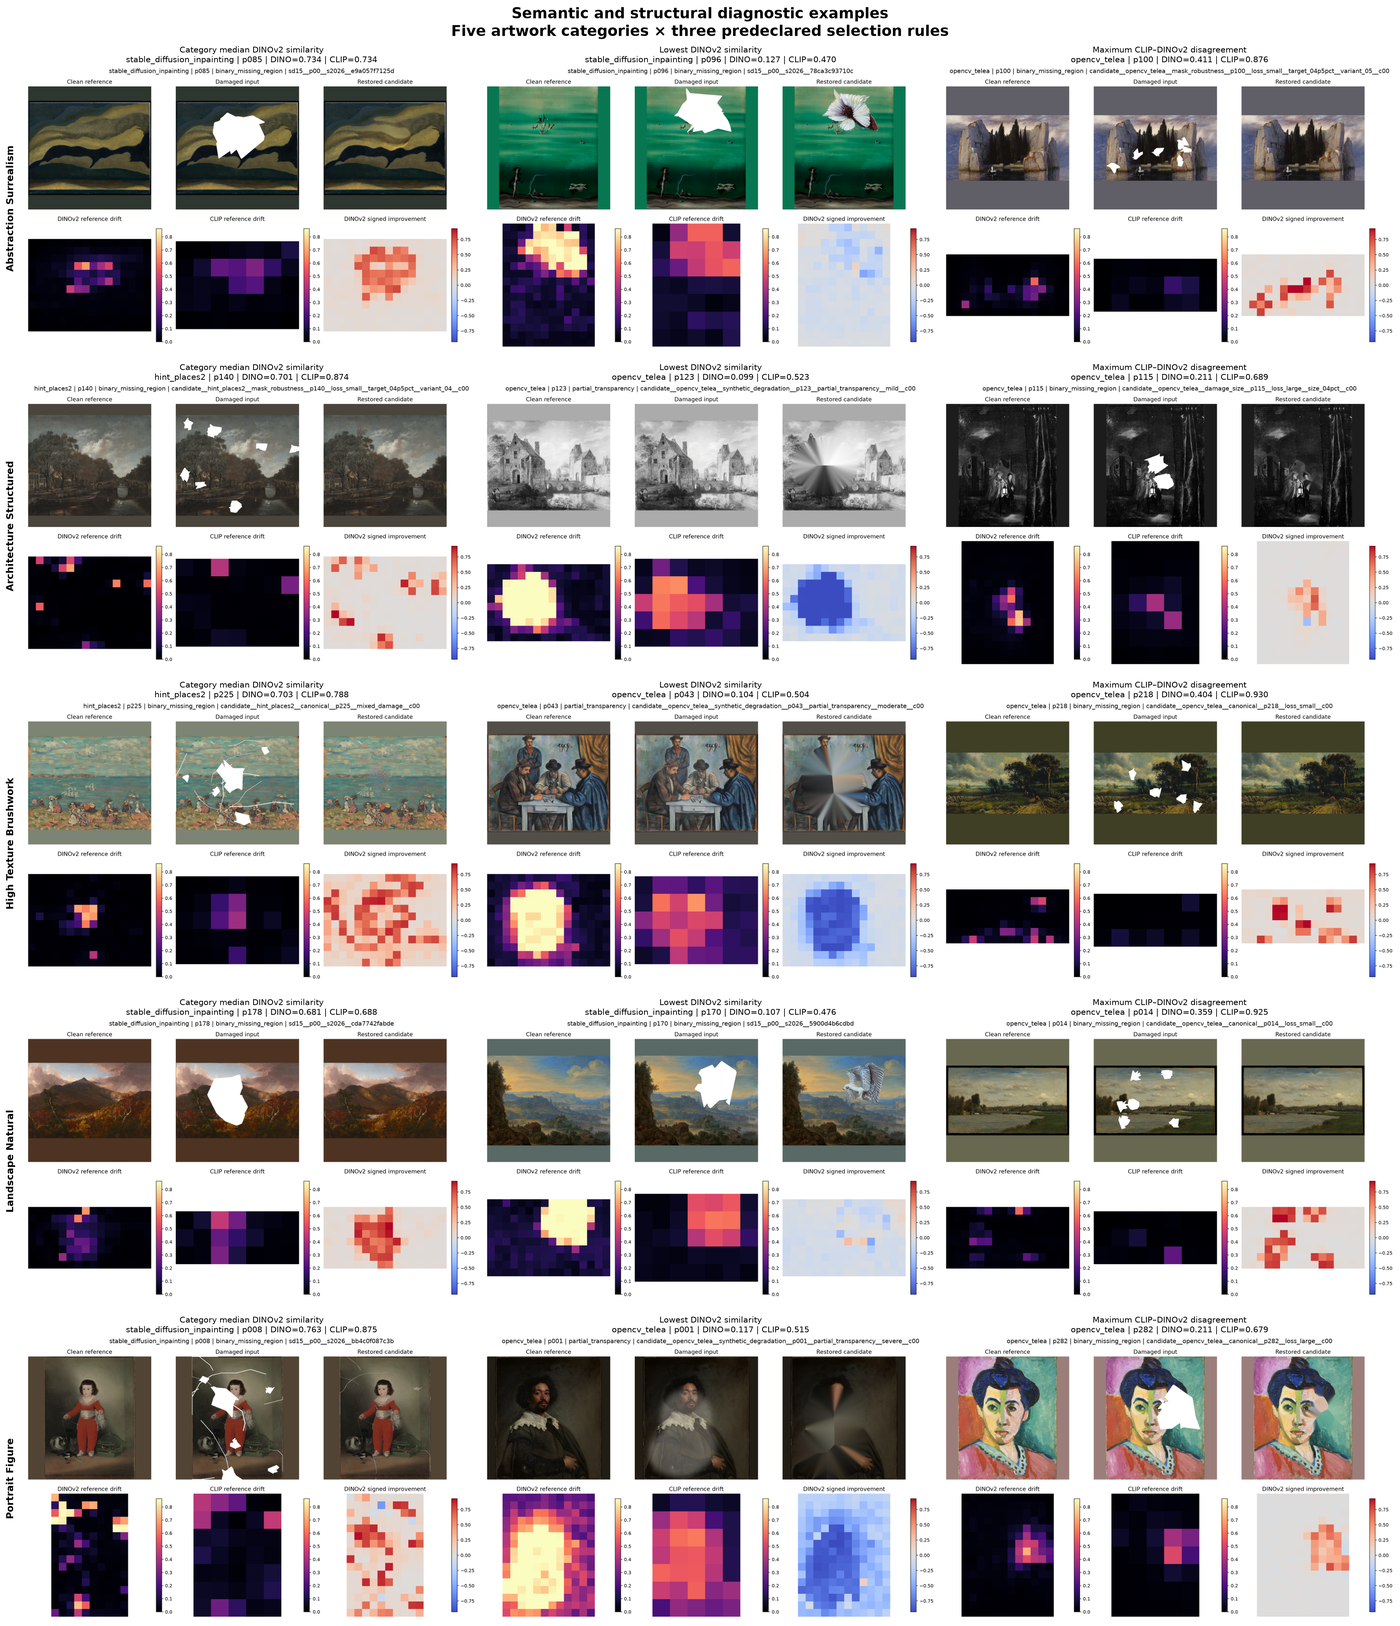

Canonical semantic-examples figure created.
Path: outputs/20_semantic_and_structural_consistency/figures/semantic_examples.png
Format: PNG
Mode: RGBA
Dimensions: (3617, 4200)
Size MiB: 6.693
SHA-256: db974f70ca7c53b60aa9a2639f7f1024166a8fafcc4aa02c779b26df37092e15


In [36]:
# ---------------------------------------------------------------------------
# Canonical semantic-examples figure
# ---------------------------------------------------------------------------

from PIL import Image as PILImage
import uuid


semantic_examples_started = time.perf_counter()

figure_rows = len(
    REPRESENTATIVE_CATEGORIES
)
figure_columns = len(
    REPRESENTATIVE_RULES
)

semantic_examples_figure = None

temporary_figure_path = (
    OUTPUTS["semantic_examples"]
    .with_name(
        OUTPUTS["semantic_examples"].stem
        + "."
        + uuid.uuid4().hex
        + ".tmp.png"
    )
)

try:
    semantic_examples_figure, semantic_examples_axes = (
        plt.subplots(
            figure_rows,
            figure_columns,
            figsize=(24, 28),
            constrained_layout=True,
        )
    )

    for selection_row in (
        representative_selection_df
        .itertuples(index=False)
    ):
        axis = semantic_examples_axes[
            int(selection_row.category_order) - 1,
            int(selection_row.rule_order) - 1,
        ]

        panel_path = resolve_repo_path(
            selection_row
            .semantic_panel_relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        observed_panel_sha256 = (
            manifest_sha256_path(panel_path)
        )

        if (
            observed_panel_sha256
            != selection_row.semantic_panel_sha256
        ):
            raise ValueError(
                "Representative semantic-panel "
                "checksum changed before figure "
                f"assembly: {panel_path}"
            )

        with PILImage.open(
            panel_path
        ) as panel_image:
            panel_preview = (
                panel_image
                .convert("RGB")
                .copy()
            )

        panel_preview.thumbnail(
            (1400, 910),
            PILImage.Resampling.LANCZOS,
        )

        panel_array = np.asarray(
            panel_preview,
            dtype=np.uint8,
        ).copy()

        axis.imshow(panel_array)

        axis.set_title(
            f"{selection_row.rule_label}\n"
            f"{selection_row.model_id} | "
            f"{selection_row.painting_id} | "
            f"DINO={selection_row.dinov2_local_similarity_bbox:.3f} | "
            f"CLIP={selection_row.clip_local_similarity_bbox:.3f}",
            fontsize=10,
        )

        if int(
            selection_row.rule_order
        ) == 1:
            axis.text(
                -0.025,
                0.5,
                str(
                    selection_row.category
                ).replace("_", " ").title(),
                transform=axis.transAxes,
                rotation=90,
                va="center",
                ha="right",
                fontsize=12,
                fontweight="bold",
            )

        axis.axis("off")

    semantic_examples_figure.suptitle(
        (
            "Semantic and structural diagnostic examples\n"
            "Five artwork categories × three "
            "predeclared selection rules"
        ),
        fontsize=18,
        fontweight="bold",
    )

    OUTPUTS[
        "semantic_examples"
    ].parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    semantic_examples_figure.savefig(
        temporary_figure_path,
        format="png",
        dpi=150,
        facecolor="white",
        bbox_inches="tight",
        metadata={
            "Title": (
                "Notebook 20 semantic examples"
            ),
            "Software": (
                "painting-restoration-eval"
            ),
        },
    )

finally:
    if semantic_examples_figure is not None:
        plt.close(
            semantic_examples_figure
        )

if not temporary_figure_path.is_file():
    raise FileNotFoundError(
        "Temporary semantic-examples figure was "
        "not created."
    )

with PILImage.open(
    temporary_figure_path
) as temporary_image:
    temporary_figure_format = str(
        temporary_image.format
    )
    temporary_figure_mode = str(
        temporary_image.mode
    )
    temporary_figure_size = (
        tuple(temporary_image.size)
    )
    temporary_image.verify()

if (
    temporary_figure_format != "PNG"
    or temporary_figure_mode
    != str(VISUAL_CONFIG["png_mode"])
    or temporary_figure_size[0] <= 0
    or temporary_figure_size[1] <= 0
):
    temporary_figure_path.unlink(
        missing_ok=True
    )
    raise ValueError(
        "Temporary semantic-examples figure failed "
        "the PNG/RGBA/dimension contract."
    )

last_replace_error = None

for replace_attempt in range(
    1,
    int(
        EXECUTION_CONFIG[
            "atomic_replace_attempts"
        ]
    )
    + 1,
):
    try:
        os.replace(
            temporary_figure_path,
            OUTPUTS["semantic_examples"],
        )
        last_replace_error = None
        break

    except PermissionError as error:
        last_replace_error = error

        if replace_attempt < int(
            EXECUTION_CONFIG[
                "atomic_replace_attempts"
            ]
        ):
            time.sleep(
                float(
                    EXECUTION_CONFIG[
                        "atomic_replace_retry_seconds"
                    ]
                )
                * replace_attempt
            )

if last_replace_error is not None:
    temporary_figure_path.unlink(
        missing_ok=True
    )
    raise PermissionError(
        "Could not atomically replace the canonical "
        "semantic-examples figure: "
        f"{last_replace_error}"
    )

with PILImage.open(
    OUTPUTS["semantic_examples"]
) as semantic_examples_image:
    semantic_examples_format = str(
        semantic_examples_image.format
    )
    semantic_examples_mode = str(
        semantic_examples_image.mode
    )
    (
        semantic_examples_width,
        semantic_examples_height,
    ) = semantic_examples_image.size

    semantic_examples_preview = (
        semantic_examples_image
        .convert("RGB")
        .copy()
    )

semantic_examples_preview.thumbnail(
    (1400, 1650),
    PILImage.Resampling.LANCZOS,
)

semantic_examples_sha256 = (
    manifest_sha256_path(
        OUTPUTS["semantic_examples"]
    )
)

semantic_examples_size_bytes = int(
    OUTPUTS[
        "semantic_examples"
    ].stat().st_size
)

display(semantic_examples_preview)

print("Canonical semantic-examples figure created.")
print(
    "Path:",
    to_repo_relative(
        OUTPUTS["semantic_examples"],
        PROJECT_ROOT,
    ),
)
print(
    "Format:",
    semantic_examples_format,
)
print(
    "Mode:",
    semantic_examples_mode,
)
print(
    "Dimensions:",
    (
        semantic_examples_width,
        semantic_examples_height,
    ),
)
print(
    "Size MiB:",
    round(
        semantic_examples_size_bytes
        / (1024**2),
        3,
    ),
)
print(
    "SHA-256:",
    semantic_examples_sha256,
)

In [37]:
# ---------------------------------------------------------------------------
# Batch 8 analysis and figure validation
# ---------------------------------------------------------------------------

BATCH_8_VALIDATION_STAGE = (
    "batch_8_analysis_and_figures"
)

retained_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != BATCH_8_VALIDATION_STAGE
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)


def add_batch_8_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            BATCH_8_VALIDATION_STAGE
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


observed_candidates_by_model = (
    analysis_candidate_df[
        "model_id"
    ]
    .astype(str)
    .value_counts()
    .to_dict()
)

add_batch_8_check(
    "analysis_population",
    (
        "Candidate-level analysis retains the exact "
        "2,160-candidate population and per-model "
        "counts."
    ),
    {
        "candidates": EXPECTED_COUNTS[
            "evaluated_candidates"
        ],
        "candidates_by_model": (
            EXPECTED_COUNTS[
                "candidates_by_model"
            ]
        ),
    },
    {
        "candidates": len(
            analysis_candidate_df
        ),
        "candidates_by_model": (
            observed_candidates_by_model
        ),
    },
    (
        len(analysis_candidate_df)
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
        and observed_candidates_by_model
        == EXPECTED_COUNTS[
            "candidates_by_model"
        ]
        and analysis_candidate_df[
            "candidate_id"
        ].is_unique
    ),
)

observed_category_rule_pairs = set(
    zip(
        representative_selection_df[
            "category"
        ].astype(str),
        representative_selection_df[
            "rule_id"
        ].astype(str),
    )
)

expected_category_rule_pairs = {
    (category, rule_id)
    for category in REPRESENTATIVE_CATEGORIES
    for rule_id in REPRESENTATIVE_RULES
}

add_batch_8_check(
    "representative_rule_coverage",
    (
        "The representative figure contains every "
        "configured category-by-rule combination."
    ),
    {
        "representatives": EXPECTED_COUNTS[
            "representative_cases"
        ],
        "category_rule_pairs": len(
            expected_category_rule_pairs
        ),
    },
    {
        "representatives": len(
            representative_selection_df
        ),
        "category_rule_pairs": len(
            observed_category_rule_pairs
        ),
    },
    (
        len(representative_selection_df)
        == EXPECTED_COUNTS[
            "representative_cases"
        ]
        and observed_category_rule_pairs
        == expected_category_rule_pairs
    ),
)

add_batch_8_check(
    "representative_identity_uniqueness",
    (
        "The 15 representative slots use distinct "
        "candidate and case identities."
    ),
    {
        "unique_candidates": EXPECTED_COUNTS[
            "representative_cases"
        ],
        "unique_cases": EXPECTED_COUNTS[
            "representative_cases"
        ],
    },
    {
        "unique_candidates": (
            representative_selection_df[
                "candidate_id"
            ].nunique()
        ),
        "unique_cases": (
            representative_selection_df[
                "case_id"
            ].nunique()
        ),
    },
    (
        representative_selection_df[
            "candidate_id"
        ].is_unique
        and representative_selection_df[
            "case_id"
        ].is_unique
    ),
)

figure_contract_passed = bool(
    OUTPUTS["semantic_examples"].is_file()
    and semantic_examples_format == "PNG"
    and semantic_examples_mode
    == str(VISUAL_CONFIG["png_mode"])
    and semantic_examples_width > 0
    and semantic_examples_height > 0
    and len(semantic_examples_sha256) == 64
)

add_batch_8_check(
    "semantic_examples_figure",
    (
        "The canonical semantic-examples figure "
        "reloads as a positive-dimension RGBA PNG."
    ),
    {
        "exists": True,
        "format": "PNG",
        "mode": VISUAL_CONFIG[
            "png_mode"
        ],
        "positive_dimensions": True,
    },
    {
        "exists": OUTPUTS[
            "semantic_examples"
        ].is_file(),
        "format": semantic_examples_format,
        "mode": semantic_examples_mode,
        "width": semantic_examples_width,
        "height": semantic_examples_height,
    },
    figure_contract_passed,
)

map_manifest_unchanged = bool(
    len(
        reloaded_semantic_map_manifest_df
    )
    == EXPECTED_COUNTS[
        "map_manifest_rows"
    ]
    and set(
        reloaded_semantic_map_manifest_df[
            "semantic_map_asset_id"
        ].astype(str)
    )
    == set(
        semantic_map_manifest_df[
            "semantic_map_asset_id"
        ].astype(str)
    )
)

add_batch_8_check(
    "map_manifest_scope_unchanged",
    (
        "The composite examples figure does not alter "
        "the 9,430-record semantic-map manifest."
    ),
    EXPECTED_COUNTS[
        "map_manifest_rows"
    ],
    len(
        reloaded_semantic_map_manifest_df
    ),
    map_manifest_unchanged,
)

canonical_files_at_batch_8 = sorted(
    path
    for directory_name in (
        "data",
        "metrics",
        "images",
        "figures",
        "manifests",
        "validation",
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / directory_name
    ).rglob("*")
    if path.is_file()
)

temporary_canonical_files_batch_8 = [
    path
    for path in canonical_files_at_batch_8
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

expected_batch_8_canonical_files = (
    EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ]
    + 4
)

add_batch_8_check(
    "batch_8_canonical_file_scope",
    (
        "Batch 8 adds only the canonical examples "
        "figure to the validated Batch 7 outputs."
    ),
    {
        "canonical_files": (
            expected_batch_8_canonical_files
        ),
        "temporary_files": 0,
    },
    {
        "canonical_files": len(
            canonical_files_at_batch_8
        ),
        "temporary_files": len(
            temporary_canonical_files_batch_8
        ),
    },
    (
        len(canonical_files_at_batch_8)
        == expected_batch_8_canonical_files
        and not temporary_canonical_files_batch_8
    ),
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in temporary_canonical_files_batch_8
    ],
)

add_batch_8_check(
    "transparent_analysis_policy",
    (
        "Analysis retains separate evidence signals "
        "and introduces no combined score or final "
        "trustworthiness flag."
    ),
    {
        "combined_score_columns": 0,
        "final_flag_columns": 0,
    },
    {
        "combined_score_columns": len(
            [
                column
                for column
                in analysis_candidate_df.columns
                if "combined_score"
                in column.lower()
            ]
        ),
        "final_flag_columns": len(
            [
                column
                for column
                in analysis_candidate_df.columns
                if "final_flag"
                in column.lower()
                or (
                    "trustworthiness"
                    in column.lower()
                    and "flag"
                    in column.lower()
                )
            ]
        ),
    },
    (
        not any(
            "combined_score"
            in column.lower()
            for column
            in analysis_candidate_df.columns
        )
        and not any(
            (
                "final_flag"
                in column.lower()
                or (
                    "trustworthiness"
                    in column.lower()
                    and "flag"
                    in column.lower()
                )
            )
            for column
            in analysis_candidate_df.columns
        )
    ),
)

batch_8_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_8_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(batch_8_validation_df)

VALIDATION.raise_for_blocking()

analysis_runtime_seconds = (
    time.perf_counter()
    - analysis_started
)

print("Notebook 20 Batch 8 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_8_validation_df),
)
print(
    "Blocking failures:",
    int(
        (
            ~batch_8_validation_df[
                "passed"
            ].astype(bool)
        ).sum()
    ),
)
print(
    "Analyzed candidates:",
    len(analysis_candidate_df),
)
print(
    "Representative cases:",
    len(representative_selection_df),
)
print(
    "Canonical figure:",
    to_repo_relative(
        OUTPUTS["semantic_examples"],
        PROJECT_ROOT,
    ),
)
print(
    "Canonical files at this stage:",
    len(canonical_files_at_batch_8),
)
print(
    "Analysis and figure runtime seconds:",
    round(
        analysis_runtime_seconds,
        3,
    ),
)
print("Batch 8 completion gate passed.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_analysis_and_figures,analysis_population,"Candidate-level analysis retains the exact 2,1...",blocking,"{""candidates"": 16404, ""candidates_by_model"": {...","{""candidates"": 16404, ""candidates_by_model"": {...",True,
1,batch_8_analysis_and_figures,representative_rule_coverage,The representative figure contains every confi...,blocking,"{""category_rule_pairs"": 15, ""representatives"":...","{""category_rule_pairs"": 15, ""representatives"":...",True,
2,batch_8_analysis_and_figures,representative_identity_uniqueness,The 15 representative slots use distinct candi...,blocking,"{""unique_candidates"": 15, ""unique_cases"": 15}","{""unique_candidates"": 15, ""unique_cases"": 15}",True,
3,batch_8_analysis_and_figures,semantic_examples_figure,The canonical semantic-examples figure reloads...,blocking,"{""exists"": true, ""format"": ""PNG"", ""mode"": ""RGB...","{""exists"": true, ""format"": ""PNG"", ""height"": 42...",True,
4,batch_8_analysis_and_figures,map_manifest_scope_unchanged,The composite examples figure does not alter t...,blocking,72520,72520,True,
5,batch_8_analysis_and_figures,batch_8_canonical_file_scope,Batch 8 adds only the canonical examples figur...,blocking,"{""canonical_files"": 9308, ""temporary_files"": 0}","{""canonical_files"": 9308, ""temporary_files"": 0}",True,[]
6,batch_8_analysis_and_figures,transparent_analysis_policy,Analysis retains separate evidence signals and...,blocking,"{""combined_score_columns"": 0, ""final_flag_colu...","{""combined_score_columns"": 0, ""final_flag_colu...",True,


Notebook 20 Batch 8 summary
---------------------------
Validation checks: 7
Blocking failures: 0
Analyzed candidates: 16404
Representative cases: 15
Canonical figure: outputs/20_semantic_and_structural_consistency/figures/semantic_examples.png
Canonical files at this stage: 9308
Analysis and figure runtime seconds: 28.473
Batch 8 completion gate passed.


## Batch 9 — Final manifests, traceability, cleanup, and completion gate

This batch performs the final Notebook 20 handoff.

It:

- audits every roadmap responsibility against concrete notebook evidence;
- independently reloads the canonical metrics, numeric maps, map manifest, rendered figure, and image collection;
- removes only Notebook 20 checkpoint state under its validated `work/` directory;
- persists the consolidated validation table;
- creates the normalized six-record artifact manifest;
- creates the universal run manifest;
- registers validated downstream artifacts in the project-path registry;
- verifies exact file ownership, schemas, checksums, row counts, limitations, and completion status.

The notebook retains separate semantic and structural evidence components. It produces no combined semantic score, calibrated confidence value, final trustworthiness flag, face/object detection claim, or standalone report.

In [38]:
# ---------------------------------------------------------------------------
# Final manifest, registry, and schema utilities
# ---------------------------------------------------------------------------

import gc
import shutil

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    sha256_path,
    write_run_manifest,
)

from restoration_eval.paths import (
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
)


FINAL_CANONICAL_FILE_COUNT = int(
    EXPECTED_COUNTS[
        "canonical_file_count"
    ]
)

FINAL_ARTIFACT_RECORD_COUNT = int(
    EXPECTED_COUNTS[
        "artifact_records"
    ]
)

SEMANTIC_EXAMPLES_LAYOUT_VERSION = (
    "semantic_examples_layout.v1"
)

FINAL_HELPER_PATHS = {
    "semantic_structural": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "semantic_structural.py"
    ),
    "feature_similarity": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_feature_similarity.py"
    ),
    "evaluation_inputs": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "evaluation_inputs.py"
    ),
    "regions": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "regions.py"
    ),
    "schemas": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
    "paths": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "paths.py"
    ),
    "manifests": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "manifests.py"
    ),
    "validation": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "validation.py"
    ),
}

missing_final_helpers = [
    key
    for key, path in FINAL_HELPER_PATHS.items()
    if not path.is_file()
]

if missing_final_helpers:
    raise FileNotFoundError(
        "Final helper files are missing: "
        f"{missing_final_helpers}"
    )

current_helper_checksums = {
    key: manifest_sha256_path(path)
    for key, path in FINAL_HELPER_PATHS.items()
}


# ---------------------------------------------------------------------------
# Responsibility-by-responsibility roadmap traceability
# ---------------------------------------------------------------------------

semantic_family_counts = {
    str(key): int(value)
    for key, value in (
        reloaded_semantic_metrics_df[
            "evidence_family"
        ]
        .astype(str)
        .value_counts()
        .sort_index()
        .items()
    )
}

semantic_metric_names = set(
    reloaded_semantic_metrics_df[
        "metric_name"
    ].astype(str)
)

observed_semantic_categories = set(
    reloaded_semantic_metrics_df[
        "category"
    ].astype(str)
)

observed_target_scopes = set(
    reloaded_semantic_metrics_df[
        "semantic_target_scope"
    ].astype(str)
)

EXPECTED_TARGET_SCOPES = {
    "facial_anatomical_structure_proxy",
    "architectural_layout_proxy",
    "natural_object_structure_proxy",
    "abstract_compositional_structure_proxy",
    "painterly_surface_structure_proxy",
}

rendered_candidate_path_identity_passed = all(
    str(row.candidate_id)
    in Path(
        str(row.relative_path)
    ).parts
    for row in (
        rendered_manifest_df
        .itertuples(index=False)
    )
)

roadmap_traceability_records = [
    {
        "requirement_id": "N20-R01",
        "roadmap_requirement": (
            "Evaluate subject preservation."
        ),
        "implementation_evidence": (
            "4,320 Notebook 15-linked global CLIP "
            "and DINOv2 similarity rows."
        ),
        "passed": (
            semantic_family_counts.get(
                "subject_preservation",
                0,
            )
            == EXPECTED_COUNTS[
                "subject_preservation_rows"
            ]
        ),
    },
    {
        "requirement_id": "N20-R02",
        "roadmap_requirement": (
            "Evaluate composition and salient-structure "
            "preservation."
        ),
        "implementation_evidence": (
            "8,640 reference-affinity layout rows."
        ),
        "passed": (
            semantic_family_counts.get(
                "structural_layout",
                0,
            )
            == EXPECTED_COUNTS[
                "structural_layout_rows"
            ]
        ),
    },
    {
        "requirement_id": "N20-R03",
        "roadmap_requirement": (
            "Detect possible new semantic content "
            "diagnostically."
        ),
        "implementation_evidence": (
            "8,340 local-worsening rows and unclipped "
            "reference-drift maps, explicitly treated "
            "as proxies rather than object detection."
        ),
        "passed": (
            semantic_family_counts.get(
                "local_semantic_worsening",
                0,
            )
            == EXPECTED_COUNTS[
                "local_worsened_fraction_rows"
            ]
            and "local_patch_worsened_fraction"
            in semantic_metric_names
        ),
    },
    {
        "requirement_id": "N20-R04",
        "roadmap_requirement": (
            "Detect plausible but reference-inconsistent "
            "objects without unsupported detector claims."
        ),
        "implementation_evidence": (
            "Aligned local CLIP/DINOv2 evidence and "
            "category-conditioned drift interpretation; "
            "object-detection claim disabled."
        ),
        "passed": (
            semantic_family_counts.get(
                "local_semantic_preservation",
                0,
            )
            == EXPECTED_COUNTS[
                "local_similarity_summary_rows"
            ]
            and not bool(
                EVIDENCE_POLICY[
                    "object_detection_claim"
                ]
            )
        ),
    },
    {
        "requirement_id": "N20-R05",
        "roadmap_requirement": (
            "Evaluate painterly-style preservation "
            "diagnostically."
        ),
        "implementation_evidence": (
            "4,170 DINOv2 patch-covariance distance rows."
        ),
        "passed": (
            semantic_family_counts.get(
                "painterly_representation",
                0,
            )
            == EXPECTED_COUNTS[
                "painterly_proxy_rows"
            ]
            and (
                "dinov2_patch_covariance_distance"
                in semantic_metric_names
            )
        ),
    },
    {
        "requirement_id": "N20-R06",
        "roadmap_requirement": (
            "Detect alteration of unmasked context."
        ),
        "implementation_evidence": (
            "4,320 outside-mask context-preservation rows "
            "with explicit no-data annotations where the "
            "encoder grid has no eligible outside token."
        ),
        "passed": (
            semantic_family_counts.get(
                "outside_context_preservation",
                0,
            )
            == EXPECTED_COUNTS[
                "outside_context_rows"
            ]
        ),
    },
    {
        "requirement_id": "N20-R07",
        "roadmap_requirement": (
            "Inspect facial, anatomical, architectural, "
            "natural-object, abstract-compositional, and "
            "painterly-surface drift where applicable."
        ),
        "implementation_evidence": (
            "Five category-conditioned interpretation "
            "scopes applied to all evidence rows."
        ),
        "passed": (
            observed_target_scopes
            == EXPECTED_TARGET_SCOPES
            and len(
                observed_semantic_categories
            )
            == 5
        ),
    },
    {
        "requirement_id": "N20-R08",
        "roadmap_requirement": (
            "Compute patch-level DINOv2 similarity."
        ),
        "implementation_evidence": (
            "DINOv2 16×16 aligned local-token evidence "
            "over content and mask-bounding-box regions."
        ),
        "passed": (
            (
                reloaded_semantic_metrics_df[
                    "feature_model_id"
                ].astype(str).eq(
                    "dinov2_vits14"
                )
                & reloaded_semantic_metrics_df[
                    "metric_name"
                ].astype(str).eq(
                    "local_patch_cosine_similarity"
                )
            ).sum()
            == (
                EXPECTED_COUNTS[
                    "candidate_region_evaluations_per_encoder"
                ]
                * 3
            )
        ),
    },
    {
        "requirement_id": "N20-R09",
        "roadmap_requirement": (
            "Compute patch-level CLIP similarity where "
            "methodologically useful."
        ),
        "implementation_evidence": (
            "CLIP 7×7 aligned local-token evidence over "
            "content and mask-bounding-box regions."
        ),
        "passed": (
            (
                reloaded_semantic_metrics_df[
                    "feature_model_id"
                ].astype(str).eq(
                    "clip_vit_b32"
                )
                & reloaded_semantic_metrics_df[
                    "metric_name"
                ].astype(str).eq(
                    "local_patch_cosine_similarity"
                )
            ).sum()
            == (
                EXPECTED_COUNTS[
                    "candidate_region_evaluations_per_encoder"
                ]
                * 3
            )
        ),
    },
    {
        "requirement_id": "N20-R10",
        "roadmap_requirement": (
            "Implement sliding-window or local-feature "
            "comparison."
        ),
        "implementation_evidence": (
            "4,170 aligned candidate-region evaluations "
            "per encoder using local patch grids."
        ),
        "passed": (
            len(
                numeric_bundle_index_df
            )
            == EXPECTED_COUNTS[
                "numeric_map_bundles"
            ]
        ),
    },
    {
        "requirement_id": "N20-R11",
        "roadmap_requirement": (
            "Add local embedding maps."
        ),
        "implementation_evidence": (
            "8,340 unclipped numeric semantic bundles "
            "persisted in a compressed archive."
        ),
        "passed": (
            len(expected_archive_keys)
            == EXPECTED_COUNTS[
                "numeric_map_bundles"
            ]
            and OUTPUTS[
                "numeric_maps"
            ].is_file()
        ),
    },
    {
        "requirement_id": "N20-R12",
        "roadmap_requirement": (
            "Add saliency-aware analysis where feasible."
        ),
        "implementation_evidence": (
            "Reference-derived DINOv2 CLS-to-patch "
            "feature affinity retained as a labelled "
            "diagnostic saliency proxy."
        ),
        "passed": (
            "reference_affinity_weighted_similarity"
            in semantic_metric_names
            and EVIDENCE_POLICY[
                "saliency_proxy"
            ]
            == (
                "reference_derived_cls_to_patch_"
                "feature_affinity"
            )
        ),
    },
    {
        "requirement_id": "N20-R13",
        "roadmap_requirement": (
            "Use structural-layout comparison where "
            "defensible."
        ),
        "implementation_evidence": (
            "Centroid shift, Jensen–Shannon divergence, "
            "map correlation, and affinity-weighted "
            "similarity retained separately."
        ),
        "passed": {
            "reference_affinity_centroid_shift",
            "reference_affinity_js_divergence",
            "reference_affinity_map_correlation",
            "reference_affinity_weighted_similarity",
        }.issubset(semantic_metric_names),
    },
    {
        "requirement_id": "N20-R14",
        "roadmap_requirement": (
            "Record category applicability and avoid "
            "universal facial or anatomical checks."
        ),
        "implementation_evidence": (
            "Five explicit semantic_target_scope values; "
            "no face or anatomy detector used."
        ),
        "passed": (
            observed_target_scopes
            == EXPECTED_TARGET_SCOPES
            and not bool(
                EVIDENCE_POLICY[
                    "face_or_anatomy_detector_used"
                ]
            )
        ),
    },
    {
        "requirement_id": "N20-R15",
        "roadmap_requirement": (
            "State limitations of pretrained "
            "non-conservation-specific models."
        ),
        "implementation_evidence": (
            "Versioned configuration and opening "
            "Markdown retain explicit interpretation "
            "limits and known limitations."
        ),
        "passed": (
            len(
                SEMANTIC_CONFIG[
                    "known_limitations"
                ]
            )
            >= 7
            and not bool(
                EVIDENCE_POLICY[
                    "historical_correctness_claim"
                ]
            )
        ),
    },
    {
        "requirement_id": "N20-R16",
        "roadmap_requirement": (
            "Produce machine-readable evidence for "
            "later flags without assigning final flags."
        ),
        "implementation_evidence": (
            "58,980 schema-valid evidence rows; all "
            "combined-score and final-flag fields false."
        ),
        "passed": (
            len(
                reloaded_semantic_metrics_df
            )
            == EXPECTED_COUNTS[
                "semantic_metric_rows"
            ]
            and not reloaded_semantic_metrics_df[
                "is_combined_score"
            ].astype(bool).any()
            and not reloaded_semantic_metrics_df[
                "is_final_trustworthiness_flag"
            ].astype(bool).any()
        ),
    },
    {
        "requirement_id": "N20-C01",
        "roadmap_requirement": (
            "Retain all 2,160 completed candidates, "
            "including zero controls, diffusion prompts, "
            "seeds, and partial SDXL scope."
        ),
        "implementation_evidence": (
            "Exact 2,160-candidate population with "
            "150 zero controls and approved model counts."
        ),
        "passed": (
            len(analysis_candidate_df)
            == EXPECTED_COUNTS[
                "evaluated_candidates"
            ]
            and int(
                analysis_candidate_df[
                    "is_zero_control"
                ].astype(bool).sum()
            )
            == EXPECTED_COUNTS[
                "zero_control_candidates"
            ]
        ),
    },
    {
        "requirement_id": "N20-C02",
        "roadmap_requirement": (
            "Retain unclipped bundles and render only "
            "the 1,090 approved primary nonzero panels."
        ),
        "implementation_evidence": (
            "8,340 NPZ bundles, 1,090 RGBA panels, "
            "and 9,430 normalized map-manifest rows."
        ),
        "passed": (
            len(numeric_manifest_df)
            == EXPECTED_COUNTS[
                "numeric_map_bundles"
            ]
            and len(rendered_manifest_df)
            == EXPECTED_COUNTS[
                "rendered_semantic_panels"
            ]
            and len(
                reloaded_semantic_map_manifest_df
            )
            == EXPECTED_COUNTS[
                "map_manifest_rows"
            ]
        ),
    },
    {
        "requirement_id": "N20-C03",
        "roadmap_requirement": (
            "Do not introduce unsupported photographic "
            "detectors or causal occlusion sensitivity."
        ),
        "implementation_evidence": (
            "Detector claims disabled and occlusion "
            "sensitivity explicitly not applicable."
        ),
        "passed": (
            not bool(
                EVIDENCE_POLICY[
                    "subject_recognition_claim"
                ]
            )
            and not bool(
                EVIDENCE_POLICY[
                    "object_detection_claim"
                ]
            )
            and EVIDENCE_POLICY[
                "occlusion_sensitivity_status"
            ]
            == (
                "not_applicable_without_"
                "stable_prediction_target"
            )
        ),
    },
    {
        "requirement_id": "N20-C04",
        "roadmap_requirement": (
            "Use candidate_id as map filename identity."
        ),
        "implementation_evidence": (
            "Every rendered panel path contains its "
            "candidate_id directory component."
        ),
        "passed": (
            rendered_candidate_path_identity_passed
        ),
    },
    {
        "requirement_id": "N20-C05",
        "roadmap_requirement": (
            "Generate auditable representative "
            "semantic visualizations."
        ),
        "implementation_evidence": (
            "Fifteen distinct cases across five "
            "categories and three predeclared rules."
        ),
        "passed": (
            len(
                representative_selection_df
            )
            == EXPECTED_COUNTS[
                "representative_cases"
            ]
            and OUTPUTS[
                "semantic_examples"
            ].is_file()
        ),
    },
    {
        "requirement_id": "N20-C06",
        "roadmap_requirement": (
            "Do not generate a standalone report."
        ),
        "implementation_evidence": (
            "No report output is declared or persisted."
        ),
        "passed": (
            "report" not in OUTPUTS
            and not any(
                path.is_file()
                for path in (
                    NOTEBOOK_OUTPUT_ROOT
                    / "reports"
                ).rglob("*")
            )
        ),
    },
]

requirement_traceability_df = (
    pd.DataFrame(
        roadmap_traceability_records
    )
)

traceability_failures_df = (
    requirement_traceability_df.loc[
        ~requirement_traceability_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Exact pre-metadata canonical scope
# ---------------------------------------------------------------------------

expected_panel_files = {
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=True,
    ).resolve()
    for relative_path in (
        rendered_manifest_df[
            "relative_path"
        ].astype(str)
    )
}

expected_pre_metadata_files = {
    *expected_panel_files,
    OUTPUTS["numeric_maps"].resolve(),
    OUTPUTS["semantic_metrics"].resolve(),
    OUTPUTS["semantic_examples"].resolve(),
    OUTPUTS[
        "semantic_map_manifest"
    ].resolve(),
}

observed_pre_metadata_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and "work"
        not in path.relative_to(
            NOTEBOOK_OUTPUT_ROOT
        ).parts
    )
}

if (
    len(expected_pre_metadata_files)
    != EXPECTED_COUNTS[
        "rendered_semantic_panels"
    ]
    + 4
):
    raise ValueError(
        "Expected pre-metadata file scope has "
        "unexpected cardinality."
    )


# ---------------------------------------------------------------------------
# Safe cleanup of Notebook 20 checkpoint state
# ---------------------------------------------------------------------------

work_root = (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).resolve()

resolved_output_root = (
    NOTEBOOK_OUTPUT_ROOT.resolve()
)

if (
    work_root.parent
    != resolved_output_root
    or work_root.name != "work"
):
    raise RuntimeError(
        "Refusing cleanup because the resolved work "
        "directory is outside Notebook 20's output root."
    )

work_files_before_cleanup = (
    [
        path
        for path in work_root.rglob("*")
        if path.is_file()
    ]
    if work_root.exists()
    else []
)

work_size_bytes_before_cleanup = sum(
    int(path.stat().st_size)
    for path in work_files_before_cleanup
)

cleanup_ready = bool(
    traceability_failures_df.empty
    and observed_pre_metadata_files
    == expected_pre_metadata_files
    and len(
        VALIDATION.blocking_failures
    )
    == 0
)

if not cleanup_ready:
    raise RuntimeError(
        "Work cleanup is blocked because canonical "
        "scope or roadmap traceability has not passed."
    )

gc.collect()


def remove_notebook_work_directory(
    directory,
    attempts=8,
):
    directory = Path(directory)

    for attempt in range(
        1,
        int(attempts) + 1,
    ):
        if not directory.exists():
            return True

        try:
            shutil.rmtree(directory)

            if not directory.exists():
                return True

        except (
            PermissionError,
            OSError,
        ):
            gc.collect()

            if attempt < attempts:
                time.sleep(
                    min(
                        0.25 * attempt,
                        2.0,
                    )
                )

    return not directory.exists()


work_cleanup_succeeded = (
    remove_notebook_work_directory(
        work_root,
        attempts=int(
            EXECUTION_CONFIG[
                "atomic_replace_attempts"
            ]
        ),
    )
)

if not work_cleanup_succeeded:
    raise RuntimeError(
        "Notebook 20 work-directory cleanup failed."
    )

observed_pre_metadata_files_after_cleanup = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

display(requirement_traceability_df)
display(traceability_failures_df)

print("Notebook 20 roadmap traceability complete.")
print(
    "Roadmap requirements:",
    len(requirement_traceability_df),
)
print(
    "Traceability failures:",
    len(traceability_failures_df),
)
print(
    "Pre-metadata canonical files:",
    len(
        observed_pre_metadata_files_after_cleanup
    ),
)
print(
    "Pre-metadata scope exact:",
    observed_pre_metadata_files_after_cleanup
    == expected_pre_metadata_files,
)
print(
    "Work files removed:",
    len(work_files_before_cleanup),
)
print(
    "Work size removed GiB:",
    round(
        work_size_bytes_before_cleanup
        / (1024**3),
        3,
    ),
)
print(
    "Work directory exists:",
    work_root.exists(),
)

,requirement_id,roadmap_requirement,implementation_evidence,passed
0,N20-R01,Evaluate subject preservation.,"4,320 Notebook 15-linked global CLIP and DINOv...",True
1,N20-R02,Evaluate composition and salient-structure pre...,"8,640 reference-affinity layout rows.",True
2,N20-R03,Detect possible new semantic content diagnosti...,"8,340 local-worsening rows and unclipped refer...",True
3,N20-R04,Detect plausible but reference-inconsistent ob...,Aligned local CLIP/DINOv2 evidence and categor...,True
4,N20-R05,Evaluate painterly-style preservation diagnost...,"4,170 DINOv2 patch-covariance distance rows.",True
5,N20-R06,Detect alteration of unmasked context.,"4,320 outside-mask context-preservation rows w...",True
6,N20-R07,"Inspect facial, anatomical, architectural, nat...",Five category-conditioned interpretation scope...,True
7,N20-R08,Compute patch-level DINOv2 similarity.,DINOv2 16×16 aligned local-token evidence over...,True
8,N20-R09,Compute patch-level CLIP similarity where meth...,CLIP 7×7 aligned local-token evidence over con...,True
9,N20-R10,Implement sliding-window or local-feature comp...,"4,170 aligned candidate-region evaluations per...",True


,requirement_id,roadmap_requirement,implementation_evidence,passed


Notebook 20 roadmap traceability complete.
Roadmap requirements: 22
Traceability failures: 0
Pre-metadata canonical files: 9308
Pre-metadata scope exact: True
Work files removed: 17320
Work size removed GiB: 9.7
Work directory exists: False


In [39]:
# ---------------------------------------------------------------------------
# Rerunnable final completion-validation stage
# ---------------------------------------------------------------------------

FINAL_VALIDATION_STAGE = (
    "batch_9_completion_gate"
)

retained_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != FINAL_VALIDATION_STAGE
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)


def add_completion_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            FINAL_VALIDATION_STAGE
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Independent canonical reloads
# ---------------------------------------------------------------------------

completion_metrics_df = pd.read_csv(
    OUTPUTS["semantic_metrics"],
    low_memory=False,
)

completion_metrics_validation = (
    validate_semantic_metrics(
        completion_metrics_df,
        config=semantic_config,
    )
)

completion_numeric_maps = (
    load_semantic_map_archive(
        OUTPUTS["numeric_maps"]
    )
)

completion_map_manifest_df = pd.read_csv(
    OUTPUTS["semantic_map_manifest"],
    low_memory=False,
)

completion_map_manifest_validation = (
    validate_semantic_map_manifest(
        completion_map_manifest_df,
        config=semantic_config,
    )
)

with PILImage.open(
    OUTPUTS["semantic_examples"]
) as completion_figure:
    completion_figure_format = str(
        completion_figure.format
    )
    completion_figure_mode = str(
        completion_figure.mode
    )
    (
        completion_figure_width,
        completion_figure_height,
    ) = completion_figure.size
    completion_figure.verify()

completion_helper_checksums = {
    key: manifest_sha256_path(path)
    for key, path in FINAL_HELPER_PATHS.items()
}

report_files = [
    path
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and path.suffix.lower()
        in {
            ".html",
            ".htm",
            ".md",
        }
        and (
            "report" in path.name.lower()
            or "reports"
            in {
                part.lower()
                for part in path.parts
            }
        )
    )
]


# ---------------------------------------------------------------------------
# Completion checks
# ---------------------------------------------------------------------------

add_completion_check(
    "persisted_semantic_metrics",
    (
        "The canonical 58,980-row semantic metric "
        "table reloads and passes its schema and "
        "scientific contract."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "semantic_metric_rows"
        ],
        "passed": True,
    },
    {
        "rows": len(
            completion_metrics_df
        ),
        "passed": (
            completion_metrics_validation[
                "passed"
            ]
        ),
    },
    (
        len(completion_metrics_df)
        == EXPECTED_COUNTS[
            "semantic_metric_rows"
        ]
        and completion_metrics_validation[
            "passed"
        ]
    ),
)

add_completion_check(
    "persisted_numeric_maps",
    (
        "The canonical numeric archive reloads with "
        "all 8,340 semantic bundles."
    ),
    EXPECTED_COUNTS[
        "numeric_map_bundles"
    ],
    len(completion_numeric_maps),
    (
        len(completion_numeric_maps)
        == EXPECTED_COUNTS[
            "numeric_map_bundles"
        ]
        and set(
            completion_numeric_maps
        )
        == expected_archive_keys
    ),
)

add_completion_check(
    "persisted_semantic_map_manifest",
    (
        "The normalized 9,430-row semantic-map "
        "manifest reloads and validates."
    ),
    {
        "rows": EXPECTED_COUNTS[
            "map_manifest_rows"
        ],
        "passed": True,
    },
    {
        "rows": len(
            completion_map_manifest_df
        ),
        "passed": (
            completion_map_manifest_validation[
                "passed"
            ]
        ),
    },
    (
        len(completion_map_manifest_df)
        == EXPECTED_COUNTS[
            "map_manifest_rows"
        ]
        and completion_map_manifest_validation[
            "passed"
        ]
    ),
)

add_completion_check(
    "persisted_semantic_examples",
    (
        "The canonical semantic-examples figure "
        "reloads as a positive-dimension RGBA PNG."
    ),
    {
        "format": "PNG",
        "mode": VISUAL_CONFIG[
            "png_mode"
        ],
        "positive_dimensions": True,
    },
    {
        "format": completion_figure_format,
        "mode": completion_figure_mode,
        "width": completion_figure_width,
        "height": completion_figure_height,
    },
    (
        completion_figure_format == "PNG"
        and completion_figure_mode
        == str(
            VISUAL_CONFIG[
                "png_mode"
            ]
        )
        and completion_figure_width > 0
        and completion_figure_height > 0
    ),
)

add_completion_check(
    "roadmap_traceability",
    (
        "Every Notebook 20 roadmap responsibility "
        "has concrete validated implementation evidence."
    ),
    0,
    len(traceability_failures_df),
    traceability_failures_df.empty,
    details=(
        traceability_failures_df
        .to_dict("records")
    ),
)

add_completion_check(
    "representative_selection_contract",
    (
        "Fifteen distinct cases cover every configured "
        "category and representative rule."
    ),
    {
        "cases": EXPECTED_COUNTS[
            "representative_cases"
        ],
        "category_rule_pairs": 15,
    },
    {
        "cases": len(
            representative_selection_df
        ),
        "category_rule_pairs": len(
            set(
                zip(
                    representative_selection_df[
                        "category"
                    ].astype(str),
                    representative_selection_df[
                        "rule_id"
                    ].astype(str),
                )
            )
        ),
    },
    (
        len(
            representative_selection_df
        )
        == EXPECTED_COUNTS[
            "representative_cases"
        ]
        and representative_selection_df[
            "case_id"
        ].is_unique
        and representative_selection_df[
            "candidate_id"
        ].is_unique
    ),
)

add_completion_check(
    "pre_metadata_output_contract",
    (
        "Exactly 1,094 expected canonical files exist "
        "before validation and manifest metadata."
    ),
    {
        "files": (
            EXPECTED_COUNTS[
                "rendered_semantic_panels"
            ]
            + 4
        ),
        "exact_scope": True,
    },
    {
        "files": len(
            observed_pre_metadata_files_after_cleanup
        ),
        "exact_scope": (
            observed_pre_metadata_files_after_cleanup
            == expected_pre_metadata_files
        ),
    },
    (
        len(
            observed_pre_metadata_files_after_cleanup
        )
        == (
            EXPECTED_COUNTS[
                "rendered_semantic_panels"
            ]
            + 4
        )
        and (
            observed_pre_metadata_files_after_cleanup
            == expected_pre_metadata_files
        )
    ),
)

add_completion_check(
    "temporary_work_cleanup",
    (
        "Validated Notebook 20 checkpoint state has "
        "been removed."
    ),
    False,
    work_root.exists(),
    not work_root.exists(),
)

add_completion_check(
    "helper_checksums_current",
    (
        "Final helper checksums match the files used "
        "for completion."
    ),
    current_helper_checksums,
    completion_helper_checksums,
    (
        current_helper_checksums
        == completion_helper_checksums
    ),
)

add_completion_check(
    "transparent_evidence_contract",
    (
        "No combined semantic score or final "
        "trustworthiness flag is retained."
    ),
    {
        "combined_scores": 0,
        "final_flags": 0,
    },
    {
        "combined_scores": int(
            completion_metrics_df[
                "is_combined_score"
            ].astype(bool).sum()
        ),
        "final_flags": int(
            completion_metrics_df[
                "is_final_trustworthiness_flag"
            ].astype(bool).sum()
        ),
    },
    (
        not completion_metrics_df[
            "is_combined_score"
        ].astype(bool).any()
        and not completion_metrics_df[
            "is_final_trustworthiness_flag"
        ].astype(bool).any()
    ),
)

add_completion_check(
    "interpretation_limit_contract",
    (
        "Unsupported semantic, historical, detector, "
        "authentication, and calibrated-confidence "
        "claims remain disabled."
    ),
    False,
    {
        key: EVIDENCE_POLICY[key]
        for key in (
            "subject_recognition_claim",
            "object_detection_claim",
            "face_or_anatomy_detector_used",
            "artist_or_style_authentication_claim",
            "historical_correctness_claim",
            "calibrated_confidence_claim",
        )
    },
    not any(
        bool(EVIDENCE_POLICY[key])
        for key in (
            "subject_recognition_claim",
            "object_detection_claim",
            "face_or_anatomy_detector_used",
            "artist_or_style_authentication_claim",
            "historical_correctness_claim",
            "calibrated_confidence_claim",
        )
    ),
)

add_completion_check(
    "no_standalone_report",
    (
        "Notebook 20 produces no standalone report."
    ),
    [],
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in report_files
    ],
    not report_files,
)

validation_before_terminal_checks = (
    VALIDATION.to_dataframe()
)

warning_failures_before_terminal = int(
    (
        ~validation_before_terminal_checks[
            "passed"
        ].astype(bool)
        & validation_before_terminal_checks[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)

add_completion_check(
    "zero_warning_failures",
    (
        "No warning-level validation failure remains."
    ),
    0,
    warning_failures_before_terminal,
    warning_failures_before_terminal == 0,
)

blocking_failures_before_terminal = len(
    VALIDATION.blocking_failures
)

add_completion_check(
    "zero_blocking_failures",
    (
        "No blocking validation failure remains."
    ),
    0,
    blocking_failures_before_terminal,
    blocking_failures_before_terminal == 0,
)

VALIDATION.raise_for_blocking()

completion_validation_df = (
    VALIDATION.to_dataframe()
)

write_dataframe_atomic(
    completion_validation_df,
    OUTPUTS["validation"],
    attempts=int(
        EXECUTION_CONFIG[
            "atomic_replace_attempts"
        ]
    ),
    retry_delay_seconds=float(
        EXECUTION_CONFIG[
            "atomic_replace_retry_seconds"
        ]
    ),
)

reloaded_completion_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

reloaded_completion_validation_schema = (
    validate_dataframe(
        reloaded_completion_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not reloaded_completion_validation_schema.passed:
    raise RuntimeError(
        "Persisted completion validation violates "
        "validation_checks.v1."
    )

del completion_numeric_maps
gc.collect()

display(
    completion_validation_df.loc[
        completion_validation_df[
            "validation_stage"
        ].eq(
            FINAL_VALIDATION_STAGE
        )
    ].reset_index(drop=True)
)

print("Notebook 20 completion validation persisted.")
print(
    "Final-stage checks:",
    int(
        completion_validation_df[
            "validation_stage"
        ].eq(
            FINAL_VALIDATION_STAGE
        ).sum()
    ),
)
print(
    "Total validation rows:",
    len(completion_validation_df),
)
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Validation schema passed:",
    reloaded_completion_validation_schema.passed,
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_completion_gate,persisted_semantic_metrics,"The canonical 58,980-row semantic metric table...",blocking,"{""passed"": true, ""rows"": 447312}","{""passed"": true, ""rows"": 447312}",True,
1,batch_9_completion_gate,persisted_numeric_maps,The canonical numeric archive reloads with all...,blocking,63216,63216,True,
2,batch_9_completion_gate,persisted_semantic_map_manifest,"The normalized 9,430-row semantic-map manifest...",blocking,"{""passed"": true, ""rows"": 72520}","{""passed"": true, ""rows"": 72520}",True,
3,batch_9_completion_gate,persisted_semantic_examples,The canonical semantic-examples figure reloads...,blocking,"{""format"": ""PNG"", ""mode"": ""RGBA"", ""positive_di...","{""format"": ""PNG"", ""height"": 4200, ""mode"": ""RGB...",True,
4,batch_9_completion_gate,roadmap_traceability,Every Notebook 20 roadmap responsibility has c...,blocking,0,0,True,[]
5,batch_9_completion_gate,representative_selection_contract,Fifteen distinct cases cover every configured ...,blocking,"{""cases"": 15, ""category_rule_pairs"": 15}","{""cases"": 15, ""category_rule_pairs"": 15}",True,
6,batch_9_completion_gate,pre_metadata_output_contract,"Exactly 1,094 expected canonical files exist b...",blocking,"{""exact_scope"": true, ""files"": 9308}","{""exact_scope"": true, ""files"": 9308}",True,
7,batch_9_completion_gate,temporary_work_cleanup,Validated Notebook 20 checkpoint state has bee...,blocking,False,False,True,
8,batch_9_completion_gate,helper_checksums_current,Final helper checksums match the files used fo...,blocking,"{""evaluation_inputs"": ""b0a2539734e0291c9c32df4...","{""evaluation_inputs"": ""b0a2539734e0291c9c32df4...",True,
9,batch_9_completion_gate,transparent_evidence_contract,No combined semantic score or final trustworth...,blocking,"{""combined_scores"": 0, ""final_flags"": 0}","{""combined_scores"": 0, ""final_flags"": 0}",True,


Notebook 20 completion validation persisted.
Final-stage checks: 14
Total validation rows: 181
Blocking failures: 0
Validation schema passed: True


In [42]:
# ---------------------------------------------------------------------------
# Normalized six-record artifact manifest
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": (
            "semantic_structural.numeric_maps"
        ),
        "path": OUTPUTS["numeric_maps"],
        "artifact_type": (
            "numeric_map_archive"
        ),
        "artifact_role": (
            "raw_local_semantic_evidence"
        ),
        "schema_version": (
            SEMANTIC_NUMERIC_ARCHIVE_VERSION
        ),
        "row_count": EXPECTED_COUNTS[
            "numeric_map_bundles"
        ],
    },
    {
        "artifact_key": (
            "semantic_structural.metrics"
        ),
        "path": OUTPUTS[
            "semantic_metrics"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "semantic_structural_evidence"
        ),
        "schema_version": (
            SEMANTIC_STRUCTURAL_METRIC_SCHEMA
            .version
        ),
        "row_count": EXPECTED_COUNTS[
            "semantic_metric_rows"
        ],
    },
    {
        "artifact_key": (
            "semantic_structural.map_images"
        ),
        "path": OUTPUTS[
            "map_images_root"
        ],
        "artifact_type": (
            "image_collection"
        ),
        "artifact_role": (
            "rendered_semantic_diagnostics"
        ),
        "schema_version": (
            SEMANTIC_MAP_RENDERER_VERSION
        ),
        "row_count": EXPECTED_COUNTS[
            "rendered_semantic_panels"
        ],
    },
    {
        "artifact_key": (
            "semantic_structural.examples"
        ),
        "path": OUTPUTS[
            "semantic_examples"
        ],
        "artifact_type": "figure",
        "artifact_role": (
            "representative_semantic_diagnostics"
        ),
        "schema_version": (
            SEMANTIC_EXAMPLES_LAYOUT_VERSION
        ),
        "row_count": EXPECTED_COUNTS[
            "representative_cases"
        ],
    },
    {
        "artifact_key": (
            "semantic_structural.map_manifest"
        ),
        "path": OUTPUTS[
            "semantic_map_manifest"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "normalized_semantic_map_index"
        ),
        "schema_version": (
            SEMANTIC_MAP_ASSET_SCHEMA.version
        ),
        "row_count": EXPECTED_COUNTS[
            "map_manifest_rows"
        ],
    },
    {
        "artifact_key": (
            "validation."
            "20_semantic_and_structural_consistency"
        ),
        "path": OUTPUTS["validation"],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "row_count": len(
            completion_validation_df
        ),
    },
]

if (
    len(artifact_specifications)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    raise ValueError(
        "Artifact specification count differs from "
        "the approved six-record contract."
    )

final_artifact_records = []

for artifact_number, specification in enumerate(
    artifact_specifications,
    start=1,
):
    print(
        f"[{artifact_number}/"
        f"{len(artifact_specifications)}] "
        "Registering "
        f"{specification['artifact_key']}..."
    )

    final_artifact_records.append(
        build_artifact_record(
            artifact_key=(
                specification[
                    "artifact_key"
                ]
            ),
            producer_notebook=(
                NOTEBOOK_STEM
            ),
            path=specification["path"],
            artifact_type=(
                specification[
                    "artifact_type"
                ]
            ),
            artifact_role=(
                specification[
                    "artifact_role"
                ]
            ),
            schema_version=(
                specification[
                    "schema_version"
                ]
            ),
            dataset_scope=(
                "controlled_300"
            ),
            experiment_id=(
                "semantic_structural_consistency"
            ),
            validation_status="passed",
            row_count=(
                specification[
                    "row_count"
                ]
            ),
            project_root=PROJECT_ROOT,
        )
    )

final_artifacts_df = (
    artifact_records_dataframe(
        final_artifact_records
    )
)

final_artifact_schema = (
    validate_dataframe(
        final_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

if not final_artifact_schema.passed:
    raise RuntimeError(
        "Final artifact manifest violates "
        "artifact_manifest.v1."
    )

write_dataframe_atomic(
    final_artifacts_df,
    OUTPUTS["artifacts"],
    attempts=int(
        EXECUTION_CONFIG[
            "atomic_replace_attempts"
        ]
    ),
    retry_delay_seconds=float(
        EXECUTION_CONFIG[
            "atomic_replace_retry_seconds"
        ]
    ),
)


# ---------------------------------------------------------------------------
# Universal run manifest
# ---------------------------------------------------------------------------

FINAL_COMPLETED_AT_UTC = utc_now_iso()

configuration_relative_path = (
    to_repo_relative(
        SEMANTIC_CONFIG_PATH,
        PROJECT_ROOT,
    )
)

configuration_checksums_for_manifest = {
    configuration_relative_path: (
        manifest_sha256_path(
            SEMANTIC_CONFIG_PATH
        )
    )
}

helper_versions_for_manifest = {
    "semantic_structural": (
        SEMANTIC_STRUCTURAL_MODULE_VERSION
    ),
    "feature_similarity": (
        FEATURE_SIMILARITY_MODULE_VERSION
    ),
    "evaluation_inputs": (
        EVALUATION_INPUTS_MODULE_VERSION
    ),
    "regions": REGIONS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
}

dataset_versions_for_manifest = {
    manifest_key: {
        "run_id": str(
            manifest.get(
                "run_id",
                "",
            )
        ),
        "run_status": str(
            manifest.get(
                "run_status",
                "",
            )
        ),
    }
    for manifest_key, manifest in (
        upstream_manifests.items()
    )
}

manifest_inputs = json.loads(
    input_contract_df[
        [
            "input_key",
            "producer",
            "relative_path",
            "required",
            "exists",
            "size_bytes",
        ]
    ].to_json(
        orient="records"
    )
)

manifest_outputs = [
    {
        "artifact_key": (
            specification[
                "artifact_key"
            ]
        ),
        "relative_path": (
            to_repo_relative(
                specification["path"],
                PROJECT_ROOT,
            )
        ),
        "artifact_type": (
            specification[
                "artifact_type"
            ]
        ),
        "artifact_role": (
            specification[
                "artifact_role"
            ]
        ),
        "schema_version": (
            specification[
                "schema_version"
            ]
        ),
        "expected_row_count": (
            specification[
                "row_count"
            ]
        ),
    }
    for specification in (
        artifact_specifications
    )
]

manifest_outputs.extend(
    [
        {
            "artifact_key": (
                "semantic_structural.artifacts"
            ),
            "relative_path": (
                to_repo_relative(
                    OUTPUTS["artifacts"],
                    PROJECT_ROOT,
                )
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "artifact_discovery"
            ),
            "schema_version": (
                ARTIFACT_MANIFEST_SCHEMA.version
            ),
            "expected_row_count": (
                FINAL_ARTIFACT_RECORD_COUNT
            ),
        },
        {
            "artifact_key": (
                "semantic_structural.run_manifest"
            ),
            "relative_path": (
                to_repo_relative(
                    OUTPUTS["run_manifest"],
                    PROJECT_ROOT,
                )
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "run_provenance"
            ),
            "schema_version": (
                "run_manifest.v1"
            ),
            "expected_row_count": 1,
        },
    ]
)

representative_manifest_records = (
    representative_selection_df[
        [
            "representative_slot_id",
            "category",
            "rule_id",
            "case_id",
            "candidate_id",
            "model_id",
            "selection_region",
        ]
    ]
    .to_dict("records")
)

final_run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_STEM,
    origin=NOTEBOOK_ORIGIN,
    run_status="completed",
    started_at_utc=(
        NOTEBOOK_STARTED_AT_UTC
    ),
    completed_at_utc=(
        FINAL_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions=(
        dataset_versions_for_manifest
    ),
    configuration_paths=[
        configuration_relative_path
    ],
    configuration_checksums_by_path=(
        configuration_checksums_for_manifest
    ),
    helper_versions=(
        helper_versions_for_manifest
    ),
    inputs=manifest_inputs,
    outputs=manifest_outputs,
    expected_counts={
        **EXPECTED_COUNTS,
        "canonical_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "validation_row_count": len(
            completion_validation_df
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": 0,
        "warning_validation_failures": 0,
    },
    observed_counts={
        "evaluated_cases": (
            analysis_candidate_df[
                "case_id"
            ].nunique()
        ),
        "evaluated_candidates": len(
            analysis_candidate_df
        ),
        "nonzero_candidates": int(
            (
                ~analysis_candidate_df[
                    "is_zero_control"
                ].astype(bool)
            ).sum()
        ),
        "zero_control_candidates": int(
            analysis_candidate_df[
                "is_zero_control"
            ].astype(bool).sum()
        ),
        "candidates_by_model": {
            str(key): int(value)
            for key, value in (
                analysis_candidate_df[
                    "model_id"
                ]
                .astype(str)
                .value_counts()
                .sort_index()
                .items()
            )
        },
        "candidate_region_evaluations_per_encoder": (
            len(
                semantic_execution_plan_df
            )
        ),
        "source_token_records": len(
            semantic_token_plan_df
        ),
        "semantic_metric_rows": len(
            completion_metrics_df
        ),
        "numeric_map_bundles": len(
            expected_archive_keys
        ),
        "rendered_semantic_panels": len(
            rendered_manifest_df
        ),
        "map_manifest_rows": len(
            completion_map_manifest_df
        ),
        "representative_cases": len(
            representative_selection_df
        ),
        "artifact_record_count": len(
            final_artifacts_df
        ),
        "validation_row_count": len(
            completion_validation_df
        ),
        "canonical_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "temporary_work_file_count": 0,
    },
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SEMANTIC_CONFIG[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "matplotlib",
        "torch",
        "transformers",
        "PyYAML",
    ),
    hardware={
        "feature_extraction_device": str(
            SEMANTIC_DEVICE
        ),
        "gpu_feature_inference_performed": (
            str(SEMANTIC_DEVICE)
            .lower()
            .startswith("cuda")
        ),
        "restoration_inference_performed": False,
    },
)

final_run_manifest.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "helper_checksums": dict(
            current_helper_checksums
        ),
        "semantic_metrics_checksum": (
            manifest_sha256_path(
                OUTPUTS[
                    "semantic_metrics"
                ]
            )
        ),
        "numeric_maps_checksum": (
            manifest_sha256_path(
                OUTPUTS[
                    "numeric_maps"
                ]
            )
        ),
        "semantic_map_manifest_checksum": (
            manifest_sha256_path(
                OUTPUTS[
                    "semantic_map_manifest"
                ]
            )
        ),
        "semantic_examples_checksum": (
            manifest_sha256_path(
                OUTPUTS[
                    "semantic_examples"
                ]
            )
        ),
        "artifact_manifest_checksum": (
            manifest_sha256_path(
                OUTPUTS["artifacts"]
            )
        ),
        "semantic_examples_layout_version": (
            SEMANTIC_EXAMPLES_LAYOUT_VERSION
        ),
        "visual_scale_contract": dict(
            visual_scale_contract
        ),
        "representative_selection": (
            representative_manifest_records
        ),
        "scientific_interpretation": (
            EVIDENCE_POLICY[
                "interpretation"
            ]
        ),
        "combined_semantic_score_retained": False,
        "final_trustworthiness_flag_assigned": False,
        "occlusion_sensitivity_status": (
            EVIDENCE_POLICY[
                "occlusion_sensitivity_status"
            ]
        ),
        "sdxl_scope": (
            SEMANTIC_CONFIG[
                "population"
            ]["sdxl_scope"]
        ),
        "roadmap_requirement_count": len(
            requirement_traceability_df
        ),
        "roadmap_traceability_failures": len(
            traceability_failures_df
        ),
    }
)


# ---------------------------------------------------------------------------
# Windows-safe metadata writes
# ---------------------------------------------------------------------------

def call_with_permission_retry(
    function,
    *args,
    attempts=8,
    retry_delay_seconds=0.25,
):
    last_error = None

    for attempt in range(
        1,
        int(attempts) + 1,
    ):
        try:
            return {
                "result": function(
                    *args
                ),
                "attempts": attempt,
            }

        except PermissionError as error:
            last_error = error

            if attempt < attempts:
                time.sleep(
                    float(
                        retry_delay_seconds
                    )
                    * attempt
                )

    raise PermissionError(
        "Operation remained locked: "
        f"{last_error}"
    )


run_manifest_write_result = (
    call_with_permission_retry(
        write_run_manifest,
        OUTPUTS["run_manifest"],
        final_run_manifest,
        attempts=int(
            EXECUTION_CONFIG[
                "atomic_replace_attempts"
            ]
        ),
        retry_delay_seconds=float(
            EXECUTION_CONFIG[
                "atomic_replace_retry_seconds"
            ]
        ),
    )
)


# ---------------------------------------------------------------------------
# Project-path registry handoff
# ---------------------------------------------------------------------------

latest_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_project_paths_registry = (
    upsert_project_path_artifacts(
        latest_project_paths_registry,
        final_artifact_records,
    )
)

registry_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

if registry_errors:
    raise RuntimeError(
        "Proposed project-path registry is invalid: "
        + "; ".join(registry_errors)
    )

registry_write_result = (
    call_with_permission_retry(
        write_project_paths_registry,
        final_project_paths_registry,
        PROJECT_ROOT,
        attempts=int(
            EXECUTION_CONFIG[
                "atomic_replace_attempts"
            ]
        ),
        retry_delay_seconds=float(
            EXECUTION_CONFIG[
                "atomic_replace_retry_seconds"
            ]
        ),
    )
)

print("Notebook 20 final handoff persisted.")
print(
    "Artifact records:",
    len(final_artifacts_df),
)
print(
    "Validation rows:",
    len(completion_validation_df),
)
print(
    "Run-manifest write attempts:",
    run_manifest_write_result[
        "attempts"
    ],
)
print(
    "Registry write attempts:",
    registry_write_result[
        "attempts"
    ],
)
print(
    "Run status:",
    final_run_manifest[
        "run_status"
    ],
)
print(
    "Completion gate:",
    final_run_manifest[
        "completion_gate_passed"
    ],
)

[1/6] Registering semantic_structural.numeric_maps...
[2/6] Registering semantic_structural.metrics...
[3/6] Registering semantic_structural.map_images...
[4/6] Registering semantic_structural.examples...
[5/6] Registering semantic_structural.map_manifest...
[6/6] Registering validation.20_semantic_and_structural_consistency...
Notebook 20 final handoff persisted.
Artifact records: 6
Validation rows: 181
Run-manifest write attempts: 1
Registry write attempts: 1
Run status: completed
Completion gate: True


In [43]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

persisted_semantic_metrics_df = pd.read_csv(
    OUTPUTS["semantic_metrics"],
    low_memory=False,
)

persisted_numeric_maps = (
    load_semantic_map_archive(
        OUTPUTS["numeric_maps"]
    )
)

persisted_semantic_map_manifest_df = pd.read_csv(
    OUTPUTS["semantic_map_manifest"],
    low_memory=False,
)

persisted_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

persisted_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as handle:
    persisted_run_manifest = json.load(
        handle
    )

persisted_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Schema and scientific validation
# ---------------------------------------------------------------------------

persisted_metric_validation = (
    validate_semantic_metrics(
        persisted_semantic_metrics_df,
        config=semantic_config,
    )
)

persisted_map_manifest_validation = (
    validate_semantic_map_manifest(
        persisted_semantic_map_manifest_df,
        config=semantic_config,
    )
)

persisted_validation_schema = (
    validate_dataframe(
        persisted_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_artifact_schema = (
    validate_dataframe(
        persisted_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_registry_errors = (
    validate_project_paths_registry(
        persisted_project_paths_registry
    )
)

persisted_registry_records = {
    record["artifact_key"]: record
    for record in (
        persisted_project_paths_registry[
            "artifacts"
        ]
    )
}


# ---------------------------------------------------------------------------
# Artifact and project-registry checksums
# ---------------------------------------------------------------------------

artifact_checksum_failures = []
registry_record_failures = []

for artifact_number, record in enumerate(
    persisted_artifacts_df.to_dict(
        "records"
    ),
    start=1,
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_artifact_checksum = (
        sha256_path(artifact_path)
    )

    if (
        observed_artifact_checksum
        != str(record["checksum"])
    ):
        artifact_checksum_failures.append(
            record["artifact_key"]
        )

    registry_record = (
        persisted_registry_records.get(
            record["artifact_key"]
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record["relative_path"]
        )
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
        or str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            record["checksum"]
        )
    ):
        registry_record_failures.append(
            record["artifact_key"]
        )

    print(
        f"Artifact audit: "
        f"{artifact_number}/"
        f"{len(persisted_artifacts_df)}"
    )


# ---------------------------------------------------------------------------
# Individual rendered-panel checksum audit
# ---------------------------------------------------------------------------

persisted_rendered_manifest_df = (
    persisted_semantic_map_manifest_df.loc[
        persisted_semantic_map_manifest_df[
            "asset_kind"
        ].astype(str).eq(
            "rendered_semantic_panel"
        )
    ]
    .copy()
    .sort_values(
        "candidate_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

rendered_panel_checksum_failures = []

for panel_number, panel_row in enumerate(
    persisted_rendered_manifest_df
    .itertuples(index=False),
    start=1,
):
    panel_path = resolve_repo_path(
        panel_row.relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        manifest_sha256_path(panel_path)
        != str(panel_row.sha256)
    ):
        rendered_panel_checksum_failures.append(
            str(panel_row.candidate_id)
        )

    if (
        panel_number % 100 == 0
        or panel_number
        == len(
            persisted_rendered_manifest_df
        )
    ):
        print(
            "Rendered-panel audit:",
            f"{panel_number}/"
            f"{len(persisted_rendered_manifest_df)}",
        )


# ---------------------------------------------------------------------------
# Exact final output and validation state
# ---------------------------------------------------------------------------

expected_final_owned_files = {
    *expected_pre_metadata_files,
    OUTPUTS["validation"].resolve(),
    OUTPUTS["artifacts"].resolve(),
    OUTPUTS["run_manifest"].resolve(),
}

observed_final_owned_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

temporary_final_files = [
    path
    for path in observed_final_owned_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

persisted_passed_values = (
    persisted_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_blocking_failures = int(
    (
        ~persisted_passed_values
        & persisted_validation_df[
            "severity"
        ].astype(str).eq(
            "blocking"
        )
    ).sum()
)

persisted_warning_failures = int(
    (
        ~persisted_passed_values
        & persisted_validation_df[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Final assertions
# ---------------------------------------------------------------------------

final_failures = []

if not persisted_metric_validation[
    "passed"
]:
    final_failures.append(
        "semantic metrics"
    )

if (
    len(persisted_numeric_maps)
    != EXPECTED_COUNTS[
        "numeric_map_bundles"
    ]
    or set(persisted_numeric_maps)
    != expected_archive_keys
):
    final_failures.append(
        "numeric map archive"
    )

if not persisted_map_manifest_validation[
    "passed"
]:
    final_failures.append(
        "semantic map manifest"
    )

if len(
    persisted_semantic_map_manifest_df
) != EXPECTED_COUNTS[
    "map_manifest_rows"
]:
    final_failures.append(
        "map-manifest row count"
    )

if len(
    persisted_rendered_manifest_df
) != EXPECTED_COUNTS[
    "rendered_semantic_panels"
]:
    final_failures.append(
        "rendered-panel row count"
    )

if rendered_panel_checksum_failures:
    final_failures.append(
        "rendered-panel checksums"
    )

if not persisted_validation_schema.passed:
    final_failures.append(
        "validation schema"
    )

if not persisted_artifact_schema.passed:
    final_failures.append(
        "artifact schema"
    )

if (
    len(persisted_artifacts_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_owned_files
    != expected_final_owned_files
    or len(observed_final_owned_files)
    != FINAL_CANONICAL_FILE_COUNT
):
    final_failures.append(
        "canonical output contract"
    )

if temporary_final_files:
    final_failures.append(
        "temporary canonical files"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_record_failures:
    final_failures.append(
        "project-path registry records"
    )

if persisted_registry_errors:
    final_failures.append(
        "project-path registry schema"
    )

if persisted_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if persisted_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if not traceability_failures_df.empty:
    final_failures.append(
        "roadmap traceability"
    )

if (
    persisted_run_manifest[
        "run_status"
    ]
    != "completed"
    or persisted_run_manifest[
        "validation_status"
    ]
    != "passed"
    or persisted_run_manifest[
        "refactor_status"
    ]
    != "refactored"
    or not persisted_run_manifest[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        persisted_run_manifest[
            "validation_summary"
        ]["check_count"]
    )
    != len(persisted_validation_df)
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    persisted_run_manifest[
        "semantic_metrics_checksum"
    ]
    != manifest_sha256_path(
        OUTPUTS["semantic_metrics"]
    )
):
    final_failures.append(
        "run-manifest metric checksum"
    )

if (
    persisted_run_manifest[
        "numeric_maps_checksum"
    ]
    != manifest_sha256_path(
        OUTPUTS["numeric_maps"]
    )
):
    final_failures.append(
        "run-manifest numeric-map checksum"
    )

if (
    persisted_run_manifest[
        "semantic_map_manifest_checksum"
    ]
    != manifest_sha256_path(
        OUTPUTS[
            "semantic_map_manifest"
        ]
    )
):
    final_failures.append(
        "run-manifest map-manifest checksum"
    )

if (
    persisted_run_manifest[
        "artifact_manifest_checksum"
    ]
    != manifest_sha256_path(
        OUTPUTS["artifacts"]
    )
):
    final_failures.append(
        "run-manifest artifact checksum"
    )

if work_root.exists():
    final_failures.append(
        "temporary work directory"
    )

if report_files:
    final_failures.append(
        "unexpected report"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 20 final completion assertion "
        "failed: "
        + ", ".join(final_failures)
    )


# ---------------------------------------------------------------------------
# Final human-readable handoff
# ---------------------------------------------------------------------------

final_validation_stage_summary_df = (
    persisted_validation_df.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

registered_notebook_20_artifacts_df = (
    pd.DataFrame(
        [
            persisted_registry_records[
                record["artifact_key"]
            ]
            for record in (
                final_artifact_records
            )
        ]
    )
)

display(
    final_validation_stage_summary_df
)
display(persisted_artifacts_df)
display(
    registered_notebook_20_artifacts_df
)
display(requirement_traceability_df)

print("Notebook 20 completion gate passed.")
print(
    "Semantic metric rows:",
    len(
        persisted_semantic_metrics_df
    ),
)
print(
    "Numeric map bundles:",
    len(persisted_numeric_maps),
)
print(
    "Map-manifest rows:",
    len(
        persisted_semantic_map_manifest_df
    ),
)
print(
    "Rendered semantic panels:",
    len(
        persisted_rendered_manifest_df
    ),
)
print(
    "Validation rows:",
    len(persisted_validation_df),
)
print(
    "Blocking failures:",
    persisted_blocking_failures,
)
print(
    "Warning failures:",
    persisted_warning_failures,
)
print(
    "Canonical files:",
    len(observed_final_owned_files),
)
print(
    "Registered downstream artifacts:",
    len(
        registered_notebook_20_artifacts_df
    ),
)
print(
    "Roadmap requirements:",
    len(requirement_traceability_df),
)
print(
    "Missing roadmap requirements:",
    len(traceability_failures_df),
)
print(
    "Artifact checksum failures:",
    artifact_checksum_failures,
)
print(
    "Rendered-panel checksum failures:",
    rendered_panel_checksum_failures,
)
print(
    "Registry failures:",
    registry_record_failures,
)
print(
    "Run status:",
    persisted_run_manifest[
        "run_status"
    ],
)
print(
    "Validation status:",
    persisted_run_manifest[
        "validation_status"
    ],
)
print(
    "Refactor status:",
    persisted_run_manifest[
        "refactor_status"
    ],
)
print(
    "Completion gate:",
    persisted_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Temporary work directory exists:",
    work_root.exists(),
)

Artifact audit: 1/6
Artifact audit: 2/6
Artifact audit: 3/6
Artifact audit: 4/6
Artifact audit: 5/6
Artifact audit: 6/6
Rendered-panel audit: 100/9304
Rendered-panel audit: 200/9304
Rendered-panel audit: 300/9304
Rendered-panel audit: 400/9304
Rendered-panel audit: 500/9304
Rendered-panel audit: 600/9304
Rendered-panel audit: 700/9304
Rendered-panel audit: 800/9304
Rendered-panel audit: 900/9304
Rendered-panel audit: 1000/9304
Rendered-panel audit: 1100/9304
Rendered-panel audit: 1200/9304
Rendered-panel audit: 1300/9304
Rendered-panel audit: 1400/9304
Rendered-panel audit: 1500/9304
Rendered-panel audit: 1600/9304
Rendered-panel audit: 1700/9304
Rendered-panel audit: 1800/9304
Rendered-panel audit: 1900/9304
Rendered-panel audit: 2000/9304
Rendered-panel audit: 2100/9304
Rendered-panel audit: 2200/9304
Rendered-panel audit: 2300/9304
Rendered-panel audit: 2400/9304
Rendered-panel audit: 2500/9304
Rendered-panel audit: 2600/9304
Rendered-panel audit: 2700/9304
Rendered-panel audit: 280

,validation_stage,checks,passed
0,batch_1_preflight,81,81
1,batch_2_input_loading,36,36
2,batch_3_representative_smoke_test,10,10
3,batch_4_full_token_extraction,9,9
4,batch_5_semantic_metric_construction,10,10
5,batch_6_semantic_panel_rendering,7,7
6,batch_7_canonical_persistence,7,7
7,batch_8_analysis_and_figures,7,7
8,batch_9_completion_gate,14,14


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_bfcc051f3f8f0db62dbf,semantic_structural.numeric_maps,20_semantic_and_structural_consistency,numeric_map_archive,raw_local_semantic_evidence,outputs/20_semantic_and_structural_consistency...,npz,controlled_300,semantic_structural_consistency,semantic_numeric_maps.v1,63216,1,97150548,da8ae0ea862f97159c9e4e6479313da0f1edef5eaf5a56...,passed
1,artifact_680b2a64cf89969f4029,semantic_structural.metrics,20_semantic_and_structural_consistency,table,semantic_structural_evidence,outputs/20_semantic_and_structural_consistency...,csv,controlled_300,semantic_structural_consistency,semantic_structural_metrics.v1,447312,1,319331241,badae80c559c463cf89309d9f9ac19bd288528b9fa8a65...,passed
2,artifact_e55f07995ba33feac854,semantic_structural.map_images,20_semantic_and_structural_consistency,image_collection,rendered_semantic_diagnostics,outputs/20_semantic_and_structural_consistency...,directory,controlled_300,semantic_structural_consistency,semantic_map_renderer.v1,9304,9304,13567464318,aef9b1f66b7d970b999a8d1ab5c5391db5a2c5a5777cf2...,passed
3,artifact_8baa11509f748f2f7175,semantic_structural.examples,20_semantic_and_structural_consistency,figure,representative_semantic_diagnostics,outputs/20_semantic_and_structural_consistency...,png,controlled_300,semantic_structural_consistency,semantic_examples_layout.v1,15,1,7018177,db974f70ca7c53b60aa9a2639f7f1024166a8fafcc4aa0...,passed
4,artifact_5f86c985e216f7ff793a,semantic_structural.map_manifest,20_semantic_and_structural_consistency,table,normalized_semantic_map_index,outputs/20_semantic_and_structural_consistency...,csv,controlled_300,semantic_structural_consistency,semantic_map_assets.v1,72520,1,55209808,aa8c4a9a7b547bb0fd87b127f8504499ff0938df95a600...,passed
5,artifact_18e3bf4443e39c495122,validation.20_semantic_and_structural_consistency,20_semantic_and_structural_consistency,validation_table,validation_evidence,outputs/20_semantic_and_structural_consistency...,csv,controlled_300,semantic_structural_consistency,validation_checks.v1,181,1,62486,780134f3589cef451a1242942d2d3e86e838a2de4ecb0e...,passed


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,semantic_structural.numeric_maps,20_semantic_and_structural_consistency,outputs/20_semantic_and_structural_consistency...,numeric_map_archive,raw_local_semantic_evidence,semantic_numeric_maps.v1,controlled_300,semantic_structural_consistency,passed,63216,1,da8ae0ea862f97159c9e4e6479313da0f1edef5eaf5a56...
1,semantic_structural.metrics,20_semantic_and_structural_consistency,outputs/20_semantic_and_structural_consistency...,table,semantic_structural_evidence,semantic_structural_metrics.v1,controlled_300,semantic_structural_consistency,passed,447312,1,badae80c559c463cf89309d9f9ac19bd288528b9fa8a65...
2,semantic_structural.map_images,20_semantic_and_structural_consistency,outputs/20_semantic_and_structural_consistency...,image_collection,rendered_semantic_diagnostics,semantic_map_renderer.v1,controlled_300,semantic_structural_consistency,passed,9304,9304,aef9b1f66b7d970b999a8d1ab5c5391db5a2c5a5777cf2...
3,semantic_structural.examples,20_semantic_and_structural_consistency,outputs/20_semantic_and_structural_consistency...,figure,representative_semantic_diagnostics,semantic_examples_layout.v1,controlled_300,semantic_structural_consistency,passed,15,1,db974f70ca7c53b60aa9a2639f7f1024166a8fafcc4aa0...
4,semantic_structural.map_manifest,20_semantic_and_structural_consistency,outputs/20_semantic_and_structural_consistency...,table,normalized_semantic_map_index,semantic_map_assets.v1,controlled_300,semantic_structural_consistency,passed,72520,1,aa8c4a9a7b547bb0fd87b127f8504499ff0938df95a600...
5,validation.20_semantic_and_structural_consistency,20_semantic_and_structural_consistency,outputs/20_semantic_and_structural_consistency...,validation_table,validation_evidence,validation_checks.v1,controlled_300,semantic_structural_consistency,passed,181,1,780134f3589cef451a1242942d2d3e86e838a2de4ecb0e...


,requirement_id,roadmap_requirement,implementation_evidence,passed
0,N20-R01,Evaluate subject preservation.,"4,320 Notebook 15-linked global CLIP and DINOv...",True
1,N20-R02,Evaluate composition and salient-structure pre...,"8,640 reference-affinity layout rows.",True
2,N20-R03,Detect possible new semantic content diagnosti...,"8,340 local-worsening rows and unclipped refer...",True
3,N20-R04,Detect plausible but reference-inconsistent ob...,Aligned local CLIP/DINOv2 evidence and categor...,True
4,N20-R05,Evaluate painterly-style preservation diagnost...,"4,170 DINOv2 patch-covariance distance rows.",True
5,N20-R06,Detect alteration of unmasked context.,"4,320 outside-mask context-preservation rows w...",True
6,N20-R07,"Inspect facial, anatomical, architectural, nat...",Five category-conditioned interpretation scope...,True
7,N20-R08,Compute patch-level DINOv2 similarity.,DINOv2 16×16 aligned local-token evidence over...,True
8,N20-R09,Compute patch-level CLIP similarity where meth...,CLIP 7×7 aligned local-token evidence over con...,True
9,N20-R10,Implement sliding-window or local-feature comp...,"4,170 aligned candidate-region evaluations per...",True


Notebook 20 completion gate passed.
Semantic metric rows: 447312
Numeric map bundles: 63216
Map-manifest rows: 72520
Rendered semantic panels: 9304
Validation rows: 181
Blocking failures: 0
Warning failures: 0
Canonical files: 9311
Registered downstream artifacts: 6
Roadmap requirements: 22
Missing roadmap requirements: 0
Artifact checksum failures: []
Rendered-panel checksum failures: []
Registry failures: []
Run status: completed
Validation status: passed
Refactor status: refactored
Completion gate: True
Temporary work directory exists: False
